# 31 — Model Report Generation

**Origin:** Consolidates Existing Notebooks 13, 19, and 26\
**Refactor status:** Finished\
**Validation status:** Finished\
**Completion gate passed:** Yes\
**Output root:** `outputs/31_model_report_generation/`\
**Depends on:** Notebooks 09–30

## Purpose

Generate one parameterized, self-contained HTML report for each evaluated restoration method without running restoration inference or creating new scientific evidence.

The four reports cover:

- OpenCV Telea;
- LaMa;
- Stable Diffusion Inpainting;
- SDXL Inpainting.

Each report consolidates validated upstream evidence about:

- method identity and intended use;
- eligible dataset and experiment scopes;
- classical, perceptual, feature, texture, colour, seam, semantic, and structural evidence;
- damage-size, mask-robustness, and synthetic-degradation results where applicable;
- uncertainty and prompt sensitivity where applicable;
- representative successes and failures;
- difference, uncertainty, semantic, and explanation maps;
- failure categories and trustworthiness flags;
- observed runtime, storage, memory, and transparent scalability projections;
- practical strengths, weaknesses, limitations, and human-review needs.

Reports are presentation and synthesis artifacts. They do not introduce new metrics, statistical tests, rankings, exclusions, composite scores, or scientific evidence.

## Evaluated model scope

| Model | Evaluation status | Candidate scope | Uncertainty status |
|---|---|---:|---|
| OpenCV Telea | Fully evaluated | 410 candidates across 50 paintings | Not applicable: deterministic method |
| LaMa | Fully evaluated | 410 candidates across 50 paintings | Not applicable: deterministic method |
| Stable Diffusion Inpainting | Fully evaluated | 1,330 candidates across 50 paintings | Canonical and damage-size repeated-seed evidence |
| SDXL Inpainting | Partial evaluation | 10 candidates across 5 paintings | Not applicable: insufficient seed coverage |

SDXL remains a bounded partial evaluation. Its report must not imply complete dataset coverage, damage-size evaluation, mask-robustness evaluation, or repeated-seed uncertainty.

## Report structure

Every report preserves the approved mock structure:

1. method identity;
2. coverage and applicability;
3. overall quality evidence;
4. damage types and experiments;
5. texture, colour, and seam behaviour;
6. semantic and structural evidence;
7. uncertainty, prompt, and stability evidence;
8. representative successes and failures;
9. difference and explanation maps;
10. failure taxonomy and trustworthiness flags;
11. compute and scalability;
12. decision support;
13. limitations;
14. reproducibility and provenance.

An executive summary appears before these fourteen numbered sections.

Each important numerical result must be followed by a short, plain-language conclusion explaining what it means for restoration behaviour and whether the method was better, worse, more stable, less stable, or inconclusive within the stated scope.

## Approved visual density

| Model | Representative panels | Analytical views | Visual atlases | Minimum embedded images | Approximate tiles |
|---|---:|---:|---:|---:|---:|
| OpenCV Telea | 8 | 6 | 2 | 16 | 60 |
| LaMa | 8 | 6 | 2 | 16 | 60 |
| Stable Diffusion Inpainting | 10 | 7 | 2 | 19 | 72 |
| SDXL Inpainting | 6 | 4 | 2 | 12 | 44 |

All required visuals are embedded directly into each HTML report using web-sized data URIs. Downloading an individual report must preserve its visible images and figures without requiring the repository.

The full machine-readable evidence remains in the canonical upstream tables. Report examples are deterministic illustrations, not the complete evidence population or independent scientific observations.

## Interpretation limits

- Visual plausibility is not equivalent to historical or restoration trustworthiness.
- Controlled synthetic damage does not establish physical conservation validity.
- Repeated-seed variation is empirical uncertainty, not calibrated confidence.
- Prompt sensitivity and mask robustness are not generative uncertainty.
- Style or period is descriptive for only 18 of the 50 paintings.
- Five-painting extension analyses do not support independent category or style inference.
- Recorded runtime and memory describe the evaluated workstation, not a universal benchmark.
- Linear 300-painting projections are not executed experiments or confidence intervals.
- No report establishes historical authenticity, conservation approval, or universal model superiority.

## Canonical outputs

- `reports/opencv_telea.html`
- `reports/lama.html`
- `reports/stable_diffusion_inpainting.html`
- `reports/sdxl_inpainting.html`
- `data/report_index.csv`
- `manifests/run_manifest.json`
- `manifests/artifacts.csv`
- `validation/checks.csv`

## Batch 1 — Contract and preflight

This batch:

- locates the repository without assuming the notebook working directory;
- loads the approved Notebook 31 configuration and helper;
- declares every exact input and output path;
- creates only Notebook 31-owned output directories;
- verifies the refreshed inventory and its zero-error state;
- verifies all 38 canonical CSV row-count contracts;
- verifies completion manifests for Notebooks 09–30;
- verifies the roadmap, implementation guidelines, evidence audit, evidence-coverage contract, and literature log;
- locks the four model-specific applicability profiles;
- locks the approved executive summary plus fourteen-section report structure;
- locks all 39 mock-to-final traceability roles;
- locks model-specific representative-case quotas and visual-density requirements;
- prohibits new scientific computations and unsupported interpretation.

This batch does not load the complete scientific tables, select report cases, generate plots, render reports, or persist canonical outputs.

In [1]:
from __future__ import annotations

import json
import platform
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import HTML, Markdown, display


def locate_project_root(start: Path) -> Path:
    """Locate the repository from its root or a notebook subdirectory."""
    start = start.resolve()

    for candidate in (start, *start.parents):
        if (
            (candidate / "src" / "restoration_eval").is_dir()
            and (candidate / "config").is_dir()
            and (candidate / "notebooks").is_dir()
        ):
            return candidate

    raise RuntimeError(
        "Could not locate the painting-restoration-eval repository root."
    )


PROJECT_ROOT = locate_project_root(Path.cwd())
SRC_ROOT = PROJECT_ROOT / "src"

if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from restoration_eval.model_report_generation import (
    APPLICABILITY_COLUMNS,
    CONFIG_SCHEMA_VERSION,
    MODULE_NAME,
    MODULE_VERSION,
    REPORT_INDEX_COLUMNS,
    REPORT_INDEX_SCHEMA_VERSION,
    SELECTION_COLUMNS,
    SELECTION_SCHEMA_VERSION,
    TRACEABILITY_COLUMNS,
    TRACEABILITY_SCHEMA_VERSION,
    VALIDATION_COLUMNS,
    atomic_write_csv,
    atomic_write_text,
    build_applicability_matrix,
    build_mock_traceability,
    build_report_index_row,
    image_path_to_data_uri,
    load_model_report_config,
    load_upstream_manifests,
    model_specs,
    render_model_report_html,
    resolve_model_report_inputs,
    select_representative_cases,
    validate_applicability_matrix,
    validate_inventory_contract,
    validate_loaded_input_table,
    validate_mock_traceability,
    validate_model_report_html,
    validate_report_index,
    validate_representative_selection,
    validate_upstream_completion,
    visual_html,
)
from restoration_eval.manifests import (
    artifact_records_dataframe,
    build_artifact_record,
    build_run_manifest,
    configuration_checksums,
    environment_summary,
    git_state,
    package_versions,
    sha256_file,
    utc_now_iso,
    write_artifact_manifest,
    write_run_manifest,
)
from restoration_eval.validation import ValidationCollector

pd.set_option("display.max_columns", 180)
pd.set_option("display.width", 240)
pd.set_option("display.max_colwidth", 180)

mpl.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 180,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.22,
    }
)

RUN_STARTED_AT_UTC = utc_now_iso()
VALIDATION = ValidationCollector()


def reset_validation_stage(
    collector: ValidationCollector,
    stage: str,
) -> ValidationCollector:
    """Remove one validation stage so its cells can be rerun safely."""
    preserved = [
        check
        for check in collector.checks
        if check.validation_stage != stage
    ]
    refreshed = ValidationCollector()
    refreshed.extend(preserved)
    return refreshed


def add_check(
    *,
    stage: str,
    check_id: str,
    description: str,
    expected,
    observed,
    passed: bool,
    severity: str = "blocking",
    details="",
) -> None:
    """Register one JSON-safe validation check."""
    VALIDATION.add(
        validation_stage=stage,
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


def extend_helper_checks(
    checks: pd.DataFrame,
    *,
    description_prefix: str,
) -> None:
    """Add normalized helper validation rows to the notebook collector."""
    for row in checks.to_dict("records"):
        add_check(
            stage=str(row["stage"]),
            check_id=str(row["check_name"]),
            description=(
                f"{description_prefix}: "
                f"{str(row['check_name']).replace('_', ' ')}."
            ),
            severity=str(row["severity"]),
            expected=row["expected"],
            observed=row["observed"],
            passed=bool(row["passed"]),
            details=row["issue"],
        )


print("Notebook 31 environment initialized.")
print(f"Project root: {PROJECT_ROOT}")
print(f"Python: {platform.python_version()}")
print(f"Report helper: {MODULE_NAME} {MODULE_VERSION}")

Notebook 31 environment initialized.
Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Python: 3.12.6
Report helper: restoration_eval.model_report_generation 1.0.0


In [2]:
BATCH_1_STAGE = "batch_1_preflight"
VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_1_STAGE,
)

CONFIG_PATH = (
    PROJECT_ROOT
    / "config"
    / "evaluation"
    / "model_report_generation.yaml"
)

REPORT_CONFIG = load_model_report_config(
    CONFIG_PATH
)
SETTINGS = REPORT_CONFIG["model_report_generation"]
EXPECTED = SETTINGS["expected_counts"]
REPORT_POLICY = SETTINGS["report"]
EVIDENCE_POLICY = SETTINGS["evidence_policy"]

INPUT_PATHS = resolve_model_report_inputs(
    REPORT_CONFIG,
    PROJECT_ROOT,
)

OUTPUT_SPEC = SETTINGS["output"]
OUTPUT_ROOT = (
    PROJECT_ROOT
    / OUTPUT_SPEC["root"]
).resolve()

REPORT_ROOT = (
    OUTPUT_ROOT
    / OUTPUT_SPEC["reports_dir"]
)

MODEL_SPECS = model_specs(REPORT_CONFIG)

MODEL_REPORT_PATHS = {
    model_id: (
        REPORT_ROOT
        / str(spec["report_filename"])
    )
    for model_id, spec in MODEL_SPECS.items()
}

OUTPUT_PATHS = {
    "report_index": (
        OUTPUT_ROOT
        / OUTPUT_SPEC["report_index_path"]
    ),
    "run_manifest": (
        OUTPUT_ROOT
        / OUTPUT_SPEC["run_manifest_path"]
    ),
    "artifacts": (
        OUTPUT_ROOT
        / OUTPUT_SPEC["artifacts_path"]
    ),
    "validation": (
        OUTPUT_ROOT
        / OUTPUT_SPEC["validation_path"]
    ),
}

SMOKE_DIR = (
    OUTPUT_ROOT
    / OUTPUT_SPEC["smoke_dir"]
)

CANONICAL_FILE_PATHS = (
    *MODEL_REPORT_PATHS.values(),
    OUTPUT_PATHS["report_index"],
    OUTPUT_PATHS["run_manifest"],
    OUTPUT_PATHS["artifacts"],
    OUTPUT_PATHS["validation"],
)

preexisting_output_files = (
    sorted(
        path
        for path in OUTPUT_ROOT.rglob("*")
        if path.is_file()
    )
    if OUTPUT_ROOT.exists()
    else []
)

for output_path in CANONICAL_FILE_PATHS:
    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

SMOKE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

paths_inside_output_root = all(
    path.resolve().is_relative_to(OUTPUT_ROOT)
    for path in CANONICAL_FILE_PATHS
)

configured_schema_versions = {
    "configuration": REPORT_CONFIG[
        "config_schema_version"
    ],
    "report_index": SETTINGS[
        "report_index_schema_version"
    ],
    "selection": SETTINGS[
        "selection_schema_version"
    ],
    "traceability": SETTINGS[
        "traceability_schema_version"
    ],
}

expected_schema_versions = {
    "configuration": CONFIG_SCHEMA_VERSION,
    "report_index": REPORT_INDEX_SCHEMA_VERSION,
    "selection": SELECTION_SCHEMA_VERSION,
    "traceability": TRACEABILITY_SCHEMA_VERSION,
}

add_check(
    stage=BATCH_1_STAGE,
    check_id="supported_python_version",
    description="Python uses an approved major and minor version.",
    expected=["3.11", "3.12"],
    observed=(
        f"{sys.version_info.major}."
        f"{sys.version_info.minor}"
    ),
    passed=(
        sys.version_info.major,
        sys.version_info.minor,
    ) in {(3, 11), (3, 12)},
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="configuration_and_schema_versions",
    description=(
        "Configuration and canonical schemas match "
        "the Notebook 31 helper."
    ),
    expected=expected_schema_versions,
    observed=configured_schema_versions,
    passed=(
        configured_schema_versions
        == expected_schema_versions
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="all_declared_inputs_exist",
    description=(
        "Every explicitly declared Notebook 31 input exists."
    ),
    expected=len(SETTINGS["inputs"]),
    observed=sum(
        path.exists()
        for path in INPUT_PATHS.values()
    ),
    passed=all(
        path.exists()
        for path in INPUT_PATHS.values()
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="output_root_is_notebook_owned",
    description=(
        "Every canonical output belongs to the exact "
        "Notebook 31 output root."
    ),
    expected=True,
    observed=paths_inside_output_root,
    passed=paths_inside_output_root,
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="canonical_physical_file_count",
    description=(
        "The contract declares exactly eight physical "
        "canonical output files."
    ),
    expected=EXPECTED["physical_output_files"],
    observed=len(CANONICAL_FILE_PATHS),
    passed=(
        len(CANONICAL_FILE_PATHS)
        == EXPECTED["physical_output_files"]
        == 8
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="fresh_output_root",
    description=(
        "Notebook 31 starts without pre-existing output files."
    ),
    expected=0,
    observed=len(preexisting_output_files),
    passed=not preexisting_output_files,
)

output_contract = pd.DataFrame(
    [
        {
            "artifact": artifact_name,
            "relative_path": (
                output_path
                .relative_to(PROJECT_ROOT)
                .as_posix()
            ),
            "exists_after_setup": output_path.exists(),
        }
        for artifact_name, output_path in (
            list(OUTPUT_PATHS.items())
            + [
                (
                    f"report_{model_id}",
                    report_path,
                )
                for model_id, report_path
                in MODEL_REPORT_PATHS.items()
            ]
        )
    ]
)

display(output_contract)

print("Configuration and output contract validated.")
print(f"Declared inputs: {len(INPUT_PATHS):,}")
print(
    "Canonical physical files: "
    f"{len(CANONICAL_FILE_PATHS):,}"
)
print(f"Output root: {OUTPUT_ROOT}")

,artifact,relative_path,exists_after_setup
0,report_index,outputs/31_model_report_generation/data/report_index.csv,False
1,run_manifest,outputs/31_model_report_generation/manifests/run_manifest.json,False
2,artifacts,outputs/31_model_report_generation/manifests/artifacts.csv,False
3,validation,outputs/31_model_report_generation/validation/checks.csv,False
4,report_opencv_telea,outputs/31_model_report_generation/reports/opencv_telea.html,False
5,report_lama,outputs/31_model_report_generation/reports/lama.html,False
6,report_stable_diffusion_inpainting,outputs/31_model_report_generation/reports/stable_diffusion_inpainting.html,False
7,report_sdxl_inpainting,outputs/31_model_report_generation/reports/sdxl_inpainting.html,False


Configuration and output contract validated.
Declared inputs: 70
Canonical physical files: 8
Output root: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\31_model_report_generation


In [3]:
with INPUT_PATHS["inventory_run_path"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    INVENTORY_RUN = json.load(handle)

INVENTORY = pd.read_csv(
    INPUT_PATHS["inventory_path"],
    low_memory=False,
)

with INPUT_PATHS["project_paths_path"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    PROJECT_PATHS_REGISTRY = json.load(handle)

with INPUT_PATHS["evidence_coverage_path"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    EVIDENCE_COVERAGE = yaml.safe_load(handle)

ROADMAP_TEXT = INPUT_PATHS[
    "notebook_roadmap_path"
].read_text(encoding="utf-8-sig")

IMPLEMENTATION_GUIDELINES_TEXT = INPUT_PATHS[
    "implementation_guidelines_path"
].read_text(encoding="utf-8-sig")

EVIDENCE_AUDIT_TEXT = INPUT_PATHS[
    "evidence_dependency_audit_path"
].read_text(encoding="utf-8-sig")

LITERATURE_LOG_TEXT = (
    PROJECT_ROOT
    / "docs"
    / "literature_reference_log.md"
).read_text(encoding="utf-8-sig")

inventory_relative_paths = set(
    INVENTORY["relative_path"]
    .fillna("")
    .astype(str)
    .str.replace("\\", "/", regex=False)
)

required_preparation_paths = {
    "config/evaluation/model_report_generation.yaml",
    "src/restoration_eval/model_report_generation.py",
    "tests/test_model_report_generation.py",
    "notebooks/31_model_report_generation.ipynb",
    "docs/final_notebook_roadmap.md",
    "docs/refactoring_implementation_guidelines.md",
    "docs/evidence_dependency_audit.md",
    "docs/literature_reference_log.md",
    "config/evaluation/evidence_coverage.yaml",
}

coverage_root = EVIDENCE_COVERAGE.get(
    "evidence_coverage",
    EVIDENCE_COVERAGE,
)

planned_notebooks = {
    str(record["notebook_id"]): record
    for record in coverage_root.get(
        "planned_notebooks",
        [],
    )
}

N31_COVERAGE = planned_notebooks.get(
    "31",
    {},
)

MANIFESTS = load_upstream_manifests(
    INPUT_PATHS
)

UPSTREAM_COMPLETION = validate_upstream_completion(
    MANIFESTS,
    config=REPORT_CONFIG,
)

INPUT_INVENTORY_CHECKS = validate_inventory_contract(
    INVENTORY,
    config=REPORT_CONFIG,
)

inventory_status_ok = (
    INVENTORY_RUN.get("status") == "completed"
    and int(
        INVENTORY_RUN.get(
            "summary",
            {},
        ).get(
            "read_error_count",
            -1,
        )
    )
    == 0
)

missing_preparation_paths = sorted(
    required_preparation_paths
    - inventory_relative_paths
)

manual_notebook_policy_present = (
    "must not create, replace, patch, "
    "or otherwise edit an `.ipynb`"
    in IMPLEMENTATION_GUIDELINES_TEXT
)

roadmap_contract_present = (
    "## 31 — Model Report Generation"
    in ROADMAP_TEXT
    and "reports/<model_id>.html"
    in ROADMAP_TEXT
    and "data/report_index.csv"
    in ROADMAP_TEXT
    and (
        "Reports must not create new scientific evidence."
        in ROADMAP_TEXT
    )
)

evidence_audit_contract_present = (
    "Notebook 31 has an approved preparation contract"
    in EVIDENCE_AUDIT_TEXT
    and "39 mock-to-final traceability roles"
    in EVIDENCE_AUDIT_TEXT
    and "ten-case, five-painting partial evaluation"
    in EVIDENCE_AUDIT_TEXT
)

literature_contract_present = (
    "## Notebook 31 — Model Report Generation"
    in LITERATURE_LOG_TEXT
    and (
        "Notebook 31 introduces no new scientific method"
        in LITERATURE_LOG_TEXT
    )
)

preparation_contract = N31_COVERAGE.get(
    "preparation_contract",
    {},
)

coverage_contract_present = (
    N31_COVERAGE.get("stem")
    == "31_model_report_generation"
    and N31_COVERAGE.get("status")
    == "planned_supported"
    and preparation_contract.get(
        "creates_new_scientific_evidence"
    )
    is False
    and preparation_contract.get(
        "upstream_manifest_count"
    )
    == 22
    and preparation_contract.get(
        "report_count"
    )
    == 4
    and preparation_contract.get(
        "required_sections_per_report"
    )
    == 15
    and preparation_contract.get(
        "mock_traceability_rows"
    )
    == 39
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="inventory_run_completed",
    description=(
        "The refreshed inventory completed without read errors."
    ),
    expected={
        "status": "completed",
        "read_error_count": 0,
    },
    observed={
        "status": INVENTORY_RUN.get("status"),
        "read_error_count": (
            INVENTORY_RUN.get(
                "summary",
                {},
            ).get("read_error_count")
        ),
        "inventory_run_id": (
            INVENTORY_RUN.get("inventory_run_id")
        ),
    },
    passed=inventory_status_ok,
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="preparation_files_in_inventory",
    description=(
        "The refreshed inventory contains the complete "
        "Notebook 31 preparation layer."
    ),
    expected=sorted(required_preparation_paths),
    observed=sorted(
        required_preparation_paths
        & inventory_relative_paths
    ),
    passed=not missing_preparation_paths,
    details={
        "missing": missing_preparation_paths,
    },
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="governing_documents_reference_n31",
    description=(
        "All governing documents retain the approved "
        "Notebook 31 report-only contract."
    ),
    expected=True,
    observed={
        "manual_notebook_policy": (
            manual_notebook_policy_present
        ),
        "roadmap_contract": roadmap_contract_present,
        "evidence_audit_contract": (
            evidence_audit_contract_present
        ),
        "literature_contract": (
            literature_contract_present
        ),
        "machine_readable_coverage": (
            coverage_contract_present
        ),
    },
    passed=all(
        (
            manual_notebook_policy_present,
            roadmap_contract_present,
            evidence_audit_contract_present,
            literature_contract_present,
            coverage_contract_present,
        )
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="project_paths_registry_schema",
    description=(
        "The project-path registry uses the approved schema."
    ),
    expected="project_paths.v1",
    observed=PROJECT_PATHS_REGISTRY.get(
        "registry_schema_version"
    ),
    passed=(
        PROJECT_PATHS_REGISTRY.get(
            "registry_schema_version"
        )
        == "project_paths.v1"
    ),
)

extend_helper_checks(
    UPSTREAM_COMPLETION,
    description_prefix="Upstream completion contract",
)

extend_helper_checks(
    INPUT_INVENTORY_CHECKS,
    description_prefix="Canonical input inventory contract",
)

upstream_manifest_summary = pd.DataFrame(
    [
        {
            "notebook_id": notebook_id,
            "run_id": manifest.get("run_id"),
            "run_status": manifest.get("run_status"),
            "completion_gate_passed": (
                manifest.get("completion_gate_passed")
            ),
            "blocking_failure_count": (
                manifest.get(
                    "validation_summary",
                    {},
                ).get(
                    "blocking_failure_count",
                    0,
                )
            ),
        }
        for notebook_id, manifest in MANIFESTS.items()
    ]
)

display(upstream_manifest_summary)

print("Inventory and governing documents validated.")
print(
    "Completed upstream manifests: "
    f"{int(upstream_manifest_summary['completion_gate_passed'].sum()):,}/"
    f"{len(upstream_manifest_summary):,}"
)
print(
    "Canonical CSV contracts verified: "
    f"{int(INPUT_INVENTORY_CHECKS['passed'].sum()):,}/"
    f"{len(INPUT_INVENTORY_CHECKS):,}"
)
print(
    "Inventory read errors: "
    f"{INVENTORY_RUN['summary']['read_error_count']:,}"
)

,notebook_id,run_id,run_status,completion_gate_passed,blocking_failure_count
0,09,run_eafa3b4f805e472688f1df65b894b96e,completed,True,0
1,10,run_25e38d80461643fb91ba60cb551a9a2f,completed,True,0
2,11,run_82ee1e1c09524a5da3e6fe93016d0627,completed,True,0
3,12,run_1daaf4a3dcb34b5599b0ff89bb7034d3,completed,True,0
4,13,run_5bbeb9a089d044fab465d5078aedab39,completed,True,0
5,14,run_4ffd061c775a46f3944ad9e405613b34,completed,True,0
6,15,run_2b08762834b1423b8a61ef159c2679dc,completed,True,0
7,16,run_1181febbbd3d4e63bbd60bc565b2d0c9,completed,True,0
8,17,run_a322000b2a0445c9b5b71a2e0502fdf0,completed,True,0
9,18,run_a660cfa509e643a39708d762f18cae2b,completed,True,0


Inventory and governing documents validated.
Completed upstream manifests: 22/22
Canonical CSV contracts verified: 38/38
Inventory read errors: 0


In [4]:
APPLICABILITY_MATRIX = build_applicability_matrix(
    REPORT_CONFIG
)

APPLICABILITY_CHECKS = validate_applicability_matrix(
    APPLICABILITY_MATRIX,
    config=REPORT_CONFIG,
)

extend_helper_checks(
    APPLICABILITY_CHECKS,
    description_prefix="Model-specific applicability contract",
)

model_status_contract = {
    model_id: spec["evaluation_status"]
    for model_id, spec in MODEL_SPECS.items()
}

expected_model_statuses = {
    "opencv_telea": "fully_evaluated",
    "lama": "fully_evaluated",
    "stable_diffusion_inpainting": (
        "fully_evaluated"
    ),
    "sdxl_inpainting": "partial_evaluation",
}

visual_density_contract = pd.DataFrame(
    [
        {
            "model_id": model_id,
            "evaluation_status": (
                spec["evaluation_status"]
            ),
            "representative_panels": int(
                spec["representative_panel_count"]
            ),
            "analytical_views": int(
                spec["analytical_view_count"]
            ),
            "visual_atlases": int(
                spec["visual_atlas_count"]
            ),
            "minimum_embedded_images": int(
                spec["minimum_embedded_image_count"]
            ),
            "minimum_embedded_tiles": int(
                spec["minimum_embedded_tile_count"]
            ),
            "selection_quota_total": sum(
                int(value)
                for value
                in spec["selection_quotas"].values()
            ),
        }
        for model_id, spec in MODEL_SPECS.items()
    ]
)

visual_density_contract[
    "image_arithmetic_passed"
] = (
    visual_density_contract[
        "minimum_embedded_images"
    ]
    == (
        visual_density_contract[
            "representative_panels"
        ]
        + visual_density_contract[
            "analytical_views"
        ]
        + visual_density_contract[
            "visual_atlases"
        ]
    )
)

visual_density_contract[
    "selection_quota_passed"
] = (
    visual_density_contract[
        "selection_quota_total"
    ]
    == visual_density_contract[
        "representative_panels"
    ]
)

traceability_role_count = sum(
    len(roles)
    for roles
    in REPORT_POLICY[
        "traceability_roles"
    ].values()
)

approved_section_ids = list(
    REPORT_POLICY["required_section_ids"]
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="model_status_contract",
    description=(
        "Three models remain fully evaluated and "
        "SDXL remains a bounded partial evaluation."
    ),
    expected=expected_model_statuses,
    observed=model_status_contract,
    passed=(
        model_status_contract
        == expected_model_statuses
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="approved_report_structure",
    description=(
        "Every model report retains the executive summary "
        "plus fourteen approved sections."
    ),
    expected={
        "section_count": 15,
        "section_ids": approved_section_ids,
    },
    observed={
        "section_count": len(approved_section_ids),
        "section_ids": approved_section_ids,
        "mock_structure_locked": (
            REPORT_POLICY[
                "approved_mock_structure_locked"
            ]
        ),
    },
    passed=(
        len(approved_section_ids) == 15
        and len(set(approved_section_ids)) == 15
        and REPORT_POLICY[
            "approved_mock_structure_locked"
        ]
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="mock_traceability_arithmetic",
    description=(
        "All approved report sections and visual roles "
        "produce exactly 39 traceability rows."
    ),
    expected=EXPECTED["traceability_rows"],
    observed=traceability_role_count,
    passed=(
        traceability_role_count
        == EXPECTED["traceability_rows"]
        == 39
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="visual_density_arithmetic",
    description=(
        "Every model retains its approved visual-density "
        "and representative-selection contract."
    ),
    expected=True,
    observed=visual_density_contract.to_dict("records"),
    passed=(
        visual_density_contract[
            "image_arithmetic_passed"
        ].all()
        and visual_density_contract[
            "selection_quota_passed"
        ].all()
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="canonical_output_arithmetic",
    description=(
        "Four reports plus the report index and three "
        "provenance files produce eight physical files."
    ),
    expected={
        "reports": 4,
        "report_index_rows": 4,
        "artifact_records": 6,
        "physical_files": 8,
    },
    observed={
        "reports": EXPECTED["report_count"],
        "report_index_rows": EXPECTED[
            "report_index_rows"
        ],
        "artifact_records": EXPECTED[
            "artifact_records"
        ],
        "physical_files": EXPECTED[
            "physical_output_files"
        ],
    },
    passed=(
        EXPECTED["report_count"] == 4
        and EXPECTED["report_index_rows"] == 4
        and EXPECTED["artifact_records"] == 6
        and EXPECTED["physical_output_files"] == 8
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="self_contained_report_contract",
    description=(
        "Every required report image is embedded and no "
        "external image dependency is permitted."
    ),
    expected={
        "self_contained_html": True,
        "external_image_dependencies": 0,
    },
    observed={
        "self_contained_html": REPORT_POLICY[
            "self_contained_html"
        ],
        "external_image_dependencies": (
            REPORT_POLICY[
                "required_external_image_dependencies"
            ]
        ),
    },
    passed=(
        REPORT_POLICY["self_contained_html"]
        and REPORT_POLICY[
            "required_external_image_dependencies"
        ]
        == 0
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="report_only_evidence_policy",
    description=(
        "Notebook 31 remains a presentation-only layer "
        "with no new scientific computation."
    ),
    expected={
        "creates_new_scientific_evidence": False,
        "prohibited_transformations": 6,
    },
    observed={
        "creates_new_scientific_evidence": (
            EVIDENCE_POLICY[
                "creates_new_scientific_evidence"
            ]
        ),
        "prohibited_transformations": len(
            EVIDENCE_POLICY[
                "prohibited_transformations"
            ]
        ),
        "independent_units": (
            EVIDENCE_POLICY[
                "independent_units"
            ]
        ),
    },
    passed=(
        EVIDENCE_POLICY[
            "creates_new_scientific_evidence"
        ]
        is False
        and len(
            EVIDENCE_POLICY[
                "prohibited_transformations"
            ]
        )
        == 6
    ),
)

display(
    APPLICABILITY_MATRIX.pivot(
        index="evidence_component",
        columns="model_id",
        values="applicability_status",
    )
)

display(visual_density_contract)

BATCH_1_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_1_ROWS = (
    BATCH_1_VALIDATION.loc[
        BATCH_1_VALIDATION[
            "validation_stage"
        ].isin(
            {
                BATCH_1_STAGE,
                "upstream_preflight",
                "inventory_preflight",
                "applicability",
            }
        )
    ]
    .reset_index(drop=True)
)

blocking_failures = int(
    (
        BATCH_1_ROWS["severity"].eq("blocking")
        & ~BATCH_1_ROWS["passed"]
    ).sum()
)

validation_stage_summary = (
    BATCH_1_ROWS.groupby(
        ["validation_stage", "severity"],
        dropna=False,
    )
    .agg(
        checks=("check_id", "size"),
        passed=("passed", "sum"),
    )
    .reset_index()
)

display(validation_stage_summary)
display(
    BATCH_1_ROWS.loc[
        ~BATCH_1_ROWS["passed"]
    ]
)

print("Batch 1 contract and preflight complete.")
print(
    "Validation checks: "
    f"{len(BATCH_1_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{blocking_failures:,}"
)
print(
    "Upstream manifests: "
    f"{len(MANIFESTS):,}"
)
print(
    "Canonical table contracts: "
    f"{len(SETTINGS['input_table_contracts']):,}"
)
print(
    "Approved reports: "
    f"{EXPECTED['report_count']:,}"
)
print(
    "Mock-to-final roles: "
    f"{traceability_role_count:,}"
)

VALIDATION.raise_for_blocking()

model_id,lama,opencv_telea,sdxl_inpainting,stable_diffusion_inpainting
evidence_component,,,,
canonical_and_extended_quality,applicable_complete_scope,applicable_complete_scope,applicable_ten_case_five_painting_subset,applicable_complete_scope
damage_size_sensitivity,applicable_five_painting_extension,applicable_five_painting_extension,not_evaluated,applicable_five_painting_extension
explanation_and_retrieval,applicable_complete_catalog,applicable_complete_catalog,applicable_ten_candidate_catalog,applicable_complete_catalog
mask_robustness,applicable_five_painting_extension,applicable_five_painting_extension,not_evaluated,applicable_five_painting_extension
prompt_ablation,not_applicable_not_prompt_conditioned,not_applicable_not_prompt_conditioned,not_evaluated,applicable_scratch_thin_controlled_ablation
repeated_seed_uncertainty,not_applicable_deterministic_method,not_applicable_deterministic_method,not_applicable_insufficient_seed_coverage,applicable_canonical_and_damage_size
synthetic_degradation,applicable_five_painting_extension,applicable_five_painting_extension,partially_evaluated_selected_cases,applicable_five_painting_extension


,model_id,evaluation_status,representative_panels,analytical_views,visual_atlases,minimum_embedded_images,minimum_embedded_tiles,selection_quota_total,image_arithmetic_passed,selection_quota_passed
0,opencv_telea,fully_evaluated,8,6,2,16,60,8,True,True
1,lama,fully_evaluated,8,6,2,16,60,8,True,True
2,stable_diffusion_inpainting,fully_evaluated,10,7,2,19,72,10,True,True
3,sdxl_inpainting,partial_evaluation,6,4,2,12,44,6,True,True


,validation_stage,severity,checks,passed
0,applicability,blocking,2,2
1,batch_1_preflight,blocking,17,17
2,inventory_preflight,blocking,38,38
3,upstream_preflight,blocking,23,23


,validation_stage,check_id,check_description,severity,expected,observed,passed,details


Batch 1 contract and preflight complete.
Validation checks: 80
Blocking failures: 0
Upstream manifests: 22
Canonical table contracts: 38
Approved reports: 4
Mock-to-final roles: 39


## Batch 2 — Canonical evidence loading

This batch:

- loads all 38 declared canonical CSV inputs from Notebooks 01 and 08–30;
- retains only report-relevant columns for the three largest evidence tables to control memory use;
- validates every loaded table against its exact row-count and required-column contract;
- reports loading progress after every ten tables;
- builds normalized candidate and runtime table collections;
- validates the complete 2,160-candidate restoration population;
- validates candidate-to-case and candidate-to-model eligibility;
- verifies all referenced restored images and case-level clean, damaged, and mask images;
- verifies model coverage across every evidence table;
- verifies the 1,785-row explanation catalog and its exact model counts;
- verifies the 130 canonical Stable Diffusion uncertainty groups and 35 damage-size uncertainty groups;
- preserves the complete three-model population and bounded SDXL subset.

This batch does not aggregate metrics, select representative report cases, generate figures, render reports, or write canonical outputs.

In [5]:
BATCH_2_STAGE = "batch_2_input_loading"
VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_2_STAGE,
)

# These three tables dominate memory use. Their selected columns retain all
# evidence required for model reporting while omitting unused technical fields.
REPORT_USECOLS = {
    "local_consistency_path": [
        "local_consistency_id",
        "case_id",
        "candidate_id",
        "model_id",
        "painting_id",
        "dataset_scope",
        "experiment_id",
        "damage_or_degradation_type",
        "target_damage_fraction",
        "realized_damage_fraction",
        "prompt_policy_id",
        "prompt_variant_id",
        "execution_role",
        "is_zero_control",
        "metric_family",
        "metric_name",
        "evidence_component",
        "region_id",
        "region_type",
        "damaged_value",
        "restored_value",
        "improvement_value",
        "improvement_direction",
        "evidence_role",
        "status",
        "issue",
    ],
    "semantic_metrics_path": [
        "semantic_metric_id",
        "case_id",
        "candidate_id",
        "model_id",
        "painting_id",
        "category",
        "style_or_period",
        "dataset_scope",
        "experiment_id",
        "damage_or_degradation_type",
        "target_damage_fraction",
        "realized_damage_fraction",
        "prompt_policy_id",
        "prompt_variant_id",
        "execution_role",
        "is_zero_control",
        "semantic_target_scope",
        "applicability_status",
        "evidence_family",
        "metric_name",
        "feature_model_id",
        "region_id",
        "summary_statistic",
        "damaged_value",
        "restored_value",
        "improvement_value",
        "improvement_direction",
        "evidence_role",
        "status",
        "issue",
    ],
    "model_comparison_path": [
        "comparison_row_id",
        "population_id",
        "analysis_scope",
        "scope_value",
        "source_notebook_id",
        "evidence_family",
        "metric_family",
        "metric_id",
        "metric_name",
        "feature_model_id",
        "region_id",
        "summary_statistic",
        "value_unit",
        "comparison_basis",
        "comparison_direction",
        "quality_ranking_eligible",
        "anchor_id",
        "model_id",
        "population_case_count",
        "paired_case_count",
        "paired_painting_count",
        "coverage_fraction",
        "damaged_mean",
        "damaged_median",
        "restored_mean",
        "restored_std",
        "restored_median",
        "restored_q25",
        "restored_q75",
        "improvement_mean",
        "improvement_median",
        "directional_utility_mean",
        "aggregate_rank",
        "winner_model_id",
        "winner_status",
        "tie_model_ids",
        "loo_replicate_count",
        "loo_top_rank_fraction",
        "loo_rank_min",
        "loo_rank_max",
        "selection_policy_id",
        "status",
        "issue",
    ],
}

TABLES = {}
table_load_records = []
table_contracts = SETTINGS["input_table_contracts"]
inventory_lookup = (
    INVENTORY.assign(
        normalized_path=(
            INVENTORY["relative_path"]
            .fillna("")
            .astype(str)
            .str.replace("\\", "/", regex=False)
        )
    )
    .set_index("normalized_path")
)

load_started = pd.Timestamp.now(tz="UTC")
table_total = len(table_contracts)

for table_number, (
    input_key,
    contract,
) in enumerate(
    table_contracts.items(),
    start=1,
):
    input_path = INPUT_PATHS[input_key]

    header_columns = list(
        pd.read_csv(
            input_path,
            nrows=0,
        ).columns
    )

    requested_columns = REPORT_USECOLS.get(
        input_key,
        header_columns,
    )

    requested_columns = list(
        dict.fromkeys(
            [
                *contract["required_columns"],
                *requested_columns,
            ]
        )
    )

    missing_requested_columns = sorted(
        set(requested_columns)
        - set(header_columns)
    )

    if missing_requested_columns:
        raise KeyError(
            f"{input_key} is missing requested columns: "
            f"{missing_requested_columns}"
        )

    frame = pd.read_csv(
        input_path,
        usecols=requested_columns,
        low_memory=False,
    )

    TABLES[input_key] = frame

    table_checks = validate_loaded_input_table(
        frame,
        input_key=input_key,
        config=REPORT_CONFIG,
    )

    extend_helper_checks(
        table_checks,
        description_prefix=(
            f"Loaded table contract for {input_key}"
        ),
    )

    relative_path = SETTINGS["inputs"][input_key]
    inventory_row = inventory_lookup.loc[
        relative_path
    ]

    memory_bytes = int(
        frame.memory_usage(
            index=True,
            deep=True,
        ).sum()
    )

    table_load_records.append(
        {
            "input_key": input_key,
            "relative_path": relative_path,
            "rows": len(frame),
            "loaded_columns": len(frame.columns),
            "source_columns": len(header_columns),
            "source_size_bytes": int(
                inventory_row["size_bytes"]
            ),
            "memory_bytes": memory_bytes,
            "selective_load": (
                input_key in REPORT_USECOLS
            ),
            "validation_passed": bool(
                table_checks["passed"].all()
            ),
        }
    )

    if (
        table_number % 10 == 0
        or table_number == table_total
    ):
        elapsed_seconds = (
            pd.Timestamp.now(tz="UTC")
            - load_started
        ).total_seconds()

        print(
            f"Loaded {table_number:,}/{table_total:,} tables "
            f"({100 * table_number / table_total:.1f}%) | "
            f"elapsed {elapsed_seconds:.1f}s | "
            f"latest {input_key}"
        )

TABLE_LOAD_SUMMARY = pd.DataFrame(
    table_load_records
)

display(TABLE_LOAD_SUMMARY)

print("Canonical table loading complete.")
print(f"Tables loaded: {len(TABLES):,}")
print(
    "Rows retained in memory: "
    f"{TABLE_LOAD_SUMMARY['rows'].sum():,}"
)
print(
    "Approximate dataframe memory: "
    f"{TABLE_LOAD_SUMMARY['memory_bytes'].sum() / (1024 ** 3):.3f} GiB"
)
print(
    "Selectively loaded tables: "
    f"{int(TABLE_LOAD_SUMMARY['selective_load'].sum()):,}"
)

Loaded 10/38 tables (26.3%) | elapsed 0.4s | latest sdxl_candidates_path
Loaded 20/38 tables (52.6%) | elapsed 10.2s | latest uncertainty_map_manifest_path
Loaded 30/38 tables (78.9%) | elapsed 17.0s | latest ranking_stability_path
Loaded 38/38 tables (100.0%) | elapsed 22.2s | latest compute_scalability_path


,input_key,relative_path,rows,loaded_columns,source_columns,source_size_bytes,memory_bytes,selective_load,validation_passed
0,artworks_path,outputs/01_dataset_verification/data/artworks.csv,50,36,36,29822,93479,False,True
1,case_registry_path,outputs/08_experiment_contracts_and_region_policy/data/case_registry.csv,525,14,14,263890,565632,False,True
2,model_eligibility_path,outputs/08_experiment_contracts_and_region_policy/data/model_eligibility.csv,2100,7,7,600509,1194262,False,True
3,telea_candidates_path,outputs/09_opencv_telea_restoration/data/restorations.csv,410,30,30,345159,789832,False,True
4,telea_runtime_path,outputs/09_opencv_telea_restoration/metrics/runtime_summary.csv,5,12,12,1019,1405,False,True
5,lama_candidates_path,outputs/10_lama_restoration/data/restorations.csv,410,40,40,457518,1023082,False,True
6,lama_runtime_path,outputs/10_lama_restoration/metrics/runtime_summary.csv,5,12,12,1009,1405,False,True
7,stable_diffusion_candidates_path,outputs/11_stable_diffusion_restoration/data/candidates.csv,1330,57,57,2436507,4829798,False,True
8,stable_diffusion_runtime_path,outputs/11_stable_diffusion_restoration/metrics/runtime_summary.csv,14,12,12,2445,3710,False,True
9,sdxl_candidates_path,outputs/12_sdxl_feasibility_or_restoration/data/candidates.csv,10,72,72,20267,38894,False,True


Canonical table loading complete.
Tables loaded: 38
Rows retained in memory: 678,728
Approximate dataframe memory: 0.936 GiB
Selectively loaded tables: 3


In [8]:
VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_2_STAGE,
)

ARTWORKS = TABLES["artworks_path"]
CASE_REGISTRY = TABLES["case_registry_path"]
MODEL_ELIGIBILITY = TABLES[
    "model_eligibility_path"
]

CANDIDATE_TABLES = {
    "opencv_telea": TABLES[
        "telea_candidates_path"
    ],
    "lama": TABLES[
        "lama_candidates_path"
    ],
    "stable_diffusion_inpainting": TABLES[
        "stable_diffusion_candidates_path"
    ],
    "sdxl_inpainting": TABLES[
        "sdxl_candidates_path"
    ],
}

RUNTIME_TABLES = {
    "opencv_telea": TABLES[
        "telea_runtime_path"
    ],
    "lama": TABLES[
        "lama_runtime_path"
    ],
    "stable_diffusion_inpainting": TABLES[
        "stable_diffusion_runtime_path"
    ],
    "sdxl_inpainting": TABLES[
        "sdxl_runtime_path"
    ],
}

MODEL_OUTPUT_ROOTS = {
    "opencv_telea": (
        PROJECT_ROOT
        / "outputs"
        / "09_opencv_telea_restoration"
    ),
    "lama": (
        PROJECT_ROOT
        / "outputs"
        / "10_lama_restoration"
    ),
    "stable_diffusion_inpainting": (
        PROJECT_ROOT
        / "outputs"
        / "11_stable_diffusion_restoration"
    ),
    "sdxl_inpainting": (
        PROJECT_ROOT
        / "outputs"
        / "12_sdxl_feasibility_or_restoration"
    ),
}

candidate_records = []

for model_id, source_frame in CANDIDATE_TABLES.items():
    normalized = source_frame[
        [
            "case_id",
            "candidate_id",
            "model_id",
            "restored_path",
            "runtime_seconds",
            "status",
        ]
    ].copy()

    normalized["source_model_id"] = model_id
    normalized["source_input_key"] = {
        "opencv_telea": "telea_candidates_path",
        "lama": "lama_candidates_path",
        "stable_diffusion_inpainting": (
            "stable_diffusion_candidates_path"
        ),
        "sdxl_inpainting": (
            "sdxl_candidates_path"
        ),
    }[model_id]

    candidate_records.append(normalized)

CANDIDATE_REGISTRY = pd.concat(
    candidate_records,
    ignore_index=True,
)

expected_candidate_counts = {
    "opencv_telea": 410,
    "lama": 410,
    "stable_diffusion_inpainting": 1330,
    "sdxl_inpainting": 10,
}

observed_candidate_counts = (
    CANDIDATE_REGISTRY.groupby(
        "model_id"
    )["candidate_id"]
    .nunique()
    .astype(int)
    .to_dict()
)

candidate_model_identity_ok = bool(
    CANDIDATE_REGISTRY[
        "model_id"
    ].eq(
        CANDIDATE_REGISTRY[
            "source_model_id"
        ]
    ).all()
)

candidate_key_unique = bool(
    ~CANDIDATE_REGISTRY.duplicated(
        ["model_id", "candidate_id"]
    ).any()
)

candidate_status_counts = (
    CANDIDATE_REGISTRY.groupby(
        ["model_id", "status"],
        dropna=False,
    )
    .size()
    .rename("rows")
    .reset_index()
)

candidate_status_ok = bool(
    CANDIDATE_REGISTRY[
        "status"
    ].astype(str).eq("completed").all()
)

case_ids = set(
    CASE_REGISTRY["case_id"].astype(str)
)

candidate_case_coverage_ok = bool(
    CANDIDATE_REGISTRY[
        "case_id"
    ].astype(str).isin(case_ids).all()
)

eligibility = MODEL_ELIGIBILITY[
    [
        "case_id",
        "model_id",
        "eligible",
    ]
].copy()

eligibility["eligible_normalized"] = (
    eligibility["eligible"]
    .astype(str)
    .str.strip()
    .str.casefold()
    .isin({"true", "1", "1.0", "yes"})
)

candidate_eligibility = (
    CANDIDATE_REGISTRY[
        [
            "case_id",
            "model_id",
            "candidate_id",
        ]
    ]
    .merge(
        eligibility,
        on=["case_id", "model_id"],
        how="left",
        validate="many_to_one",
    )
)

candidate_eligibility_ok = bool(
    candidate_eligibility[
        "eligible_normalized"
    ].fillna(False).all()
)

model_eligibility_key_unique = bool(
    ~MODEL_ELIGIBILITY.duplicated(
        ["case_id", "model_id"]
    ).any()
)

expected_eligibility_rows = (
    len(CASE_REGISTRY)
    * len(MODEL_SPECS)
)


def resolve_declared_file(
    value,
) -> Path | None:
    """Resolve a general repository-relative or absolute file path."""
    if pd.isna(value):
        return None

    text = str(value).strip()

    if not text:
        return None

    path = Path(text)

    if not path.is_absolute():
        path = PROJECT_ROOT / path

    return path.resolve()


def resolve_candidate_restored_file(
    model_id: str,
    value,
) -> Path | None:
    """Resolve candidate paths under either repository or producer ownership."""
    if pd.isna(value):
        return None

    text = str(value).strip()

    if not text:
        return None

    declared = Path(text)

    if declared.is_absolute():
        return declared.resolve()

    repository_candidate = (
        PROJECT_ROOT
        / declared
    ).resolve()

    if repository_candidate.is_file():
        return repository_candidate

    producer_candidate = (
        MODEL_OUTPUT_ROOTS[model_id]
        / declared
    ).resolve()

    return producer_candidate


candidate_path_rows = (
    CANDIDATE_REGISTRY[
        [
            "model_id",
            "restored_path",
        ]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

missing_restored_paths = []

for record in candidate_path_rows.to_dict(
    "records"
):
    resolved_path = resolve_candidate_restored_file(
        str(record["model_id"]),
        record["restored_path"],
    )

    if (
        resolved_path is None
        or not resolved_path.is_file()
    ):
        missing_restored_paths.append(
            {
                "model_id": record["model_id"],
                "declared_path": (
                    record["restored_path"]
                ),
                "resolved_path": (
                    ""
                    if resolved_path is None
                    else str(resolved_path)
                ),
            }
        )

case_visual_columns = [
    "input_image_path",
    "clean_image_path",
    "mask_or_effect_path",
]

missing_case_visual_paths = []

for column in case_visual_columns:
    for value in sorted(
        {
            str(item).strip()
            for item
            in CASE_REGISTRY[column].dropna()
            if str(item).strip()
        }
    ):
        resolved_path = resolve_declared_file(
            value
        )

        if (
            resolved_path is None
            or not resolved_path.is_file()
        ):
            missing_case_visual_paths.append(
                {
                    "column": column,
                    "declared_path": value,
                    "resolved_path": (
                        ""
                        if resolved_path is None
                        else str(resolved_path)
                    ),
                }
            )

add_check(
    stage=BATCH_2_STAGE,
    check_id="candidate_population_counts",
    description=(
        "The four candidate tables retain the exact "
        "approved evaluated populations."
    ),
    expected=expected_candidate_counts,
    observed=observed_candidate_counts,
    passed=(
        observed_candidate_counts
        == expected_candidate_counts
        and len(CANDIDATE_REGISTRY) == 2160
    ),
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="candidate_model_identity",
    description=(
        "Every candidate row retains its declared "
        "source model identity."
    ),
    expected=True,
    observed=candidate_model_identity_ok,
    passed=candidate_model_identity_ok,
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="candidate_key_uniqueness",
    description=(
        "Model and candidate ID form a unique "
        "candidate-registry key."
    ),
    expected=2160,
    observed=int(
        CANDIDATE_REGISTRY[
            ["model_id", "candidate_id"]
        ]
        .drop_duplicates()
        .shape[0]
    ),
    passed=candidate_key_unique,
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="candidate_completion_status",
    description=(
        "All approved restoration candidates completed."
    ),
    expected={"completed": 2160},
    observed=(
        CANDIDATE_REGISTRY[
            "status"
        ].value_counts(
            dropna=False
        ).to_dict()
    ),
    passed=candidate_status_ok,
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="candidate_case_registry_coverage",
    description=(
        "Every candidate maps to an authoritative "
        "Notebook 08 case."
    ),
    expected=2160,
    observed=int(
        CANDIDATE_REGISTRY[
            "case_id"
        ].astype(str).isin(case_ids).sum()
    ),
    passed=candidate_case_coverage_ok,
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="model_eligibility_contract",
    description=(
        "The eligibility table contains one row per "
        "case and model and approves every executed candidate."
    ),
    expected={
        "eligibility_rows": expected_eligibility_rows,
        "executed_candidates_eligible": 2160,
    },
    observed={
        "eligibility_rows": len(
            MODEL_ELIGIBILITY
        ),
        "unique_case_model_rows": int(
            MODEL_ELIGIBILITY[
                ["case_id", "model_id"]
            ]
            .drop_duplicates()
            .shape[0]
        ),
        "executed_candidates_eligible": int(
            candidate_eligibility[
                "eligible_normalized"
            ].fillna(False).sum()
        ),
    },
    passed=(
        len(MODEL_ELIGIBILITY)
        == expected_eligibility_rows
        and model_eligibility_key_unique
        and candidate_eligibility_ok
    ),
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="restored_image_paths_exist",
    description=(
        "Every unique candidate restoration path resolves "
        "under its canonical producer output root."
    ),
    expected=0,
    observed=len(missing_restored_paths),
    passed=not missing_restored_paths,
    details={
        "missing_examples": (
            missing_restored_paths[:20]
        )
    },
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="case_visual_paths_exist",
    description=(
        "Every authoritative clean, damaged, and mask "
        "path resolves to an existing file."
    ),
    expected=0,
    observed=len(missing_case_visual_paths),
    passed=not missing_case_visual_paths,
    details={
        "missing_examples": (
            missing_case_visual_paths[:20]
        )
    },
)

candidate_population_summary = (
    CANDIDATE_REGISTRY.groupby(
        "model_id"
    )
    .agg(
        rows=("candidate_id", "size"),
        candidates=(
            "candidate_id",
            "nunique",
        ),
        cases=("case_id", "nunique"),
        total_runtime_seconds=(
            "runtime_seconds",
            "sum",
        ),
    )
    .reset_index()
)

display(candidate_population_summary)
display(candidate_status_counts)

print("Candidate and path validation complete.")
print(
    "Candidate rows: "
    f"{len(CANDIDATE_REGISTRY):,}"
)
print(
    "Unique restored paths checked: "
    f"{len(candidate_path_rows):,}"
)
print(
    "Missing restored paths: "
    f"{len(missing_restored_paths):,}"
)
print(
    "Missing case visual paths: "
    f"{len(missing_case_visual_paths):,}"
)

,model_id,rows,candidates,cases,total_runtime_seconds
0,lama,410,410,410,655.093108
1,opencv_telea,410,410,410,185.613548
2,sdxl_inpainting,10,10,10,3784.687000
3,stable_diffusion_inpainting,1330,1330,410,12269.500548


,model_id,status,rows
0,lama,completed,410
1,opencv_telea,completed,410
2,sdxl_inpainting,completed,10
3,stable_diffusion_inpainting,completed,1330


Candidate and path validation complete.
Candidate rows: 2,160
Unique restored paths checked: 2,160
Missing restored paths: 0
Missing case visual paths: 0


In [9]:
METRIC_TABLES = {
    "classical": TABLES[
        "classical_metrics_path"
    ],
    "lpips": TABLES[
        "lpips_metrics_path"
    ],
    "features": TABLES[
        "feature_metrics_path"
    ],
    "spatial": TABLES[
        "spatial_diagnostics_path"
    ],
    "local_consistency": TABLES[
        "local_consistency_path"
    ],
    "canonical_uncertainty": TABLES[
        "canonical_uncertainty_path"
    ],
    "semantic_structural": TABLES[
        "semantic_metrics_path"
    ],
    "damage_size_uncertainty": TABLES[
        "damage_size_uncertainty_path"
    ],
}

MAP_TABLES = {
    "spatial_maps": TABLES[
        "spatial_map_manifest_path"
    ],
    "local_maps": TABLES[
        "local_map_manifest_path"
    ],
    "uncertainty_maps": TABLES[
        "uncertainty_map_manifest_path"
    ],
    "semantic_maps": TABLES[
        "semantic_map_manifest_path"
    ],
}

ANALYSIS_TABLES = {
    "model_comparison": TABLES[
        "model_comparison_path"
    ],
    "metric_disagreement": TABLES[
        "metric_disagreement_path"
    ],
    "damage_size": TABLES[
        "damage_size_analysis_path"
    ],
    "mask_robustness": TABLES[
        "mask_robustness_path"
    ],
    "synthetic_degradation": TABLES[
        "degradation_analysis_path"
    ],
    "statistical_results": TABLES[
        "statistical_results_path"
    ],
    "ranking_stability": TABLES[
        "ranking_stability_path"
    ],
    "ablation_results": TABLES[
        "ablation_results_path"
    ],
    "flag_stability": TABLES[
        "flag_stability_path"
    ],
}

DECISION_TABLES = {
    "failure_assignments": TABLES[
        "failure_assignments_path"
    ],
    "trustworthiness_flags": TABLES[
        "trustworthiness_flags_path"
    ],
    "explanation_cases": TABLES[
        "explanation_cases_path"
    ],
    "case_neighbors": TABLES[
        "case_neighbors_path"
    ],
    "model_cards": TABLES[
        "model_cards_path"
    ],
    "compute_scalability": TABLES[
        "compute_scalability_path"
    ],
}

evidence_coverage_records = []

for input_key, frame in TABLES.items():
    if "model_id" not in frame.columns:
        continue

    grouped = (
        frame.groupby(
            "model_id",
            dropna=False,
        )
        .size()
    )

    for model_id, row_count in grouped.items():
        evidence_coverage_records.append(
            {
                "input_key": input_key,
                "model_id": str(model_id),
                "rows": int(row_count),
                "candidate_count": (
                    int(
                        frame.loc[
                            frame["model_id"].eq(
                                model_id
                            ),
                            "candidate_id",
                        ].nunique()
                    )
                    if "candidate_id" in frame.columns
                    else pd.NA
                ),
                "case_count": (
                    int(
                        frame.loc[
                            frame["model_id"].eq(
                                model_id
                            ),
                            "case_id",
                        ].nunique()
                    )
                    if "case_id" in frame.columns
                    else pd.NA
                ),
            }
        )

EVIDENCE_MODEL_COVERAGE = pd.DataFrame(
    evidence_coverage_records
)

EXPLANATION_CASES = DECISION_TABLES[
    "explanation_cases"
]

expected_explanation_counts = {
    "opencv_telea": 410,
    "lama": 410,
    "stable_diffusion_inpainting": 955,
    "sdxl_inpainting": 10,
}

observed_explanation_counts = (
    EXPLANATION_CASES.groupby(
        "model_id"
    )["candidate_id"]
    .nunique()
    .astype(int)
    .to_dict()
)

canonical_uncertainty = METRIC_TABLES[
    "canonical_uncertainty"
]

damage_size_uncertainty = METRIC_TABLES[
    "damage_size_uncertainty"
]

canonical_uncertainty_groups = int(
    canonical_uncertainty[
        "uncertainty_group_id"
    ].nunique()
)

damage_size_uncertainty_groups = int(
    damage_size_uncertainty[
        "uncertainty_group_id"
    ].nunique()
)

uncertainty_models = {
    str(value)
    for value
    in pd.concat(
        [
            canonical_uncertainty[
                "model_id"
            ],
            damage_size_uncertainty[
                "model_id"
            ],
        ],
        ignore_index=True,
    )
    .dropna()
    .unique()
}

MODEL_CARDS = DECISION_TABLES[
    "model_cards"
]

model_card_statuses = (
    MODEL_CARDS.set_index(
        "model_id"
    )["evaluation_status"]
    .astype(str)
    .to_dict()
)

error_like_statuses = {
    "error",
    "failed",
    "invalid",
}

table_status_records = []

for input_key, frame in TABLES.items():
    if "status" not in frame.columns:
        continue

    normalized_status = (
        frame["status"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.casefold()
    )

    error_count = int(
        normalized_status.isin(
            error_like_statuses
        ).sum()
    )

    table_status_records.append(
        {
            "input_key": input_key,
            "rows": len(frame),
            "status_values": sorted(
                normalized_status.unique()
            ),
            "error_like_rows": error_count,
        }
    )

TABLE_STATUS_SUMMARY = pd.DataFrame(
    table_status_records
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="explanation_catalog_model_counts",
    description=(
        "The complete explanation catalog retains all "
        "1,785 approved model candidates."
    ),
    expected=expected_explanation_counts,
    observed=observed_explanation_counts,
    passed=(
        observed_explanation_counts
        == expected_explanation_counts
        and len(EXPLANATION_CASES) == 1785
        and EXPLANATION_CASES[
            "candidate_id"
        ].nunique() == 1785
    ),
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="uncertainty_group_contract",
    description=(
        "Stable Diffusion retains 130 canonical and "
        "35 damage-size repeated-seed groups."
    ),
    expected={
        "canonical_groups": 130,
        "damage_size_groups": 35,
        "models": [
            "stable_diffusion_inpainting"
        ],
    },
    observed={
        "canonical_groups": (
            canonical_uncertainty_groups
        ),
        "damage_size_groups": (
            damage_size_uncertainty_groups
        ),
        "models": sorted(
            uncertainty_models
        ),
    },
    passed=(
        canonical_uncertainty_groups == 130
        and damage_size_uncertainty_groups == 35
        and uncertainty_models
        == {
            "stable_diffusion_inpainting"
        }
    ),
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="model_card_scope_alignment",
    description=(
        "Notebook 30 model-card evaluation statuses "
        "match the Notebook 31 report contract."
    ),
    expected=expected_model_statuses,
    observed=model_card_statuses,
    passed=(
        model_card_statuses
        == expected_model_statuses
    ),
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="loaded_table_status_integrity",
    description=(
        "No canonical input table contains an "
        "error-like persisted row status."
    ),
    expected=0,
    observed=int(
        TABLE_STATUS_SUMMARY[
            "error_like_rows"
        ].sum()
    ),
    passed=bool(
        TABLE_STATUS_SUMMARY[
            "error_like_rows"
        ].eq(0).all()
    ),
    details={
        "affected_tables": (
            TABLE_STATUS_SUMMARY.loc[
                TABLE_STATUS_SUMMARY[
                    "error_like_rows"
                ].gt(0),
                "input_key",
            ].tolist()
        )
    },
)

output_files_after_batch_2 = sorted(
    path
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="batch_2_has_no_persistence",
    description=(
        "Canonical evidence loading creates no "
        "Notebook 31 output files."
    ),
    expected=0,
    observed=len(
        output_files_after_batch_2
    ),
    passed=not output_files_after_batch_2,
    details={
        "unexpected_files": [
            path.relative_to(
                PROJECT_ROOT
            ).as_posix()
            for path
            in output_files_after_batch_2
        ]
    },
)

display(
    EVIDENCE_MODEL_COVERAGE.pivot_table(
        index="input_key",
        columns="model_id",
        values="rows",
        aggfunc="sum",
        fill_value=0,
    )
)

display(TABLE_STATUS_SUMMARY)

BATCH_2_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_2_ROWS = (
    BATCH_2_VALIDATION.loc[
        BATCH_2_VALIDATION[
            "validation_stage"
        ].isin(
            {
                BATCH_2_STAGE,
                "input_loading",
            }
        )
    ]
    .reset_index(drop=True)
)

blocking_failures = int(
    (
        BATCH_2_ROWS["severity"].eq(
            "blocking"
        )
        & ~BATCH_2_ROWS["passed"]
    ).sum()
)

display(
    BATCH_2_ROWS.loc[
        ~BATCH_2_ROWS["passed"]
    ]
)

print("Batch 2 canonical evidence loading complete.")
print(
    "Validation checks: "
    f"{len(BATCH_2_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{blocking_failures:,}"
)
print(
    "Evidence tables with model coverage: "
    f"{EVIDENCE_MODEL_COVERAGE['input_key'].nunique():,}"
)
print(
    "Explanation candidates: "
    f"{len(EXPLANATION_CASES):,}"
)
print(
    "Uncertainty groups: "
    f"{canonical_uncertainty_groups + damage_size_uncertainty_groups:,}"
)
print(
    "Canonical files written: "
    f"{len(output_files_after_batch_2):,}"
)

VALIDATION.raise_for_blocking()

model_id,all_core_models,evaluated_deterministic_baselines,lama,lama;opencv_telea,nan,not_applicable,opencv_telea,sdxl_inpainting,stable_diffusion_inpainting
input_key,,,,,,,,,
ablation_results_path,0,0,18,0,7656,0,18,0,18
canonical_uncertainty_path,0,0,0,0,0,0,0,0,20800
classical_metrics_path,0,0,11500,0,0,0,11500,318,39700
compute_scalability_path,0,0,7,0,0,0,7,5,16
damage_size_analysis_path,0,22,410,0,0,49,432,0,988
damage_size_uncertainty_path,0,0,0,0,0,0,0,0,4760
degradation_analysis_path,0,0,1475,0,0,0,1596,270,1354
explanation_cases_path,0,0,410,0,0,0,410,10,955
failure_assignments_path,0,0,5740,0,0,0,5740,140,13370


,input_key,rows,status_values,error_like_rows
0,case_registry_path,525,[passed],0
1,telea_candidates_path,410,[completed],0
2,telea_runtime_path,5,[completed],0
3,lama_candidates_path,410,[completed],0
4,lama_runtime_path,5,[completed],0
5,stable_diffusion_candidates_path,1330,[completed],0
6,stable_diffusion_runtime_path,14,[completed],0
7,sdxl_candidates_path,10,[completed],0
8,sdxl_runtime_path,3,[completed],0
9,classical_metrics_path,63018,[ok],0


,validation_stage,check_id,check_description,severity,expected,observed,passed,details


Batch 2 canonical evidence loading complete.
Validation checks: 89
Blocking failures: 0
Evidence tables with model coverage: 30
Explanation candidates: 1,785
Uncertainty groups: 165
Canonical files written: 0


## Batch 3 — Per-model evidence normalization

This batch:

- reconciles the four different restoration-table schemas into one normalized candidate registry;
- attaches authoritative case, painting, eligibility, and explanation metadata;
- converts producer-relative restoration paths into canonical repository-relative paths;
- retains prompt, seed, configuration, execution-role, and candidate-role distinctions;
- builds one normalized 27-row runtime registry;
- builds a model-by-source evidence registry without copying the large metric tables;
- distinguishes direct model rows from shared or aggregate evidence;
- attaches the model-specific applicability status approved in Batch 1;
- validates candidate, painting, case, zero-control, explanation, and runtime coverage against Notebook 30 model cards;
- preserves all Stable Diffusion prompt and repeated-seed roles;
- preserves SDXL as a ten-candidate, five-painting partial evaluation.

This batch does not aggregate scientific metrics, select representative report cases, create plots, render reports, or persist canonical outputs.

In [13]:
BATCH_3_STAGE = "batch_3_model_normalization"
VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_3_STAGE,
)


def optional_series(
    frame: pd.DataFrame,
    column: str,
    default=pd.NA,
) -> pd.Series:
    """Return an existing column or an aligned default series."""
    if column in frame.columns:
        return frame[column].copy()

    return pd.Series(
        default,
        index=frame.index,
        dtype="object",
    )


def normalize_boolean_series(
    values: pd.Series,
) -> pd.Series:
    """Normalize common persisted Boolean representations."""
    normalized = (
        values.astype("string")
        .fillna("")
        .str.strip()
        .str.casefold()
    )

    return normalized.isin(
        {
            "true",
            "1",
            "1.0",
            "yes",
            "y",
        }
    )


CASE_METADATA = (
    CASE_REGISTRY[
        [
            "case_id",
            "dataset_id",
            "dataset_scope",
            "experiment_id",
            "painting_id",
            "input_image_path",
            "clean_image_path",
            "mask_or_effect_id",
            "mask_or_effect_path",
            "damage_or_degradation_type",
            "target_damage_fraction",
            "realized_damage_fraction",
            "status",
        ]
    ]
    .rename(
        columns={
            "damage_or_degradation_type": (
                "case_damage_semantics"
            ),
            "status": "case_status",
        }
    )
)

ARTWORK_METADATA = (
    ARTWORKS[
        [
            "painting_id",
            "title",
            "artist",
            "date_or_period",
            "style_or_period",
            "category",
            "medium",
            "source_url",
            "acceptance_status",
        ]
    ]
    .copy()
)

ELIGIBILITY_METADATA = (
    MODEL_ELIGIBILITY[
        [
            "case_id",
            "model_id",
            "eligible",
            "eligibility_reason",
        ]
    ]
    .copy()
)

ELIGIBILITY_METADATA[
    "eligible"
] = normalize_boolean_series(
    ELIGIBILITY_METADATA["eligible"]
)

EXPLANATION_BRIDGE = (
    EXPLANATION_CASES[
        [
            "candidate_id",
            "case_id",
            "model_id",
            "degradation_family",
            "severity",
            "recommendation_category",
            "manual_review_required",
            "triggered_flag_ids_json",
            "insufficient_flag_ids_json",
            "report_selected",
            "report_selection_roles_json",
            "uncertainty_group_id",
            "uncertainty_applicability",
            "retrieval_lane",
            "evidence_coverage_status",
            "scope_status",
            "scope_note",
        ]
    ]
    .copy()
)

EXPLANATION_BRIDGE[
    "report_selected"
] = normalize_boolean_series(
    EXPLANATION_BRIDGE[
        "report_selected"
    ]
)

EXPLANATION_BRIDGE[
    "manual_review_required"
] = normalize_boolean_series(
    EXPLANATION_BRIDGE[
        "manual_review_required"
    ]
)

normalized_candidate_parts = []

for model_id, source_frame in CANDIDATE_TABLES.items():
    normalized = pd.DataFrame(
        {
            "candidate_id": (
                source_frame[
                    "candidate_id"
                ].astype(str)
            ),
            "case_id": (
                source_frame[
                    "case_id"
                ].astype(str)
            ),
            "model_id": (
                source_frame[
                    "model_id"
                ].astype(str)
            ),
            "candidate_index": (
                pd.to_numeric(
                    optional_series(
                        source_frame,
                        "candidate_index",
                    ),
                    errors="coerce",
                )
            ),
            "seed": (
                pd.to_numeric(
                    optional_series(
                        source_frame,
                        "seed",
                    ),
                    errors="coerce",
                )
            ),
            "prompt_policy_id": (
                optional_series(
                    source_frame,
                    "prompt_policy_id",
                )
            ),
            "prompt_variant_id": (
                optional_series(
                    source_frame,
                    "prompt_variant_id",
                    "not_applicable",
                )
            ),
            "configuration_id": (
                optional_series(
                    source_frame,
                    "configuration_id",
                )
            ),
            "execution_role": (
                optional_series(
                    source_frame,
                    "execution_role",
                    "primary_candidate",
                )
            ),
            "execution_action": (
                optional_series(
                    source_frame,
                    "execution_action",
                )
            ),
            "is_primary_candidate": (
                normalize_boolean_series(
                    optional_series(
                        source_frame,
                        "is_primary_candidate",
                        True,
                    )
                )
            ),
            "is_prompt_ablation_candidate": (
                normalize_boolean_series(
                    optional_series(
                        source_frame,
                        "is_prompt_ablation_candidate",
                        False,
                    )
                )
            ),
            "is_uncertainty_candidate": (
                normalize_boolean_series(
                    optional_series(
                        source_frame,
                        "is_uncertainty_candidate",
                        False,
                    )
                )
            ),
            "declared_restored_path": (
                source_frame[
                    "restored_path"
                ].astype(str)
            ),
            "runtime_seconds": (
                pd.to_numeric(
                    source_frame[
                        "runtime_seconds"
                    ],
                    errors="coerce",
                )
            ),
            "candidate_status": (
                source_frame[
                    "status"
                ].astype(str)
            ),
            "source_input_key": {
                "opencv_telea": (
                    "telea_candidates_path"
                ),
                "lama": (
                    "lama_candidates_path"
                ),
                "stable_diffusion_inpainting": (
                    "stable_diffusion_candidates_path"
                ),
                "sdxl_inpainting": (
                    "sdxl_candidates_path"
                ),
            }[model_id],
        }
    )

    normalized_candidate_parts.append(
        normalized
    )

NORMALIZED_CANDIDATES = pd.concat(
    normalized_candidate_parts,
    ignore_index=True,
)

NORMALIZED_CANDIDATES = (
    NORMALIZED_CANDIDATES.merge(
        CASE_METADATA,
        on="case_id",
        how="left",
        validate="many_to_one",
    )
    .merge(
        ARTWORK_METADATA,
        on="painting_id",
        how="left",
        validate="many_to_one",
    )
    .merge(
        ELIGIBILITY_METADATA,
        on=[
            "case_id",
            "model_id",
        ],
        how="left",
        validate="many_to_one",
    )
    .merge(
        EXPLANATION_BRIDGE,
        on=[
            "candidate_id",
            "case_id",
            "model_id",
        ],
        how="left",
        validate="one_to_one",
        indicator="explanation_merge_status",
    )
)

NORMALIZED_CANDIDATES[
    "is_zero_control"
] = (
    NORMALIZED_CANDIDATES[
        "case_id"
    ]
    .astype(str)
    .str.endswith("__zero_control")
)

NORMALIZED_CANDIDATES[
    "explanation_available"
] = (
    NORMALIZED_CANDIDATES[
        "explanation_merge_status"
    ].eq("both")
)

resolved_restored_paths = []

for record in NORMALIZED_CANDIDATES[
    [
        "model_id",
        "declared_restored_path",
    ]
].to_dict("records"):
    resolved_path = resolve_candidate_restored_file(
        str(record["model_id"]),
        record["declared_restored_path"],
    )

    if resolved_path is None:
        resolved_restored_paths.append(
            ""
        )
    else:
        resolved_restored_paths.append(
            resolved_path.relative_to(
                PROJECT_ROOT
            ).as_posix()
        )

NORMALIZED_CANDIDATES[
    "restored_path"
] = resolved_restored_paths

NORMALIZED_CANDIDATES[
    "report_evidence_eligible"
] = (
    NORMALIZED_CANDIDATES[
        "candidate_status"
    ].eq("completed")
    & NORMALIZED_CANDIDATES[
        "eligible"
    ].fillna(False)
)

candidate_required_metadata = [
    "candidate_id",
    "case_id",
    "model_id",
    "painting_id",
    "category",
    "dataset_scope",
    "experiment_id",
    "input_image_path",
    "clean_image_path",
    "mask_or_effect_path",
    "restored_path",
    "configuration_id",
    "candidate_status",
]

candidate_missing_metadata = {
    column: int(
        NORMALIZED_CANDIDATES[
            column
        ].isna().sum()
        + NORMALIZED_CANDIDATES[
            column
        ]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )
    for column
    in candidate_required_metadata
}

candidate_missing_metadata = {
    column: count
    for column, count
    in candidate_missing_metadata.items()
    if count > 0
}

add_check(
    stage=BATCH_3_STAGE,
    check_id="normalized_candidate_rows",
    description=(
        "The normalized candidate registry retains all "
        "2,160 completed candidates."
    ),
    expected=2160,
    observed=len(
        NORMALIZED_CANDIDATES
    ),
    passed=(
        len(NORMALIZED_CANDIDATES)
        == 2160
    ),
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="normalized_candidate_key",
    description=(
        "Model and candidate ID remain unique after "
        "metadata normalization."
    ),
    expected=2160,
    observed=int(
        NORMALIZED_CANDIDATES[
            [
                "model_id",
                "candidate_id",
            ]
        ]
        .drop_duplicates()
        .shape[0]
    ),
    passed=bool(
        ~NORMALIZED_CANDIDATES.duplicated(
            [
                "model_id",
                "candidate_id",
            ]
        ).any()
    ),
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="normalized_candidate_metadata",
    description=(
        "Every candidate retains the required case, "
        "painting, configuration, and visual-path metadata."
    ),
    expected={},
    observed=candidate_missing_metadata,
    passed=not candidate_missing_metadata,
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="normalized_candidate_eligibility",
    description=(
        "Every normalized candidate remains completed "
        "and eligible for its executed restoration contract."
    ),
    expected=2160,
    observed=int(
        NORMALIZED_CANDIDATES[
            "report_evidence_eligible"
        ].sum()
    ),
    passed=bool(
        NORMALIZED_CANDIDATES[
            "report_evidence_eligible"
        ].all()
    ),
)

normalized_candidate_summary = (
    NORMALIZED_CANDIDATES.groupby(
        "model_id"
    )
    .agg(
        candidates=(
            "candidate_id",
            "nunique",
        ),
        cases=(
            "case_id",
            "nunique",
        ),
        paintings=(
            "painting_id",
            "nunique",
        ),
        zero_controls=(
            "is_zero_control",
            "sum",
        ),
        explanation_candidates=(
            "explanation_available",
            "sum",
        ),
        prompt_variants=(
            "prompt_variant_id",
            lambda values: int(
                values.fillna("")
                .astype(str)
                .loc[
                    lambda series: (
                        series.str.strip().ne("")
                    )
                ]
                .nunique()
            ),
        ),
    )
    .reset_index()
)

display(normalized_candidate_summary)

print("Candidate normalization complete.")
print(
    "Normalized candidates: "
    f"{len(NORMALIZED_CANDIDATES):,}"
)
print(
    "Candidates with explanation evidence: "
    f"{int(NORMALIZED_CANDIDATES['explanation_available'].sum()):,}"
)
print(
    "Candidates eligible for report evidence: "
    f"{int(NORMALIZED_CANDIDATES['report_evidence_eligible'].sum()):,}"
)

,model_id,candidates,cases,paintings,zero_controls,explanation_candidates,prompt_variants
0,lama,410,410,50,50,410,1
1,opencv_telea,410,410,50,50,410,1
2,sdxl_inpainting,10,10,5,0,10,1
3,stable_diffusion_inpainting,1330,410,50,50,850,6


Candidate normalization complete.
Normalized candidates: 2,160
Candidates with explanation evidence: 1,680
Candidates eligible for report evidence: 2,160


In [14]:
runtime_parts = []

for model_id, runtime_frame in RUNTIME_TABLES.items():
    normalized_runtime = runtime_frame.copy()
    normalized_runtime.insert(
        0,
        "model_id",
        model_id,
    )
    runtime_parts.append(
        normalized_runtime
    )

RUNTIME_REGISTRY = pd.concat(
    runtime_parts,
    ignore_index=True,
)

EVIDENCE_SOURCE_SPECS = {
    "classical_metrics_path": {
        "notebook_id": "13",
        "evidence_domain": "classical_metrics",
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
    },
    "lpips_metrics_path": {
        "notebook_id": "14",
        "evidence_domain": "perceptual_metrics",
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
    },
    "feature_metrics_path": {
        "notebook_id": "15",
        "evidence_domain": "feature_metrics",
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
    },
    "spatial_diagnostics_path": {
        "notebook_id": "16",
        "evidence_domain": "spatial_diagnostics",
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
    },
    "spatial_map_manifest_path": {
        "notebook_id": "16",
        "evidence_domain": "difference_maps",
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
    },
    "local_consistency_path": {
        "notebook_id": "17",
        "evidence_domain": (
            "texture_colour_seam_metrics"
        ),
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
    },
    "local_map_manifest_path": {
        "notebook_id": "17",
        "evidence_domain": (
            "texture_colour_seam_maps"
        ),
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
    },
    "canonical_uncertainty_path": {
        "notebook_id": "18",
        "evidence_domain": (
            "canonical_seed_uncertainty"
        ),
        "applicability_component": (
            "repeated_seed_uncertainty"
        ),
    },
    "uncertainty_map_manifest_path": {
        "notebook_id": "19",
        "evidence_domain": (
            "uncertainty_explanation_maps"
        ),
        "applicability_component": (
            "repeated_seed_uncertainty"
        ),
    },
    "semantic_metrics_path": {
        "notebook_id": "20",
        "evidence_domain": (
            "semantic_structural_metrics"
        ),
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
    },
    "semantic_map_manifest_path": {
        "notebook_id": "20",
        "evidence_domain": (
            "semantic_structural_maps"
        ),
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
    },
    "model_comparison_path": {
        "notebook_id": "21",
        "evidence_domain": (
            "multi_model_comparison"
        ),
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
    },
    "metric_disagreement_path": {
        "notebook_id": "21",
        "evidence_domain": (
            "metric_disagreement"
        ),
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
    },
    "damage_size_uncertainty_path": {
        "notebook_id": "22",
        "evidence_domain": (
            "damage_size_seed_uncertainty"
        ),
        "applicability_component": (
            "repeated_seed_uncertainty"
        ),
    },
    "damage_size_analysis_path": {
        "notebook_id": "23",
        "evidence_domain": (
            "damage_size_sensitivity"
        ),
        "applicability_component": (
            "damage_size_sensitivity"
        ),
    },
    "mask_robustness_path": {
        "notebook_id": "24",
        "evidence_domain": "mask_robustness",
        "applicability_component": (
            "mask_robustness"
        ),
    },
    "degradation_analysis_path": {
        "notebook_id": "25",
        "evidence_domain": (
            "synthetic_degradation"
        ),
        "applicability_component": (
            "synthetic_degradation"
        ),
    },
    "statistical_results_path": {
        "notebook_id": "26",
        "evidence_domain": (
            "grouped_statistical_evidence"
        ),
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
    },
    "ranking_stability_path": {
        "notebook_id": "26",
        "evidence_domain": (
            "ranking_stability"
        ),
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
    },
    "failure_assignments_path": {
        "notebook_id": "27",
        "evidence_domain": "failure_taxonomy",
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
    },
    "trustworthiness_flags_path": {
        "notebook_id": "27",
        "evidence_domain": (
            "trustworthiness_flags"
        ),
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
    },
    "ablation_results_path": {
        "notebook_id": "28",
        "evidence_domain": (
            "metric_region_ablation"
        ),
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
    },
    "flag_stability_path": {
        "notebook_id": "28",
        "evidence_domain": (
            "flag_stability"
        ),
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
    },
    "explanation_cases_path": {
        "notebook_id": "29",
        "evidence_domain": (
            "candidate_explanations"
        ),
        "applicability_component": (
            "explanation_and_retrieval"
        ),
    },
    "case_neighbors_path": {
        "notebook_id": "29",
        "evidence_domain": "case_retrieval",
        "applicability_component": (
            "explanation_and_retrieval"
        ),
    },
    "model_cards_path": {
        "notebook_id": "30",
        "evidence_domain": "method_cards",
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
    },
    "compute_scalability_path": {
        "notebook_id": "30",
        "evidence_domain": (
            "compute_scalability"
        ),
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
    },
}

applicability_lookup = (
    APPLICABILITY_MATRIX.set_index(
        [
            "model_id",
            "evidence_component",
        ]
    )["applicability_status"]
    .to_dict()
)

canonical_model_ids = set(
    MODEL_SPECS
)

source_registry_records = []

for input_key, source_spec in (
    EVIDENCE_SOURCE_SPECS.items()
):
    frame = TABLES[input_key]
    has_model_id = (
        "model_id" in frame.columns
    )

    if has_model_id:
        normalized_model_ids = (
            frame["model_id"]
            .fillna("")
            .astype(str)
            .str.strip()
        )
        canonical_rows = int(
            normalized_model_ids.isin(
                canonical_model_ids
            ).sum()
        )
        shared_rows = (
            len(frame)
            - canonical_rows
        )
    else:
        normalized_model_ids = None
        shared_rows = len(frame)

    for model_id in MODEL_SPECS:
        direct_rows = (
            int(
                normalized_model_ids.eq(
                    model_id
                ).sum()
            )
            if has_model_id
            else 0
        )

        if direct_rows > 0 and shared_rows > 0:
            coverage_role = (
                "direct_and_shared"
            )
        elif direct_rows > 0:
            coverage_role = "direct_only"
        elif shared_rows > 0:
            coverage_role = "shared_only"
        else:
            coverage_role = "unavailable"

        component = source_spec[
            "applicability_component"
        ]

        source_registry_records.append(
            {
                "model_id": model_id,
                "input_key": input_key,
                "notebook_id": source_spec[
                    "notebook_id"
                ],
                "evidence_domain": source_spec[
                    "evidence_domain"
                ],
                "applicability_component": (
                    component
                ),
                "configured_applicability": (
                    applicability_lookup[
                        (
                            model_id,
                            component,
                        )
                    ]
                ),
                "source_path": SETTINGS[
                    "inputs"
                ][input_key],
                "source_rows": len(frame),
                "direct_model_rows": (
                    direct_rows
                ),
                "shared_or_aggregate_rows": (
                    shared_rows
                ),
                "coverage_role": coverage_role,
            }
        )

MODEL_SOURCE_REGISTRY = pd.DataFrame(
    source_registry_records
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="runtime_registry_rows",
    description=(
        "The normalized runtime registry retains all "
        "27 observed Notebook 09–12 summaries."
    ),
    expected=27,
    observed=len(
        RUNTIME_REGISTRY
    ),
    passed=(
        len(RUNTIME_REGISTRY) == 27
        and RUNTIME_REGISTRY[
            "status"
        ].astype(str).eq(
            "completed"
        ).all()
    ),
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="model_source_registry_rows",
    description=(
        "Every approved evidence source is mapped once "
        "to each of the four model reports."
    ),
    expected=(
        len(EVIDENCE_SOURCE_SPECS)
        * len(MODEL_SPECS)
    ),
    observed=len(
        MODEL_SOURCE_REGISTRY
    ),
    passed=(
        len(MODEL_SOURCE_REGISTRY)
        == (
            len(EVIDENCE_SOURCE_SPECS)
            * len(MODEL_SPECS)
        )
        and not MODEL_SOURCE_REGISTRY.duplicated(
            [
                "model_id",
                "input_key",
            ]
        ).any()
    ),
)

source_paths_exist = (
    MODEL_SOURCE_REGISTRY[
        "source_path"
    ]
    .drop_duplicates()
    .map(
        lambda value: (
            PROJECT_ROOT
            / str(value)
        ).is_file()
    )
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="model_source_paths_exist",
    description=(
        "Every normalized evidence source resolves to "
        "an existing canonical artifact."
    ),
    expected=True,
    observed=bool(
        source_paths_exist.all()
    ),
    passed=bool(
        source_paths_exist.all()
    ),
)

uncertainty_source_keys = {
    "canonical_uncertainty_path",
    "uncertainty_map_manifest_path",
    "damage_size_uncertainty_path",
}

uncertainty_source_rows = (
    MODEL_SOURCE_REGISTRY.loc[
        MODEL_SOURCE_REGISTRY[
            "input_key"
        ].isin(
            uncertainty_source_keys
        )
    ]
    .groupby("model_id")[
        "direct_model_rows"
    ]
    .sum()
    .astype(int)
    .to_dict()
)

uncertainty_source_contract_ok = (
    uncertainty_source_rows.get(
        "opencv_telea",
        -1,
    )
    == 0
    and uncertainty_source_rows.get(
        "lama",
        -1,
    )
    == 0
    and uncertainty_source_rows.get(
        "sdxl_inpainting",
        -1,
    )
    == 0
    and uncertainty_source_rows.get(
        "stable_diffusion_inpainting",
        0,
    )
    > 0
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="uncertainty_source_scope",
    description=(
        "Repeated-seed uncertainty rows belong only "
        "to Stable Diffusion."
    ),
    expected={
        "opencv_telea": 0,
        "lama": 0,
        "sdxl_inpainting": 0,
        "stable_diffusion_inpainting": "> 0",
    },
    observed=uncertainty_source_rows,
    passed=uncertainty_source_contract_ok,
)

display(
    MODEL_SOURCE_REGISTRY.pivot_table(
        index="evidence_domain",
        columns="model_id",
        values="direct_model_rows",
        aggfunc="sum",
        fill_value=0,
    )
)

print("Runtime and evidence-source normalization complete.")
print(
    "Runtime rows: "
    f"{len(RUNTIME_REGISTRY):,}"
)
print(
    "Evidence sources: "
    f"{len(EVIDENCE_SOURCE_SPECS):,}"
)
print(
    "Model-source mappings: "
    f"{len(MODEL_SOURCE_REGISTRY):,}"
)

model_id,lama,opencv_telea,sdxl_inpainting,stable_diffusion_inpainting
evidence_domain,,,,
candidate_explanations,410,410,10,955
canonical_seed_uncertainty,0,0,0,20800
case_retrieval,0,0,0,0
classical_metrics,11500,11500,318,39700
compute_scalability,7,7,5,16
damage_size_seed_uncertainty,0,0,0,4760
damage_size_sensitivity,410,432,0,988
difference_maps,1802,1802,52,6402
failure_taxonomy,5740,5740,140,13370


Runtime and evidence-source normalization complete.
Runtime rows: 27
Evidence sources: 27
Model-source mappings: 108


In [15]:
normalized_candidate_ids = set(
    NORMALIZED_CANDIDATES[
        "candidate_id"
    ].astype(str)
)

EXPLANATION_EXTENSION_CASES = (
    EXPLANATION_CASES.loc[
        ~EXPLANATION_CASES[
            "candidate_id"
        ].astype(str).isin(
            normalized_candidate_ids
        )
    ]
    .copy()
)

explanation_catalog_counts = (
    EXPLANATION_CASES.groupby(
        "model_id"
    )["candidate_id"]
    .nunique()
    .astype(int)
    .to_dict()
)

model_context_records = []

for model_id, model_spec in MODEL_SPECS.items():
    candidates = NORMALIZED_CANDIDATES.loc[
        NORMALIZED_CANDIDATES[
            "model_id"
        ].eq(model_id)
    ]

    runtime = RUNTIME_REGISTRY.loc[
        RUNTIME_REGISTRY[
            "model_id"
        ].eq(model_id)
    ]

    sources = MODEL_SOURCE_REGISTRY.loc[
        MODEL_SOURCE_REGISTRY[
            "model_id"
        ].eq(model_id)
    ]

    card = MODEL_CARDS.loc[
        MODEL_CARDS[
            "model_id"
        ].eq(model_id)
    ].iloc[0]

    model_context_records.append(
        {
            "model_id": model_id,
            "display_name": model_spec[
                "display_name"
            ],
            "evaluation_status": (
                model_spec[
                    "evaluation_status"
                ]
            ),
            "candidate_count": int(
                candidates[
                    "candidate_id"
                ].nunique()
            ),
            "case_count": int(
                candidates[
                    "case_id"
                ].nunique()
            ),
            "painting_count": int(
                candidates[
                    "painting_id"
                ].nunique()
            ),
            "zero_control_count": int(
                candidates[
                    "is_zero_control"
                ].sum()
            ),
            "candidate_explanation_overlap_count": int(
                candidates[
                    "explanation_available"
                ].sum()
            ),
            "explanation_catalog_count": int(
                explanation_catalog_counts.get(
                    model_id,
                    0,
                )
            ),
            "runtime_summary_rows": len(
                runtime
            ),
            "total_runtime_seconds": float(
                pd.to_numeric(
                    candidates[
                        "runtime_seconds"
                    ],
                    errors="coerce",
                ).sum()
            ),
            "direct_evidence_sources": int(
                sources[
                    "direct_model_rows"
                ].gt(0).sum()
            ),
            "shared_evidence_sources": int(
                sources[
                    "shared_or_aggregate_rows"
                ].gt(0).sum()
            ),
            "model_card_completed_count": int(
                card["completed_count"]
            ),
            "model_card_case_count": int(
                card[
                    "evaluated_case_count"
                ]
            ),
            "model_card_painting_count": int(
                card[
                    "evaluated_painting_count"
                ]
            ),
            "model_card_zero_controls": int(
                card["zero_control_count"]
            ),
        }
    )

MODEL_CONTEXT_SUMMARY = pd.DataFrame(
    model_context_records
)

expected_context = pd.DataFrame(
    [
        {
            "model_id": "opencv_telea",
            "candidate_count": 410,
            "case_count": 410,
            "painting_count": 50,
            "explanation_catalog_count": 410,
            "runtime_summary_rows": 5,
        },
        {
            "model_id": "lama",
            "candidate_count": 410,
            "case_count": 410,
            "painting_count": 50,
            "explanation_catalog_count": 410,
            "runtime_summary_rows": 5,
        },
        {
            "model_id": (
                "stable_diffusion_inpainting"
            ),
            "candidate_count": 1330,
            "case_count": 410,
            "painting_count": 50,
            "explanation_catalog_count": 955,
            "runtime_summary_rows": 14,
        },
        {
            "model_id": "sdxl_inpainting",
            "candidate_count": 10,
            "case_count": 10,
            "painting_count": 5,
            "explanation_catalog_count": 10,
            "runtime_summary_rows": 3,
        },
    ]
)

observed_context = (
    MODEL_CONTEXT_SUMMARY[
        list(expected_context.columns)
    ]
    .sort_values("model_id")
    .reset_index(drop=True)
)

expected_context_sorted = (
    expected_context
    .sort_values("model_id")
    .reset_index(drop=True)
)

context_population_ok = (
    observed_context.equals(
        expected_context_sorted
    )
)

extension_scope_ok = (
    len(EXPLANATION_EXTENSION_CASES) == 105
    and EXPLANATION_EXTENSION_CASES[
        "candidate_id"
    ].nunique() == 105
    and set(
        EXPLANATION_EXTENSION_CASES[
            "model_id"
        ].astype(str)
    )
    == {
        "stable_diffusion_inpainting"
    }
    and set(
        EXPLANATION_EXTENSION_CASES[
            "experiment_id"
        ].astype(str)
    )
    == {
        "damage_size_sensitivity"
    }
    and set(
        EXPLANATION_EXTENSION_CASES[
            "scope_status"
        ].astype(str)
    )
    == {
        "supported_uncertainty_extension"
    }
)

model_card_alignment_ok = bool(
    MODEL_CONTEXT_SUMMARY[
        "candidate_count"
    ].eq(
        MODEL_CONTEXT_SUMMARY[
            "model_card_completed_count"
        ]
    ).all()
    and MODEL_CONTEXT_SUMMARY[
        "case_count"
    ].eq(
        MODEL_CONTEXT_SUMMARY[
            "model_card_case_count"
        ]
    ).all()
    and MODEL_CONTEXT_SUMMARY[
        "painting_count"
    ].eq(
        MODEL_CONTEXT_SUMMARY[
            "model_card_painting_count"
        ]
    ).all()
    and MODEL_CONTEXT_SUMMARY[
        "zero_control_count"
    ].eq(
        MODEL_CONTEXT_SUMMARY[
            "model_card_zero_controls"
        ]
    ).all()
)

core_models = {
    "opencv_telea",
    "lama",
    "stable_diffusion_inpainting",
}

core_scope_ok = bool(
    MODEL_CONTEXT_SUMMARY.loc[
        MODEL_CONTEXT_SUMMARY[
            "model_id"
        ].isin(core_models),
        "painting_count",
    ].eq(50).all()
)

sdxl_scope = MODEL_CONTEXT_SUMMARY.loc[
    MODEL_CONTEXT_SUMMARY[
        "model_id"
    ].eq("sdxl_inpainting")
].iloc[0]

sdxl_scope_ok = (
    int(
        sdxl_scope[
            "candidate_count"
        ]
    )
    == 10
    and int(
        sdxl_scope[
            "case_count"
        ]
    )
    == 10
    and int(
        sdxl_scope[
            "painting_count"
        ]
    )
    == 5
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="model_context_populations",
    description=(
        "Every model context retains its exact candidate, "
        "case, painting, explanation-catalog, and runtime coverage."
    ),
    expected=(
        expected_context_sorted.to_dict(
            "records"
        )
    ),
    observed=(
        observed_context.to_dict(
            "records"
        )
    ),
    passed=context_population_ok,
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="explanation_extension_ownership",
    description=(
        "The 105 explanation candidates outside Notebook 11 "
        "belong exclusively to Notebook 22's damage-size "
        "uncertainty extension."
    ),
    expected={
        "rows": 105,
        "model_id": (
            "stable_diffusion_inpainting"
        ),
        "experiment_id": (
            "damage_size_sensitivity"
        ),
        "scope_status": (
            "supported_uncertainty_extension"
        ),
    },
    observed={
        "rows": len(
            EXPLANATION_EXTENSION_CASES
        ),
        "unique_candidates": int(
            EXPLANATION_EXTENSION_CASES[
                "candidate_id"
            ].nunique()
        ),
        "model_ids": sorted(
            EXPLANATION_EXTENSION_CASES[
                "model_id"
            ].astype(str).unique()
        ),
        "experiment_ids": sorted(
            EXPLANATION_EXTENSION_CASES[
                "experiment_id"
            ].astype(str).unique()
        ),
        "scope_statuses": sorted(
            EXPLANATION_EXTENSION_CASES[
                "scope_status"
            ].astype(str).unique()
        ),
    },
    passed=extension_scope_ok,
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="model_card_population_alignment",
    description=(
        "Normalized base candidates match Notebook 30 "
        "candidate, case, painting, and zero-control counts."
    ),
    expected=True,
    observed=(
        MODEL_CONTEXT_SUMMARY[
            [
                "model_id",
                "candidate_count",
                "model_card_completed_count",
                "case_count",
                "model_card_case_count",
                "painting_count",
                "model_card_painting_count",
                "zero_control_count",
                "model_card_zero_controls",
            ]
        ].to_dict("records")
    ),
    passed=model_card_alignment_ok,
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="complete_three_model_scope",
    description=(
        "Telea, LaMa, and Stable Diffusion retain "
        "complete 50-painting coverage."
    ),
    expected={
        "models": sorted(
            core_models
        ),
        "paintings_per_model": 50,
    },
    observed=(
        MODEL_CONTEXT_SUMMARY.loc[
            MODEL_CONTEXT_SUMMARY[
                "model_id"
            ].isin(core_models),
            [
                "model_id",
                "painting_count",
            ],
        ].to_dict("records")
    ),
    passed=core_scope_ok,
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="bounded_sdxl_scope",
    description=(
        "SDXL remains limited to ten candidates, "
        "ten cases, and five paintings."
    ),
    expected={
        "candidates": 10,
        "cases": 10,
        "paintings": 5,
    },
    observed={
        "candidates": int(
            sdxl_scope[
                "candidate_count"
            ]
        ),
        "cases": int(
            sdxl_scope[
                "case_count"
            ]
        ),
        "paintings": int(
            sdxl_scope[
                "painting_count"
            ]
        ),
    },
    passed=sdxl_scope_ok,
)

output_files_after_batch_3 = sorted(
    path
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="batch_3_has_no_persistence",
    description=(
        "Model evidence normalization creates no "
        "Notebook 31 output files."
    ),
    expected=0,
    observed=len(
        output_files_after_batch_3
    ),
    passed=not output_files_after_batch_3,
)

display(MODEL_CONTEXT_SUMMARY)

extension_summary = (
    EXPLANATION_EXTENSION_CASES.groupby(
        [
            "model_id",
            "experiment_id",
            "scope_status",
        ],
        dropna=False,
    )
    .agg(
        candidates=(
            "candidate_id",
            "nunique",
        ),
        cases=(
            "case_id",
            "nunique",
        ),
        paintings=(
            "painting_id",
            "nunique",
        ),
    )
    .reset_index()
)

display(extension_summary)

BATCH_3_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_3_ROWS = (
    BATCH_3_VALIDATION.loc[
        BATCH_3_VALIDATION[
            "validation_stage"
        ].eq(BATCH_3_STAGE)
    ]
    .reset_index(drop=True)
)

blocking_failures = int(
    (
        BATCH_3_ROWS[
            "severity"
        ].eq("blocking")
        & ~BATCH_3_ROWS[
            "passed"
        ]
    ).sum()
)

display(
    BATCH_3_ROWS.loc[
        ~BATCH_3_ROWS[
            "passed"
        ]
    ]
)

print("Batch 3 per-model evidence normalization complete.")
print(
    "Validation checks: "
    f"{len(BATCH_3_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{blocking_failures:,}"
)
print(
    "Normalized base candidates: "
    f"{len(NORMALIZED_CANDIDATES):,}"
)
print(
    "Explanation-catalog candidates: "
    f"{len(EXPLANATION_CASES):,}"
)
print(
    "Notebook 22 extension candidates: "
    f"{len(EXPLANATION_EXTENSION_CASES):,}"
)
print(
    "Runtime rows: "
    f"{len(RUNTIME_REGISTRY):,}"
)
print(
    "Model-source mappings: "
    f"{len(MODEL_SOURCE_REGISTRY):,}"
)
print(
    "Canonical files written: "
    f"{len(output_files_after_batch_3):,}"
)

VALIDATION.raise_for_blocking()

,model_id,display_name,evaluation_status,candidate_count,case_count,painting_count,zero_control_count,candidate_explanation_overlap_count,explanation_catalog_count,runtime_summary_rows,total_runtime_seconds,direct_evidence_sources,shared_evidence_sources,model_card_completed_count,model_card_case_count,model_card_painting_count,model_card_zero_controls
0,opencv_telea,OpenCV Telea,fully_evaluated,410,410,50,50,410,410,5,185.613548,22,8,410,410,50,50
1,lama,LaMa,fully_evaluated,410,410,50,50,410,410,5,655.093108,22,8,410,410,50,50
2,stable_diffusion_inpainting,Stable Diffusion Inpainting,fully_evaluated,1330,410,50,50,850,955,14,12269.500548,25,8,1330,410,50,50
3,sdxl_inpainting,SDXL Inpainting,partial_evaluation,10,10,5,0,10,10,3,3784.687000,18,8,10,10,5,0


,model_id,experiment_id,scope_status,candidates,cases,paintings
0,stable_diffusion_inpainting,damage_size_sensitivity,supported_uncertainty_extension,105,35,5


,validation_stage,check_id,check_description,severity,expected,observed,passed,details


Batch 3 per-model evidence normalization complete.
Validation checks: 14
Blocking failures: 0
Normalized base candidates: 2,160
Explanation-catalog candidates: 1,785
Notebook 22 extension candidates: 105
Runtime rows: 27
Model-source mappings: 108
Canonical files written: 0


## Batch 4 — Deterministic representative and atlas selection

This batch:

- selects the approved 32 representative candidates using the locked recommendation-category quotas;
- preserves both generic and scratch-aware Stable Diffusion prompt arms;
- enriches every selected candidate with artwork, damage, scope, and review metadata;
- extracts only renderable diagnostic images from the upstream explanation catalog;
- verifies every clean, damaged, restored, mask, and diagnostic image path;
- constructs two deterministic visual atlases per model:
  - category coverage;
  - experiment and damage coverage;
- allocates atlas tiles from the approved visual-density arithmetic;
- checks model-specific painting, category, experiment, and prompt-arm diversity;
- keeps representative examples illustrative rather than treating them as independent scientific evidence.

Atlas selections may overlap representative panels because the atlases provide different views of the evidence population.

This batch does not compute new metrics, generate figures, render reports, or persist canonical outputs.

In [16]:
BATCH_4_STAGE = "batch_4_representative_selection"

VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_4_STAGE,
)

VALIDATION = reset_validation_stage(
    VALIDATION,
    "representative_selection",
)

REPRESENTATIVE_PARTS = []

representative_metadata_columns = [
    "model_id",
    "candidate_id",
    "case_id",
    "category",
    "style_or_period",
    "degradation_family",
    "severity",
    "manual_review_required",
    "evidence_coverage_status",
    "scope_status",
    "scope_note",
]

representative_metadata = (
    EXPLANATION_CASES[
        representative_metadata_columns
    ]
    .copy()
)

for model_id in MODEL_SPECS:
    selected = select_representative_cases(
        EXPLANATION_CASES,
        model_id=model_id,
        config=REPORT_CONFIG,
    )

    helper_checks = (
        validate_representative_selection(
            selected,
            model_id=model_id,
            config=REPORT_CONFIG,
        )
    )

    extend_helper_checks(
        helper_checks,
        description_prefix=(
            f"Representative selection for {model_id}"
        ),
    )

    selected = selected.merge(
        representative_metadata,
        on=[
            "model_id",
            "candidate_id",
            "case_id",
        ],
        how="left",
        validate="one_to_one",
    )

    REPRESENTATIVE_PARTS.append(selected)

REPRESENTATIVE_SELECTIONS = pd.concat(
    REPRESENTATIVE_PARTS,
    ignore_index=True,
)

REPRESENTATIVE_SELECTIONS[
    "manual_review_required"
] = normalize_boolean_series(
    REPRESENTATIVE_SELECTIONS[
        "manual_review_required"
    ]
)

representative_required_metadata = [
    "category",
    "degradation_family",
    "severity",
    "evidence_coverage_status",
    "scope_status",
]

representative_missing_metadata = {
    column: int(
        REPRESENTATIVE_SELECTIONS[column]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )
    for column in representative_required_metadata
}

add_check(
    stage=BATCH_4_STAGE,
    check_id="representative_total_count",
    description=(
        "The four model selections contain exactly "
        "32 approved representative candidates."
    ),
    expected=32,
    observed=len(REPRESENTATIVE_SELECTIONS),
    passed=(len(REPRESENTATIVE_SELECTIONS) == 32),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="representative_global_key",
    description=(
        "Model and candidate ID uniquely identify every "
        "representative selection."
    ),
    expected=32,
    observed=int(
        REPRESENTATIVE_SELECTIONS[
            ["model_id", "candidate_id"]
        ]
        .drop_duplicates()
        .shape[0]
    ),
    passed=bool(
        ~REPRESENTATIVE_SELECTIONS.duplicated(
            ["model_id", "candidate_id"]
        ).any()
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="representative_metadata_complete",
    description=(
        "Every representative candidate retains the "
        "required artwork, damage, and evidence metadata."
    ),
    expected={
        column: 0
        for column in representative_required_metadata
    },
    observed=representative_missing_metadata,
    passed=all(
        count == 0
        for count in representative_missing_metadata.values()
    ),
)

representative_summary = (
    REPRESENTATIVE_SELECTIONS.groupby(
        "model_id"
    )
    .agg(
        selections=("candidate_id", "size"),
        candidates=("candidate_id", "nunique"),
        cases=("case_id", "nunique"),
        paintings=("painting_id", "nunique"),
        categories=("category", "nunique"),
        experiments=("experiment_id", "nunique"),
        damage_families=(
            "degradation_family",
            "nunique",
        ),
    )
    .reset_index()
)

representative_quota_summary = (
    REPRESENTATIVE_SELECTIONS.groupby(
        [
            "model_id",
            "recommendation_category",
        ],
        dropna=False,
    )
    .size()
    .rename("selections")
    .reset_index()
)

display(representative_summary)
display(representative_quota_summary)

print("Representative selection complete.")
print(
    "Representative candidates: "
    f"{len(REPRESENTATIVE_SELECTIONS):,}"
)
print(
    "Models represented: "
    f"{REPRESENTATIVE_SELECTIONS['model_id'].nunique():,}"
)

,model_id,selections,candidates,cases,paintings,categories,experiments,damage_families
0,lama,8,8,8,6,4,4,3
1,opencv_telea,8,8,8,7,4,3,3
2,sdxl_inpainting,6,6,6,5,5,2,3
3,stable_diffusion_inpainting,10,10,9,6,4,2,4


,model_id,recommendation_category,selections
0,lama,do_not_rely_automatically,2
1,lama,specialist_review_required,4
2,lama,suitable_for_preliminary_inspection,2
3,opencv_telea,do_not_rely_automatically,2
4,opencv_telea,specialist_review_required,4
5,opencv_telea,suitable_for_preliminary_inspection,2
6,sdxl_inpainting,do_not_rely_automatically,1
7,sdxl_inpainting,specialist_review_required,5
8,stable_diffusion_inpainting,do_not_rely_automatically,2
9,stable_diffusion_inpainting,specialist_review_required,5


Representative selection complete.
Representative candidates: 32
Models represented: 4


In [17]:
IMAGE_EXTENSIONS = {
    ".png",
    ".jpg",
    ".jpeg",
    ".webp",
}


def normalize_repository_image_path(
    value,
) -> tuple[str, Path]:
    """Normalize one image path and keep it inside the repository."""
    text = str(value).strip()

    if not text:
        raise ValueError(
            "An empty image path was supplied."
        )

    declared_path = Path(text)

    resolved_path = (
        declared_path.resolve()
        if declared_path.is_absolute()
        else (PROJECT_ROOT / declared_path).resolve()
    )

    if not resolved_path.is_relative_to(PROJECT_ROOT):
        raise ValueError(
            "Image path escapes the repository: "
            f"{resolved_path}"
        )

    relative_path = (
        resolved_path
        .relative_to(PROJECT_ROOT)
        .as_posix()
    )

    return relative_path, resolved_path


diagnostic_records = []
diagnostic_path_lists = []
diagnostic_domain_lists = []
diagnostic_counts = []

for selection in REPRESENTATIVE_SELECTIONS.to_dict(
    "records"
):
    raw_payload = selection[
        "diagnostic_paths_json"
    ]

    if isinstance(raw_payload, dict):
        payload = raw_payload
    elif (
        pd.isna(raw_payload)
        or not str(raw_payload).strip()
    ):
        payload = {}
    else:
        payload = json.loads(str(raw_payload))

    selected_paths = {}
    selected_domains = set()

    for domain, declared_values in payload.items():
        values = (
            declared_values
            if isinstance(declared_values, list)
            else []
        )

        for declared_value in values:
            declared_text = str(
                declared_value
            ).strip()

            if not declared_text:
                continue

            if (
                Path(declared_text).suffix.lower()
                not in IMAGE_EXTENSIONS
            ):
                continue

            relative_path, resolved_path = (
                normalize_repository_image_path(
                    declared_text
                )
            )

            selected_paths[relative_path] = (
                resolved_path
            )
            selected_domains.add(str(domain))

            diagnostic_records.append(
                {
                    "selection_id": selection[
                        "selection_id"
                    ],
                    "model_id": selection[
                        "model_id"
                    ],
                    "candidate_id": selection[
                        "candidate_id"
                    ],
                    "case_id": selection[
                        "case_id"
                    ],
                    "diagnostic_domain": str(
                        domain
                    ),
                    "relative_path": relative_path,
                    "resolved_path": str(
                        resolved_path
                    ),
                    "exists": (
                        resolved_path.is_file()
                    ),
                }
            )

    normalized_paths = sorted(
        selected_paths
    )

    diagnostic_path_lists.append(
        json.dumps(
            normalized_paths,
            separators=(",", ":"),
        )
    )
    diagnostic_domain_lists.append(
        json.dumps(
            sorted(selected_domains),
            separators=(",", ":"),
        )
    )
    diagnostic_counts.append(
        len(normalized_paths)
    )

REPRESENTATIVE_SELECTIONS[
    "diagnostic_image_paths_json"
] = diagnostic_path_lists

REPRESENTATIVE_SELECTIONS[
    "diagnostic_domains_json"
] = diagnostic_domain_lists

REPRESENTATIVE_SELECTIONS[
    "diagnostic_image_count"
] = diagnostic_counts

DIAGNOSTIC_IMAGE_REFERENCES = pd.DataFrame(
    diagnostic_records,
    columns=[
        "selection_id",
        "model_id",
        "candidate_id",
        "case_id",
        "diagnostic_domain",
        "relative_path",
        "resolved_path",
        "exists",
    ],
)


def select_balanced_cases(
    frame: pd.DataFrame,
    *,
    target_count: int,
    balance_columns: list[str],
) -> pd.DataFrame:
    """Select deterministic cases while retaining broad coverage."""
    if target_count <= 0:
        return frame.head(0).copy()

    order_columns = [
        "_report_selected",
        *balance_columns,
        "painting_id",
        "case_id",
        "candidate_id",
    ]

    ascending = [
        False,
        *([True] * len(balance_columns)),
        True,
        True,
        True,
    ]

    ordered = (
        frame.sort_values(
            order_columns,
            ascending=ascending,
            kind="stable",
        )
        .drop_duplicates(
            "case_id",
            keep="first",
        )
    )

    chosen_indices = list(
        ordered.drop_duplicates(
            balance_columns,
            keep="first",
        )
        .head(target_count)
        .index
    )

    chosen_set = set(chosen_indices)

    chosen_paintings = set(
        ordered.loc[
            chosen_indices,
            "painting_id",
        ].astype(str)
    )

    for row_index, row in ordered.iterrows():
        if len(chosen_indices) >= target_count:
            break

        painting_id = str(
            row["painting_id"]
        )

        if (
            row_index in chosen_set
            or painting_id in chosen_paintings
        ):
            continue

        chosen_indices.append(row_index)
        chosen_set.add(row_index)
        chosen_paintings.add(painting_id)

    for row_index in ordered.index:
        if len(chosen_indices) >= target_count:
            break

        if row_index in chosen_set:
            continue

        chosen_indices.append(row_index)
        chosen_set.add(row_index)

    if len(chosen_indices) != target_count:
        raise ValueError(
            "Atlas selection requested "
            f"{target_count} rows but only "
            f"{len(chosen_indices)} were available."
        )

    return (
        ordered.loc[chosen_indices]
        .reset_index(drop=True)
    )


atlas_records = []
atlas_density_records = []

for model_id, spec in MODEL_SPECS.items():
    representative_panel_count = int(
        spec["representative_panel_count"]
    )
    analytical_view_count = int(
        spec["analytical_view_count"]
    )
    minimum_tile_count = int(
        spec["minimum_embedded_tile_count"]
    )

    remaining_atlas_tiles = (
        minimum_tile_count
        - representative_panel_count * 4
        - analytical_view_count
    )

    category_tile_count = (
        remaining_atlas_tiles // 2
    )
    experiment_tile_count = (
        remaining_atlas_tiles
        - category_tile_count
    )

    model_pool = (
        EXPLANATION_CASES.loc[
            EXPLANATION_CASES[
                "model_id"
            ].astype(str).eq(model_id)
            & EXPLANATION_CASES[
                "status"
            ].astype(str).eq("ok")
            & EXPLANATION_CASES[
                "scope_status"
            ].astype(str).ne("excluded")
        ]
        .copy()
    )

    model_pool[
        "_report_selected"
    ] = normalize_boolean_series(
        model_pool["report_selected"]
    )

    category_selection = select_balanced_cases(
        model_pool,
        target_count=category_tile_count,
        balance_columns=["category"],
    )

    experiment_selection = select_balanced_cases(
        model_pool,
        target_count=experiment_tile_count,
        balance_columns=["experiment_id"],
    )

    atlas_definitions = [
        (
            "category_coverage",
            "Category coverage",
            1,
            category_selection,
        ),
        (
            "experiment_damage_coverage",
            "Experiment and damage coverage",
            2,
            experiment_selection,
        ),
    ]

    for (
        atlas_id,
        atlas_title,
        atlas_order,
        atlas_selection,
    ) in atlas_definitions:
        for tile_order, row in enumerate(
            atlas_selection.to_dict("records"),
            start=1,
        ):
            atlas_records.append(
                {
                    "atlas_id": atlas_id,
                    "atlas_title": atlas_title,
                    "atlas_order": atlas_order,
                    "tile_order": tile_order,
                    "model_id": model_id,
                    "candidate_id": row[
                        "candidate_id"
                    ],
                    "case_id": row["case_id"],
                    "painting_id": row[
                        "painting_id"
                    ],
                    "category": row["category"],
                    "experiment_id": row[
                        "experiment_id"
                    ],
                    "degradation_family": row[
                        "degradation_family"
                    ],
                    "severity": row["severity"],
                    "recommendation_category": row[
                        "recommendation_category"
                    ],
                    "clean_path": row[
                        "clean_path"
                    ],
                    "damaged_path": row[
                        "damaged_path"
                    ],
                    "restored_path": row[
                        "restored_path"
                    ],
                    "mask_path": row[
                        "mask_path"
                    ],
                }
            )

    atlas_density_records.append(
        {
            "model_id": model_id,
            "representative_tiles": (
                representative_panel_count * 4
            ),
            "analytical_tiles": (
                analytical_view_count
            ),
            "category_atlas_tiles": (
                category_tile_count
            ),
            "experiment_atlas_tiles": (
                experiment_tile_count
            ),
            "total_embedded_tiles": (
                representative_panel_count * 4
                + analytical_view_count
                + category_tile_count
                + experiment_tile_count
            ),
            "required_embedded_tiles": (
                minimum_tile_count
            ),
        }
    )

ATLAS_SELECTIONS = pd.DataFrame(
    atlas_records
)

ATLAS_DENSITY = pd.DataFrame(
    atlas_density_records
)

diagnostic_summary = (
    REPRESENTATIVE_SELECTIONS.groupby(
        "model_id"
    )
    .agg(
        representative_cases=(
            "candidate_id",
            "size",
        ),
        minimum_diagnostics=(
            "diagnostic_image_count",
            "min",
        ),
        total_diagnostics=(
            "diagnostic_image_count",
            "sum",
        ),
    )
    .reset_index()
)

atlas_summary = (
    ATLAS_SELECTIONS.groupby(
        ["model_id", "atlas_id"],
        dropna=False,
    )
    .agg(
        tiles=("candidate_id", "size"),
        cases=("case_id", "nunique"),
        paintings=("painting_id", "nunique"),
        categories=("category", "nunique"),
        experiments=("experiment_id", "nunique"),
        damage_families=(
            "degradation_family",
            "nunique",
        ),
    )
    .reset_index()
)

display(diagnostic_summary)
display(ATLAS_DENSITY)
display(atlas_summary)

print("Diagnostic and atlas selection complete.")
print(
    "Diagnostic image references: "
    f"{len(DIAGNOSTIC_IMAGE_REFERENCES):,}"
)
print(
    "Atlas tiles: "
    f"{len(ATLAS_SELECTIONS):,}"
)

,model_id,representative_cases,minimum_diagnostics,total_diagnostics
0,lama,8,9,72
1,opencv_telea,8,9,72
2,sdxl_inpainting,6,9,54
3,stable_diffusion_inpainting,10,0,96


,model_id,representative_tiles,analytical_tiles,category_atlas_tiles,experiment_atlas_tiles,total_embedded_tiles,required_embedded_tiles
0,opencv_telea,32,6,11,11,60,60
1,lama,32,6,11,11,60,60
2,stable_diffusion_inpainting,40,7,12,13,72,72
3,sdxl_inpainting,24,4,8,8,44,44


,model_id,atlas_id,tiles,cases,paintings,categories,experiments,damage_families
0,lama,category_coverage,11,11,11,5,3,2
1,lama,experiment_damage_coverage,11,11,9,5,4,2
2,opencv_telea,category_coverage,11,11,11,5,2,2
3,opencv_telea,experiment_damage_coverage,11,11,9,4,4,2
4,sdxl_inpainting,category_coverage,8,8,5,5,2,6
5,sdxl_inpainting,experiment_damage_coverage,8,8,5,5,2,5
6,stable_diffusion_inpainting,category_coverage,12,12,12,5,2,2
7,stable_diffusion_inpainting,experiment_damage_coverage,13,13,11,4,4,3


Diagnostic and atlas selection complete.
Diagnostic image references: 373
Atlas tiles: 85


In [19]:
# Replace the complete final Batch 4 validation cell with this cell.

VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_4_STAGE,
)

core_path_columns = [
    "clean_path",
    "damaged_path",
    "restored_path",
    "mask_path",
]


def inspect_core_image_paths(
    frame: pd.DataFrame,
    *,
    source_name: str,
) -> pd.DataFrame:
    """Inspect selected core images without modifying their paths."""
    records = []

    for row in frame.to_dict("records"):
        for column in core_path_columns:
            try:
                relative_path, resolved_path = (
                    normalize_repository_image_path(
                        row[column]
                    )
                )
                inside_repository = True
                exists = resolved_path.is_file()
                issue = ""
            except Exception as exc:
                relative_path = ""
                resolved_path = None
                inside_repository = False
                exists = False
                issue = (
                    f"{type(exc).__name__}: {exc}"
                )

            records.append(
                {
                    "source_name": source_name,
                    "model_id": row["model_id"],
                    "candidate_id": row["candidate_id"],
                    "case_id": row["case_id"],
                    "path_role": column,
                    "relative_path": relative_path,
                    "resolved_path": (
                        ""
                        if resolved_path is None
                        else str(resolved_path)
                    ),
                    "inside_repository": (
                        inside_repository
                    ),
                    "exists": exists,
                    "issue": issue,
                }
            )

    return pd.DataFrame(records)


REPRESENTATIVE_CORE_PATH_AUDIT = (
    inspect_core_image_paths(
        REPRESENTATIVE_SELECTIONS,
        source_name="representative_selection",
    )
)

ATLAS_CORE_PATH_AUDIT = (
    inspect_core_image_paths(
        ATLAS_SELECTIONS,
        source_name="atlas_selection",
    )
)

CORE_PATH_AUDIT = pd.concat(
    [
        REPRESENTATIVE_CORE_PATH_AUDIT,
        ATLAS_CORE_PATH_AUDIT,
    ],
    ignore_index=True,
)

missing_core_paths = (
    CORE_PATH_AUDIT.loc[
        ~CORE_PATH_AUDIT["exists"]
        | ~CORE_PATH_AUDIT[
            "inside_repository"
        ]
    ]
    .reset_index(drop=True)
)

missing_diagnostic_paths = (
    DIAGNOSTIC_IMAGE_REFERENCES.loc[
        ~DIAGNOSTIC_IMAGE_REFERENCES[
            "exists"
        ]
    ]
    .reset_index(drop=True)
)

# Zero controls intentionally have no damage-localized diagnostic obligation.
REPRESENTATIVE_SELECTIONS[
    "diagnostic_applicability"
] = np.where(
    REPRESENTATIVE_SELECTIONS[
        "degradation_family"
    ]
    .fillna("")
    .astype(str)
    .eq("zero_control"),
    "not_applicable_zero_control",
    "applicable",
)

diagnostic_applicable = (
    REPRESENTATIVE_SELECTIONS[
        "diagnostic_applicability"
    ].eq("applicable")
)

diagnostic_available = (
    REPRESENTATIVE_SELECTIONS[
        "diagnostic_image_count"
    ].gt(0)
)

missing_applicable_diagnostics = (
    REPRESENTATIVE_SELECTIONS.loc[
        diagnostic_applicable
        & ~diagnostic_available,
        [
            "model_id",
            "candidate_id",
            "case_id",
            "degradation_family",
            "diagnostic_image_count",
        ],
    ]
    .reset_index(drop=True)
)

diagnostic_not_applicable = (
    REPRESENTATIVE_SELECTIONS.loc[
        ~diagnostic_applicable,
        [
            "model_id",
            "candidate_id",
            "case_id",
            "degradation_family",
            "diagnostic_image_count",
            "diagnostic_applicability",
        ],
    ]
    .reset_index(drop=True)
)

selection_diversity_requirements = {
    "opencv_telea": {
        "paintings": 6,
        "categories": 4,
        "experiments": 3,
    },
    "lama": {
        "paintings": 6,
        "categories": 4,
        "experiments": 3,
    },
    "stable_diffusion_inpainting": {
        "paintings": 6,
        "categories": 4,
        "experiments": 2,
    },
    "sdxl_inpainting": {
        "paintings": 5,
        "categories": 5,
        "experiments": 2,
    },
}

selection_diversity_records = []

for model_id, requirements in (
    selection_diversity_requirements.items()
):
    model_selection = (
        REPRESENTATIVE_SELECTIONS.loc[
            REPRESENTATIVE_SELECTIONS[
                "model_id"
            ].eq(model_id)
        ]
    )

    observed = {
        "paintings": int(
            model_selection[
                "painting_id"
            ].nunique()
        ),
        "categories": int(
            model_selection[
                "category"
            ].nunique()
        ),
        "experiments": int(
            model_selection[
                "experiment_id"
            ].nunique()
        ),
    }

    selection_diversity_records.append(
        {
            "model_id": model_id,
            "minimum_paintings": (
                requirements["paintings"]
            ),
            "minimum_categories": (
                requirements["categories"]
            ),
            "minimum_experiments": (
                requirements["experiments"]
            ),
            "observed_paintings": (
                observed["paintings"]
            ),
            "observed_categories": (
                observed["categories"]
            ),
            "observed_experiments": (
                observed["experiments"]
            ),
            "passed": all(
                observed[key]
                >= requirements[key]
                for key in requirements
            ),
        }
    )

SELECTION_DIVERSITY = pd.DataFrame(
    selection_diversity_records
)

stable_diffusion_prompt_arms = set(
    REPRESENTATIVE_SELECTIONS.loc[
        REPRESENTATIVE_SELECTIONS[
            "model_id"
        ].eq(
            "stable_diffusion_inpainting"
        ),
        "prompt_variant_id",
    ]
    .fillna("")
    .astype(str)
)

expected_atlas_counts = {}

for record in atlas_density_records:
    model_id = str(record["model_id"])

    expected_atlas_counts[
        (
            model_id,
            "category_coverage",
        )
    ] = int(
        record["category_atlas_tiles"]
    )

    expected_atlas_counts[
        (
            model_id,
            "experiment_damage_coverage",
        )
    ] = int(
        record["experiment_atlas_tiles"]
    )

observed_atlas_counts = {
    (
        str(model_id),
        str(atlas_id),
    ): int(count)
    for (
        model_id,
        atlas_id,
    ), count in (
        ATLAS_SELECTIONS.groupby(
            ["model_id", "atlas_id"]
        )
        .size()
        .to_dict()
        .items()
    )
}

expected_categories = set(
    ARTWORKS["category"]
    .dropna()
    .astype(str)
    .str.strip()
    .loc[
        lambda values: values.ne("")
    ]
)

category_atlas_coverage = {
    str(model_id): set(
        values.dropna()
        .astype(str)
        .str.strip()
    )
    for model_id, values in (
        ATLAS_SELECTIONS.loc[
            ATLAS_SELECTIONS[
                "atlas_id"
            ].eq("category_coverage")
        ]
        .groupby("model_id")["category"]
    )
}

experiment_atlas_coverage = {
    str(model_id): int(count)
    for model_id, count in (
        ATLAS_SELECTIONS.loc[
            ATLAS_SELECTIONS[
                "atlas_id"
            ].eq(
                "experiment_damage_coverage"
            )
        ]
        .groupby("model_id")[
            "experiment_id"
        ]
        .nunique()
        .to_dict()
        .items()
    )
}

tile_arithmetic_ok = bool(
    ATLAS_DENSITY[
        "total_embedded_tiles"
    ].eq(
        ATLAS_DENSITY[
            "required_embedded_tiles"
        ]
    ).all()
)

# Re-register the earlier Batch 4 checks because this cell resets the stage.
add_check(
    stage=BATCH_4_STAGE,
    check_id="representative_total_count",
    description=(
        "The four model selections contain exactly "
        "32 approved representative candidates."
    ),
    expected=32,
    observed=len(REPRESENTATIVE_SELECTIONS),
    passed=(
        len(REPRESENTATIVE_SELECTIONS) == 32
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="representative_global_key",
    description=(
        "Model and candidate ID uniquely identify every "
        "representative selection."
    ),
    expected=32,
    observed=int(
        REPRESENTATIVE_SELECTIONS[
            ["model_id", "candidate_id"]
        ]
        .drop_duplicates()
        .shape[0]
    ),
    passed=bool(
        ~REPRESENTATIVE_SELECTIONS.duplicated(
            ["model_id", "candidate_id"]
        ).any()
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="representative_metadata_complete",
    description=(
        "Every representative candidate retains its "
        "required artwork, damage, and evidence metadata."
    ),
    expected={
        column: 0
        for column
        in representative_required_metadata
    },
    observed=representative_missing_metadata,
    passed=all(
        count == 0
        for count
        in representative_missing_metadata.values()
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="representative_selection_diversity",
    description=(
        "Every representative population meets its "
        "painting, category, and experiment minima."
    ),
    expected=selection_diversity_requirements,
    observed=SELECTION_DIVERSITY.to_dict(
        "records"
    ),
    passed=bool(
        SELECTION_DIVERSITY[
            "passed"
        ].all()
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="stable_diffusion_prompt_arm_diversity",
    description=(
        "Stable Diffusion representatives include both "
        "generic and scratch-aware prompt arms."
    ),
    expected=[
        "p00_generic",
        "p05_scratch_aware",
    ],
    observed=sorted(
        stable_diffusion_prompt_arms
    ),
    passed={
        "p00_generic",
        "p05_scratch_aware",
    }.issubset(
        stable_diffusion_prompt_arms
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="representative_diagnostic_availability",
    description=(
        "Every diagnostic-applicable representative has "
        "at least one renderable diagnostic image; zero "
        "controls are explicitly not applicable."
    ),
    expected={
        "applicable_representatives": int(
            diagnostic_applicable.sum()
        ),
        "missing_applicable_diagnostics": 0,
        "zero_control_exemptions": int(
            (~diagnostic_applicable).sum()
        ),
    },
    observed={
        "applicable_representatives": int(
            diagnostic_applicable.sum()
        ),
        "applicable_with_diagnostics": int(
            (
                diagnostic_applicable
                & diagnostic_available
            ).sum()
        ),
        "missing_applicable_diagnostics": int(
            len(
                missing_applicable_diagnostics
            )
        ),
        "zero_control_exemptions": int(
            (~diagnostic_applicable).sum()
        ),
    },
    passed=missing_applicable_diagnostics.empty,
    details={
        "zero_control_rows": (
            diagnostic_not_applicable.to_dict(
                "records"
            )
        )
    },
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="representative_and_atlas_core_paths",
    description=(
        "Every selected clean, damaged, restored, and mask "
        "image exists inside the repository."
    ),
    expected=0,
    observed=len(missing_core_paths),
    passed=missing_core_paths.empty,
    details={
        "missing_examples": (
            missing_core_paths
            .head(20)
            .to_dict("records")
        )
    },
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="diagnostic_image_paths",
    description=(
        "Every declared selected diagnostic image resolves "
        "to an existing repository file."
    ),
    expected=0,
    observed=len(missing_diagnostic_paths),
    passed=missing_diagnostic_paths.empty,
    details={
        "missing_examples": (
            missing_diagnostic_paths
            .head(20)
            .to_dict("records")
        )
    },
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="atlas_count_contract",
    description=(
        "All eight atlases retain their exact "
        "deterministic tile allocations."
    ),
    expected={
        "|".join(key): value
        for key, value
        in expected_atlas_counts.items()
    },
    observed={
        "|".join(key): value
        for key, value
        in observed_atlas_counts.items()
    },
    passed=(
        observed_atlas_counts
        == expected_atlas_counts
        and len(ATLAS_SELECTIONS) == 85
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="category_atlas_coverage",
    description=(
        "Each category atlas covers all five "
        "painting categories."
    ),
    expected={
        model_id: sorted(
            expected_categories
        )
        for model_id in MODEL_SPECS
    },
    observed={
        model_id: sorted(
            category_atlas_coverage.get(
                model_id,
                set(),
            )
        )
        for model_id in MODEL_SPECS
    },
    passed=all(
        category_atlas_coverage.get(
            model_id,
            set(),
        )
        == expected_categories
        for model_id in MODEL_SPECS
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="experiment_atlas_coverage",
    description=(
        "Each experiment-and-damage atlas covers at least "
        "two experiment families."
    ),
    expected={
        model_id: "at_least_2"
        for model_id in MODEL_SPECS
    },
    observed=experiment_atlas_coverage,
    passed=all(
        experiment_atlas_coverage.get(
            model_id,
            0,
        )
        >= 2
        for model_id in MODEL_SPECS
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="embedded_tile_arithmetic",
    description=(
        "Representative panels, analytical views, and "
        "atlases meet every model's minimum tile count."
    ),
    expected=True,
    observed=ATLAS_DENSITY.to_dict(
        "records"
    ),
    passed=tile_arithmetic_ok,
)

output_files_after_batch_4 = sorted(
    path
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="batch_4_has_no_persistence",
    description=(
        "Representative and atlas selection creates no "
        "Notebook 31 output files."
    ),
    expected=0,
    observed=len(
        output_files_after_batch_4
    ),
    passed=not output_files_after_batch_4,
)

display(SELECTION_DIVERSITY)
display(diagnostic_not_applicable)

BATCH_4_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_4_ROWS = (
    BATCH_4_VALIDATION.loc[
        BATCH_4_VALIDATION[
            "validation_stage"
        ].isin(
            {
                BATCH_4_STAGE,
                "representative_selection",
            }
        )
    ]
    .reset_index(drop=True)
)

blocking_failures = int(
    (
        BATCH_4_ROWS[
            "severity"
        ].eq("blocking")
        & ~BATCH_4_ROWS[
            "passed"
        ]
    ).sum()
)

display(
    BATCH_4_ROWS.loc[
        ~BATCH_4_ROWS["passed"]
    ]
)

print("Batch 4 representative and atlas selection complete.")
print(
    "Validation checks: "
    f"{len(BATCH_4_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{blocking_failures:,}"
)
print(
    "Representative selections: "
    f"{len(REPRESENTATIVE_SELECTIONS):,}"
)
print(
    "Diagnostic-applicable representatives: "
    f"{int(diagnostic_applicable.sum()):,}"
)
print(
    "Zero-control diagnostic exemptions: "
    f"{int((~diagnostic_applicable).sum()):,}"
)
print(
    "Atlas selections: "
    f"{len(ATLAS_SELECTIONS):,}"
)
print(
    "Diagnostic image references: "
    f"{len(DIAGNOSTIC_IMAGE_REFERENCES):,}"
)
print(
    "Canonical files written: "
    f"{len(output_files_after_batch_4):,}"
)

VALIDATION.raise_for_blocking()

,model_id,minimum_paintings,minimum_categories,minimum_experiments,observed_paintings,observed_categories,observed_experiments,passed
0,opencv_telea,6,4,3,7,4,3,True
1,lama,6,4,3,6,4,4,True
2,stable_diffusion_inpainting,6,4,2,6,4,2,True
3,sdxl_inpainting,5,5,2,5,5,2,True


,model_id,candidate_id,case_id,degradation_family,diagnostic_image_count,diagnostic_applicability
0,stable_diffusion_inpainting,sd15__p00__s2026__e1296af9e77b,canonical__p002__zero_control,zero_control,0,not_applicable_zero_control


,validation_stage,check_id,check_description,severity,expected,observed,passed,details


Batch 4 representative and atlas selection complete.
Validation checks: 30
Blocking failures: 0
Representative selections: 32
Diagnostic-applicable representatives: 31
Zero-control diagnostic exemptions: 1
Atlas selections: 85
Diagnostic image references: 373
Canonical files written: 0


## Batch 5 — Report traceability and model evidence packets

This batch:

- binds all 39 approved mock-report roles to canonical Notebook 09–30 sources;
- preserves the executive summary plus fourteen-section report order;
- creates one evidence packet for each model and report section;
- records section-specific applicability rather than forcing unsupported evidence;
- distinguishes applicable, mixed, partial, and not-applicable report sections;
- preserves the full three-model scope and bounded SDXL scope;
- attaches model context, method-card, runtime, source, representative, and atlas evidence;
- verifies every declared section source and upstream provenance path;
- prepares validated in-memory inputs for later analytical views and report rendering.

The uncertainty section remains present for every report, but:

- Telea and LaMa state that repeated-seed uncertainty is not applicable because they are deterministic;
- Stable Diffusion reports supported canonical and damage-size uncertainty plus prompt-ablation evidence;
- SDXL states that uncertainty is not applicable because evaluated cases have insufficient seed coverage.

This batch does not compute metrics, create scientific rankings, generate figures, render HTML, or persist canonical outputs.

In [20]:
BATCH_5_STAGE = "batch_5_report_evidence_packets"

VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_5_STAGE,
)

VALIDATION = reset_validation_stage(
    VALIDATION,
    "mock_traceability",
)

REPORT_SECTION_IDS = list(
    REPORT_POLICY["required_section_ids"]
)

manifest_input_keys = sorted(
    key
    for key in SETTINGS["inputs"]
    if key.startswith("manifest_")
)

SECTION_SOURCE_KEYS = {
    "executive-summary": [
        "model_cards_path",
        "model_comparison_path",
        "trustworthiness_flags_path",
        "compute_scalability_path",
    ],
    "method-identity": [
        "model_cards_path",
    ],
    "coverage-applicability": [
        "model_eligibility_path",
        "telea_candidates_path",
        "lama_candidates_path",
        "stable_diffusion_candidates_path",
        "sdxl_candidates_path",
        "model_cards_path",
    ],
    "overall-quality": [
        "classical_metrics_path",
        "lpips_metrics_path",
        "feature_metrics_path",
        "model_comparison_path",
        "metric_disagreement_path",
    ],
    "damage-and-experiments": [
        "damage_size_analysis_path",
        "mask_robustness_path",
        "degradation_analysis_path",
        "statistical_results_path",
        "ranking_stability_path",
    ],
    "texture-colour-seam": [
        "local_consistency_path",
        "local_map_manifest_path",
    ],
    "semantic-structural": [
        "semantic_metrics_path",
        "semantic_map_manifest_path",
    ],
    "uncertainty-prompt-stability": [
        "canonical_uncertainty_path",
        "uncertainty_map_manifest_path",
        "damage_size_uncertainty_path",
        "stable_diffusion_candidates_path",
    ],
    "representative-successes-failures": [
        "explanation_cases_path",
        "case_neighbors_path",
    ],
    "difference-explanation-maps": [
        "spatial_diagnostics_path",
        "spatial_map_manifest_path",
        "local_map_manifest_path",
        "uncertainty_map_manifest_path",
        "semantic_map_manifest_path",
        "explanation_cases_path",
    ],
    "failure-taxonomy-flags": [
        "failure_assignments_path",
        "trustworthiness_flags_path",
        "ablation_results_path",
        "flag_stability_path",
    ],
    "compute-scalability": [
        "telea_runtime_path",
        "lama_runtime_path",
        "stable_diffusion_runtime_path",
        "sdxl_runtime_path",
        "compute_scalability_path",
        "quality_vs_compute_figure_path",
        "scaling_projection_figure_path",
    ],
    "decision-support": [
        "model_comparison_path",
        "failure_assignments_path",
        "trustworthiness_flags_path",
        "model_cards_path",
    ],
    "limitations": [
        "model_cards_path",
        "evidence_dependency_audit_path",
        "evidence_coverage_path",
    ],
    "reproducibility-provenance": [
        "model_cards_path",
        "compute_scalability_path",
        "evidence_dependency_audit_path",
        "evidence_coverage_path",
        *manifest_input_keys,
    ],
}

SECTION_COMPONENTS = {
    "executive-summary": [],
    "method-identity": [],
    "coverage-applicability": [],
    "overall-quality": [
        "canonical_and_extended_quality",
    ],
    "damage-and-experiments": [
        "damage_size_sensitivity",
        "mask_robustness",
        "synthetic_degradation",
    ],
    "texture-colour-seam": [
        "canonical_and_extended_quality",
    ],
    "semantic-structural": [
        "canonical_and_extended_quality",
    ],
    "uncertainty-prompt-stability": [
        "repeated_seed_uncertainty",
        "prompt_ablation",
    ],
    "representative-successes-failures": [
        "explanation_and_retrieval",
    ],
    "difference-explanation-maps": [
        "canonical_and_extended_quality",
    ],
    "failure-taxonomy-flags": [
        "canonical_and_extended_quality",
    ],
    "compute-scalability": [],
    "decision-support": [],
    "limitations": [],
    "reproducibility-provenance": [],
}

section_contract_complete = (
    list(SECTION_SOURCE_KEYS)
    == REPORT_SECTION_IDS
    and list(SECTION_COMPONENTS)
    == REPORT_SECTION_IDS
)

declared_section_source_keys = sorted(
    {
        input_key
        for input_keys
        in SECTION_SOURCE_KEYS.values()
        for input_key in input_keys
    }
)

unknown_section_source_keys = sorted(
    set(declared_section_source_keys)
    - set(SETTINGS["inputs"])
)

CANONICAL_SECTION_SOURCES = {
    section_id: "; ".join(
        SETTINGS["inputs"][input_key]
        for input_key
        in SECTION_SOURCE_KEYS[section_id]
    )
    for section_id in REPORT_SECTION_IDS
}

MOCK_TRACEABILITY = build_mock_traceability(
    CANONICAL_SECTION_SOURCES,
    config=REPORT_CONFIG,
)

mock_traceability_checks = (
    validate_mock_traceability(
        MOCK_TRACEABILITY,
        config=REPORT_CONFIG,
    )
)

extend_helper_checks(
    mock_traceability_checks,
    description_prefix=(
        "Approved mock-to-final report traceability"
    ),
)


def classify_section_applicability(
    applicability_statuses: list[str],
) -> str:
    """Summarize existing applicability labels without changing them."""
    if not applicability_statuses:
        return "applicable_report_section"

    normalized = [
        str(status).strip()
        for status in applicability_statuses
    ]

    supported = [
        status.startswith("applicable")
        or status.startswith(
            "partially_evaluated"
        )
        for status in normalized
    ]

    partial = [
        status.startswith(
            "partially_evaluated"
        )
        for status in normalized
    ]

    if all(supported):
        if any(partial):
            return "partially_applicable"
        return "applicable"

    if any(supported):
        return "mixed_applicability"

    return "not_applicable"


applicability_lookup = (
    APPLICABILITY_MATRIX.set_index(
        [
            "model_id",
            "evidence_component",
        ]
    )["applicability_status"]
    .astype(str)
    .to_dict()
)

source_registry_lookup = {
    (
        str(row["model_id"]),
        str(row["input_key"]),
    ): row
    for row in MODEL_SOURCE_REGISTRY.to_dict(
        "records"
    )
}

section_evidence_records = []

for model_id in MODEL_SPECS:
    for section_order, section_id in enumerate(
        REPORT_SECTION_IDS,
        start=1,
    ):
        components = SECTION_COMPONENTS[
            section_id
        ]

        component_statuses = [
            applicability_lookup[
                (
                    model_id,
                    component,
                )
            ]
            for component in components
        ]

        input_keys = SECTION_SOURCE_KEYS[
            section_id
        ]

        source_paths = [
            SETTINGS["inputs"][input_key]
            for input_key in input_keys
        ]

        direct_rows = 0
        shared_rows = 0

        for input_key in input_keys:
            registry_row = (
                source_registry_lookup.get(
                    (
                        model_id,
                        input_key,
                    )
                )
            )

            if registry_row is None:
                continue

            direct_rows += int(
                registry_row[
                    "direct_model_rows"
                ]
            )
            shared_rows += int(
                registry_row[
                    "shared_or_aggregate_rows"
                ]
            )

        section_evidence_records.append(
            {
                "model_id": model_id,
                "section_order": section_order,
                "section_id": section_id,
                "section_applicability": (
                    classify_section_applicability(
                        component_statuses
                    )
                ),
                "applicability_components_json": (
                    json.dumps(
                        components,
                        separators=(",", ":"),
                    )
                ),
                "applicability_statuses_json": (
                    json.dumps(
                        component_statuses,
                        separators=(",", ":"),
                    )
                ),
                "source_input_keys_json": (
                    json.dumps(
                        input_keys,
                        separators=(",", ":"),
                    )
                ),
                "source_paths_json": (
                    json.dumps(
                        source_paths,
                        separators=(",", ":"),
                    )
                ),
                "direct_model_rows": (
                    direct_rows
                ),
                "shared_or_aggregate_rows": (
                    shared_rows
                ),
                "status": "ok",
                "issue": "",
            }
        )

MODEL_SECTION_EVIDENCE = pd.DataFrame(
    section_evidence_records
)

print("Report traceability registry prepared.")
print(
    "Mock traceability rows: "
    f"{len(MOCK_TRACEABILITY):,}"
)
print(
    "Model-section evidence rows: "
    f"{len(MODEL_SECTION_EVIDENCE):,}"
)

Report traceability registry prepared.
Mock traceability rows: 39
Model-section evidence rows: 60


In [21]:
MODEL_EVIDENCE_PACKETS = {}

for model_id in MODEL_SPECS:
    MODEL_EVIDENCE_PACKETS[
        model_id
    ] = {
        "context": (
            MODEL_CONTEXT_SUMMARY.loc[
                MODEL_CONTEXT_SUMMARY[
                    "model_id"
                ].eq(model_id)
            ]
            .reset_index(drop=True)
        ),
        "applicability": (
            APPLICABILITY_MATRIX.loc[
                APPLICABILITY_MATRIX[
                    "model_id"
                ].eq(model_id)
            ]
            .reset_index(drop=True)
        ),
        "model_card": (
            MODEL_CARDS.loc[
                MODEL_CARDS[
                    "model_id"
                ].eq(model_id)
            ]
            .reset_index(drop=True)
        ),
        "runtime": (
            RUNTIME_REGISTRY.loc[
                RUNTIME_REGISTRY[
                    "model_id"
                ].eq(model_id)
            ]
            .reset_index(drop=True)
        ),
        "source_registry": (
            MODEL_SOURCE_REGISTRY.loc[
                MODEL_SOURCE_REGISTRY[
                    "model_id"
                ].eq(model_id)
            ]
            .reset_index(drop=True)
        ),
        "section_evidence": (
            MODEL_SECTION_EVIDENCE.loc[
                MODEL_SECTION_EVIDENCE[
                    "model_id"
                ].eq(model_id)
            ]
            .sort_values(
                "section_order",
                kind="stable",
            )
            .reset_index(drop=True)
        ),
        "representatives": (
            REPRESENTATIVE_SELECTIONS.loc[
                REPRESENTATIVE_SELECTIONS[
                    "model_id"
                ].eq(model_id)
            ]
            .sort_values(
                "selection_order",
                kind="stable",
            )
            .reset_index(drop=True)
        ),
        "atlases": (
            ATLAS_SELECTIONS.loc[
                ATLAS_SELECTIONS[
                    "model_id"
                ].eq(model_id)
            ]
            .sort_values(
                [
                    "atlas_order",
                    "tile_order",
                ],
                kind="stable",
            )
            .reset_index(drop=True)
        ),
    }

section_source_path_records = []

for section_id in REPORT_SECTION_IDS:
    for input_key in SECTION_SOURCE_KEYS[
        section_id
    ]:
        declared_path = SETTINGS[
            "inputs"
        ][input_key]

        candidate_path = Path(
            declared_path
        )

        resolved_path = (
            candidate_path.resolve()
            if candidate_path.is_absolute()
            else (
                PROJECT_ROOT
                / candidate_path
            ).resolve()
        )

        section_source_path_records.append(
            {
                "section_id": section_id,
                "input_key": input_key,
                "declared_path": declared_path,
                "resolved_path": str(
                    resolved_path
                ),
                "inside_repository": (
                    resolved_path.is_relative_to(
                        PROJECT_ROOT
                    )
                ),
                "exists": (
                    resolved_path.exists()
                ),
            }
        )

SECTION_SOURCE_PATH_AUDIT = (
    pd.DataFrame(
        section_source_path_records
    )
    .drop_duplicates(
        [
            "section_id",
            "input_key",
        ]
    )
    .reset_index(drop=True)
)

invalid_section_source_paths = (
    SECTION_SOURCE_PATH_AUDIT.loc[
        ~SECTION_SOURCE_PATH_AUDIT[
            "inside_repository"
        ]
        | ~SECTION_SOURCE_PATH_AUDIT[
            "exists"
        ]
    ]
    .reset_index(drop=True)
)

section_rows_per_model = (
    MODEL_SECTION_EVIDENCE.groupby(
        "model_id"
    )["section_id"]
    .nunique()
    .astype(int)
    .to_dict()
)

section_order_ok = all(
    packet[
        "section_evidence"
    ]["section_id"].tolist()
    == REPORT_SECTION_IDS
    for packet
    in MODEL_EVIDENCE_PACKETS.values()
)

packet_component_counts = pd.DataFrame(
    [
        {
            "model_id": model_id,
            "context_rows": len(
                packet["context"]
            ),
            "applicability_rows": len(
                packet["applicability"]
            ),
            "model_card_rows": len(
                packet["model_card"]
            ),
            "runtime_rows": len(
                packet["runtime"]
            ),
            "source_rows": len(
                packet["source_registry"]
            ),
            "section_rows": len(
                packet["section_evidence"]
            ),
            "representative_rows": len(
                packet["representatives"]
            ),
            "atlas_rows": len(
                packet["atlases"]
            ),
        }
        for model_id, packet
        in MODEL_EVIDENCE_PACKETS.items()
    ]
)

packet_integrity_ok = bool(
    set(MODEL_EVIDENCE_PACKETS)
    == set(MODEL_SPECS)
    and packet_component_counts[
        "context_rows"
    ].eq(1).all()
    and packet_component_counts[
        "model_card_rows"
    ].eq(1).all()
    and packet_component_counts[
        "applicability_rows"
    ].eq(7).all()
    and packet_component_counts[
        "source_rows"
    ].eq(
        len(EVIDENCE_SOURCE_SPECS)
    ).all()
    and packet_component_counts[
        "section_rows"
    ].eq(
        len(REPORT_SECTION_IDS)
    ).all()
)

expected_section_status = {
    (
        "opencv_telea",
        "uncertainty-prompt-stability",
    ): "not_applicable",
    (
        "lama",
        "uncertainty-prompt-stability",
    ): "not_applicable",
    (
        "stable_diffusion_inpainting",
        "uncertainty-prompt-stability",
    ): "applicable",
    (
        "sdxl_inpainting",
        "uncertainty-prompt-stability",
    ): "not_applicable",
    (
        "opencv_telea",
        "damage-and-experiments",
    ): "applicable",
    (
        "lama",
        "damage-and-experiments",
    ): "applicable",
    (
        "stable_diffusion_inpainting",
        "damage-and-experiments",
    ): "applicable",
    (
        "sdxl_inpainting",
        "damage-and-experiments",
    ): "mixed_applicability",
}

observed_section_status = {
    (
        str(row["model_id"]),
        str(row["section_id"]),
    ): str(
        row["section_applicability"]
    )
    for row in (
        MODEL_SECTION_EVIDENCE.loc[
            MODEL_SECTION_EVIDENCE[
                "section_id"
            ].isin(
                {
                    "uncertainty-prompt-stability",
                    "damage-and-experiments",
                }
            )
        ]
        .to_dict("records")
    )
}

observed_required_status = {
    key: observed_section_status.get(
        key,
        "missing",
    )
    for key in expected_section_status
}

add_check(
    stage=BATCH_5_STAGE,
    check_id="section_contract_complete",
    description=(
        "The source and applicability registries preserve "
        "all 15 report sections in their approved order."
    ),
    expected=REPORT_SECTION_IDS,
    observed={
        "source_sections": list(
            SECTION_SOURCE_KEYS
        ),
        "component_sections": list(
            SECTION_COMPONENTS
        ),
    },
    passed=section_contract_complete,
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="section_source_keys_known",
    description=(
        "Every report-section source is a declared "
        "Notebook 31 input."
    ),
    expected=[],
    observed=unknown_section_source_keys,
    passed=not unknown_section_source_keys,
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="model_section_row_contract",
    description=(
        "Each of the four reports retains exactly "
        "15 ordered section-evidence rows."
    ),
    expected={
        model_id: 15
        for model_id in MODEL_SPECS
    },
    observed=section_rows_per_model,
    passed=(
        len(MODEL_SECTION_EVIDENCE) == 60
        and section_order_ok
        and all(
            count == 15
            for count
            in section_rows_per_model.values()
        )
    ),
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="model_packet_integrity",
    description=(
        "Every model packet contains one context, one "
        "method card, seven applicability components, "
        "all evidence sources, and all report sections."
    ),
    expected=True,
    observed=(
        packet_component_counts.to_dict(
            "records"
        )
    ),
    passed=packet_integrity_ok,
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="critical_section_applicability",
    description=(
        "Damage and uncertainty sections retain the exact "
        "model-specific applicability boundaries."
    ),
    expected={
        "|".join(key): value
        for key, value
        in expected_section_status.items()
    },
    observed={
        "|".join(key): value
        for key, value
        in observed_required_status.items()
    },
    passed=(
        observed_required_status
        == expected_section_status
    ),
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="section_source_paths_exist",
    description=(
        "Every canonical source used by the report "
        "traceability registry exists inside the repository."
    ),
    expected=0,
    observed=len(
        invalid_section_source_paths
    ),
    passed=invalid_section_source_paths.empty,
    details={
        "invalid_examples": (
            invalid_section_source_paths
            .head(20)
            .to_dict("records")
        )
    },
)

output_files_after_batch_5 = sorted(
    path
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="batch_5_has_no_persistence",
    description=(
        "Traceability and evidence-packet assembly creates "
        "no Notebook 31 output files."
    ),
    expected=0,
    observed=len(
        output_files_after_batch_5
    ),
    passed=not output_files_after_batch_5,
)

display(packet_component_counts)

display(
    MODEL_SECTION_EVIDENCE.pivot(
        index="section_id",
        columns="model_id",
        values="section_applicability",
    )
    .reindex(REPORT_SECTION_IDS)
)

BATCH_5_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_5_ROWS = (
    BATCH_5_VALIDATION.loc[
        BATCH_5_VALIDATION[
            "validation_stage"
        ].isin(
            {
                BATCH_5_STAGE,
                "mock_traceability",
            }
        )
    ]
    .reset_index(drop=True)
)

blocking_failures = int(
    (
        BATCH_5_ROWS[
            "severity"
        ].eq("blocking")
        & ~BATCH_5_ROWS[
            "passed"
        ]
    ).sum()
)

display(
    BATCH_5_ROWS.loc[
        ~BATCH_5_ROWS["passed"]
    ]
)

print("Batch 5 report evidence packets complete.")
print(
    "Validation checks: "
    f"{len(BATCH_5_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{blocking_failures:,}"
)
print(
    "Mock traceability rows: "
    f"{len(MOCK_TRACEABILITY):,}"
)
print(
    "Model-section evidence rows: "
    f"{len(MODEL_SECTION_EVIDENCE):,}"
)
print(
    "Model evidence packets: "
    f"{len(MODEL_EVIDENCE_PACKETS):,}"
)
print(
    "Canonical files written: "
    f"{len(output_files_after_batch_5):,}"
)

VALIDATION.raise_for_blocking()

,model_id,context_rows,applicability_rows,model_card_rows,runtime_rows,source_rows,section_rows,representative_rows,atlas_rows
0,opencv_telea,1,7,1,5,27,15,8,22
1,lama,1,7,1,5,27,15,8,22
2,stable_diffusion_inpainting,1,7,1,14,27,15,10,25
3,sdxl_inpainting,1,7,1,3,27,15,6,16


model_id,lama,opencv_telea,sdxl_inpainting,stable_diffusion_inpainting
section_id,,,,
executive-summary,applicable_report_section,applicable_report_section,applicable_report_section,applicable_report_section
method-identity,applicable_report_section,applicable_report_section,applicable_report_section,applicable_report_section
coverage-applicability,applicable_report_section,applicable_report_section,applicable_report_section,applicable_report_section
overall-quality,applicable,applicable,applicable,applicable
damage-and-experiments,applicable,applicable,mixed_applicability,applicable
texture-colour-seam,applicable,applicable,applicable,applicable
semantic-structural,applicable,applicable,applicable,applicable
uncertainty-prompt-stability,not_applicable,not_applicable,not_applicable,applicable
representative-successes-failures,applicable,applicable,applicable,applicable


,validation_stage,check_id,check_description,severity,expected,observed,passed,details


Batch 5 report evidence packets complete.
Validation checks: 12
Blocking failures: 0
Mock traceability rows: 39
Model-section evidence rows: 60
Model evidence packets: 4
Canonical files written: 0


## Batch 6 — Analytical-view planning and evidence binding

This batch:

- defines the exact analytical views required by each model report;
- assigns every view to an approved report section;
- binds every view to existing canonical Notebook 13–25 evidence;
- verifies that each model has rows in every source assigned to its report;
- preserves the approved model-specific analytical-view counts:
  - six for OpenCV Telea;
  - six for LaMa;
  - seven for Stable Diffusion;
  - four for SDXL;
- adds the validated view plan to each model evidence packet;
- prevents unsupported SDXL damage-size, mask-robustness, prompt-ablation, or uncertainty views;
- records Stable Diffusion uncertainty as canonical plus damage-size repeated-seed evidence;
- keeps every planned view presentation-only.

Failure, compute, applicability, limitations, and provenance evidence may appear as tables, indicators, or concise text and therefore do not require separate analytical plots.

This batch does not aggregate new scientific results, recompute metrics, create rankings, generate figures, render reports, or persist canonical outputs.

In [22]:
BATCH_6_STAGE = "batch_6_analytical_view_planning"

VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_6_STAGE,
)

CORE_ANALYTICAL_VIEWS = [
    {
        "view_key": "overall_quality",
        "section_id": "overall-quality",
        "title": (
            "Validated quality evidence by metric family"
        ),
        "source_input_keys": [
            "model_comparison_path",
        ],
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
        "presentation_form": (
            "quality_anchor_summary"
        ),
    },
    {
        "view_key": "damage_size",
        "section_id": "damage-and-experiments",
        "title": (
            "Restoration behaviour across damage sizes"
        ),
        "source_input_keys": [
            "damage_size_analysis_path",
        ],
        "applicability_component": (
            "damage_size_sensitivity"
        ),
        "presentation_form": (
            "damage_size_trend"
        ),
    },
    {
        "view_key": "mask_robustness",
        "section_id": "damage-and-experiments",
        "title": (
            "Sensitivity to mask placement and geometry"
        ),
        "source_input_keys": [
            "mask_robustness_path",
        ],
        "applicability_component": (
            "mask_robustness"
        ),
        "presentation_form": (
            "mask_robustness_summary"
        ),
    },
    {
        "view_key": "synthetic_degradation",
        "section_id": "damage-and-experiments",
        "title": (
            "Behaviour under synthetic degradation"
        ),
        "source_input_keys": [
            "degradation_analysis_path",
        ],
        "applicability_component": (
            "synthetic_degradation"
        ),
        "presentation_form": (
            "degradation_summary"
        ),
    },
    {
        "view_key": "texture_colour_seam",
        "section_id": "texture-colour-seam",
        "title": (
            "Local texture, colour, and seam evidence"
        ),
        "source_input_keys": [
            "local_consistency_path",
        ],
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
        "presentation_form": (
            "local_consistency_summary"
        ),
    },
    {
        "view_key": "semantic_structural",
        "section_id": "semantic-structural",
        "title": (
            "Semantic and structural consistency evidence"
        ),
        "source_input_keys": [
            "semantic_metrics_path",
        ],
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
        "presentation_form": (
            "semantic_structural_summary"
        ),
    },
]

STABLE_DIFFUSION_UNCERTAINTY_VIEW = {
    "view_key": "uncertainty_prompt_stability",
    "section_id": "uncertainty-prompt-stability",
    "title": (
        "Repeated-seed uncertainty and prompt stability"
    ),
    "source_input_keys": [
        "canonical_uncertainty_path",
        "damage_size_uncertainty_path",
        "stable_diffusion_candidates_path",
    ],
    "applicability_component": (
        "repeated_seed_uncertainty"
    ),
    "presentation_form": (
        "uncertainty_and_prompt_summary"
    ),
}

SDXL_ANALYTICAL_VIEWS = [
    {
        "view_key": "overall_quality",
        "section_id": "overall-quality",
        "title": (
            "Validated quality evidence in the evaluated subset"
        ),
        "source_input_keys": [
            "model_comparison_path",
        ],
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
        "presentation_form": (
            "quality_anchor_summary"
        ),
    },
    {
        "view_key": "synthetic_degradation",
        "section_id": "damage-and-experiments",
        "title": (
            "Synthetic-degradation evidence in the evaluated subset"
        ),
        "source_input_keys": [
            "degradation_analysis_path",
        ],
        "applicability_component": (
            "synthetic_degradation"
        ),
        "presentation_form": (
            "degradation_summary"
        ),
    },
    {
        "view_key": "texture_colour_seam",
        "section_id": "texture-colour-seam",
        "title": (
            "Local texture, colour, and seam evidence"
        ),
        "source_input_keys": [
            "local_consistency_path",
        ],
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
        "presentation_form": (
            "local_consistency_summary"
        ),
    },
    {
        "view_key": "semantic_structural",
        "section_id": "semantic-structural",
        "title": (
            "Semantic and structural consistency evidence"
        ),
        "source_input_keys": [
            "semantic_metrics_path",
        ],
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
        "presentation_form": (
            "semantic_structural_summary"
        ),
    },
]

ANALYTICAL_VIEW_TEMPLATES = {
    "opencv_telea": list(
        CORE_ANALYTICAL_VIEWS
    ),
    "lama": list(
        CORE_ANALYTICAL_VIEWS
    ),
    "stable_diffusion_inpainting": [
        *CORE_ANALYTICAL_VIEWS,
        STABLE_DIFFUSION_UNCERTAINTY_VIEW,
    ],
    "sdxl_inpainting": list(
        SDXL_ANALYTICAL_VIEWS
    ),
}


def source_model_row_count(
    input_key: str,
    model_id: str,
) -> int:
    """Count existing model rows without aggregating scientific values."""
    frame = TABLES[input_key]

    if "model_id" not in frame.columns:
        return int(len(frame))

    normalized_model_ids = (
        frame["model_id"]
        .fillna("")
        .astype(str)
        .str.strip()
    )

    return int(
        normalized_model_ids.eq(
            model_id
        ).sum()
    )


source_notebook_overrides = {
    "stable_diffusion_candidates_path": "11",
}

analytical_view_records = []

for model_id, templates in (
    ANALYTICAL_VIEW_TEMPLATES.items()
):
    for view_order, template in enumerate(
        templates,
        start=1,
    ):
        source_input_keys = list(
            template["source_input_keys"]
        )

        source_paths = [
            SETTINGS["inputs"][input_key]
            for input_key in source_input_keys
        ]

        source_notebook_ids = []

        for input_key in source_input_keys:
            if input_key in EVIDENCE_SOURCE_SPECS:
                notebook_id = str(
                    EVIDENCE_SOURCE_SPECS[
                        input_key
                    ]["notebook_id"]
                )
            else:
                notebook_id = (
                    source_notebook_overrides[
                        input_key
                    ]
                )

            source_notebook_ids.append(
                notebook_id
            )

        source_row_counts = {
            input_key: source_model_row_count(
                input_key,
                model_id,
            )
            for input_key in source_input_keys
        }

        applicability_component = str(
            template[
                "applicability_component"
            ]
        )

        applicability_status = str(
            applicability_lookup[
                (
                    model_id,
                    applicability_component,
                )
            ]
        )

        is_supported = (
            applicability_status.startswith(
                "applicable"
            )
            or applicability_status.startswith(
                "partially_evaluated"
            )
        )

        analytical_view_records.append(
            {
                "view_id": (
                    f"analytical_view__"
                    f"{model_id}__"
                    f"{view_order:02d}"
                ),
                "model_id": model_id,
                "view_order": view_order,
                "view_key": template[
                    "view_key"
                ],
                "section_id": template[
                    "section_id"
                ],
                "title": template["title"],
                "presentation_form": template[
                    "presentation_form"
                ],
                "applicability_component": (
                    applicability_component
                ),
                "applicability_status": (
                    applicability_status
                ),
                "is_supported": is_supported,
                "source_input_keys_json": (
                    json.dumps(
                        source_input_keys,
                        separators=(",", ":"),
                    )
                ),
                "source_paths_json": (
                    json.dumps(
                        source_paths,
                        separators=(",", ":"),
                    )
                ),
                "source_notebook_ids_json": (
                    json.dumps(
                        source_notebook_ids,
                        separators=(",", ":"),
                    )
                ),
                "source_model_row_counts_json": (
                    json.dumps(
                        source_row_counts,
                        sort_keys=True,
                        separators=(",", ":"),
                    )
                ),
                "source_rows_available": all(
                    count > 0
                    for count
                    in source_row_counts.values()
                ),
                "evidence_role": (
                    "presentation_only_existing_evidence"
                ),
                "status": "ok",
                "issue": "",
            }
        )

ANALYTICAL_VIEW_PLAN = pd.DataFrame(
    analytical_view_records
)

print("Analytical-view plan prepared.")
print(
    "Planned analytical views: "
    f"{len(ANALYTICAL_VIEW_PLAN):,}"
)

Analytical-view plan prepared.
Planned analytical views: 23


In [23]:
expected_view_counts = {
    model_id: int(
        spec["analytical_view_count"]
    )
    for model_id, spec
    in MODEL_SPECS.items()
}

observed_view_counts = (
    ANALYTICAL_VIEW_PLAN.groupby(
        "model_id"
    )["view_id"]
    .size()
    .astype(int)
    .to_dict()
)

view_order_contract = {}

for model_id, expected_count in (
    expected_view_counts.items()
):
    observed_order = (
        ANALYTICAL_VIEW_PLAN.loc[
            ANALYTICAL_VIEW_PLAN[
                "model_id"
            ].eq(model_id),
            "view_order",
        ]
        .astype(int)
        .tolist()
    )

    view_order_contract[
        model_id
    ] = {
        "expected": list(
            range(
                1,
                expected_count + 1,
            )
        ),
        "observed": observed_order,
        "passed": (
            observed_order
            == list(
                range(
                    1,
                    expected_count + 1,
                )
            )
        ),
    }

declared_view_source_keys = sorted(
    {
        input_key
        for payload in ANALYTICAL_VIEW_PLAN[
            "source_input_keys_json"
        ]
        for input_key in json.loads(
            payload
        )
    }
)

unknown_view_source_keys = sorted(
    set(declared_view_source_keys)
    - set(TABLES)
)

invalid_view_sections = sorted(
    set(
        ANALYTICAL_VIEW_PLAN[
            "section_id"
        ].astype(str)
    )
    - set(REPORT_SECTION_IDS)
)

unsupported_planned_views = (
    ANALYTICAL_VIEW_PLAN.loc[
        ~ANALYTICAL_VIEW_PLAN[
            "is_supported"
        ]
    ]
    .reset_index(drop=True)
)

views_without_source_rows = (
    ANALYTICAL_VIEW_PLAN.loc[
        ~ANALYTICAL_VIEW_PLAN[
            "source_rows_available"
        ]
    ]
    .reset_index(drop=True)
)

view_ids_unique = bool(
    ANALYTICAL_VIEW_PLAN[
        "view_id"
    ].nunique()
    == len(ANALYTICAL_VIEW_PLAN)
)

view_keys_unique_within_model = bool(
    ~ANALYTICAL_VIEW_PLAN.duplicated(
        [
            "model_id",
            "view_key",
        ]
    ).any()
)

sdxl_prohibited_view_keys = {
    "damage_size",
    "mask_robustness",
    "uncertainty_prompt_stability",
}

sdxl_observed_view_keys = set(
    ANALYTICAL_VIEW_PLAN.loc[
        ANALYTICAL_VIEW_PLAN[
            "model_id"
        ].eq("sdxl_inpainting"),
        "view_key",
    ].astype(str)
)

sdxl_scope_ok = not bool(
    sdxl_observed_view_keys
    & sdxl_prohibited_view_keys
)

stable_diffusion_uncertainty_rows = (
    ANALYTICAL_VIEW_PLAN.loc[
        ANALYTICAL_VIEW_PLAN[
            "model_id"
        ].eq(
            "stable_diffusion_inpainting"
        )
        & ANALYTICAL_VIEW_PLAN[
            "view_key"
        ].eq(
            "uncertainty_prompt_stability"
        )
    ]
)

stable_diffusion_uncertainty_ok = (
    len(
        stable_diffusion_uncertainty_rows
    )
    == 1
    and json.loads(
        stable_diffusion_uncertainty_rows.iloc[
            0
        ]["source_input_keys_json"]
    )
    == [
        "canonical_uncertainty_path",
        "damage_size_uncertainty_path",
        "stable_diffusion_candidates_path",
    ]
    and bool(
        stable_diffusion_uncertainty_rows.iloc[
            0
        ]["source_rows_available"]
    )
)

for model_id in MODEL_SPECS:
    MODEL_EVIDENCE_PACKETS[
        model_id
    ]["analytical_view_plan"] = (
        ANALYTICAL_VIEW_PLAN.loc[
            ANALYTICAL_VIEW_PLAN[
                "model_id"
            ].eq(model_id)
        ]
        .sort_values(
            "view_order",
            kind="stable",
        )
        .reset_index(drop=True)
    )

add_check(
    stage=BATCH_6_STAGE,
    check_id="analytical_view_count_contract",
    description=(
        "Each model retains its exact approved number "
        "of analytical views."
    ),
    expected=expected_view_counts,
    observed=observed_view_counts,
    passed=(
        observed_view_counts
        == expected_view_counts
        and len(
            ANALYTICAL_VIEW_PLAN
        )
        == 23
    ),
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="analytical_view_order_contract",
    description=(
        "Analytical-view order is contiguous and "
        "deterministic within every model report."
    ),
    expected=True,
    observed=view_order_contract,
    passed=all(
        record["passed"]
        for record
        in view_order_contract.values()
    ),
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="analytical_view_identity",
    description=(
        "View IDs are globally unique and view keys "
        "are unique within each model."
    ),
    expected=True,
    observed={
        "view_ids_unique": (
            view_ids_unique
        ),
        "view_keys_unique_within_model": (
            view_keys_unique_within_model
        ),
    },
    passed=(
        view_ids_unique
        and view_keys_unique_within_model
    ),
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="analytical_view_sources_declared",
    description=(
        "Every analytical-view source is an already "
        "loaded canonical Notebook 31 input."
    ),
    expected=[],
    observed=unknown_view_source_keys,
    passed=not unknown_view_source_keys,
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="analytical_view_sections_known",
    description=(
        "Every analytical view belongs to an approved "
        "report section."
    ),
    expected=[],
    observed=invalid_view_sections,
    passed=not invalid_view_sections,
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="analytical_view_applicability",
    description=(
        "No analytical view is planned for an unsupported "
        "model and evidence component."
    ),
    expected=0,
    observed=len(
        unsupported_planned_views
    ),
    passed=unsupported_planned_views.empty,
    details={
        "unsupported_views": (
            unsupported_planned_views[
                [
                    "model_id",
                    "view_key",
                    "applicability_status",
                ]
            ]
            .to_dict("records")
        )
    },
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="analytical_view_source_rows",
    description=(
        "Every planned analytical view has existing "
        "model-specific rows in every assigned source."
    ),
    expected=0,
    observed=len(
        views_without_source_rows
    ),
    passed=views_without_source_rows.empty,
    details={
        "missing_source_views": (
            views_without_source_rows[
                [
                    "model_id",
                    "view_key",
                    "source_model_row_counts_json",
                ]
            ]
            .to_dict("records")
        )
    },
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="sdxl_analytical_scope",
    description=(
        "SDXL has no unsupported damage-size, "
        "mask-robustness, uncertainty, or prompt view."
    ),
    expected=[],
    observed=sorted(
        sdxl_observed_view_keys
        & sdxl_prohibited_view_keys
    ),
    passed=sdxl_scope_ok,
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="stable_diffusion_uncertainty_sources",
    description=(
        "The Stable Diffusion uncertainty view binds "
        "canonical uncertainty, damage-size uncertainty, "
        "and prompt-conditioned candidate evidence."
    ),
    expected=True,
    observed=(
        stable_diffusion_uncertainty_rows[
            [
                "source_input_keys_json",
                "source_model_row_counts_json",
                "source_rows_available",
            ]
        ].to_dict("records")
    ),
    passed=stable_diffusion_uncertainty_ok,
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="presentation_only_view_policy",
    description=(
        "All planned analytical views are declared as "
        "presentation-only uses of existing evidence."
    ),
    expected={
        "presentation_only_existing_evidence": 23
    },
    observed=(
        ANALYTICAL_VIEW_PLAN[
            "evidence_role"
        ].value_counts().to_dict()
    ),
    passed=bool(
        ANALYTICAL_VIEW_PLAN[
            "evidence_role"
        ].eq(
            "presentation_only_existing_evidence"
        ).all()
    ),
)

output_files_after_batch_6 = sorted(
    path
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="batch_6_has_no_persistence",
    description=(
        "Analytical-view planning creates no "
        "Notebook 31 output files."
    ),
    expected=0,
    observed=len(
        output_files_after_batch_6
    ),
    passed=not output_files_after_batch_6,
)

analytical_view_summary = (
    ANALYTICAL_VIEW_PLAN[
        [
            "model_id",
            "view_order",
            "view_key",
            "section_id",
            "applicability_status",
            "source_rows_available",
        ]
    ]
    .sort_values(
        [
            "model_id",
            "view_order",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

display(analytical_view_summary)

BATCH_6_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_6_ROWS = (
    BATCH_6_VALIDATION.loc[
        BATCH_6_VALIDATION[
            "validation_stage"
        ].eq(BATCH_6_STAGE)
    ]
    .reset_index(drop=True)
)

blocking_failures = int(
    (
        BATCH_6_ROWS[
            "severity"
        ].eq("blocking")
        & ~BATCH_6_ROWS[
            "passed"
        ]
    ).sum()
)

display(
    BATCH_6_ROWS.loc[
        ~BATCH_6_ROWS["passed"]
    ]
)

print("Batch 6 analytical-view planning complete.")
print(
    "Validation checks: "
    f"{len(BATCH_6_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{blocking_failures:,}"
)
print(
    "Analytical views: "
    f"{len(ANALYTICAL_VIEW_PLAN):,}"
)
print(
    "OpenCV Telea views: "
    f"{observed_view_counts['opencv_telea']:,}"
)
print(
    "LaMa views: "
    f"{observed_view_counts['lama']:,}"
)
print(
    "Stable Diffusion views: "
    f"{observed_view_counts['stable_diffusion_inpainting']:,}"
)
print(
    "SDXL views: "
    f"{observed_view_counts['sdxl_inpainting']:,}"
)
print(
    "Canonical files written: "
    f"{len(output_files_after_batch_6):,}"
)

VALIDATION.raise_for_blocking()

,model_id,view_order,view_key,section_id,applicability_status,source_rows_available
0,lama,1,overall_quality,overall-quality,applicable_complete_scope,True
1,lama,2,damage_size,damage-and-experiments,applicable_five_painting_extension,True
2,lama,3,mask_robustness,damage-and-experiments,applicable_five_painting_extension,True
3,lama,4,synthetic_degradation,damage-and-experiments,applicable_five_painting_extension,True
4,lama,5,texture_colour_seam,texture-colour-seam,applicable_complete_scope,True
5,lama,6,semantic_structural,semantic-structural,applicable_complete_scope,True
6,opencv_telea,1,overall_quality,overall-quality,applicable_complete_scope,True
7,opencv_telea,2,damage_size,damage-and-experiments,applicable_five_painting_extension,True
8,opencv_telea,3,mask_robustness,damage-and-experiments,applicable_five_painting_extension,True
9,opencv_telea,4,synthetic_degradation,damage-and-experiments,applicable_five_painting_extension,True


,validation_stage,check_id,check_description,severity,expected,observed,passed,details


Batch 6 analytical-view planning complete.
Validation checks: 11
Blocking failures: 0
Analytical views: 23
OpenCV Telea views: 6
LaMa views: 6
Stable Diffusion views: 7
SDXL views: 4
Canonical files written: 0


## Batch 7 — Analytical display-evidence extraction

This batch:

- extracts exact persisted summary rows for all 23 analytical views;
- uses the complete three-model population for Telea, LaMa, and Stable Diffusion;
- uses the bounded four-model subset only for SDXL;
- retains the eleven approved transparent quality anchors;
- retains target-fraction damage-size trends from Notebook 23;
- retains overall mask-dispersion summaries from Notebook 24;
- retains degradation-family severity summaries from Notebook 25;
- uses Notebook 21's canonical aggregate rows for local and semantic display views while preserving their Notebook 17 and 20 provenance;
- combines, without aggregating, 130 canonical and 35 damage-size Stable Diffusion uncertainty groups;
- validates exact row counts, value fields, status fields, prompt arms, and uncertainty-group uniqueness;
- attaches the validated display evidence to each model evidence packet.

The extracted rows remain existing scientific evidence. Concatenation, filtering, ordering, and display-source annotation do not create new measurements.

This batch does not calculate averages, recompute metrics, perform tests, create rankings, generate figures, render reports, or persist canonical outputs.

In [24]:
BATCH_7_STAGE = "batch_7_display_evidence_extraction"

VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_7_STAGE,
)

QUALITY_ANCHORS = [
    "classical_masked_mae",
    "colour_masked_delta_e",
    "feature_clip_crop",
    "feature_dino_crop",
    "perceptual_crop_lpips",
    "seam_boundary_gradient",
    "semantic_local_dino",
    "spatial_masked_error",
    "structural_affinity_correlation",
    "structural_crop_ssim",
    "texture_crop_p95",
]

LOCAL_ANCHORS = [
    "texture_crop_p95",
    "colour_masked_delta_e",
    "seam_boundary_gradient",
]

SEMANTIC_STRUCTURAL_ANCHORS = [
    "semantic_local_dino",
    "structural_affinity_correlation",
    "structural_crop_ssim",
]

MODEL_COMPARISON = TABLES[
    "model_comparison_path"
]

DAMAGE_SIZE_ANALYSIS = TABLES[
    "damage_size_analysis_path"
]

MASK_ROBUSTNESS_ANALYSIS = TABLES[
    "mask_robustness_path"
]

DEGRADATION_ANALYSIS = TABLES[
    "degradation_analysis_path"
]

CANONICAL_UNCERTAINTY = TABLES[
    "canonical_uncertainty_path"
]

DAMAGE_SIZE_UNCERTAINTY = TABLES[
    "damage_size_uncertainty_path"
]

view_id_lookup = (
    ANALYTICAL_VIEW_PLAN.set_index(
        [
            "model_id",
            "view_key",
        ]
    )["view_id"]
    .to_dict()
)


def annotate_display_source(
    frame: pd.DataFrame,
    *,
    input_key: str,
    notebook_id: str,
) -> pd.DataFrame:
    """Annotate filtered rows without changing their scientific values."""
    annotated = frame.copy()

    annotated[
        "display_source_input_key"
    ] = input_key

    annotated[
        "display_source_notebook_id"
    ] = str(notebook_id)

    annotated[
        "presentation_transform"
    ] = "validated_population_filtering"

    return annotated.reset_index(
        drop=True
    )


def overall_comparison_rows(
    model_id: str,
) -> pd.DataFrame:
    """Select the correct canonical comparison population for one model."""
    population_id = (
        "sdxl_four_model_subset"
        if model_id == "sdxl_inpainting"
        else "core_three_model"
    )

    rows = MODEL_COMPARISON.loc[
        MODEL_COMPARISON[
            "population_id"
        ].astype(str).eq(population_id)
        & MODEL_COMPARISON[
            "analysis_scope"
        ].astype(str).eq("overall")
        & MODEL_COMPARISON[
            "model_id"
        ].astype(str).eq(model_id)
        & MODEL_COMPARISON[
            "anchor_id"
        ].astype(str).isin(
            QUALITY_ANCHORS
        )
        & MODEL_COMPARISON[
            "status"
        ].astype(str).eq("ok")
    ].copy()

    return annotate_display_source(
        rows,
        input_key="model_comparison_path",
        notebook_id="21",
    )


def damage_size_rows(
    model_id: str,
) -> pd.DataFrame:
    """Select one target-fraction trend row per approved anchor."""
    rows = DAMAGE_SIZE_ANALYSIS.loc[
        DAMAGE_SIZE_ANALYSIS[
            "analysis_kind"
        ].astype(str).eq("damage_trend")
        & DAMAGE_SIZE_ANALYSIS[
            "model_id"
        ].astype(str).eq(model_id)
        & DAMAGE_SIZE_ANALYSIS[
            "anchor_id"
        ].astype(str).isin(
            QUALITY_ANCHORS
        )
        & DAMAGE_SIZE_ANALYSIS[
            "exposure_definition"
        ].astype(str).eq(
            "target_damage_fraction"
        )
        & DAMAGE_SIZE_ANALYSIS[
            "estimate_name"
        ].astype(str).eq(
            "median_adverse_theil_sen_slope_per_10_percentage_points"
        )
        & DAMAGE_SIZE_ANALYSIS[
            "status"
        ].astype(str).eq("ok")
    ].copy()

    return annotate_display_source(
        rows,
        input_key="damage_size_analysis_path",
        notebook_id="23",
    )


def mask_robustness_rows(
    model_id: str,
) -> pd.DataFrame:
    """Select the overall dispersion row for each quality anchor."""
    rows = MASK_ROBUSTNESS_ANALYSIS.loc[
        MASK_ROBUSTNESS_ANALYSIS[
            "analysis_kind"
        ].astype(str).eq(
            "model_dispersion_summary"
        )
        & MASK_ROBUSTNESS_ANALYSIS[
            "model_id"
        ].astype(str).eq(model_id)
        & MASK_ROBUSTNESS_ANALYSIS[
            "anchor_id"
        ].astype(str).isin(
            QUALITY_ANCHORS
        )
        & MASK_ROBUSTNESS_ANALYSIS[
            "scope_type"
        ].astype(str).eq("overall")
        & MASK_ROBUSTNESS_ANALYSIS[
            "estimate_name"
        ].astype(str).eq(
            "median_painting_group_mad"
        )
        & MASK_ROBUSTNESS_ANALYSIS[
            "status"
        ].astype(str).eq("ok")
    ].copy()

    return annotate_display_source(
        rows,
        input_key="mask_robustness_path",
        notebook_id="24",
    )


def degradation_rows(
    model_id: str,
) -> pd.DataFrame:
    """Select the supported degradation summary for one model."""
    if model_id == "sdxl_inpainting":
        rows = DEGRADATION_ANALYSIS.loc[
            DEGRADATION_ANALYSIS[
                "analysis_kind"
            ].astype(str).eq(
                "sdxl_subset_anchor_summary"
            )
            & DEGRADATION_ANALYSIS[
                "model_id"
            ].astype(str).eq(model_id)
            & DEGRADATION_ANALYSIS[
                "anchor_id"
            ].astype(str).isin(
                QUALITY_ANCHORS
            )
            & DEGRADATION_ANALYSIS[
                "status"
            ].astype(str).eq("ok")
        ].copy()
    else:
        rows = DEGRADATION_ANALYSIS.loc[
            DEGRADATION_ANALYSIS[
                "analysis_kind"
            ].astype(str).eq(
                "model_severity_summary"
            )
            & DEGRADATION_ANALYSIS[
                "model_id"
            ].astype(str).eq(model_id)
            & DEGRADATION_ANALYSIS[
                "anchor_id"
            ].astype(str).isin(
                QUALITY_ANCHORS
            )
            & DEGRADATION_ANALYSIS[
                "estimate_name"
            ].astype(str).eq(
                "median_adverse_slope_per_severity_level"
            )
            & DEGRADATION_ANALYSIS[
                "status"
            ].astype(str).eq("ok")
        ].copy()

    return annotate_display_source(
        rows,
        input_key="degradation_analysis_path",
        notebook_id="25",
    )


ANALYTICAL_VIEW_DATA = {}

for model_id in MODEL_SPECS:
    comparison_rows = overall_comparison_rows(
        model_id
    )

    ANALYTICAL_VIEW_DATA[
        view_id_lookup[
            (
                model_id,
                "overall_quality",
            )
        ]
    ] = comparison_rows.copy()

    ANALYTICAL_VIEW_DATA[
        view_id_lookup[
            (
                model_id,
                "texture_colour_seam",
            )
        ]
    ] = (
        comparison_rows.loc[
            comparison_rows[
                "anchor_id"
            ].astype(str).isin(
                LOCAL_ANCHORS
            )
        ]
        .copy()
        .reset_index(drop=True)
    )

    ANALYTICAL_VIEW_DATA[
        view_id_lookup[
            (
                model_id,
                "semantic_structural",
            )
        ]
    ] = (
        comparison_rows.loc[
            comparison_rows[
                "anchor_id"
            ].astype(str).isin(
                SEMANTIC_STRUCTURAL_ANCHORS
            )
        ]
        .copy()
        .reset_index(drop=True)
    )

    ANALYTICAL_VIEW_DATA[
        view_id_lookup[
            (
                model_id,
                "synthetic_degradation",
            )
        ]
    ] = degradation_rows(
        model_id
    )

for model_id in [
    "opencv_telea",
    "lama",
    "stable_diffusion_inpainting",
]:
    ANALYTICAL_VIEW_DATA[
        view_id_lookup[
            (
                model_id,
                "damage_size",
            )
        ]
    ] = damage_size_rows(
        model_id
    )

    ANALYTICAL_VIEW_DATA[
        view_id_lookup[
            (
                model_id,
                "mask_robustness",
            )
        ]
    ] = mask_robustness_rows(
        model_id
    )

canonical_uncertainty_display = (
    CANONICAL_UNCERTAINTY.loc[
        CANONICAL_UNCERTAINTY[
            "model_id"
        ].astype(str).eq(
            "stable_diffusion_inpainting"
        )
        & CANONICAL_UNCERTAINTY[
            "observation_level"
        ].astype(str).eq(
            "group_summary"
        )
        & CANONICAL_UNCERTAINTY[
            "metric_name"
        ].astype(str).eq(
            "pixel_rgb_std_mean"
        )
        & CANONICAL_UNCERTAINTY[
            "region_id"
        ].astype(str).eq(
            "masked_region"
        )
        & CANONICAL_UNCERTAINTY[
            "summary_statistic"
        ].astype(str).eq("mean")
        & CANONICAL_UNCERTAINTY[
            "status"
        ].astype(str).eq("ok")
    ]
    .copy()
)

canonical_uncertainty_display[
    "uncertainty_scope"
] = "canonical"

canonical_uncertainty_display = (
    annotate_display_source(
        canonical_uncertainty_display,
        input_key=(
            "canonical_uncertainty_path"
        ),
        notebook_id="18",
    )
)

damage_size_uncertainty_display = (
    DAMAGE_SIZE_UNCERTAINTY.loc[
        DAMAGE_SIZE_UNCERTAINTY[
            "model_id"
        ].astype(str).eq(
            "stable_diffusion_inpainting"
        )
        & DAMAGE_SIZE_UNCERTAINTY[
            "observation_level"
        ].astype(str).eq(
            "group_summary"
        )
        & DAMAGE_SIZE_UNCERTAINTY[
            "metric_name"
        ].astype(str).eq(
            "pixel_rgb_std_mean"
        )
        & DAMAGE_SIZE_UNCERTAINTY[
            "region_id"
        ].astype(str).eq(
            "masked_region"
        )
        & DAMAGE_SIZE_UNCERTAINTY[
            "summary_statistic"
        ].astype(str).eq("mean")
        & DAMAGE_SIZE_UNCERTAINTY[
            "status"
        ].astype(str).eq("ok")
    ]
    .copy()
)

damage_size_uncertainty_display[
    "uncertainty_scope"
] = "damage_size"

damage_size_uncertainty_display = (
    annotate_display_source(
        damage_size_uncertainty_display,
        input_key=(
            "damage_size_uncertainty_path"
        ),
        notebook_id="22",
    )
)

stable_diffusion_uncertainty_display = (
    pd.concat(
        [
            canonical_uncertainty_display,
            damage_size_uncertainty_display,
        ],
        ignore_index=True,
    )
)

ANALYTICAL_VIEW_DATA[
    view_id_lookup[
        (
            "stable_diffusion_inpainting",
            "uncertainty_prompt_stability",
        )
    ]
] = stable_diffusion_uncertainty_display

print("Analytical display evidence extracted.")
print(
    "View datasets: "
    f"{len(ANALYTICAL_VIEW_DATA):,}"
)
print(
    "Extracted display rows: "
    f"{sum(len(frame) for frame in ANALYTICAL_VIEW_DATA.values()):,}"
)

Analytical display evidence extracted.
View datasets: 23
Extracted display rows: 409


In [25]:
EXPECTED_VIEW_ROWS = {}

for model_id in [
    "opencv_telea",
    "lama",
    "stable_diffusion_inpainting",
]:
    EXPECTED_VIEW_ROWS[
        (
            model_id,
            "overall_quality",
        )
    ] = 11
    EXPECTED_VIEW_ROWS[
        (
            model_id,
            "damage_size",
        )
    ] = 11
    EXPECTED_VIEW_ROWS[
        (
            model_id,
            "mask_robustness",
        )
    ] = 11
    EXPECTED_VIEW_ROWS[
        (
            model_id,
            "synthetic_degradation",
        )
    ] = 33
    EXPECTED_VIEW_ROWS[
        (
            model_id,
            "texture_colour_seam",
        )
    ] = 3
    EXPECTED_VIEW_ROWS[
        (
            model_id,
            "semantic_structural",
        )
    ] = 3

EXPECTED_VIEW_ROWS[
    (
        "stable_diffusion_inpainting",
        "uncertainty_prompt_stability",
    )
] = 165

EXPECTED_VIEW_ROWS[
    (
        "sdxl_inpainting",
        "overall_quality",
    )
] = 11

EXPECTED_VIEW_ROWS[
    (
        "sdxl_inpainting",
        "synthetic_degradation",
    )
] = 11

EXPECTED_VIEW_ROWS[
    (
        "sdxl_inpainting",
        "texture_colour_seam",
    )
] = 3

EXPECTED_VIEW_ROWS[
    (
        "sdxl_inpainting",
        "semantic_structural",
    )
] = 3

VIEW_VALUE_COLUMNS = {
    "overall_quality": "aggregate_rank",
    "damage_size": "estimate",
    "mask_robustness": "estimate",
    "synthetic_degradation": "estimate",
    "texture_colour_seam": "aggregate_rank",
    "semantic_structural": "aggregate_rank",
    "uncertainty_prompt_stability": "value",
}

view_data_summary_records = []
view_data_failures = []

for plan_row in ANALYTICAL_VIEW_PLAN.to_dict(
    "records"
):
    model_id = str(
        plan_row["model_id"]
    )
    view_key = str(
        plan_row["view_key"]
    )
    view_id = str(
        plan_row["view_id"]
    )

    frame = ANALYTICAL_VIEW_DATA.get(
        view_id
    )

    expected_rows = EXPECTED_VIEW_ROWS[
        (
            model_id,
            view_key,
        )
    ]

    if frame is None:
        view_data_failures.append(
            {
                "model_id": model_id,
                "view_key": view_key,
                "issue": "missing_view_dataset",
            }
        )
        continue

    value_column = VIEW_VALUE_COLUMNS[
        view_key
    ]

    numeric_values = pd.to_numeric(
        frame[value_column],
        errors="coerce",
    )

    status_ok = bool(
        frame["status"]
        .astype(str)
        .eq("ok")
        .all()
    )

    issues_empty = bool(
        frame["issue"]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
        .all()
    )

    transform_ok = bool(
        frame[
            "presentation_transform"
        ]
        .astype(str)
        .eq(
            "validated_population_filtering"
        )
        .all()
    )

    finite_value_count = int(
        np.isfinite(
            numeric_values.to_numpy(
                dtype=float
            )
        ).sum()
    )

    row_count_ok = (
        len(frame) == expected_rows
    )

    values_ok = (
        finite_value_count
        == len(frame)
    )

    if not (
        row_count_ok
        and values_ok
        and status_ok
        and issues_empty
        and transform_ok
    ):
        view_data_failures.append(
            {
                "model_id": model_id,
                "view_key": view_key,
                "expected_rows": (
                    expected_rows
                ),
                "observed_rows": len(frame),
                "finite_value_count": (
                    finite_value_count
                ),
                "status_ok": status_ok,
                "issues_empty": issues_empty,
                "transform_ok": transform_ok,
            }
        )

    view_data_summary_records.append(
        {
            "view_id": view_id,
            "model_id": model_id,
            "view_order": int(
                plan_row["view_order"]
            ),
            "view_key": view_key,
            "expected_rows": (
                expected_rows
            ),
            "observed_rows": len(frame),
            "value_column": value_column,
            "finite_value_count": (
                finite_value_count
            ),
            "anchor_count": (
                int(
                    frame[
                        "anchor_id"
                    ]
                    .fillna("")
                    .astype(str)
                    .loc[
                        lambda values: (
                            values.str.strip().ne("")
                        )
                    ]
                    .nunique()
                )
                if "anchor_id" in frame.columns
                else 0
            ),
            "painting_count": (
                int(
                    frame[
                        "painting_id"
                    ]
                    .fillna("")
                    .astype(str)
                    .loc[
                        lambda values: (
                            values.str.strip().ne("")
                        )
                    ]
                    .nunique()
                )
                if "painting_id" in frame.columns
                else 0
            ),
            "source_keys": (
                sorted(
                    frame[
                        "display_source_input_key"
                    ]
                    .astype(str)
                    .unique()
                )
            ),
            "passed": (
                row_count_ok
                and values_ok
                and status_ok
                and issues_empty
                and transform_ok
            ),
        }
    )

ANALYTICAL_VIEW_DATA_SUMMARY = (
    pd.DataFrame(
        view_data_summary_records
    )
    .sort_values(
        [
            "model_id",
            "view_order",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

view_dataset_keys_ok = (
    set(ANALYTICAL_VIEW_DATA)
    == set(
        ANALYTICAL_VIEW_PLAN[
            "view_id"
        ].astype(str)
    )
)

uncertainty_scope_counts = (
    stable_diffusion_uncertainty_display[
        "uncertainty_scope"
    ]
    .value_counts()
    .astype(int)
    .to_dict()
)

uncertainty_group_unique = bool(
    stable_diffusion_uncertainty_display[
        "uncertainty_group_id"
    ].nunique()
    == len(
        stable_diffusion_uncertainty_display
    )
    == 165
)

uncertainty_prompt_arms = set(
    stable_diffusion_uncertainty_display[
        "prompt_variant_id"
    ]
    .fillna("")
    .astype(str)
)

uncertainty_seed_coverage_ok = bool(
    pd.to_numeric(
        stable_diffusion_uncertainty_display[
            "seed_count"
        ],
        errors="coerce",
    )
    .eq(4)
    .all()
    and stable_diffusion_uncertainty_display[
        "seed_coverage_status"
    ]
    .astype(str)
    .eq("complete")
    .all()
)

for model_id in MODEL_SPECS:
    model_plan = (
        ANALYTICAL_VIEW_PLAN.loc[
            ANALYTICAL_VIEW_PLAN[
                "model_id"
            ].eq(model_id)
        ]
        .sort_values(
            "view_order",
            kind="stable",
        )
    )

    MODEL_EVIDENCE_PACKETS[
        model_id
    ]["analytical_view_data"] = {
        str(row["view_key"]): (
            ANALYTICAL_VIEW_DATA[
                str(row["view_id"])
            ]
        )
        for row in model_plan.to_dict(
            "records"
        )
    }

add_check(
    stage=BATCH_7_STAGE,
    check_id="analytical_view_dataset_keys",
    description=(
        "Every planned analytical view has exactly one "
        "in-memory display dataset."
    ),
    expected=23,
    observed={
        "planned_views": int(
            len(ANALYTICAL_VIEW_PLAN)
        ),
        "view_datasets": int(
            len(ANALYTICAL_VIEW_DATA)
        ),
    },
    passed=view_dataset_keys_ok,
)

add_check(
    stage=BATCH_7_STAGE,
    check_id="analytical_view_row_contracts",
    description=(
        "Every analytical view retains its exact approved "
        "upstream display-row population."
    ),
    expected=0,
    observed=len(
        view_data_failures
    ),
    passed=not view_data_failures,
    details={
        "failures": view_data_failures
    },
)

add_check(
    stage=BATCH_7_STAGE,
    check_id="quality_anchor_contract",
    description=(
        "Overall-quality views retain all eleven approved "
        "transparent quality anchors."
    ),
    expected={
        model_id: 11
        for model_id in MODEL_SPECS
    },
    observed={
        model_id: int(
            ANALYTICAL_VIEW_DATA_SUMMARY.loc[
                ANALYTICAL_VIEW_DATA_SUMMARY[
                    "model_id"
                ].eq(model_id)
                & ANALYTICAL_VIEW_DATA_SUMMARY[
                    "view_key"
                ].eq("overall_quality"),
                "anchor_count",
            ].iloc[0]
        )
        for model_id in MODEL_SPECS
    },
    passed=all(
        int(
            ANALYTICAL_VIEW_DATA_SUMMARY.loc[
                ANALYTICAL_VIEW_DATA_SUMMARY[
                    "model_id"
                ].eq(model_id)
                & ANALYTICAL_VIEW_DATA_SUMMARY[
                    "view_key"
                ].eq("overall_quality"),
                "anchor_count",
            ].iloc[0]
        )
        == 11
        for model_id in MODEL_SPECS
    ),
)

add_check(
    stage=BATCH_7_STAGE,
    check_id="uncertainty_scope_contract",
    description=(
        "Stable Diffusion display evidence retains "
        "130 canonical and 35 damage-size uncertainty groups."
    ),
    expected={
        "canonical": 130,
        "damage_size": 35,
    },
    observed=uncertainty_scope_counts,
    passed=(
        uncertainty_scope_counts
        == {
            "canonical": 130,
            "damage_size": 35,
        }
    ),
)

add_check(
    stage=BATCH_7_STAGE,
    check_id="uncertainty_group_and_seed_contract",
    description=(
        "All 165 uncertainty rows represent unique "
        "complete four-seed groups."
    ),
    expected={
        "groups": 165,
        "seed_count": 4,
        "coverage": "complete",
    },
    observed={
        "groups": int(
            stable_diffusion_uncertainty_display[
                "uncertainty_group_id"
            ].nunique()
        ),
        "rows": int(
            len(
                stable_diffusion_uncertainty_display
            )
        ),
        "seed_counts": sorted(
            pd.to_numeric(
                stable_diffusion_uncertainty_display[
                    "seed_count"
                ],
                errors="coerce",
            )
            .dropna()
            .astype(int)
            .unique()
            .tolist()
        ),
        "coverage_statuses": sorted(
            stable_diffusion_uncertainty_display[
                "seed_coverage_status"
            ]
            .astype(str)
            .unique()
            .tolist()
        ),
    },
    passed=(
        uncertainty_group_unique
        and uncertainty_seed_coverage_ok
    ),
)

add_check(
    stage=BATCH_7_STAGE,
    check_id="uncertainty_prompt_arm_contract",
    description=(
        "Canonical uncertainty display evidence retains "
        "both generic and scratch-aware prompt arms."
    ),
    expected=[
        "p00_generic",
        "p05_scratch_aware",
    ],
    observed=sorted(
        uncertainty_prompt_arms
    ),
    passed={
        "p00_generic",
        "p05_scratch_aware",
    }.issubset(
        uncertainty_prompt_arms
    ),
)

add_check(
    stage=BATCH_7_STAGE,
    check_id="display_evidence_policy",
    description=(
        "Every extracted row uses only validated "
        "population filtering and source annotation."
    ),
    expected={
        "validated_population_filtering": int(
            sum(
                len(frame)
                for frame
                in ANALYTICAL_VIEW_DATA.values()
            )
        )
    },
    observed={
        str(key): int(value)
        for key, value in pd.concat(
            ANALYTICAL_VIEW_DATA.values(),
            ignore_index=True,
        )[
            "presentation_transform"
        ]
        .value_counts()
        .to_dict()
        .items()
    },
    passed=all(
        frame[
            "presentation_transform"
        ]
        .astype(str)
        .eq(
            "validated_population_filtering"
        )
        .all()
        for frame
        in ANALYTICAL_VIEW_DATA.values()
    ),
)

output_files_after_batch_7 = sorted(
    path
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
)

add_check(
    stage=BATCH_7_STAGE,
    check_id="batch_7_has_no_persistence",
    description=(
        "Display-evidence extraction creates no "
        "Notebook 31 output files."
    ),
    expected=0,
    observed=len(
        output_files_after_batch_7
    ),
    passed=not output_files_after_batch_7,
)

display(
    ANALYTICAL_VIEW_DATA_SUMMARY[
        [
            "model_id",
            "view_order",
            "view_key",
            "expected_rows",
            "observed_rows",
            "value_column",
            "finite_value_count",
            "anchor_count",
            "source_keys",
            "passed",
        ]
    ]
)

BATCH_7_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_7_ROWS = (
    BATCH_7_VALIDATION.loc[
        BATCH_7_VALIDATION[
            "validation_stage"
        ].eq(BATCH_7_STAGE)
    ]
    .reset_index(drop=True)
)

blocking_failures = int(
    (
        BATCH_7_ROWS[
            "severity"
        ].eq("blocking")
        & ~BATCH_7_ROWS[
            "passed"
        ]
    ).sum()
)

display(
    BATCH_7_ROWS.loc[
        ~BATCH_7_ROWS["passed"]
    ]
)

print("Batch 7 analytical display-evidence extraction complete.")
print(
    "Validation checks: "
    f"{len(BATCH_7_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{blocking_failures:,}"
)
print(
    "Analytical view datasets: "
    f"{len(ANALYTICAL_VIEW_DATA):,}"
)
print(
    "Extracted display rows: "
    f"{sum(len(frame) for frame in ANALYTICAL_VIEW_DATA.values()):,}"
)
print(
    "Uncertainty groups: "
    f"{len(stable_diffusion_uncertainty_display):,}"
)
print(
    "Canonical files written: "
    f"{len(output_files_after_batch_7):,}"
)

VALIDATION.raise_for_blocking()

,model_id,view_order,view_key,expected_rows,observed_rows,value_column,finite_value_count,anchor_count,source_keys,passed
0,lama,1,overall_quality,11,11,aggregate_rank,11,11,[model_comparison_path],True
1,lama,2,damage_size,11,11,estimate,11,11,[damage_size_analysis_path],True
2,lama,3,mask_robustness,11,11,estimate,11,11,[mask_robustness_path],True
3,lama,4,synthetic_degradation,33,33,estimate,33,11,[degradation_analysis_path],True
4,lama,5,texture_colour_seam,3,3,aggregate_rank,3,3,[model_comparison_path],True
5,lama,6,semantic_structural,3,3,aggregate_rank,3,3,[model_comparison_path],True
6,opencv_telea,1,overall_quality,11,11,aggregate_rank,11,11,[model_comparison_path],True
7,opencv_telea,2,damage_size,11,11,estimate,11,11,[damage_size_analysis_path],True
8,opencv_telea,3,mask_robustness,11,11,estimate,11,11,[mask_robustness_path],True
9,opencv_telea,4,synthetic_degradation,33,33,estimate,33,11,[degradation_analysis_path],True


,validation_stage,check_id,check_description,severity,expected,observed,passed,details


Batch 7 analytical display-evidence extraction complete.
Validation checks: 8
Blocking failures: 0
Analytical view datasets: 23
Extracted display rows: 409
Uncertainty groups: 165
Canonical files written: 0


## Batch 8 — Analytical figure generation and visual QA

This batch:

- generates all 23 approved analytical figures from the exact Batch 7 display rows;
- uses upstream aggregate ranks for cross-metric quality, local-consistency, and semantic views;
- presents damage-size slopes, mask dispersion, and degradation evidence without comparing incompatible metric scales;
- preserves confidence intervals where Notebook 23 provides them;
- presents the bounded SDXL degradation evidence descriptively;
- plots all 165 Stable Diffusion uncertainty groups without calculating a new aggregate;
- embeds every analytical figure as an in-memory PNG data URI;
- constructs the final analytical-view HTML fragments;
- renders a compact four-model QA sample inside the notebook;
- validates image payloads, visual roles, tile counts, and per-model figure counts.

Metric-native slopes and dispersion values are shown in table-style figures because their magnitudes are not directly comparable across metric families.

This batch does not recompute metrics, calculate new summary statistics, create rankings, write image files, render complete reports, or persist canonical outputs.

In [28]:
BATCH_8_STAGE = "batch_8_analytical_figures"

VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_8_STAGE,
)

import base64
import io


ANCHOR_LABELS = {
    "classical_masked_mae": (
        "Masked MAE"
    ),
    "colour_masked_delta_e": (
        "Masked colour ΔE"
    ),
    "feature_clip_crop": (
        "CLIP crop similarity"
    ),
    "feature_dino_crop": (
        "DINOv2 crop similarity"
    ),
    "perceptual_crop_lpips": (
        "LPIPS crop distance"
    ),
    "seam_boundary_gradient": (
        "Boundary seam mismatch"
    ),
    "semantic_local_dino": (
        "Local semantic DINO"
    ),
    "spatial_masked_error": (
        "Masked spatial error"
    ),
    "structural_affinity_correlation": (
        "Structural affinity"
    ),
    "structural_crop_ssim": (
        "Structural SSIM"
    ),
    "texture_crop_p95": (
        "Local texture error"
    ),
}

MODEL_COLOURS = {
    "opencv_telea": "#2f6f9f",
    "lama": "#2f855a",
    "stable_diffusion_inpainting": (
        "#8b5cf6"
    ),
    "sdxl_inpainting": "#d97706",
}


def format_display_number(
    value,
    *,
    digits: int = 4,
) -> str:
    """Format an existing value without changing it."""
    numeric_value = pd.to_numeric(
        pd.Series([value]),
        errors="coerce",
    ).iloc[0]

    if pd.isna(numeric_value):
        return "not reported"

    numeric_value = float(
        numeric_value
    )

    if numeric_value == 0:
        return "0"

    if (
        abs(numeric_value) >= 1000
        or abs(numeric_value) < 0.001
    ):
        return (
            f"{numeric_value:.{digits - 1}e}"
        )

    return f"{numeric_value:.{digits}g}"


def figure_to_png_data_uri(
    figure: mpl.figure.Figure,
) -> tuple[str, int]:
    """Encode one presentation figure without writing it to disk."""
    buffer = io.BytesIO()

    figure.savefig(
        buffer,
        format="png",
        dpi=160,
        bbox_inches="tight",
        facecolor="white",
    )

    payload = buffer.getvalue()

    data_uri = (
        "data:image/png;base64,"
        + base64.b64encode(
            payload
        ).decode("ascii")
    )

    return data_uri, len(payload)


def rank_figure(
    frame: pd.DataFrame,
    *,
    model_id: str,
    title: str,
) -> mpl.figure.Figure:
    """Render existing upstream aggregate ranks."""
    ordered_anchor_ids = [
        anchor_id
        for anchor_id in QUALITY_ANCHORS
        if anchor_id
        in set(
            frame["anchor_id"]
            .astype(str)
        )
    ]

    ordered = (
        frame.set_index("anchor_id")
        .reindex(ordered_anchor_ids)
        .reset_index()
    )

    ranks = pd.to_numeric(
        ordered["aggregate_rank"],
        errors="raise",
    ).astype(float)

    labels = [
        ANCHOR_LABELS[
            anchor_id
        ]
        for anchor_id
        in ordered["anchor_id"]
    ]

    figure_height = max(
        3.4,
        0.44 * len(ordered) + 1.6,
    )

    figure, axis = plt.subplots(
        figsize=(9.5, figure_height)
    )

    positions = np.arange(
        len(ordered)
    )

    axis.barh(
        positions,
        ranks,
        color=MODEL_COLOURS[model_id],
        alpha=0.86,
    )

    axis.set_yticks(
        positions,
        labels=labels,
    )

    axis.invert_yaxis()

    maximum_rank = max(
        4.0,
        float(ranks.max()),
    )

    axis.set_xlim(
        0.5,
        maximum_rank + 0.55,
    )

    axis.set_xlabel(
        "Upstream aggregate rank "
        "(lower is better)"
    )

    axis.set_title(
        title,
        loc="left",
        fontweight="bold",
    )

    for position, rank in zip(
        positions,
        ranks,
    ):
        axis.text(
            rank + 0.06,
            position,
            format_display_number(
                rank,
                digits=3,
            ),
            va="center",
            fontsize=9,
        )

    axis.grid(
        axis="x",
        alpha=0.22,
    )

    axis.grid(
        axis="y",
        visible=False,
    )

    figure.tight_layout()

    return figure


def table_figure(
    *,
    title: str,
    subtitle: str,
    headers: list[str],
    rows: list[list[str]],
    column_widths: list[float],
) -> mpl.figure.Figure:
    """Render compact metric-native evidence without implying comparable scales."""
    figure_height = max(
        3.5,
        0.38 * len(rows) + 1.65,
    )

    figure = plt.figure(
        figsize=(12.5, figure_height)
    )

    axis = figure.add_axes(
        [0.03, 0.04, 0.94, 0.76]
    )

    axis.axis("off")

    figure.text(
        0.03,
        0.95,
        title,
        fontsize=15,
        fontweight="bold",
        va="top",
    )

    figure.text(
        0.03,
        0.885,
        subtitle,
        fontsize=9.5,
        color="#4b5563",
        va="top",
    )

    table = axis.table(
        cellText=rows,
        colLabels=headers,
        cellLoc="left",
        colLoc="left",
        colWidths=column_widths,
        bbox=[0.0, 0.0, 1.0, 1.0],
    )

    table.auto_set_font_size(False)
    table.set_fontsize(8.6)

    for (
        row_index,
        column_index,
    ), cell in table.get_celld().items():
        cell.set_edgecolor(
            "#d7dee8"
        )

        if row_index == 0:
            cell.set_facecolor(
                "#eaf0f7"
            )
            cell.set_text_props(
                fontweight="bold"
            )
        elif row_index % 2 == 0:
            cell.set_facecolor(
                "#f8fafc"
            )

    return figure


def damage_size_figure(
    frame: pd.DataFrame,
    *,
    title: str,
) -> mpl.figure.Figure:
    """Show persisted target-fraction slopes and interval-aware interpretations."""
    indexed = frame.set_index(
        "anchor_id"
    )

    rows = []

    for anchor_id in QUALITY_ANCHORS:
        row = indexed.loc[
            anchor_id
        ]

        estimate = float(
            pd.to_numeric(
                row["estimate"],
                errors="raise",
            )
        )

        ci_lower = float(
            pd.to_numeric(
                row["ci_lower"],
                errors="raise",
            )
        )

        ci_upper = float(
            pd.to_numeric(
                row["ci_upper"],
                errors="raise",
            )
        )

        if (
            ci_lower <= 0
            and ci_upper >= 0
        ):
            interpretation = (
                "inconclusive: interval crosses zero"
            )
        elif estimate > 0:
            interpretation = (
                "quality worsened as damage grew"
            )
        elif estimate < 0:
            interpretation = (
                "quality improved as damage grew"
            )
        else:
            interpretation = (
                "no directional change"
            )

        rows.append(
            [
                ANCHOR_LABELS[
                    anchor_id
                ],
                format_display_number(
                    estimate
                ),
                (
                    "["
                    + format_display_number(
                        ci_lower
                    )
                    + ", "
                    + format_display_number(
                        ci_upper
                    )
                    + "]"
                ),
                interpretation,
            ]
        )

    return table_figure(
        title=title,
        subtitle=(
            "Persisted adverse slope per ten percentage "
            "points of target damage. Interval-crossing "
            "results are explicitly inconclusive. Values "
            "use each metric's native scale."
        ),
        headers=[
            "Quality anchor",
            "Adverse slope",
            "95% interval",
            "Interpretation",
        ],
        rows=rows,
        column_widths=[
            0.27,
            0.15,
            0.22,
            0.36,
        ],
    )


def mask_robustness_figure(
    frame: pd.DataFrame,
    *,
    title: str,
) -> mpl.figure.Figure:
    """Show existing overall median mask dispersion."""
    indexed = frame.set_index(
        "anchor_id"
    )

    rows = []

    for anchor_id in QUALITY_ANCHORS:
        row = indexed.loc[
            anchor_id
        ]

        rows.append(
            [
                ANCHOR_LABELS[
                    anchor_id
                ],
                format_display_number(
                    row["estimate"]
                ),
                str(
                    row["estimate_name"]
                ).replace("_", " "),
            ]
        )

    return table_figure(
        title=title,
        subtitle=(
            "Lower median absolute deviation means greater "
            "stability across evaluated mask variants. "
            "Metric-native magnitudes are not compared "
            "between rows."
        ),
        headers=[
            "Quality anchor",
            "Median dispersion",
            "Persisted estimate",
        ],
        rows=rows,
        column_widths=[
            0.34,
            0.22,
            0.44,
        ],
    )


def degradation_figure(
    frame: pd.DataFrame,
    *,
    model_id: str,
    title: str,
) -> mpl.figure.Figure:
    """Render core severity slopes or the bounded SDXL summary."""
    if model_id == "sdxl_inpainting":
        indexed = frame.set_index(
            "anchor_id"
        )

        rows = []

        for anchor_id in QUALITY_ANCHORS:
            row = indexed.loc[
                anchor_id
            ]

            rows.append(
                [
                    ANCHOR_LABELS[
                        anchor_id
                    ],
                    format_display_number(
                        row["estimate"]
                    ),
                    str(
                        row["scope_value"]
                    ).replace("_", " "),
                    (
                        f"{int(float(row['n_paintings']))} "
                        "paintings / "
                        f"{int(float(row['n_cases']))} cases"
                    ),
                ]
            )

        return table_figure(
            title=title,
            subtitle=(
                "Descriptive mean directional utility for "
                "the bounded SDXL subset. Values use each "
                "anchor's native scale and do not support "
                "full-population inference."
            ),
            headers=[
                "Quality anchor",
                "Directional utility",
                "Evaluated scope",
                "Coverage",
            ],
            rows=rows,
            column_widths=[
                0.31,
                0.19,
                0.27,
                0.23,
            ],
        )

    degradation_families = sorted(
        frame[
            "degradation_family"
        ]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

    rows = []

    for anchor_id in QUALITY_ANCHORS:
        anchor_rows = (
            frame.loc[
                frame[
                    "anchor_id"
                ].astype(str).eq(
                    anchor_id
                )
            ]
            .set_index(
                "degradation_family"
            )
        )

        values = [
            format_display_number(
                anchor_rows.loc[
                    degradation_family,
                    "estimate",
                ]
            )
            for degradation_family
            in degradation_families
        ]

        rows.append(
            [
                ANCHOR_LABELS[
                    anchor_id
                ],
                *values,
            ]
        )

    return table_figure(
        title=title,
        subtitle=(
            "Persisted adverse slope per severity level. "
            "Positive values mean worse quality as severity "
            "increased. Values use metric-native scales."
        ),
        headers=[
            "Quality anchor",
            *[
                family.replace(
                    "_",
                    " ",
                ).title()
                for family
                in degradation_families
            ],
        ],
        rows=rows,
        column_widths=[
            0.34,
            *(
                [0.22]
                * len(
                    degradation_families
                )
            ),
        ],
    )


def uncertainty_figure(
    frame: pd.DataFrame,
    *,
    title: str,
) -> mpl.figure.Figure:
    """Plot every retained uncertainty group without aggregation."""
    figure, axis = plt.subplots(
        figsize=(10.5, 6.2)
    )

    display_groups = [
        (
            "canonical",
            "p00_generic",
            "Canonical — generic prompt",
            "#2563eb",
            "o",
        ),
        (
            "canonical",
            "p05_scratch_aware",
            "Canonical — scratch-aware prompt",
            "#7c3aed",
            "^",
        ),
        (
            "damage_size",
            "p00_generic",
            "Damage-size — generic prompt",
            "#dc2626",
            "s",
        ),
    ]

    for (
        uncertainty_scope,
        prompt_variant_id,
        label,
        colour,
        marker,
    ) in display_groups:
        subset = frame.loc[
            frame[
                "uncertainty_scope"
            ].astype(str).eq(
                uncertainty_scope
            )
            & frame[
                "prompt_variant_id"
            ].astype(str).eq(
                prompt_variant_id
            )
        ]

        axis.scatter(
            pd.to_numeric(
                subset[
                    "target_damage_fraction"
                ],
                errors="raise",
            )
            * 100.0,
            pd.to_numeric(
                subset["value"],
                errors="raise",
            ),
            label=label,
            color=colour,
            marker=marker,
            alpha=0.72,
            s=34,
            edgecolors="white",
            linewidths=0.45,
        )

    axis.set_xlabel(
        "Target damage fraction (%)"
    )

    axis.set_ylabel(
        "Mean masked-region RGB standard deviation"
    )

    axis.set_title(
        title,
        loc="left",
        fontweight="bold",
    )

    axis.legend(
        frameon=False,
        fontsize=9,
    )

    axis.grid(
        alpha=0.22
    )

    figure.tight_layout()

    return figure


print("Analytical figure helpers initialized.")

Analytical figure helpers initialized.


,model_id,analytical_views,total_png_bytes,minimum_png_bytes,maximum_png_bytes
0,lama,6,615325,38050,176456
1,opencv_telea,6,615920,38548,176050
2,sdxl_inpainting,4,331878,38587,170267
3,stable_diffusion_inpainting,7,701017,38694,177318



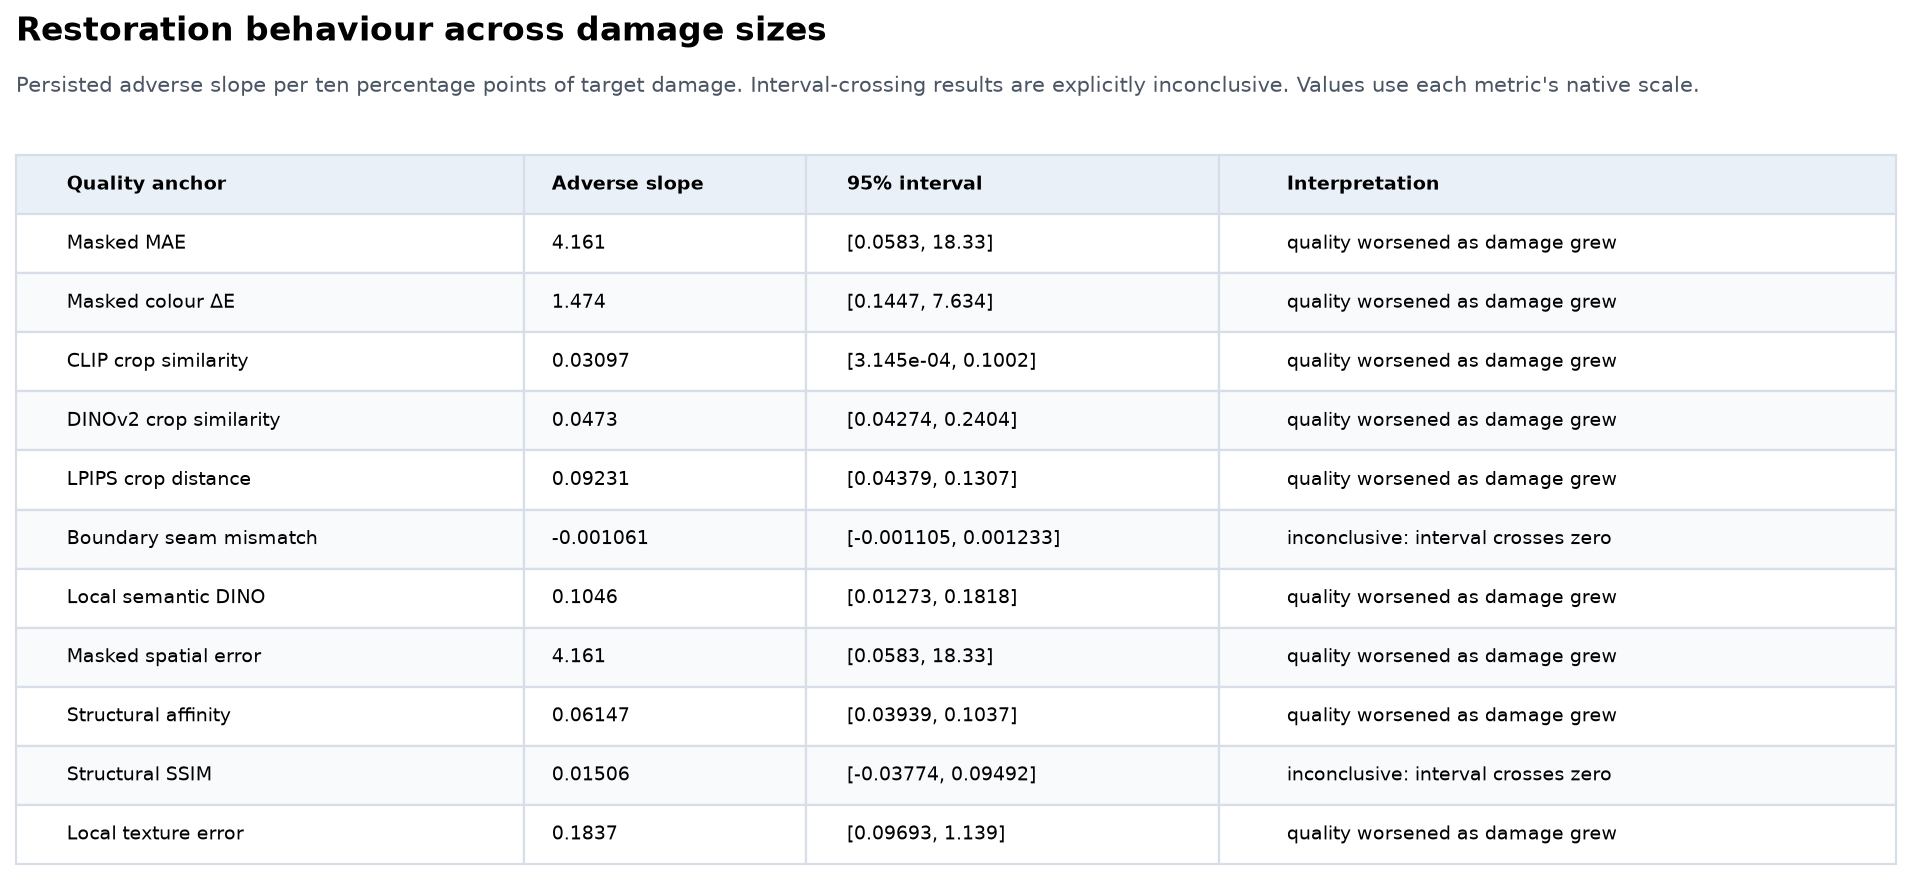
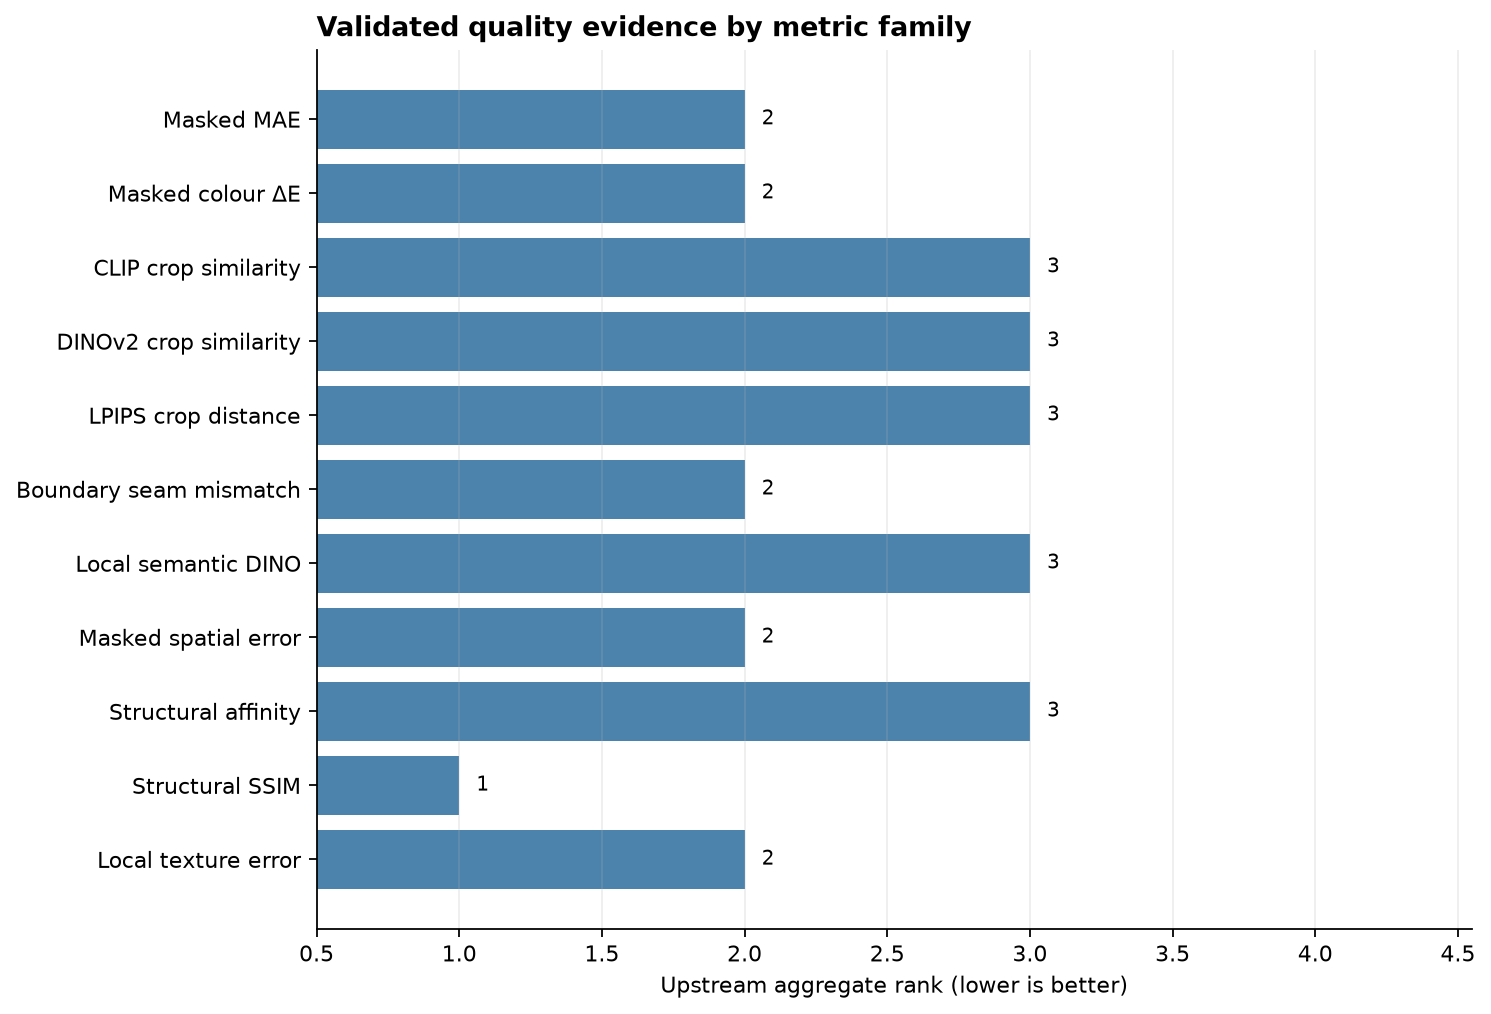
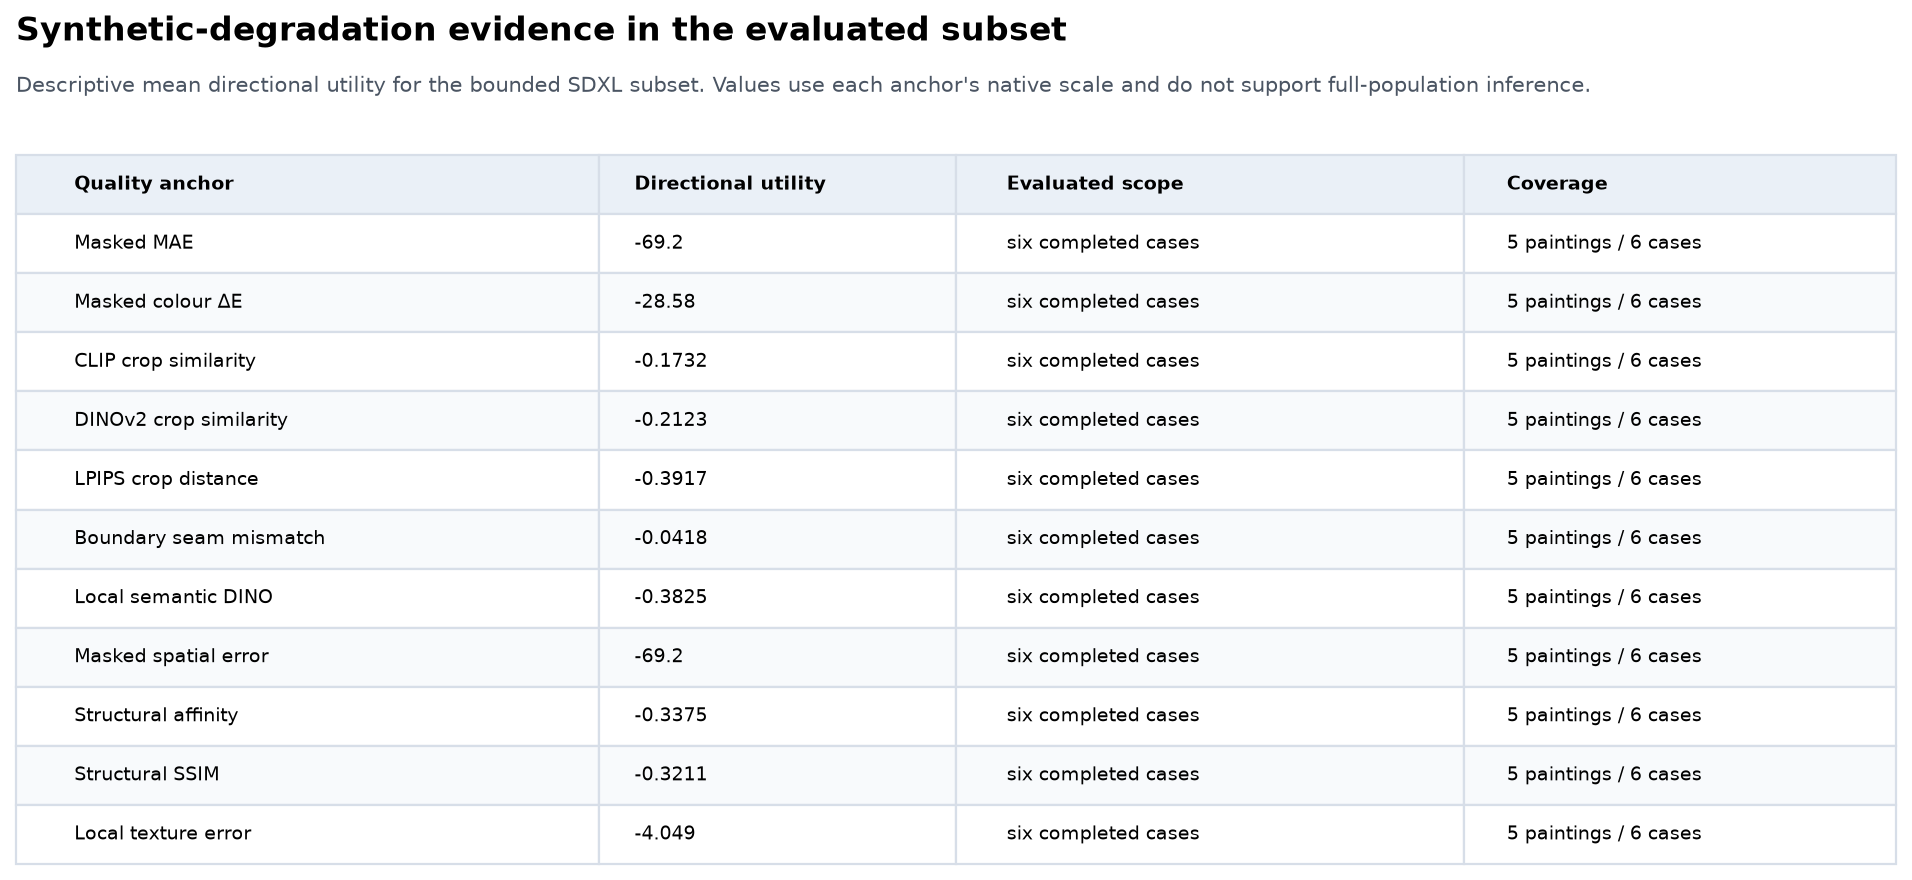
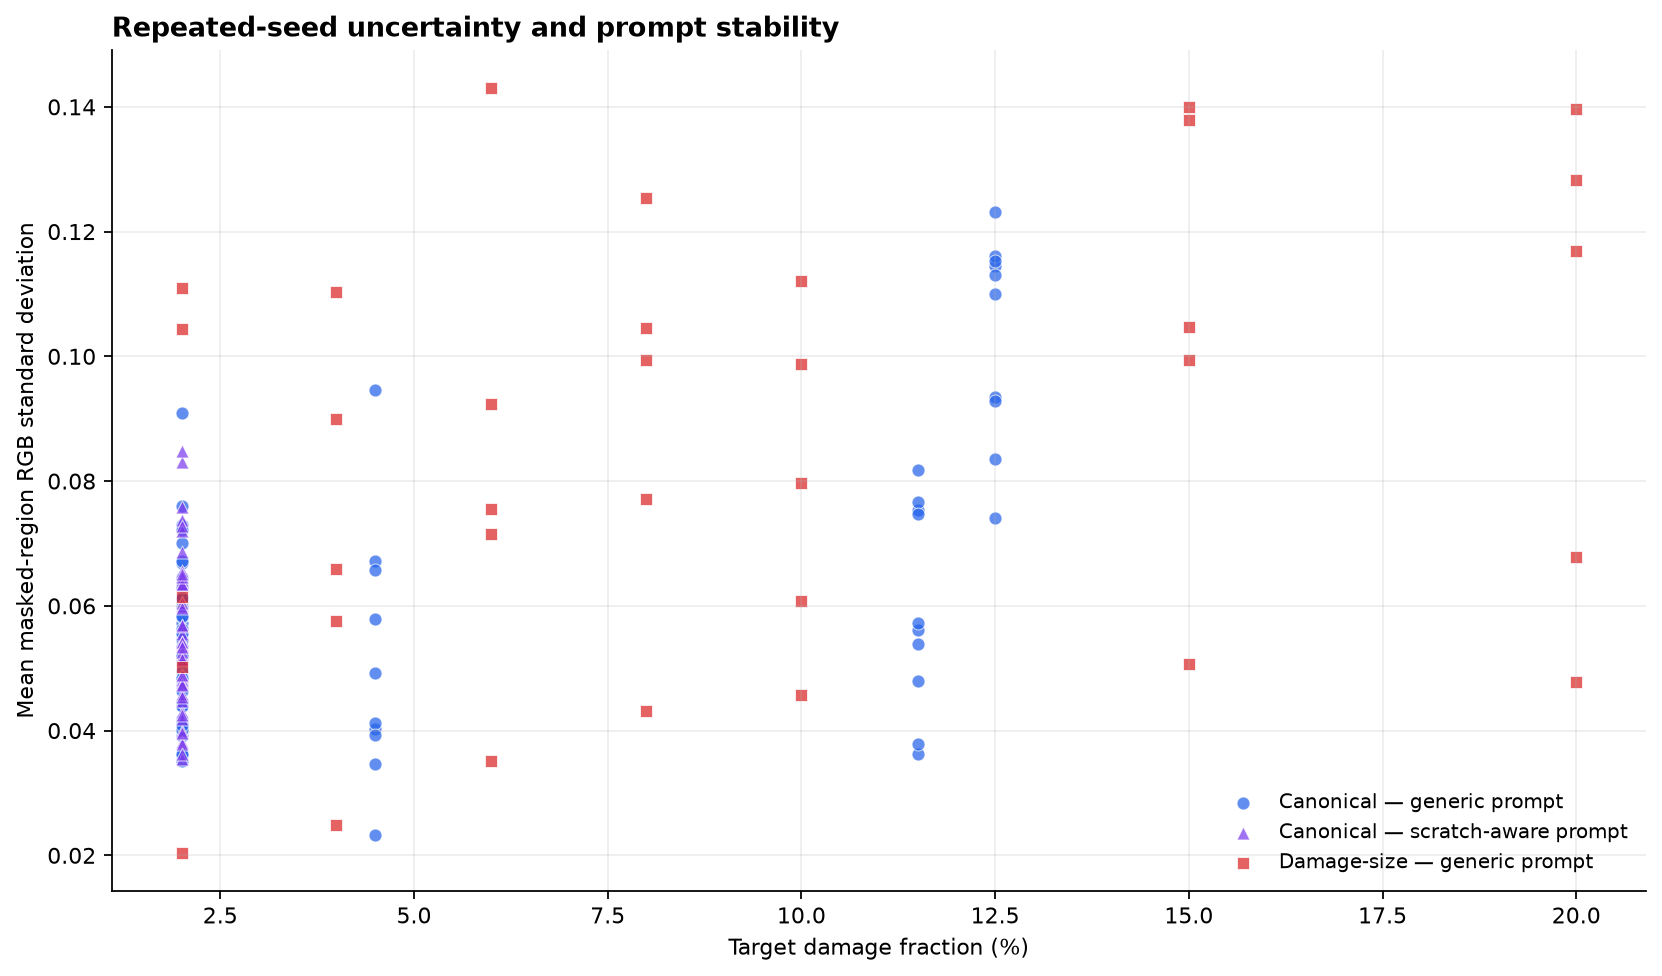

,validation_stage,check_id,check_description,severity,expected,observed,passed,details


Batch 8 analytical figure generation complete.
Validation checks: 5
Blocking failures: 0
Analytical assets: 23
Embedded PNG bytes: 2,264,140
QA figures rendered: 4
Canonical files written: 0


In [29]:
ANALYTICAL_ASSET_RECORDS = []

for plan_row in (
    ANALYTICAL_VIEW_PLAN.sort_values(
        [
            "model_id",
            "view_order",
        ],
        kind="stable",
    )
    .to_dict("records")
):
    view_id = str(
        plan_row["view_id"]
    )
    model_id = str(
        plan_row["model_id"]
    )
    view_key = str(
        plan_row["view_key"]
    )
    title = str(
        plan_row["title"]
    )

    frame = ANALYTICAL_VIEW_DATA[
        view_id
    ]

    if view_key in {
        "overall_quality",
        "texture_colour_seam",
        "semantic_structural",
    }:
        figure = rank_figure(
            frame,
            model_id=model_id,
            title=title,
        )
        caption = (
            "Ranks are copied from Notebook 21's "
            "validated comparison table. Lower is better; "
            "the figure does not create a new ranking."
        )

    elif view_key == "damage_size":
        figure = damage_size_figure(
            frame,
            title=title,
        )
        caption = (
            "Notebook 23 target-fraction slopes and "
            "painting-cluster intervals. Positive adverse "
            "slopes indicate worse quality as damage grows."
        )

    elif view_key == "mask_robustness":
        figure = mask_robustness_figure(
            frame,
            title=title,
        )
        caption = (
            "Notebook 24 overall mask-variant dispersion. "
            "Lower dispersion means greater robustness "
            "within the evaluated five-painting extension."
        )

    elif view_key == "synthetic_degradation":
        figure = degradation_figure(
            frame,
            model_id=model_id,
            title=title,
        )

        if model_id == "sdxl_inpainting":
            caption = (
                "Notebook 25 descriptive SDXL evidence "
                "covers six completed degradation cases "
                "from five paintings and is not a full "
                "population comparison."
            )
        else:
            caption = (
                "Notebook 25 painting-level degradation "
                "severity slopes. Metric-native magnitudes "
                "must be interpreted within each row."
            )

    elif (
        view_key
        == "uncertainty_prompt_stability"
    ):
        figure = uncertainty_figure(
            frame,
            title=title,
        )
        caption = (
            "All 130 canonical and 35 damage-size "
            "four-seed uncertainty groups are shown. "
            "Variability is empirical and is not "
            "calibrated confidence."
        )

    else:
        raise ValueError(
            "Unsupported analytical view: "
            f"{view_key}"
        )

    data_uri, image_size_bytes = (
        figure_to_png_data_uri(
            figure
        )
    )

    plt.close(
        figure
    )

    alt_text = (
        f"{MODEL_SPECS[model_id]['display_name']}: "
        f"{title}"
    )

    html_fragment = visual_html(
        data_uri,
        alt=alt_text,
        caption=caption,
        report_role="analytical_view",
        tile_count=1,
    )

    ANALYTICAL_ASSET_RECORDS.append(
        {
            "view_id": view_id,
            "model_id": model_id,
            "view_order": int(
                plan_row["view_order"]
            ),
            "view_key": view_key,
            "section_id": str(
                plan_row["section_id"]
            ),
            "title": title,
            "caption": caption,
            "data_uri": data_uri,
            "html_fragment": (
                html_fragment
            ),
            "image_size_bytes": int(
                image_size_bytes
            ),
            "report_role": (
                "analytical_view"
            ),
            "tile_count": 1,
            "status": "ok",
            "issue": "",
        }
    )

ANALYTICAL_VIEW_ASSETS = pd.DataFrame(
    ANALYTICAL_ASSET_RECORDS
)

for model_id in MODEL_SPECS:
    MODEL_EVIDENCE_PACKETS[
        model_id
    ]["analytical_view_assets"] = (
        ANALYTICAL_VIEW_ASSETS.loc[
            ANALYTICAL_VIEW_ASSETS[
                "model_id"
            ].eq(model_id)
        ]
        .sort_values(
            "view_order",
            kind="stable",
        )
        .reset_index(drop=True)
    )

observed_asset_counts = (
    ANALYTICAL_VIEW_ASSETS.groupby(
        "model_id"
    )["view_id"]
    .size()
    .astype(int)
    .to_dict()
)

asset_ids_match_plan = (
    set(
        ANALYTICAL_VIEW_ASSETS[
            "view_id"
        ].astype(str)
    )
    == set(
        ANALYTICAL_VIEW_PLAN[
            "view_id"
        ].astype(str)
    )
)

asset_payloads_valid = bool(
    ANALYTICAL_VIEW_ASSETS[
        "data_uri"
    ]
    .astype(str)
    .str.startswith(
        "data:image/png;base64,"
    )
    .all()
    and ANALYTICAL_VIEW_ASSETS[
        "image_size_bytes"
    ].gt(1000).all()
)

asset_html_valid = bool(
    ANALYTICAL_VIEW_ASSETS[
        "html_fragment"
    ]
    .astype(str)
    .str.contains(
        'data-report-role="analytical_view"',
        regex=False,
    )
    .all()
    and ANALYTICAL_VIEW_ASSETS[
        "html_fragment"
    ]
    .astype(str)
    .str.contains(
        'data-tile-count="1"',
        regex=False,
    )
    .all()
)

add_check(
    stage=BATCH_8_STAGE,
    check_id="analytical_asset_count_contract",
    description=(
        "All 23 planned analytical views have exactly "
        "one generated in-memory asset."
    ),
    expected=expected_view_counts,
    observed=observed_asset_counts,
    passed=(
        observed_asset_counts
        == expected_view_counts
        and len(
            ANALYTICAL_VIEW_ASSETS
        )
        == 23
        and asset_ids_match_plan
    ),
)

add_check(
    stage=BATCH_8_STAGE,
    check_id="analytical_asset_payloads",
    description=(
        "Every analytical asset is a non-empty embedded "
        "PNG data URI."
    ),
    expected=23,
    observed=int(
        ANALYTICAL_VIEW_ASSETS[
            "data_uri"
        ]
        .astype(str)
        .str.startswith(
            "data:image/png;base64,"
        )
        .sum()
    ),
    passed=asset_payloads_valid,
)

add_check(
    stage=BATCH_8_STAGE,
    check_id="analytical_asset_html",
    description=(
        "Every analytical HTML fragment has the approved "
        "visual role and one-tile declaration."
    ),
    expected=23,
    observed=int(
        ANALYTICAL_VIEW_ASSETS[
            "html_fragment"
        ]
        .astype(str)
        .str.contains(
            'data-report-role="analytical_view"',
            regex=False,
        )
        .sum()
    ),
    passed=asset_html_valid,
)

add_check(
    stage=BATCH_8_STAGE,
    check_id="analytical_asset_status",
    description=(
        "Every analytical asset completed without "
        "an issue marker."
    ),
    expected={
        "ok": 23
    },
    observed=(
        ANALYTICAL_VIEW_ASSETS[
            "status"
        ].value_counts().to_dict()
    ),
    passed=bool(
        ANALYTICAL_VIEW_ASSETS[
            "status"
        ].eq("ok").all()
        and ANALYTICAL_VIEW_ASSETS[
            "issue"
        ]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
        .all()
    ),
)

output_files_after_batch_8 = sorted(
    path
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
)

add_check(
    stage=BATCH_8_STAGE,
    check_id="batch_8_has_no_persistence",
    description=(
        "Analytical figure generation creates no "
        "Notebook 31 output files."
    ),
    expected=0,
    observed=len(
        output_files_after_batch_8
    ),
    passed=not output_files_after_batch_8,
)

asset_summary = (
    ANALYTICAL_VIEW_ASSETS.groupby(
        "model_id"
    )
    .agg(
        analytical_views=(
            "view_id",
            "size",
        ),
        total_png_bytes=(
            "image_size_bytes",
            "sum",
        ),
        minimum_png_bytes=(
            "image_size_bytes",
            "min",
        ),
        maximum_png_bytes=(
            "image_size_bytes",
            "max",
        ),
    )
    .reset_index()
)

display(asset_summary)

qa_view_keys = {
    (
        "opencv_telea",
        "overall_quality",
    ),
    (
        "lama",
        "damage_size",
    ),
    (
        "stable_diffusion_inpainting",
        "uncertainty_prompt_stability",
    ),
    (
        "sdxl_inpainting",
        "synthetic_degradation",
    ),
}

qa_assets = (
    ANALYTICAL_VIEW_ASSETS.loc[
        [
            (
                str(row["model_id"]),
                str(row["view_key"]),
            )
            in qa_view_keys
            for row in (
                ANALYTICAL_VIEW_ASSETS[
                    [
                        "model_id",
                        "view_key",
                    ]
                ]
                .to_dict("records")
            )
        ]
    ]
    .sort_values(
        [
            "model_id",
            "view_order",
        ],
        kind="stable",
    )
)

display(
    HTML(
        "<h3>Batch 8 analytical visual QA</h3>"
        + "".join(
            qa_assets[
                "html_fragment"
            ].astype(str)
        )
    )
)

BATCH_8_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_8_ROWS = (
    BATCH_8_VALIDATION.loc[
        BATCH_8_VALIDATION[
            "validation_stage"
        ].eq(BATCH_8_STAGE)
    ]
    .reset_index(drop=True)
)

blocking_failures = int(
    (
        BATCH_8_ROWS[
            "severity"
        ].eq("blocking")
        & ~BATCH_8_ROWS[
            "passed"
        ]
    ).sum()
)

display(
    BATCH_8_ROWS.loc[
        ~BATCH_8_ROWS["passed"]
    ]
)

print("Batch 8 analytical figure generation complete.")
print(
    "Validation checks: "
    f"{len(BATCH_8_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{blocking_failures:,}"
)
print(
    "Analytical assets: "
    f"{len(ANALYTICAL_VIEW_ASSETS):,}"
)
print(
    "Embedded PNG bytes: "
    f"{int(ANALYTICAL_VIEW_ASSETS['image_size_bytes'].sum()):,}"
)
print(
    "QA figures rendered: "
    f"{len(qa_assets):,}"
)
print(
    "Canonical files written: "
    f"{len(output_files_after_batch_8):,}"
)

VALIDATION.raise_for_blocking()

## Batch 9 — Representative panels and visual atlases

This batch:

- generates one representative panel for every approved representative candidate;
- shows clean reference, damaged input, mask, and restored output in every panel;
- adds up to two deterministic diagnostic maps where diagnostics are applicable;
- preserves the Stable Diffusion zero-control diagnostic exemption;
- generates category-coverage and experiment/damage-coverage atlases for every model;
- embeds all panels and atlases as compressed in-memory JPEG data URIs;
- validates model-specific image counts and minimum tile counts;
- attaches representative and atlas assets to each model evidence packet;
- renders one representative panel per model plus one atlas for visual QA.

Representative and atlas cases are illustrative report examples. They do not replace the complete upstream evidence population and are not treated as independent statistical observations.

This batch does not copy source images, write figure files, calculate metrics, create rankings, render complete reports, or persist canonical outputs.

In [30]:
BATCH_9_STAGE = "batch_9_representative_and_atlas_assets"

VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_9_STAGE,
)

from PIL import Image


DIAGNOSTIC_DOMAIN_PRIORITY = [
    "uncertainty",
    "difference",
    "semantic",
    "texture",
    "colour",
    "seam",
    "mask_boundary",
]


def load_report_tile(
    declared_path,
) -> np.ndarray:
    """Load one previously validated repository image."""
    _, resolved_path = (
        normalize_repository_image_path(
            declared_path
        )
    )

    return plt.imread(
        resolved_path
    )


def figure_to_jpeg_data_uri(
    figure: mpl.figure.Figure,
    *,
    quality: int,
) -> tuple[str, int]:
    """Encode a photographic composite without writing it to disk."""
    png_buffer = io.BytesIO()

    figure.savefig(
        png_buffer,
        format="png",
        dpi=125,
        bbox_inches="tight",
        facecolor="white",
    )

    png_buffer.seek(0)

    jpeg_buffer = io.BytesIO()

    with Image.open(
        png_buffer
    ) as rendered:
        rendered.convert(
            "RGB"
        ).save(
            jpeg_buffer,
            format="JPEG",
            quality=int(quality),
            optimize=True,
            progressive=True,
        )

    payload = jpeg_buffer.getvalue()

    data_uri = (
        "data:image/jpeg;base64,"
        + base64.b64encode(
            payload
        ).decode("ascii")
    )

    return data_uri, len(payload)


def render_image_grid(
    *,
    tiles: list[dict],
    title: str,
    columns: int,
) -> mpl.figure.Figure:
    """Render one auditable composite from existing image tiles."""
    if not tiles:
        raise ValueError(
            "Cannot render an empty image grid."
        )

    columns = max(
        1,
        int(columns),
    )

    row_count = int(
        np.ceil(
            len(tiles) / columns
        )
    )

    figure, axes = plt.subplots(
        row_count,
        columns,
        figsize=(
            3.25 * columns,
            3.15 * row_count + 0.65,
        ),
        squeeze=False,
    )

    flat_axes = axes.ravel()

    for axis, tile in zip(
        flat_axes,
        tiles,
    ):
        image_array = load_report_tile(
            tile["path"]
        )

        if tile.get(
            "is_mask",
            False,
        ):
            axis.imshow(
                image_array,
                cmap="gray",
                vmin=0,
                vmax=1,
            )
        else:
            axis.imshow(
                image_array
            )

        axis.set_title(
            str(tile["label"]),
            fontsize=8.5,
            pad=5,
        )

        axis.axis("off")

    for axis in flat_axes[
        len(tiles):
    ]:
        axis.axis("off")

    figure.suptitle(
        title,
        fontsize=14,
        fontweight="bold",
        y=0.995,
    )

    figure.tight_layout(
        rect=[
            0.0,
            0.0,
            1.0,
            0.96,
        ],
        pad=0.7,
    )

    return figure


def representative_diagnostic_tiles(
    selection: dict,
    *,
    maximum_count: int = 2,
) -> list[dict]:
    """Select at most one image from each prioritized diagnostic domain."""
    raw_payload = selection[
        "diagnostic_paths_json"
    ]

    if isinstance(raw_payload, dict):
        payload = raw_payload
    elif (
        pd.isna(raw_payload)
        or not str(raw_payload).strip()
    ):
        payload = {}
    else:
        payload = json.loads(
            str(raw_payload)
        )

    selected_tiles = []
    selected_paths = set()

    for domain in (
        DIAGNOSTIC_DOMAIN_PRIORITY
    ):
        declared_values = payload.get(
            domain,
            [],
        )

        if not isinstance(
            declared_values,
            list,
        ):
            continue

        for declared_value in (
            declared_values
        ):
            declared_text = str(
                declared_value
            ).strip()

            if not declared_text:
                continue

            if (
                Path(
                    declared_text
                ).suffix.lower()
                not in IMAGE_EXTENSIONS
            ):
                continue

            relative_path, resolved_path = (
                normalize_repository_image_path(
                    declared_text
                )
            )

            if (
                not resolved_path.is_file()
                or relative_path
                in selected_paths
            ):
                continue

            selected_tiles.append(
                {
                    "path": relative_path,
                    "label": (
                        domain.replace(
                            "_",
                            " ",
                        ).title()
                        + " diagnostic"
                    ),
                    "diagnostic_domain": (
                        domain
                    ),
                    "is_mask": False,
                }
            )

            selected_paths.add(
                relative_path
            )

            break

        if (
            len(selected_tiles)
            >= maximum_count
        ):
            break

    return selected_tiles


print("Representative and atlas image helpers initialized.")

Representative and atlas image helpers initialized.


In [31]:
REPRESENTATIVE_ASSET_RECORDS = []

for selection in (
    REPRESENTATIVE_SELECTIONS.sort_values(
        [
            "model_id",
            "selection_order",
        ],
        kind="stable",
    )
    .to_dict("records")
):
    model_id = str(
        selection["model_id"]
    )

    core_tiles = [
        {
            "path": selection[
                "clean_path"
            ],
            "label": "Clean reference",
            "is_mask": False,
        },
        {
            "path": selection[
                "damaged_path"
            ],
            "label": "Damaged input",
            "is_mask": False,
        },
        {
            "path": selection[
                "mask_path"
            ],
            "label": "Mask or effect support",
            "is_mask": True,
        },
        {
            "path": selection[
                "restored_path"
            ],
            "label": "Restored output",
            "is_mask": False,
        },
    ]

    if (
        str(
            selection[
                "diagnostic_applicability"
            ]
        )
        == "applicable"
    ):
        diagnostic_tiles = (
            representative_diagnostic_tiles(
                selection,
                maximum_count=2,
            )
        )
    else:
        diagnostic_tiles = []

    panel_tiles = [
        *core_tiles,
        *diagnostic_tiles,
    ]

    panel_title = (
        f"{MODEL_SPECS[model_id]['display_name']} | "
        f"{selection['painting_id']} | "
        f"{str(selection['degradation_family']).replace('_', ' ')}"
    )

    figure = render_image_grid(
        tiles=panel_tiles,
        title=panel_title,
        columns=3,
    )

    data_uri, image_size_bytes = (
        figure_to_jpeg_data_uri(
            figure,
            quality=int(
                REPORT_POLICY[
                    "photographic_quality"
                ]
            ),
        )
    )

    plt.close(
        figure
    )

    caption = (
        f"Candidate {selection['candidate_id']}. "
        f"Recommendation category: "
        f"{str(selection['recommendation_category']).replace('_', ' ')}. "
        "This deterministic report selection is illustrative "
        "and is not an independent scientific observation."
    )

    html_fragment = visual_html(
        data_uri,
        alt=(
            f"{MODEL_SPECS[model_id]['display_name']} "
            f"representative restoration panel for "
            f"{selection['case_id']}"
        ),
        caption=caption,
        report_role=(
            "representative_panel"
        ),
        tile_count=len(
            panel_tiles
        ),
    )

    REPRESENTATIVE_ASSET_RECORDS.append(
        {
            "selection_id": selection[
                "selection_id"
            ],
            "model_id": model_id,
            "selection_order": int(
                selection[
                    "selection_order"
                ]
            ),
            "candidate_id": selection[
                "candidate_id"
            ],
            "case_id": selection[
                "case_id"
            ],
            "painting_id": selection[
                "painting_id"
            ],
            "recommendation_category": (
                selection[
                    "recommendation_category"
                ]
            ),
            "diagnostic_applicability": (
                selection[
                    "diagnostic_applicability"
                ]
            ),
            "diagnostic_tile_count": len(
                diagnostic_tiles
            ),
            "tile_count": len(
                panel_tiles
            ),
            "data_uri": data_uri,
            "html_fragment": (
                html_fragment
            ),
            "image_size_bytes": int(
                image_size_bytes
            ),
            "report_role": (
                "representative_panel"
            ),
            "status": "ok",
            "issue": "",
        }
    )

REPRESENTATIVE_PANEL_ASSETS = (
    pd.DataFrame(
        REPRESENTATIVE_ASSET_RECORDS
    )
)

ATLAS_ASSET_RECORDS = []

for (
    model_id,
    atlas_id,
), atlas_rows in (
    ATLAS_SELECTIONS.groupby(
        [
            "model_id",
            "atlas_id",
        ],
        sort=False,
    )
):
    atlas_rows = (
        atlas_rows.sort_values(
            "tile_order",
            kind="stable",
        )
        .reset_index(drop=True)
    )

    atlas_title = str(
        atlas_rows.iloc[
            0
        ]["atlas_title"]
    )

    atlas_tiles = []

    for row in atlas_rows.to_dict(
        "records"
    ):
        label = (
            f"{row['painting_id']} | "
            f"{str(row['degradation_family']).replace('_', ' ')}\n"
            f"{str(row['recommendation_category']).replace('_', ' ')}"
        )

        atlas_tiles.append(
            {
                "path": row[
                    "restored_path"
                ],
                "label": label,
                "is_mask": False,
            }
        )

    figure = render_image_grid(
        tiles=atlas_tiles,
        title=(
            f"{MODEL_SPECS[model_id]['display_name']} — "
            f"{atlas_title}"
        ),
        columns=4,
    )

    data_uri, image_size_bytes = (
        figure_to_jpeg_data_uri(
            figure,
            quality=int(
                REPORT_POLICY[
                    "photographic_quality"
                ]
            ),
        )
    )

    plt.close(
        figure
    )

    caption = (
        f"{atlas_title} atlas with "
        f"{len(atlas_tiles)} restored-output tiles. "
        "Atlas cases are deterministic coverage examples; "
        "the complete evidence remains in the upstream tables."
    )

    html_fragment = visual_html(
        data_uri,
        alt=(
            f"{MODEL_SPECS[model_id]['display_name']} "
            f"{atlas_title.lower()} atlas"
        ),
        caption=caption,
        report_role="visual_atlas",
        tile_count=len(
            atlas_tiles
        ),
    )

    ATLAS_ASSET_RECORDS.append(
        {
            "atlas_asset_id": (
                f"atlas__{model_id}__"
                f"{atlas_id}"
            ),
            "model_id": model_id,
            "atlas_id": atlas_id,
            "atlas_title": atlas_title,
            "atlas_order": int(
                atlas_rows.iloc[
                    0
                ]["atlas_order"]
            ),
            "tile_count": len(
                atlas_tiles
            ),
            "data_uri": data_uri,
            "html_fragment": (
                html_fragment
            ),
            "image_size_bytes": int(
                image_size_bytes
            ),
            "report_role": (
                "visual_atlas"
            ),
            "status": "ok",
            "issue": "",
        }
    )

VISUAL_ATLAS_ASSETS = pd.DataFrame(
    ATLAS_ASSET_RECORDS
)

print("Representative panels and atlases generated.")
print(
    "Representative panels: "
    f"{len(REPRESENTATIVE_PANEL_ASSETS):,}"
)
print(
    "Visual atlases: "
    f"{len(VISUAL_ATLAS_ASSETS):,}"
)

Representative panels and atlases generated.
Representative panels: 32
Visual atlases: 8


,model_id,analytical_images,representative_images,atlas_images,embedded_images,minimum_embedded_images,embedded_tiles,minimum_embedded_tiles,image_count_passed,tile_count_passed
0,opencv_telea,6,8,2,16,16,76,60,True,True
1,lama,6,8,2,16,16,76,60,True,True
2,stable_diffusion_inpainting,7,10,2,19,19,90,72,True,True
3,sdxl_inpainting,4,6,2,12,12,56,44,True,True



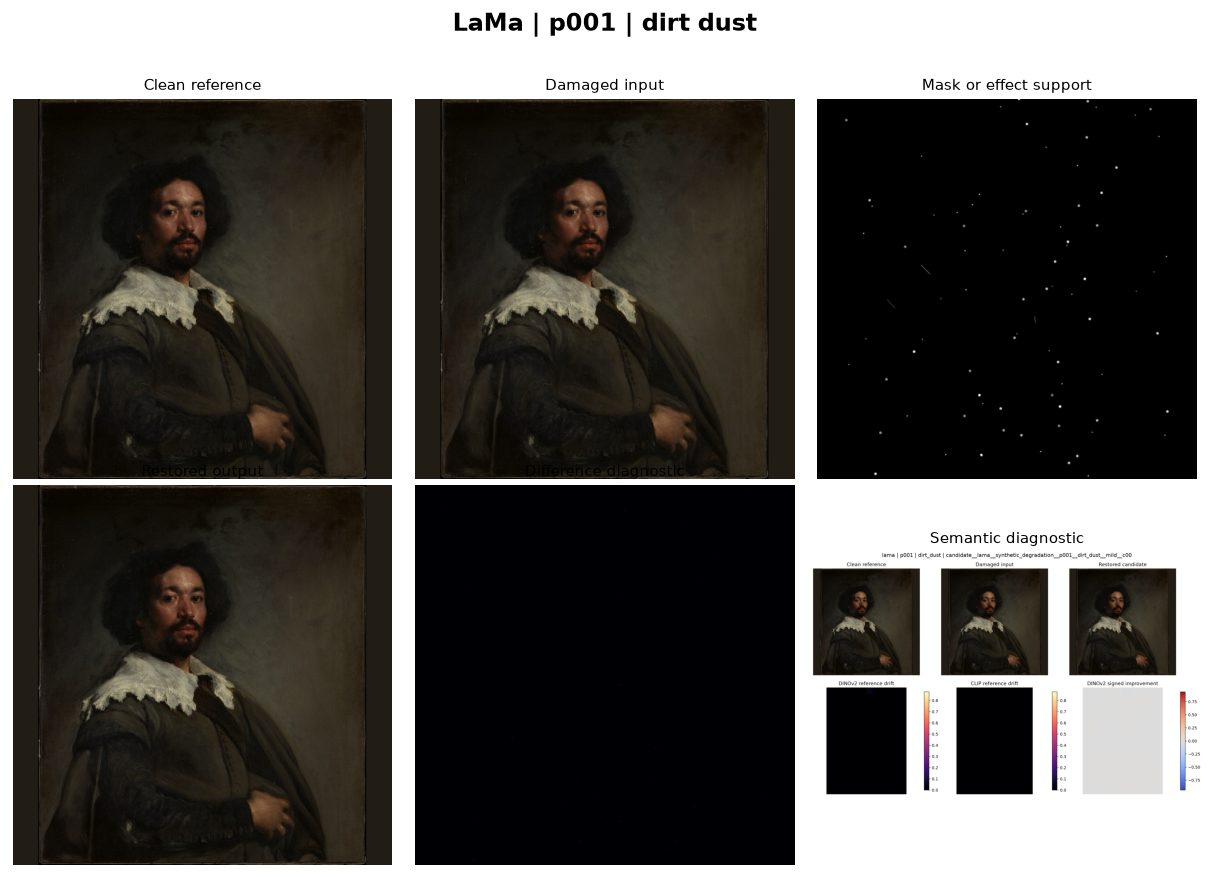
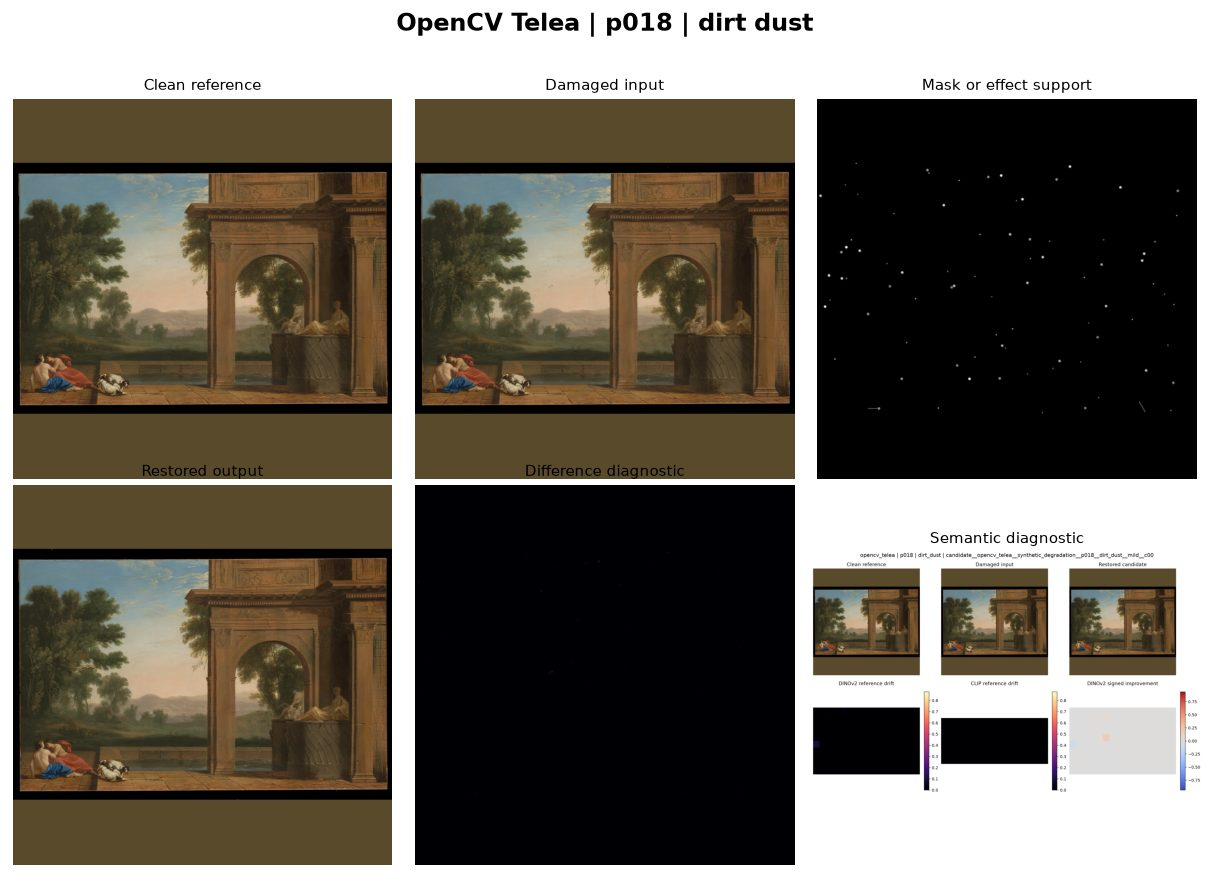
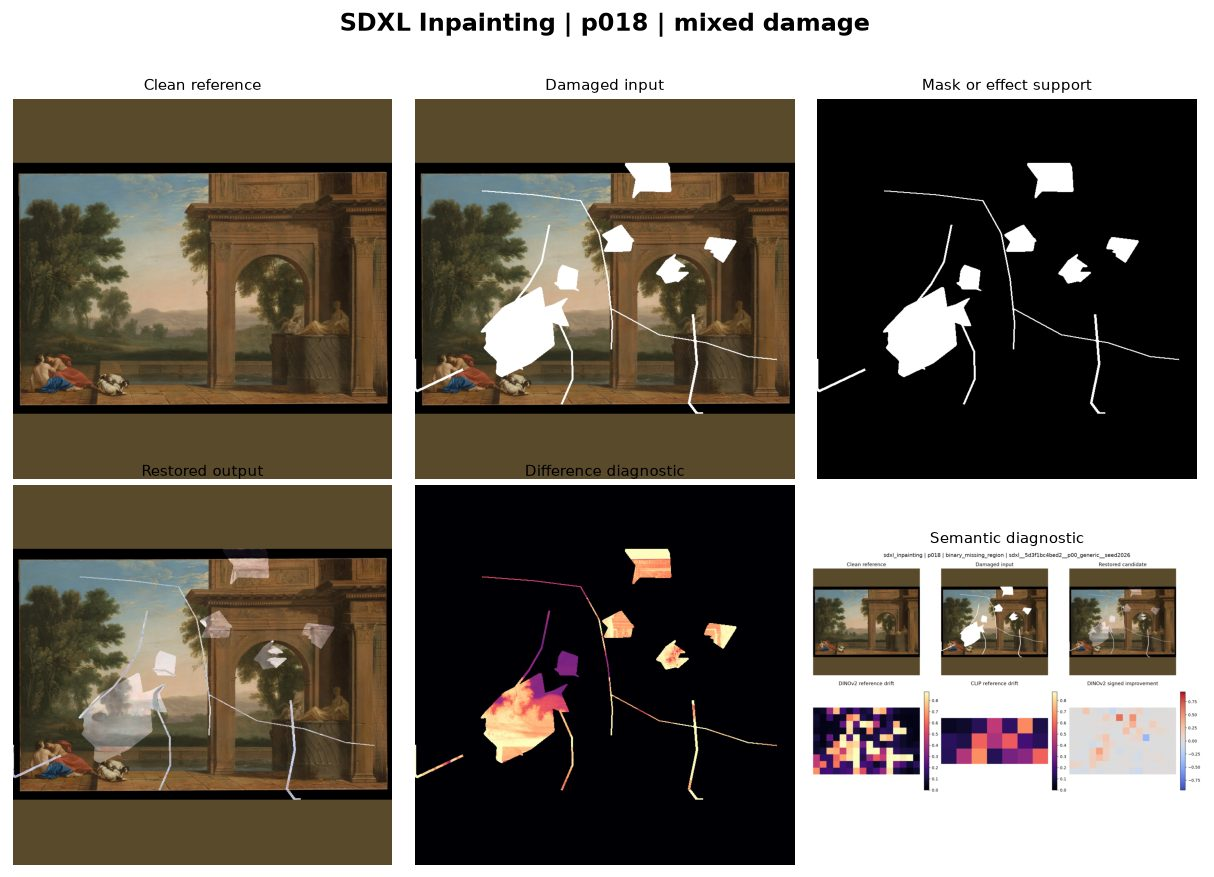
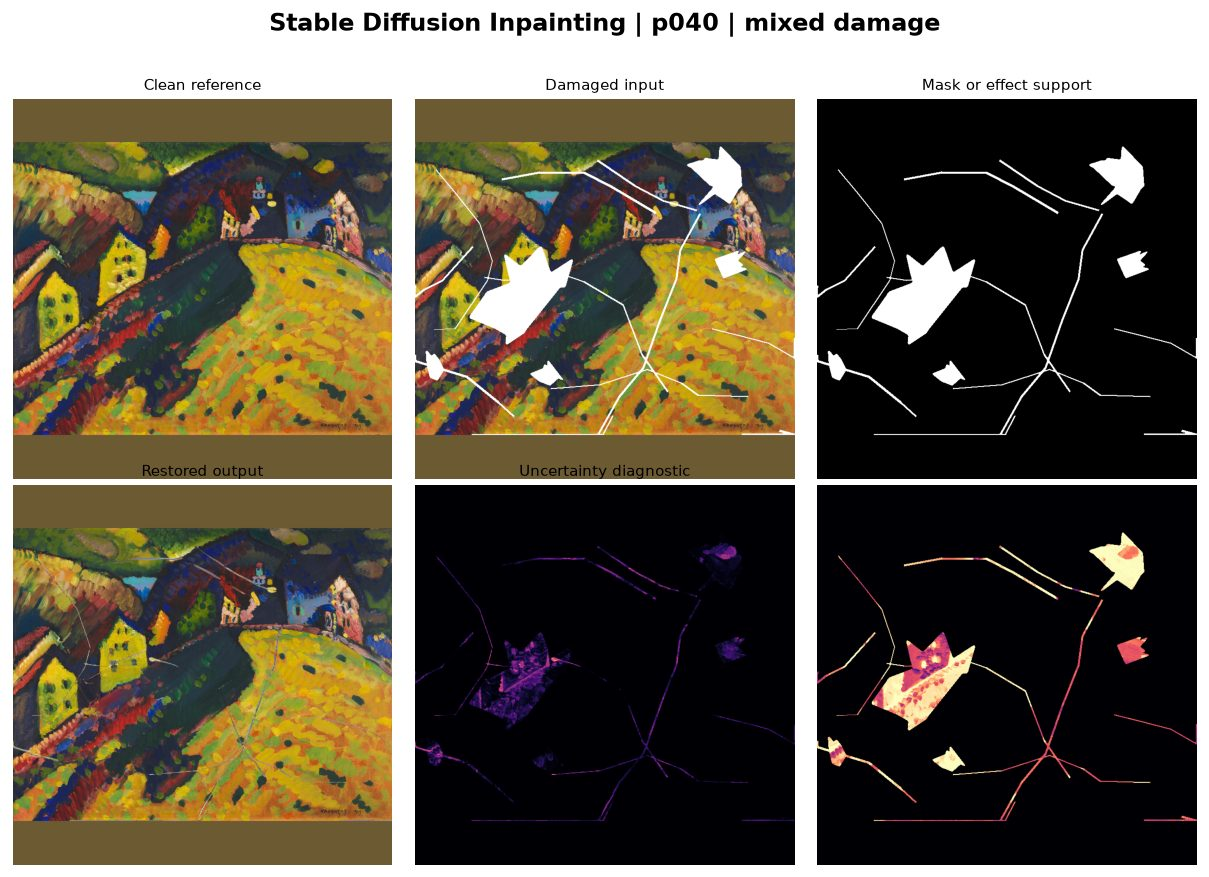
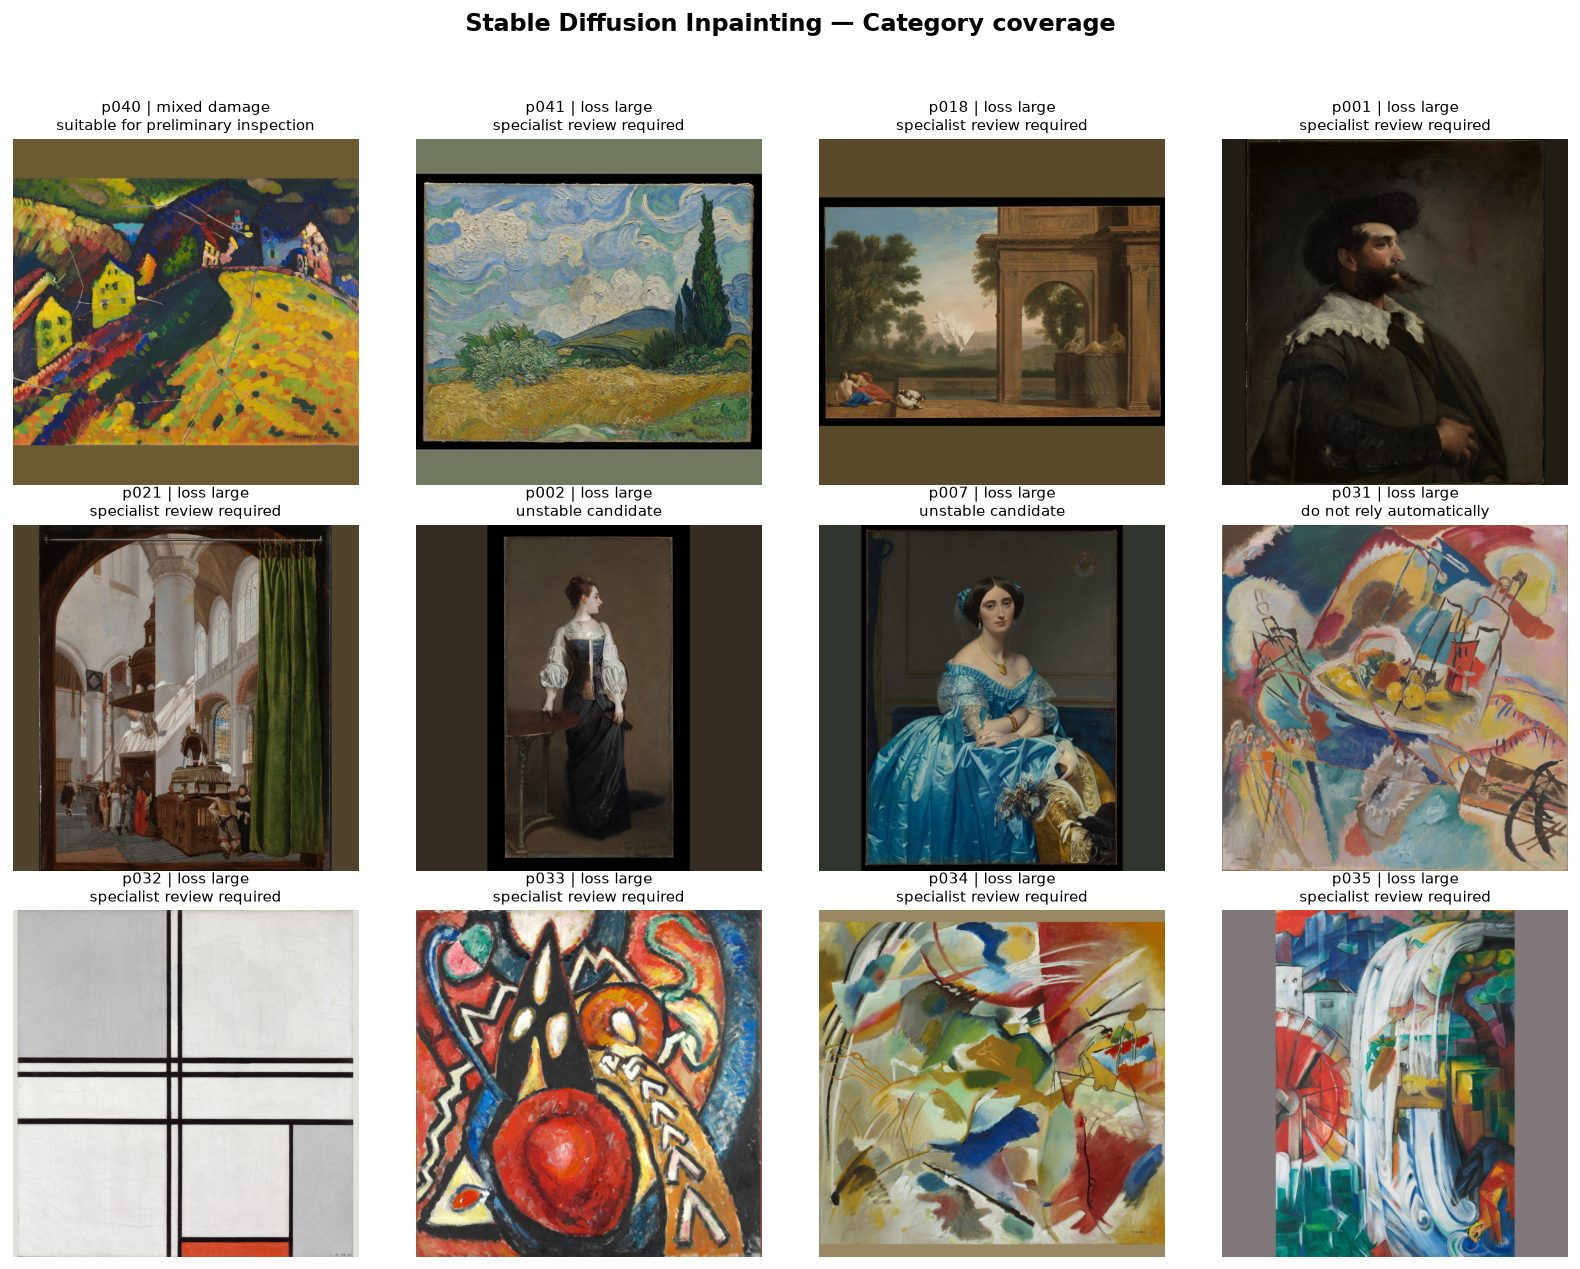

,validation_stage,check_id,check_description,severity,expected,observed,passed,details


Batch 9 representative and atlas assets complete.
Validation checks: 7
Blocking failures: 0
Representative panels: 32
Visual atlases: 8
Representative diagnostic tiles: 62
Atlas tiles: 85
Canonical files written: 0


In [32]:
for model_id in MODEL_SPECS:
    MODEL_EVIDENCE_PACKETS[
        model_id
    ]["representative_panel_assets"] = (
        REPRESENTATIVE_PANEL_ASSETS.loc[
            REPRESENTATIVE_PANEL_ASSETS[
                "model_id"
            ].eq(model_id)
        ]
        .sort_values(
            "selection_order",
            kind="stable",
        )
        .reset_index(drop=True)
    )

    MODEL_EVIDENCE_PACKETS[
        model_id
    ]["visual_atlas_assets"] = (
        VISUAL_ATLAS_ASSETS.loc[
            VISUAL_ATLAS_ASSETS[
                "model_id"
            ].eq(model_id)
        ]
        .sort_values(
            "atlas_order",
            kind="stable",
        )
        .reset_index(drop=True)
    )

expected_representative_counts = {
    model_id: int(
        spec[
            "representative_panel_count"
        ]
    )
    for model_id, spec
    in MODEL_SPECS.items()
}

observed_representative_counts = (
    REPRESENTATIVE_PANEL_ASSETS.groupby(
        "model_id"
    )["selection_id"]
    .size()
    .astype(int)
    .to_dict()
)

observed_atlas_counts = (
    VISUAL_ATLAS_ASSETS.groupby(
        "model_id"
    )["atlas_asset_id"]
    .size()
    .astype(int)
    .to_dict()
)

expected_atlas_asset_counts = {
    model_id: int(
        spec[
            "visual_atlas_count"
        ]
    )
    for model_id, spec
    in MODEL_SPECS.items()
}

applicable_representative_assets = (
    REPRESENTATIVE_PANEL_ASSETS.loc[
        REPRESENTATIVE_PANEL_ASSETS[
            "diagnostic_applicability"
        ].eq("applicable")
    ]
)

exempt_representative_assets = (
    REPRESENTATIVE_PANEL_ASSETS.loc[
        REPRESENTATIVE_PANEL_ASSETS[
            "diagnostic_applicability"
        ].ne("applicable")
    ]
)

representative_diagnostics_ok = bool(
    applicable_representative_assets[
        "diagnostic_tile_count"
    ].eq(2).all()
    and exempt_representative_assets[
        "diagnostic_tile_count"
    ].eq(0).all()
)

representative_payloads_ok = bool(
    REPRESENTATIVE_PANEL_ASSETS[
        "data_uri"
    ]
    .astype(str)
    .str.startswith(
        "data:image/jpeg;base64,"
    )
    .all()
    and REPRESENTATIVE_PANEL_ASSETS[
        "image_size_bytes"
    ].gt(5000).all()
)

atlas_payloads_ok = bool(
    VISUAL_ATLAS_ASSETS[
        "data_uri"
    ]
    .astype(str)
    .str.startswith(
        "data:image/jpeg;base64,"
    )
    .all()
    and VISUAL_ATLAS_ASSETS[
        "image_size_bytes"
    ].gt(5000).all()
)

observed_atlas_tile_counts = {
    (
        str(row["model_id"]),
        str(row["atlas_id"]),
    ): int(
        row["tile_count"]
    )
    for row in (
        VISUAL_ATLAS_ASSETS.to_dict(
            "records"
        )
    )
}

expected_atlas_tile_counts = {
    (
        str(model_id),
        str(atlas_id),
    ): int(
        len(atlas_rows)
    )
    for (
        model_id,
        atlas_id,
    ), atlas_rows in (
        ATLAS_SELECTIONS.groupby(
            [
                "model_id",
                "atlas_id",
            ]
        )
    )
}

visual_density_records = []

for model_id, spec in (
    MODEL_SPECS.items()
):
    analytical_assets = (
        ANALYTICAL_VIEW_ASSETS.loc[
            ANALYTICAL_VIEW_ASSETS[
                "model_id"
            ].eq(model_id)
        ]
    )

    representative_assets = (
        REPRESENTATIVE_PANEL_ASSETS.loc[
            REPRESENTATIVE_PANEL_ASSETS[
                "model_id"
            ].eq(model_id)
        ]
    )

    atlas_assets = (
        VISUAL_ATLAS_ASSETS.loc[
            VISUAL_ATLAS_ASSETS[
                "model_id"
            ].eq(model_id)
        ]
    )

    embedded_images = (
        len(analytical_assets)
        + len(representative_assets)
        + len(atlas_assets)
    )

    embedded_tiles = int(
        analytical_assets[
            "tile_count"
        ].sum()
        + representative_assets[
            "tile_count"
        ].sum()
        + atlas_assets[
            "tile_count"
        ].sum()
    )

    visual_density_records.append(
        {
            "model_id": model_id,
            "analytical_images": len(
                analytical_assets
            ),
            "representative_images": len(
                representative_assets
            ),
            "atlas_images": len(
                atlas_assets
            ),
            "embedded_images": (
                embedded_images
            ),
            "minimum_embedded_images": int(
                spec[
                    "minimum_embedded_image_count"
                ]
            ),
            "embedded_tiles": (
                embedded_tiles
            ),
            "minimum_embedded_tiles": int(
                spec[
                    "minimum_embedded_tile_count"
                ]
            ),
            "image_count_passed": (
                embedded_images
                >= int(
                    spec[
                        "minimum_embedded_image_count"
                    ]
                )
            ),
            "tile_count_passed": (
                embedded_tiles
                >= int(
                    spec[
                        "minimum_embedded_tile_count"
                    ]
                )
            ),
        }
    )

REPORT_VISUAL_DENSITY = pd.DataFrame(
    visual_density_records
)

add_check(
    stage=BATCH_9_STAGE,
    check_id="representative_asset_count_contract",
    description=(
        "Every model retains its exact approved number "
        "of representative panels."
    ),
    expected=expected_representative_counts,
    observed=observed_representative_counts,
    passed=(
        observed_representative_counts
        == expected_representative_counts
        and len(
            REPRESENTATIVE_PANEL_ASSETS
        )
        == 32
    ),
)

add_check(
    stage=BATCH_9_STAGE,
    check_id="representative_diagnostic_contract",
    description=(
        "Every diagnostic-applicable representative has "
        "two diagnostic tiles and the zero control remains exempt."
    ),
    expected={
        "applicable_with_two": 31,
        "exempt_with_zero": 1,
    },
    observed={
        "applicable_with_two": int(
            applicable_representative_assets[
                "diagnostic_tile_count"
            ].eq(2).sum()
        ),
        "exempt_with_zero": int(
            exempt_representative_assets[
                "diagnostic_tile_count"
            ].eq(0).sum()
        ),
    },
    passed=representative_diagnostics_ok,
)

add_check(
    stage=BATCH_9_STAGE,
    check_id="visual_atlas_count_contract",
    description=(
        "Each model retains exactly two visual atlases."
    ),
    expected=expected_atlas_asset_counts,
    observed=observed_atlas_counts,
    passed=(
        observed_atlas_counts
        == expected_atlas_asset_counts
        and len(
            VISUAL_ATLAS_ASSETS
        )
        == 8
    ),
)

add_check(
    stage=BATCH_9_STAGE,
    check_id="visual_atlas_tile_contract",
    description=(
        "Every atlas contains its exact deterministic "
        "source-tile population."
    ),
    expected={
        "|".join(key): value
        for key, value
        in expected_atlas_tile_counts.items()
    },
    observed={
        "|".join(key): value
        for key, value
        in observed_atlas_tile_counts.items()
    },
    passed=(
        observed_atlas_tile_counts
        == expected_atlas_tile_counts
        and int(
            VISUAL_ATLAS_ASSETS[
                "tile_count"
            ].sum()
        )
        == 85
    ),
)

add_check(
    stage=BATCH_9_STAGE,
    check_id="visual_asset_payloads",
    description=(
        "All representative and atlas assets are "
        "non-empty embedded JPEG data URIs."
    ),
    expected={
        "representative_panels": 32,
        "visual_atlases": 8,
    },
    observed={
        "representative_panels": int(
            representative_payloads_ok
        ),
        "visual_atlases": int(
            atlas_payloads_ok
        ),
    },
    passed=(
        representative_payloads_ok
        and atlas_payloads_ok
    ),
)

add_check(
    stage=BATCH_9_STAGE,
    check_id="complete_visual_density",
    description=(
        "Analytical views, representative panels, and "
        "atlases meet every model's approved visual density."
    ),
    expected=True,
    observed=(
        REPORT_VISUAL_DENSITY.to_dict(
            "records"
        )
    ),
    passed=bool(
        REPORT_VISUAL_DENSITY[
            "image_count_passed"
        ].all()
        and REPORT_VISUAL_DENSITY[
            "tile_count_passed"
        ].all()
    ),
)

output_files_after_batch_9 = sorted(
    path
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
)

add_check(
    stage=BATCH_9_STAGE,
    check_id="batch_9_has_no_persistence",
    description=(
        "Representative and atlas generation creates no "
        "Notebook 31 output files."
    ),
    expected=0,
    observed=len(
        output_files_after_batch_9
    ),
    passed=not output_files_after_batch_9,
)

display(REPORT_VISUAL_DENSITY)

qa_representatives = (
    REPRESENTATIVE_PANEL_ASSETS.sort_values(
        [
            "model_id",
            "selection_order",
        ],
        kind="stable",
    )
    .groupby(
        "model_id",
        sort=False,
    )
    .head(1)
)

qa_atlas = (
    VISUAL_ATLAS_ASSETS.loc[
        VISUAL_ATLAS_ASSETS[
            "model_id"
        ].eq(
            "stable_diffusion_inpainting"
        )
        & VISUAL_ATLAS_ASSETS[
            "atlas_id"
        ].eq(
            "category_coverage"
        )
    ]
    .head(1)
)

display(
    HTML(
        "<h3>Batch 9 representative-panel QA</h3>"
        + "".join(
            qa_representatives[
                "html_fragment"
            ].astype(str)
        )
        + "<h3>Batch 9 atlas QA</h3>"
        + "".join(
            qa_atlas[
                "html_fragment"
            ].astype(str)
        )
    )
)

BATCH_9_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_9_ROWS = (
    BATCH_9_VALIDATION.loc[
        BATCH_9_VALIDATION[
            "validation_stage"
        ].eq(BATCH_9_STAGE)
    ]
    .reset_index(drop=True)
)

blocking_failures = int(
    (
        BATCH_9_ROWS[
            "severity"
        ].eq("blocking")
        & ~BATCH_9_ROWS[
            "passed"
        ]
    ).sum()
)

display(
    BATCH_9_ROWS.loc[
        ~BATCH_9_ROWS["passed"]
    ]
)

print("Batch 9 representative and atlas assets complete.")
print(
    "Validation checks: "
    f"{len(BATCH_9_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{blocking_failures:,}"
)
print(
    "Representative panels: "
    f"{len(REPRESENTATIVE_PANEL_ASSETS):,}"
)
print(
    "Visual atlases: "
    f"{len(VISUAL_ATLAS_ASSETS):,}"
)
print(
    "Representative diagnostic tiles: "
    f"{int(REPRESENTATIVE_PANEL_ASSETS['diagnostic_tile_count'].sum()):,}"
)
print(
    "Atlas tiles: "
    f"{int(VISUAL_ATLAS_ASSETS['tile_count'].sum()):,}"
)
print(
    "Canonical files written: "
    f"{len(output_files_after_batch_9):,}"
)

VALIDATION.raise_for_blocking()

## Batch 10 — Numerical summaries and conclusion registry

This batch:

- extracts report-ready numerical facts from validated upstream evidence;
- preserves Notebook 26's existing family-balanced ranks and bootstrap stability result;
- summarizes damage-size confidence-interval interpretations already supported by Notebook 23;
- summarizes synthetic-degradation directions without comparing incompatible metric scales;
- summarizes candidate-level trustworthiness flags and recommendation categories;
- distinguishes observed runtime from the transparent 300-painting projection;
- constructs one evidence-backed conclusion record for every approved report section;
- places direct better, worse, or inconclusive interpretations beside their limitations;
- links each major conclusion to RQ1, RQ2, RQ3, or an approved thesis extension.

Counts, filtering, formatting, and presentation wording are report-only transformations. This batch does not calculate a new metric, statistical test, composite score, scientific ranking, or canonical output.

In [33]:
BATCH_10_STAGE = "batch_10_numerical_summaries"

VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_10_STAGE,
)

STATISTICAL_RESULTS = TABLES[
    "statistical_results_path"
]

RANKING_STABILITY = TABLES[
    "ranking_stability_path"
]

FAILURE_ASSIGNMENTS = TABLES[
    "failure_assignments_path"
]

TRUSTWORTHINESS_FLAGS = TABLES[
    "trustworthiness_flags_path"
]

COMPUTE_SCALABILITY = TABLES[
    "compute_scalability_path"
]


def parse_json_list(value) -> list[str]:
    """Return a normalized list from one persisted JSON-list field."""
    if isinstance(value, list):
        return [
            str(item)
            for item in value
        ]

    if value is None or (
        isinstance(value, float)
        and pd.isna(value)
    ):
        return []

    text_value = str(value).strip()

    if not text_value:
        return []

    parsed = json.loads(text_value)

    if not isinstance(parsed, list):
        raise TypeError(
            "Expected a JSON list, received "
            f"{type(parsed).__name__}."
        )

    return [
        str(item)
        for item in parsed
    ]


def analytical_rows(
    model_id: str,
    view_key: str,
) -> pd.DataFrame:
    """Return one already-validated analytical display table."""
    view_id = view_id_lookup[
        (
            model_id,
            view_key,
        )
    ]

    return ANALYTICAL_VIEW_DATA[
        view_id
    ].copy()


CORE_BASELINE_RANKS = (
    RANKING_STABILITY.loc[
        RANKING_STABILITY[
            "ranking_kind"
        ].astype(str).eq(
            "baseline_rank"
        )
        & RANKING_STABILITY[
            "analysis_family_id"
        ].astype(str).eq(
            "all_nonzero_core_family_balanced"
        )
        & RANKING_STABILITY[
            "status"
        ].astype(str).eq("ok")
    ]
    .copy()
)

CORE_BOOTSTRAP_STABILITY = (
    RANKING_STABILITY.loc[
        RANKING_STABILITY[
            "ranking_kind"
        ].astype(str).eq(
            "bootstrap_winner_stability"
        )
        & RANKING_STABILITY[
            "analysis_family_id"
        ].astype(str).eq(
            "painting_cluster_bootstrap"
        )
        & RANKING_STABILITY[
            "status"
        ].astype(str).eq("ok")
    ]
    .copy()
)

SUMMARY_RECORDS = []

for model_id, model_spec in MODEL_SPECS.items():
    card = (
        MODEL_CARDS.loc[
            MODEL_CARDS[
                "model_id"
            ].astype(str).eq(model_id)
        ]
        .iloc[0]
    )

    context = (
        MODEL_CONTEXT_SUMMARY.loc[
            MODEL_CONTEXT_SUMMARY[
                "model_id"
            ].eq(model_id)
        ]
        .iloc[0]
    )

    overall_rows = analytical_rows(
        model_id,
        "overall_quality",
    )

    local_rows = analytical_rows(
        model_id,
        "texture_colour_seam",
    )

    semantic_rows = analytical_rows(
        model_id,
        "semantic_structural",
    )

    degradation_rows_for_model = (
        analytical_rows(
            model_id,
            "synthetic_degradation",
        )
    )

    if model_id != "sdxl_inpainting":
        damage_rows_for_model = (
            analytical_rows(
                model_id,
                "damage_size",
            )
        )

        damage_ci_lower = pd.to_numeric(
            damage_rows_for_model[
                "ci_lower"
            ],
            errors="raise",
        )

        damage_ci_upper = pd.to_numeric(
            damage_rows_for_model[
                "ci_upper"
            ],
            errors="raise",
        )

        damage_worse_count = int(
            damage_ci_lower.gt(0).sum()
        )

        damage_improved_count = int(
            damage_ci_upper.lt(0).sum()
        )

        damage_inconclusive_count = int(
            (
                damage_ci_lower.le(0)
                & damage_ci_upper.ge(0)
            ).sum()
        )
    else:
        damage_rows_for_model = pd.DataFrame()
        damage_worse_count = 0
        damage_improved_count = 0
        damage_inconclusive_count = 0

    overall_ranks = pd.to_numeric(
        overall_rows[
            "aggregate_rank"
        ],
        errors="raise",
    )

    local_ranks = pd.to_numeric(
        local_rows[
            "aggregate_rank"
        ],
        errors="raise",
    )

    semantic_ranks = pd.to_numeric(
        semantic_rows[
            "aggregate_rank"
        ],
        errors="raise",
    )

    degradation_estimates = pd.to_numeric(
        degradation_rows_for_model[
            "estimate"
        ],
        errors="raise",
    )

    model_flags = (
        TRUSTWORTHINESS_FLAGS.loc[
            TRUSTWORTHINESS_FLAGS[
                "model_id"
            ].astype(str).eq(model_id)
        ]
        .copy()
    )

    triggered_flags = (
        model_flags.loc[
            model_flags[
                "flag_status"
            ].astype(str).eq(
                "triggered"
            )
        ]
    )

    critical_flags = (
        triggered_flags.loc[
            triggered_flags[
                "flag_severity"
            ].astype(str).eq(
                "critical"
            )
        ]
    )

    warning_flags = (
        triggered_flags.loc[
            triggered_flags[
                "flag_severity"
            ].astype(str).eq(
                "warning"
            )
        ]
    )

    recommendation_counts = (
        EXPLANATION_CASES.loc[
            EXPLANATION_CASES[
                "model_id"
            ].astype(str).eq(model_id),
            "recommendation_category",
        ]
        .fillna("not_recorded")
        .astype(str)
        .value_counts()
        .sort_index()
        .astype(int)
        .to_dict()
    )

    observed_compute = (
        COMPUTE_SCALABILITY.loc[
            COMPUTE_SCALABILITY[
                "model_id"
            ].astype(str).eq(model_id)
            & COMPUTE_SCALABILITY[
                "scenario_id"
            ].astype(str).eq(
                "observed_overall_all"
            )
            & COMPUTE_SCALABILITY[
                "record_type"
            ].astype(str).eq(
                "observed"
            )
        ]
        .iloc[0]
    )

    canonical_projection = (
        COMPUTE_SCALABILITY.loc[
            COMPUTE_SCALABILITY[
                "model_id"
            ].astype(str).eq(model_id)
            & COMPUTE_SCALABILITY[
                "scenario_id"
            ].astype(str).eq(
                "projected_300_canonical_primary"
            )
            & COMPUTE_SCALABILITY[
                "record_type"
            ].astype(str).eq(
                "projection"
            )
        ]
        .iloc[0]
    )

    rank_rows = (
        CORE_BASELINE_RANKS.loc[
            CORE_BASELINE_RANKS[
                "model_id"
            ].astype(str).eq(model_id)
        ]
    )

    bootstrap_rows = (
        CORE_BOOTSTRAP_STABILITY.loc[
            CORE_BOOTSTRAP_STABILITY[
                "model_id"
            ].astype(str).eq(model_id)
        ]
    )

    if len(rank_rows) == 1:
        baseline_rank = float(
            pd.to_numeric(
                rank_rows.iloc[0][
                    "baseline_rank"
                ],
                errors="raise",
            )
        )
    else:
        baseline_rank = np.nan

    if len(bootstrap_rows) == 1:
        bootstrap_winner_frequency = float(
            pd.to_numeric(
                bootstrap_rows.iloc[0][
                    "winner_frequency"
                ],
                errors="raise",
            )
        )

        bootstrap_resamples = int(
            float(
                bootstrap_rows.iloc[0][
                    "bootstrap_resamples"
                ]
            )
        )
    else:
        bootstrap_winner_frequency = np.nan
        bootstrap_resamples = 0

    if (
        model_id
        == "stable_diffusion_inpainting"
    ):
        uncertainty_rows = analytical_rows(
            model_id,
            "uncertainty_prompt_stability",
        )

        uncertainty_scope_counts = (
            uncertainty_rows[
                "uncertainty_scope"
            ]
            .astype(str)
            .value_counts()
            .sort_index()
            .astype(int)
            .to_dict()
        )

        uncertainty_prompt_counts = (
            uncertainty_rows[
                "prompt_variant_id"
            ]
            .astype(str)
            .value_counts()
            .sort_index()
            .astype(int)
            .to_dict()
        )

        uncertainty_group_count = int(
            uncertainty_rows[
                "uncertainty_group_id"
            ].nunique()
        )
    else:
        uncertainty_scope_counts = {}
        uncertainty_prompt_counts = {}
        uncertainty_group_count = 0

    SUMMARY_RECORDS.append(
        {
            "model_id": model_id,
            "display_name": (
                model_spec[
                    "display_name"
                ]
            ),
            "evaluation_status": (
                model_spec[
                    "evaluation_status"
                ]
            ),
            "painting_count": int(
                context[
                    "painting_count"
                ]
            ),
            "case_count": int(
                context[
                    "case_count"
                ]
            ),
            "candidate_count": int(
                context[
                    "candidate_count"
                ]
            ),
            "explanation_catalog_count": int(
                context[
                    "explanation_catalog_count"
                ]
            ),
            "quality_population_id": str(
                overall_rows.iloc[0][
                    "population_id"
                ]
            ),
            "quality_anchor_count": int(
                len(overall_rows)
            ),
            "quality_first_rank_count": int(
                overall_ranks.eq(1).sum()
            ),
            "local_first_rank_count": int(
                local_ranks.eq(1).sum()
            ),
            "semantic_first_rank_count": int(
                semantic_ranks.eq(1).sum()
            ),
            "family_balanced_baseline_rank": (
                baseline_rank
            ),
            "bootstrap_winner_frequency": (
                bootstrap_winner_frequency
            ),
            "bootstrap_resamples": (
                bootstrap_resamples
            ),
            "damage_size_anchor_count": int(
                len(
                    damage_rows_for_model
                )
            ),
            "damage_size_worse_count": (
                damage_worse_count
            ),
            "damage_size_improved_count": (
                damage_improved_count
            ),
            "damage_size_inconclusive_count": (
                damage_inconclusive_count
            ),
            "degradation_summary_count": int(
                len(
                    degradation_rows_for_model
                )
            ),
            "degradation_adverse_count": int(
                degradation_estimates.gt(0).sum()
            ),
            "degradation_opposite_count": int(
                degradation_estimates.lt(0).sum()
            ),
            "uncertainty_group_count": (
                uncertainty_group_count
            ),
            "uncertainty_scope_counts_json": json.dumps(
                uncertainty_scope_counts,
                sort_keys=True,
            ),
            "uncertainty_prompt_counts_json": json.dumps(
                uncertainty_prompt_counts,
                sort_keys=True,
            ),
            "flag_catalog_candidate_count": int(
                model_flags[
                    "candidate_id"
                ].nunique()
            ),
            "triggered_flag_candidate_count": int(
                triggered_flags[
                    "candidate_id"
                ].nunique()
            ),
            "critical_flag_candidate_count": int(
                critical_flags[
                    "candidate_id"
                ].nunique()
            ),
            "warning_flag_candidate_count": int(
                warning_flags[
                    "candidate_id"
                ].nunique()
            ),
            "recommendation_counts_json": json.dumps(
                recommendation_counts,
                sort_keys=True,
            ),
            "observed_total_runtime_seconds": float(
                observed_compute[
                    "total_runtime_seconds"
                ]
            ),
            "observed_mean_runtime_seconds": float(
                observed_compute[
                    "mean_runtime_seconds"
                ]
            ),
            "observed_p95_runtime_seconds": float(
                observed_compute[
                    "p95_runtime_seconds"
                ]
            ),
            "observed_throughput_candidates_per_second": float(
                observed_compute[
                    "throughput_candidates_per_second"
                ]
            ),
            "projected_300_runtime_lower_seconds": float(
                canonical_projection[
                    "runtime_lower_seconds"
                ]
            ),
            "projected_300_runtime_central_seconds": float(
                canonical_projection[
                    "runtime_central_seconds"
                ]
            ),
            "projected_300_runtime_upper_seconds": float(
                canonical_projection[
                    "runtime_upper_seconds"
                ]
            ),
            "projected_300_storage_mib": float(
                canonical_projection[
                    "projected_output_storage_bytes"
                ]
            )
            / (1024 ** 2),
            "strengths_json": json.dumps(
                parse_json_list(
                    card[
                        "strengths_json"
                    ]
                ),
                ensure_ascii=False,
            ),
            "weaknesses_json": json.dumps(
                parse_json_list(
                    card[
                        "weaknesses_json"
                    ]
                ),
                ensure_ascii=False,
            ),
            "intended_uses_json": json.dumps(
                parse_json_list(
                    card[
                        "intended_uses_json"
                    ]
                ),
                ensure_ascii=False,
            ),
            "excluded_uses_json": json.dumps(
                parse_json_list(
                    card[
                        "excluded_uses_json"
                    ]
                ),
                ensure_ascii=False,
            ),
            "known_limitations_json": json.dumps(
                parse_json_list(
                    card[
                        "known_limitations_json"
                    ]
                ),
                ensure_ascii=False,
            ),
        }
    )

REPORT_NUMERICAL_SUMMARY = pd.DataFrame(
    SUMMARY_RECORDS
)

display(
    REPORT_NUMERICAL_SUMMARY[
        [
            "model_id",
            "painting_count",
            "case_count",
            "candidate_count",
            "quality_first_rank_count",
            "family_balanced_baseline_rank",
            "damage_size_worse_count",
            "damage_size_inconclusive_count",
            "triggered_flag_candidate_count",
            "observed_mean_runtime_seconds",
            "projected_300_runtime_central_seconds",
        ]
    ]
)

print("Report numerical summaries created.")
print(
    "Model summaries: "
    f"{len(REPORT_NUMERICAL_SUMMARY):,}"
)
print(
    "Core baseline ranks: "
    f"{len(CORE_BASELINE_RANKS):,}"
)
print(
    "Bootstrap stability rows: "
    f"{len(CORE_BOOTSTRAP_STABILITY):,}"
)

,model_id,painting_count,case_count,candidate_count,quality_first_rank_count,family_balanced_baseline_rank,damage_size_worse_count,damage_size_inconclusive_count,triggered_flag_candidate_count,observed_mean_runtime_seconds,projected_300_runtime_central_seconds
0,opencv_telea,50,410,410,1,2.0,6,5,390,0.452716,626.483186
1,lama,50,410,410,10,1.0,9,2,366,1.597788,1989.514990
2,stable_diffusion_inpainting,50,410,1330,0,3.0,4,7,955,9.225188,11649.759593
3,sdxl_inpainting,5,10,10,0,NaN,0,0,10,378.468700,479861.100000


Report numerical summaries created.
Model summaries: 4
Core baseline ranks: 3
Bootstrap stability rows: 3


In [34]:
SECTION_ORDER = {
    section_id: section_order
    for section_order, section_id
    in enumerate(
        REPORT_POLICY[
            "required_section_ids"
        ],
        start=1,
    )
}

CONCLUSION_RECORDS = []


def add_conclusion(
    *,
    model_id: str,
    section_id: str,
    facts: list[str],
    conclusion: str,
    limitation: str,
    rq_alignment: str,
    source_keys: list[str],
    assertion_direction: str,
) -> None:
    """Register one evidence-backed report section."""
    CONCLUSION_RECORDS.append(
        {
            "model_id": model_id,
            "section_order": (
                SECTION_ORDER[
                    section_id
                ]
            ),
            "section_id": section_id,
            "fact_bullets_json": json.dumps(
                facts,
                ensure_ascii=False,
            ),
            "conclusion": conclusion,
            "nearby_limitation": limitation,
            "rq_alignment": rq_alignment,
            "source_input_keys_json": json.dumps(
                sorted(
                    set(source_keys)
                )
            ),
            "assertion_direction": (
                assertion_direction
            ),
            "status": "ok",
            "issue": "",
        }
    )


for summary in (
    REPORT_NUMERICAL_SUMMARY.to_dict(
        "records"
    )
):
    model_id = str(
        summary["model_id"]
    )

    display_name = str(
        summary["display_name"]
    )

    is_sdxl = (
        model_id
        == "sdxl_inpainting"
    )

    is_stable_diffusion = (
        model_id
        == "stable_diffusion_inpainting"
    )

    strengths = json.loads(
        summary[
            "strengths_json"
        ]
    )

    weaknesses = json.loads(
        summary[
            "weaknesses_json"
        ]
    )

    intended_uses = json.loads(
        summary[
            "intended_uses_json"
        ]
    )

    excluded_uses = json.loads(
        summary[
            "excluded_uses_json"
        ]
    )

    limitations = json.loads(
        summary[
            "known_limitations_json"
        ]
    )

    recommendations = json.loads(
        summary[
            "recommendation_counts_json"
        ]
    )

    if is_sdxl:
        overall_conclusion = (
            "SDXL produced technically valid results for "
            "the bounded subset, but its overall position is "
            "inconclusive because it was not evaluated across "
            "the complete controlled population."
        )

        overall_direction = "inconclusive"
    else:
        baseline_rank = int(
            summary[
                "family_balanced_baseline_rank"
            ]
        )

        if baseline_rank == 1:
            overall_conclusion = (
                f"{display_name} was better overall than the "
                "other two complete-scope methods under "
                "Notebook 26's family-balanced ranking. It "
                "remained the winner in all 5,000 painting-"
                "cluster bootstrap replicates."
            )
            overall_direction = "better"
        elif baseline_rank == 2:
            overall_conclusion = (
                f"{display_name} ranked second: it was worse "
                "overall than LaMa but better than Stable "
                "Diffusion under the approved family-balanced "
                "evaluation."
            )
            overall_direction = "mixed"
        else:
            overall_conclusion = (
                f"{display_name} ranked third and was worse "
                "overall than the two deterministic methods "
                "under the approved family-balanced evaluation."
            )
            overall_direction = "worse"

    add_conclusion(
        model_id=model_id,
        section_id="executive-summary",
        facts=[
            (
                f"Evaluation status: "
                f"{summary['evaluation_status']}."
            ),
            (
                f"Coverage: {summary['painting_count']} "
                f"paintings, {summary['case_count']} cases, "
                f"and {summary['candidate_count']} candidates."
            ),
            (
                f"Observed mean runtime: "
                f"{summary['observed_mean_runtime_seconds']:.3f} "
                "seconds per candidate on the recorded system."
            ),
        ],
        conclusion=overall_conclusion,
        limitation=(
            "Visual plausibility is not equivalent to "
            "historical or restoration trustworthiness. "
            "Unmeasured physical-conservation outcomes remain "
            "inconclusive."
        ),
        rq_alignment=(
            "RQ1, RQ2, and RQ3: model quality, conditional "
            "behaviour, and support for human review."
        ),
        source_keys=[
            "model_cards_path",
            "ranking_stability_path",
            "compute_scalability_path",
        ],
        assertion_direction=(
            overall_direction
        ),
    )

    add_conclusion(
        model_id=model_id,
        section_id="method-identity",
        facts=[
            (
                "Strengths: "
                + "; ".join(strengths)
                + "."
            ),
            (
                "Weaknesses: "
                + "; ".join(weaknesses)
                + "."
            ),
            (
                "Intended uses: "
                + "; ".join(intended_uses)
                + "."
            ),
        ],
        conclusion=(
            f"{display_name} is better treated as "
            f"{str(MODEL_CARDS.loc[MODEL_CARDS['model_id'].eq(model_id), 'methodological_role'].iloc[0]).replace('_', ' ')} "
            "than as an autonomous restoration authority."
        ),
        limitation=(
            "The evaluated implementation and configuration "
            "do not establish historically authentic recovery."
        ),
        rq_alignment=(
            "RQ3: defines the model's appropriate role in "
            "a human-centred evaluation workflow."
        ),
        source_keys=[
            "model_cards_path",
        ],
        assertion_direction="scoped_use",
    )

    applicability_rows = (
        APPLICABILITY_MATRIX.loc[
            APPLICABILITY_MATRIX[
                "model_id"
            ].eq(model_id)
        ]
    )

    applicable_count = int(
        applicability_rows[
            "applicability_status"
        ]
        .astype(str)
        .str.startswith(
            "applicable"
        )
        .sum()
    )

    add_conclusion(
        model_id=model_id,
        section_id="coverage-applicability",
        facts=[
            (
                f"{applicable_count} of "
                f"{len(applicability_rows)} declared evidence "
                "components are applicable under the approved "
                "model-specific contract."
            ),
            (
                f"The explanation catalog contains "
                f"{summary['explanation_catalog_count']} "
                "candidates for this model."
            ),
        ],
        conclusion=(
            (
                "Coverage is sufficient for complete-scope "
                "comparison across the three core methods."
            )
            if not is_sdxl
            else (
                "Coverage is sufficient for bounded feasibility "
                "description, but worse for broad comparison "
                "because only ten cases from five paintings "
                "were evaluated."
            )
        ),
        limitation=(
            "Applicability differs by experiment; unavailable "
            "evidence is not treated as a zero or a poor score."
        ),
        rq_alignment=(
            "RQ1 and RQ2: defines the population to which "
            "each quality or robustness conclusion applies."
        ),
        source_keys=[
            "model_eligibility_path",
            "explanation_cases_path",
            "model_cards_path",
        ],
        assertion_direction=(
            "complete_scope"
            if not is_sdxl
            else "partial_scope"
        ),
    )

    quality_first_count = int(
        summary[
            "quality_first_rank_count"
        ]
    )

    add_conclusion(
        model_id=model_id,
        section_id="overall-quality",
        facts=[
            (
                f"The model ranked first on "
                f"{quality_first_count} of 11 transparent "
                "quality anchors in its approved comparison "
                "population."
            ),
            (
                (
                    f"Family-balanced baseline rank: "
                    f"{int(summary['family_balanced_baseline_rank'])} "
                    "of three complete-scope methods."
                )
                if not is_sdxl
                else (
                    "No complete-scope family-balanced rank "
                    "was assigned to SDXL."
                )
            ),
        ],
        conclusion=overall_conclusion,
        limitation=(
            "Ranks summarize metric-defined behaviour; they "
            "do not prove historical correctness or universal "
            "model superiority."
        ),
        rq_alignment=(
            "RQ1: compares restoration quality using "
            "transparent complementary evidence."
        ),
        source_keys=[
            "model_comparison_path",
            "ranking_stability_path",
            "statistical_results_path",
        ],
        assertion_direction=(
            overall_direction
        ),
    )

    if is_sdxl:
        damage_facts = [
            (
                "Damage-size sensitivity and mask-robustness "
                "extensions were not evaluated for SDXL."
            ),
            (
                f"Synthetic-degradation evidence contains "
                f"{summary['degradation_summary_count']} "
                "descriptive anchor summaries from the bounded "
                "subset."
            ),
        ]

        damage_conclusion = (
            "SDXL damage sensitivity is inconclusive. The "
            "available degradation results are useful for "
            "feasibility inspection but are worse evidence "
            "for generalization than the complete core-model "
            "experiments."
        )

        damage_direction = "inconclusive"
    else:
        damage_facts = [
            (
                f"Damage-size deterioration was confirmed on "
                f"{summary['damage_size_worse_count']} of 11 "
                "anchors."
            ),
            (
                f"{summary['damage_size_inconclusive_count']} "
                "of 11 damage-size intervals crossed zero and "
                "remain inconclusive."
            ),
            (
                f"Synthetic-degradation severity produced "
                f"{summary['degradation_adverse_count']} adverse "
                "and "
                f"{summary['degradation_opposite_count']} "
                "opposite-direction metric-family summaries."
            ),
        ]

        damage_conclusion = (
            f"Larger damage made {display_name} worse on "
            f"{summary['damage_size_worse_count']} anchors with "
            "intervals entirely above zero. The remaining "
            f"{summary['damage_size_inconclusive_count']} "
            "anchors do not support a directional claim. "
            "Synthetic degradation was mixed rather than "
            "uniformly better or worse."
        )

        damage_direction = "mixed"

    add_conclusion(
        model_id=model_id,
        section_id="damage-and-experiments",
        facts=damage_facts,
        conclusion=damage_conclusion,
        limitation=(
            "Extension experiments contain five paintings for "
            "the core models. Metric-native slope sizes cannot "
            "be compared directly across different anchors."
        ),
        rq_alignment=(
            "RQ2: tests whether behaviour changes with damage "
            "size, mask geometry, and synthetic degradation."
        ),
        source_keys=[
            "damage_size_analysis_path",
            "mask_robustness_path",
            "degradation_analysis_path",
        ],
        assertion_direction=(
            damage_direction
        ),
    )

    local_first_count = int(
        summary[
            "local_first_rank_count"
        ]
    )

    if is_sdxl:
        local_conclusion = (
            "SDXL did not rank first on the three local "
            "texture, colour, and seam anchors in the bounded "
            "subset. That is worse within this subset, but "
            "full-population behaviour remains inconclusive."
        )
        local_direction = "worse_bounded"
    elif local_first_count == 3:
        local_conclusion = (
            f"{display_name} was better on all three local "
            "texture, colour, and seam anchors in the complete "
            "core-model comparison."
        )
        local_direction = "better"
    elif local_first_count == 0:
        local_conclusion = (
            f"{display_name} was not best on any of the three "
            "local anchors and was worse than at least one "
            "comparator for texture, colour, and seam evidence."
        )
        local_direction = "worse"
    else:
        local_conclusion = (
            f"{display_name} was better on "
            f"{local_first_count} of three local anchors, so "
            "its local restoration performance was mixed."
        )
        local_direction = "mixed"

    add_conclusion(
        model_id=model_id,
        section_id="texture-colour-seam",
        facts=[
            (
                f"First-place local anchors: "
                f"{local_first_count} of three."
            ),
            (
                "The three anchors cover local texture error, "
                "masked colour difference, and boundary-seam "
                "mismatch."
            ),
        ],
        conclusion=local_conclusion,
        limitation=(
            "Each anchor measures a different failure mode; "
            "their numerical scales are not interchangeable."
        ),
        rq_alignment=(
            "RQ1 and approved local-consistency extension: "
            "evaluates defects missed by global similarity."
        ),
        source_keys=[
            "model_comparison_path",
            "local_consistency_path",
            "local_map_manifest_path",
        ],
        assertion_direction=(
            local_direction
        ),
    )

    semantic_first_count = int(
        summary[
            "semantic_first_rank_count"
        ]
    )

    if is_sdxl:
        semantic_conclusion = (
            "SDXL did not rank first on the bounded semantic "
            "and structural anchors. It is worse within this "
            "subset, while the complete-scope conclusion "
            "remains inconclusive."
        )
        semantic_direction = "worse_bounded"
    elif semantic_first_count == 3:
        semantic_conclusion = (
            f"{display_name} was better on all three semantic "
            "and structural anchors."
        )
        semantic_direction = "better"
    elif semantic_first_count == 0:
        semantic_conclusion = (
            f"{display_name} was not best on any semantic or "
            "structural anchor and was worse than at least one "
            "core comparator on each."
        )
        semantic_direction = "worse"
    else:
        semantic_conclusion = (
            f"{display_name} was better on "
            f"{semantic_first_count} of three semantic and "
            "structural anchors, producing a mixed result."
        )
        semantic_direction = "mixed"

    add_conclusion(
        model_id=model_id,
        section_id="semantic-structural",
        facts=[
            (
                f"First-place semantic or structural anchors: "
                f"{semantic_first_count} of three."
            ),
            (
                "The evidence covers local semantic DINO, "
                "structural affinity, and structural SSIM."
            ),
        ],
        conclusion=semantic_conclusion,
        limitation=(
            "Feature agreement does not establish iconographic "
            "correctness, artist intent, or historical truth."
        ),
        rq_alignment=(
            "RQ1 and the semantic/XAI extension: evaluates "
            "whether local structure and meaning are preserved."
        ),
        source_keys=[
            "model_comparison_path",
            "semantic_metrics_path",
            "semantic_map_manifest_path",
        ],
        assertion_direction=(
            semantic_direction
        ),
    )

    if is_stable_diffusion:
        uncertainty_facts = [
            (
                f"{summary['uncertainty_group_count']} complete "
                "four-seed uncertainty groups were retained."
            ),
            (
                "They comprise 130 canonical groups and 35 "
                "damage-size groups."
            ),
            (
                "Canonical evidence retains generic and "
                "scratch-aware prompt arms without mixing them."
            ),
        ]

        uncertainty_conclusion = (
            "Stable Diffusion is better suited than the "
            "deterministic methods to empirical seed-variability "
            "analysis because repeated candidates exist. "
            "However, low variability is not proof of a better "
            "or correct restoration."
        )

        uncertainty_direction = "applicable"
    elif is_sdxl:
        uncertainty_facts = [
            (
                "Only one SDXL seed was executed per evaluated "
                "case."
            ),
            (
                "No repeated-seed uncertainty value was "
                "assigned."
            ),
        ]

        uncertainty_conclusion = (
            "SDXL uncertainty is inconclusive because the "
            "required repeated-seed coverage does not exist."
        )

        uncertainty_direction = "inconclusive"
    else:
        uncertainty_facts = [
            (
                f"{display_name} is deterministic under the "
                "evaluated contract."
            ),
            (
                "Repeated-seed diffusion uncertainty is "
                "therefore not applicable."
            ),
        ]

        uncertainty_conclusion = (
            f"{display_name} is better for exact repeatability "
            "than a stochastic generator, but this stability "
            "does not mean its restoration quality is better."
        )

        uncertainty_direction = "not_applicable_deterministic"

    add_conclusion(
        model_id=model_id,
        section_id="uncertainty-prompt-stability",
        facts=uncertainty_facts,
        conclusion=uncertainty_conclusion,
        limitation=(
            "Empirical variability is not calibrated confidence "
            "and does not measure historical correctness."
        ),
        rq_alignment=(
            "RQ2 and uncertainty extension: distinguishes "
            "stochastic sensitivity from restoration quality."
        ),
        source_keys=[
            "canonical_uncertainty_path",
            "damage_size_uncertainty_path",
            "model_cards_path",
        ],
        assertion_direction=(
            uncertainty_direction
        ),
    )

    add_conclusion(
        model_id=model_id,
        section_id="representative-successes-failures",
        facts=[
            (
                f"{MODEL_SPECS[model_id]['representative_panel_count']} "
                "deterministically selected representative "
                "panels are embedded."
            ),
            (
                "Recommendation-category counts in the complete "
                "explanation catalog: "
                + ", ".join(
                    f"{key.replace('_', ' ')}={value}"
                    for key, value
                    in sorted(
                        recommendations.items()
                    )
                )
                + "."
            ),
        ],
        conclusion=(
            "The selected panels show both better and worse "
            "cases. They explain the table-level findings but "
            "do not replace the complete candidate catalog."
        ),
        limitation=(
            "Representative cases are illustrative and are not "
            "additional independent observations."
        ),
        rq_alignment=(
            "RQ3: makes model behaviour auditable for human "
            "inspection."
        ),
        source_keys=[
            "explanation_cases_path",
            "case_neighbors_path",
        ],
        assertion_direction="illustrative",
    )

    diagnostic_tile_count = int(
        REPRESENTATIVE_PANEL_ASSETS.loc[
            REPRESENTATIVE_PANEL_ASSETS[
                "model_id"
            ].eq(model_id),
            "diagnostic_tile_count",
        ].sum()
    )

    add_conclusion(
        model_id=model_id,
        section_id="difference-explanation-maps",
        facts=[
            (
                f"{diagnostic_tile_count} diagnostic-map tiles "
                "are embedded beside representative cases."
            ),
            (
                "Maps are drawn from validated spatial, local, "
                "uncertainty, and semantic manifests where "
                "applicable."
            ),
        ],
        conclusion=(
            "The maps are better than scalar metrics alone for "
            "locating where a restoration changed or failed. "
            "They do not establish why the generated content is "
            "historically correct."
        ),
        limitation=(
            "Map colour and intensity remain specific to each "
            "diagnostic definition and scale."
        ),
        rq_alignment=(
            "RQ3 and XAI extension: supports localized human "
            "review rather than opaque acceptance."
        ),
        source_keys=[
            "spatial_map_manifest_path",
            "local_map_manifest_path",
            "uncertainty_map_manifest_path",
            "semantic_map_manifest_path",
        ],
        assertion_direction="diagnostic_support",
    )

    add_conclusion(
        model_id=model_id,
        section_id="failure-taxonomy-flags",
        facts=[
            (
                f"The trustworthiness catalog covers "
                f"{summary['flag_catalog_candidate_count']} "
                "candidates."
            ),
            (
                f"At least one flag was triggered for "
                f"{summary['triggered_flag_candidate_count']} "
                "candidates."
            ),
            (
                f"Critical flags affected "
                f"{summary['critical_flag_candidate_count']} "
                "candidates; warning flags affected "
                f"{summary['warning_flag_candidate_count']}."
            ),
        ],
        conclusion=(
            "Triggered flags mean automated reliance would be "
            "worse than specialist review for the affected "
            "candidates. A flag is a screening signal, not a "
            "final conservation verdict."
        ),
        limitation=(
            "Some flag families are unavailable or only "
            "partially supported for particular candidates."
        ),
        rq_alignment=(
            "RQ3: turns multiple diagnostic failures into "
            "auditable human-review actions."
        ),
        source_keys=[
            "failure_assignments_path",
            "trustworthiness_flags_path",
            "flag_stability_path",
        ],
        assertion_direction="review_required",
    )

    mean_runtime = float(
        summary[
            "observed_mean_runtime_seconds"
        ]
    )

    projected_hours = float(
        summary[
            "projected_300_runtime_central_seconds"
        ]
    ) / 3600.0

    fastest_mean = float(
        REPORT_NUMERICAL_SUMMARY[
            "observed_mean_runtime_seconds"
        ].min()
    )

    if np.isclose(
        mean_runtime,
        fastest_mean,
    ):
        compute_conclusion = (
            f"{display_name} was better for speed on the "
            "recorded system, with the lowest observed mean "
            "runtime of the four methods."
        )
        compute_direction = "better"
    elif is_sdxl:
        compute_conclusion = (
            "SDXL was worse for local compute feasibility: "
            "its observed mean runtime was far higher than the "
            "other methods, and the 300-painting value is only "
            "a projection."
        )
        compute_direction = "worse"
    else:
        compute_conclusion = (
            f"{display_name} was slower than the fastest "
            "evaluated method on the recorded system. This is "
            "a compute disadvantage, not a quality conclusion."
        )
        compute_direction = "worse"

    add_conclusion(
        model_id=model_id,
        section_id="compute-scalability",
        facts=[
            (
                f"Observed mean runtime: "
                f"{mean_runtime:.3f} seconds per candidate."
            ),
            (
                f"Observed p95 runtime: "
                f"{summary['observed_p95_runtime_seconds']:.3f} "
                "seconds."
            ),
            (
                f"Projected central runtime for 300 paintings "
                f"under the canonical-primary design: "
                f"{projected_hours:.2f} hours."
            ),
            (
                f"Projected report-owned restoration storage: "
                f"{summary['projected_300_storage_mib']:.1f} MiB."
            ),
        ],
        conclusion=compute_conclusion,
        limitation=(
            "Observed timings describe one workstation. The "
            "300-painting runtime and storage values were not "
            "executed experiments."
        ),
        rq_alignment=(
            "Approved compute extension: evaluates practical "
            "deployment and scaling feasibility."
        ),
        source_keys=[
            "model_cards_path",
            "compute_scalability_path",
        ],
        assertion_direction=(
            compute_direction
        ),
    )

    add_conclusion(
        model_id=model_id,
        section_id="decision-support",
        facts=[
            (
                "Main strengths: "
                + "; ".join(strengths)
                + "."
            ),
            (
                "Main weaknesses: "
                + "; ".join(weaknesses)
                + "."
            ),
        ],
        conclusion=(
            f"{display_name} is better used within its declared "
            "role and worse when extended to excluded uses. "
            "Its outputs require comparison with the clean "
            "reference, local diagnostics, flags, and expert "
            "judgement."
        ),
        limitation=(
            "The report supports prioritization and review; it "
            "does not authorize treatment of a physical artwork."
        ),
        rq_alignment=(
            "RQ3: translates evidence into a bounded human-"
            "review recommendation."
        ),
        source_keys=[
            "model_cards_path",
            "trustworthiness_flags_path",
            "explanation_cases_path",
        ],
        assertion_direction="conditional_use",
    )

    add_conclusion(
        model_id=model_id,
        section_id="limitations",
        facts=[
            (
                "Excluded uses: "
                + "; ".join(
                    excluded_uses
                )
                + "."
            ),
            (
                f"{len(limitations)} persisted model and "
                "evaluation limitations are retained from the "
                "model card."
            ),
        ],
        conclusion=(
            "The evidence can identify comparatively better or "
            "worse metric-defined behaviour, while historical "
            "authenticity and physical conservation suitability "
            "remain inconclusive."
        ),
        limitation=(
            "Synthetic damage, digital references, model-domain "
            "gaps, and incomplete human evidence constrain every "
            "claim."
        ),
        rq_alignment=(
            "RQ1–RQ3: defines what the evaluation does and does "
            "not establish."
        ),
        source_keys=[
            "model_cards_path",
            "artworks_path",
            "case_registry_path",
        ],
        assertion_direction="bounded_claim",
    )

    add_conclusion(
        model_id=model_id,
        section_id="reproducibility-provenance",
        facts=[
            (
                "The report traces evidence to validated "
                "Notebooks 09–30 and their run manifests."
            ),
            (
                "All report images are embedded; no required "
                "visual depends on an external local path."
            ),
            (
                "Observed evidence and projected compute records "
                "remain explicitly separated."
            ),
        ],
        conclusion=(
            "The evidence trail makes better and worse outcomes "
            "auditable and leaves unsupported questions marked "
            "inconclusive rather than silently filling gaps."
        ),
        limitation=(
            "Reproduction still depends on the recorded model "
            "weights, software environment, and source dataset."
        ),
        rq_alignment=(
            "Approved reproducibility extension supporting "
            "RQ1, RQ2, and RQ3."
        ),
        source_keys=[
            "model_cards_path",
            "compute_scalability_path",
            "ranking_stability_path",
        ],
        assertion_direction="traceable",
    )

REPORT_CONCLUSION_REGISTRY = (
    pd.DataFrame(
        CONCLUSION_RECORDS
    )
    .sort_values(
        [
            "model_id",
            "section_order",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

for model_id in MODEL_SPECS:
    MODEL_EVIDENCE_PACKETS[
        model_id
    ]["numerical_summary"] = (
        REPORT_NUMERICAL_SUMMARY.loc[
            REPORT_NUMERICAL_SUMMARY[
                "model_id"
            ].eq(model_id)
        ]
        .iloc[0]
        .to_dict()
    )

    MODEL_EVIDENCE_PACKETS[
        model_id
    ]["conclusion_registry"] = (
        REPORT_CONCLUSION_REGISTRY.loc[
            REPORT_CONCLUSION_REGISTRY[
                "model_id"
            ].eq(model_id)
        ]
        .sort_values(
            "section_order",
            kind="stable",
        )
        .reset_index(drop=True)
    )

display(
    REPORT_CONCLUSION_REGISTRY[
        [
            "model_id",
            "section_order",
            "section_id",
            "assertion_direction",
            "conclusion",
        ]
    ]
)

print("Section-level conclusion registry created.")
print(
    "Conclusion rows: "
    f"{len(REPORT_CONCLUSION_REGISTRY):,}"
)

,model_id,section_order,section_id,assertion_direction,conclusion
0,lama,1,executive-summary,better,"LaMa was better overall than the other two complete-scope methods under Notebook 26's family-balanced ranking. It remained the winner in all 5,000 painting-cluster bootstrap re..."
1,lama,2,method-identity,scoped_use,LaMa is better treated as learned deterministic inpainting baseline than as an autonomous restoration authority.
2,lama,3,coverage-applicability,complete_scope,Coverage is sufficient for complete-scope comparison across the three core methods.
3,lama,4,overall-quality,better,"LaMa was better overall than the other two complete-scope methods under Notebook 26's family-balanced ranking. It remained the winner in all 5,000 painting-cluster bootstrap re..."
4,lama,5,damage-and-experiments,mixed,Larger damage made LaMa worse on 9 anchors with intervals entirely above zero. The remaining 2 anchors do not support a directional claim. Synthetic degradation was mixed rathe...
5,lama,6,texture-colour-seam,better,"LaMa was better on all three local texture, colour, and seam anchors in the complete core-model comparison."
6,lama,7,semantic-structural,mixed,"LaMa was better on 2 of three semantic and structural anchors, producing a mixed result."
7,lama,8,uncertainty-prompt-stability,not_applicable_deterministic,"LaMa is better for exact repeatability than a stochastic generator, but this stability does not mean its restoration quality is better."
8,lama,9,representative-successes-failures,illustrative,The selected panels show both better and worse cases. They explain the table-level findings but do not replace the complete candidate catalog.
9,lama,10,difference-explanation-maps,diagnostic_support,The maps are better than scalar metrics alone for locating where a restoration changed or failed. They do not establish why the generated content is historically correct.


Section-level conclusion registry created.
Conclusion rows: 60


In [37]:
# Reset this stage so rerunning the replacement cell cannot create
# duplicate validation-check identifiers.
VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_10_STAGE,
)

expected_section_ids = list(
    REPORT_POLICY[
        "required_section_ids"
    ]
)

section_contract_failures = []

for model_id in MODEL_SPECS:
    model_registry = (
        REPORT_CONCLUSION_REGISTRY.loc[
            REPORT_CONCLUSION_REGISTRY[
                "model_id"
            ].eq(model_id)
        ]
        .sort_values(
            "section_order",
            kind="stable",
        )
        .reset_index(drop=True)
    )

    observed_section_ids = (
        model_registry[
            "section_id"
        ]
        .astype(str)
        .tolist()
    )

    if observed_section_ids != expected_section_ids:
        section_contract_failures.append(
            {
                "model_id": model_id,
                "expected": expected_section_ids,
                "observed": observed_section_ids,
            }
        )


required_registry_columns = [
    "fact_bullets_json",
    "conclusion",
    "nearby_limitation",
    "rq_alignment",
    "source_input_keys_json",
    "assertion_direction",
    "status",
]

missing_registry_values = {
    column: int(
        REPORT_CONCLUSION_REGISTRY[
            column
        ]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )
    for column
    in required_registry_columns
}

invalid_json_rows = []

for row in (
    REPORT_CONCLUSION_REGISTRY.to_dict(
        "records"
    )
):
    try:
        facts = json.loads(
            row[
                "fact_bullets_json"
            ]
        )

        source_keys = json.loads(
            row[
                "source_input_keys_json"
            ]
        )

        if (
            not isinstance(facts, list)
            or len(facts) == 0
            or not isinstance(
                source_keys,
                list,
            )
            or len(source_keys) == 0
        ):
            invalid_json_rows.append(
                {
                    "model_id": (
                        row["model_id"]
                    ),
                    "section_id": (
                        row["section_id"]
                    ),
                    "issue": (
                        "empty_or_non_list_json"
                    ),
                }
            )

    except Exception as error:
        invalid_json_rows.append(
            {
                "model_id": (
                    row["model_id"]
                ),
                "section_id": (
                    row["section_id"]
                ),
                "issue": (
                    f"{type(error).__name__}: "
                    f"{error}"
                ),
            }
        )


language_contract = {}

for model_id in MODEL_SPECS:
    model_rows = (
        REPORT_CONCLUSION_REGISTRY.loc[
            REPORT_CONCLUSION_REGISTRY[
                "model_id"
            ].eq(model_id)
        ]
        .copy()
    )

    model_text = " ".join(
        model_rows[
            [
                "conclusion",
                "nearby_limitation",
                "rq_alignment",
            ]
        ]
        .fillna("")
        .astype(str)
        .to_numpy()
        .ravel()
        .tolist()
    ).lower()

    nearby_limitations_complete = bool(
        model_rows[
            "nearby_limitation"
        ]
        .fillna("")
        .astype(str)
        .str.strip()
        .ne("")
        .all()
    )

    language_contract[
        model_id
    ] = {
        "better": (
            "better"
            in model_text
        ),
        "worse": (
            "worse"
            in model_text
        ),
        "inconclusive": (
            "inconclusive"
            in model_text
        ),
        "limitation": (
            nearby_limitations_complete
        ),
        "rq1": (
            "rq1"
            in model_text
        ),
        "rq2": (
            "rq2"
            in model_text
        ),
        "rq3": (
            "rq3"
            in model_text
        ),
    }

language_contract_passed = all(
    all(
        result.values()
    )
    for result
    in language_contract.values()
)


report_narrative_text = " ".join(
    REPORT_CONCLUSION_REGISTRY[
        [
            "fact_bullets_json",
            "conclusion",
            "nearby_limitation",
        ]
    ]
    .fillna("")
    .astype(str)
    .to_numpy()
    .ravel()
    .tolist()
).lower()

prohibited_term_hits = {
    prohibited_term: int(
        report_narrative_text.count(
            str(
                prohibited_term
            ).lower()
        )
    )
    for prohibited_term
    in REPORT_POLICY[
        "prohibited_terms"
    ]
}


numerical_finite_columns = [
    "painting_count",
    "case_count",
    "candidate_count",
    "quality_anchor_count",
    "quality_first_rank_count",
    "triggered_flag_candidate_count",
    "observed_total_runtime_seconds",
    "observed_mean_runtime_seconds",
    "observed_p95_runtime_seconds",
    "projected_300_runtime_lower_seconds",
    "projected_300_runtime_central_seconds",
    "projected_300_runtime_upper_seconds",
    "projected_300_storage_mib",
]

numerical_matrix = (
    REPORT_NUMERICAL_SUMMARY[
        numerical_finite_columns
    ]
    .apply(
        pd.to_numeric,
        errors="coerce",
    )
    .to_numpy(
        dtype=float
    )
)

numerical_values_finite = bool(
    np.isfinite(
        numerical_matrix
    ).all()
)


core_rank_contract = (
    REPORT_NUMERICAL_SUMMARY.loc[
        REPORT_NUMERICAL_SUMMARY[
            "model_id"
        ].isin(
            {
                "opencv_telea",
                "lama",
                "stable_diffusion_inpainting",
            }
        ),
        [
            "model_id",
            "family_balanced_baseline_rank",
            "bootstrap_resamples",
        ],
    ]
    .set_index(
        "model_id"
    )
)

core_rank_contract_passed = bool(
    float(
        core_rank_contract.loc[
            "lama",
            "family_balanced_baseline_rank",
        ]
    )
    == 1.0
    and float(
        core_rank_contract.loc[
            "opencv_telea",
            "family_balanced_baseline_rank",
        ]
    )
    == 2.0
    and float(
        core_rank_contract.loc[
            "stable_diffusion_inpainting",
            "family_balanced_baseline_rank",
        ]
    )
    == 3.0
    and pd.to_numeric(
        core_rank_contract[
            "bootstrap_resamples"
        ],
        errors="raise",
    )
    .eq(5000)
    .all()
)


core_damage_summary = (
    REPORT_NUMERICAL_SUMMARY.loc[
        REPORT_NUMERICAL_SUMMARY[
            "model_id"
        ].isin(
            {
                "opencv_telea",
                "lama",
                "stable_diffusion_inpainting",
            }
        )
    ]
    .copy()
)

core_damage_summary[
    "classified_interval_count"
] = (
    pd.to_numeric(
        core_damage_summary[
            "damage_size_worse_count"
        ],
        errors="raise",
    )
    + pd.to_numeric(
        core_damage_summary[
            "damage_size_improved_count"
        ],
        errors="raise",
    )
    + pd.to_numeric(
        core_damage_summary[
            "damage_size_inconclusive_count"
        ],
        errors="raise",
    )
)

damage_interval_arithmetic_ok = bool(
    core_damage_summary[
        "classified_interval_count"
    ]
    .eq(11)
    .all()
)


add_check(
    stage=BATCH_10_STAGE,
    check_id="numerical_summary_contract",
    description=(
        "Exactly one finite report-ready numerical "
        "summary exists for every model."
    ),
    expected={
        "models": 4,
        "finite_required_values": True,
    },
    observed={
        "models": int(
            len(
                REPORT_NUMERICAL_SUMMARY
            )
        ),
        "unique_models": int(
            REPORT_NUMERICAL_SUMMARY[
                "model_id"
            ].nunique()
        ),
        "finite_required_values": (
            numerical_values_finite
        ),
    },
    passed=bool(
        len(
            REPORT_NUMERICAL_SUMMARY
        )
        == 4
        and REPORT_NUMERICAL_SUMMARY[
            "model_id"
        ].nunique()
        == 4
        and numerical_values_finite
    ),
)

add_check(
    stage=BATCH_10_STAGE,
    check_id="preserved_core_rank_contract",
    description=(
        "The report retains Notebook 26's persisted "
        "three-model family-balanced ranks and 5,000-"
        "replicate bootstrap scope."
    ),
    expected={
        "lama": 1,
        "opencv_telea": 2,
        "stable_diffusion_inpainting": 3,
        "bootstrap_resamples": 5000,
    },
    observed=(
        core_rank_contract
        .reset_index()
        .to_dict("records")
    ),
    passed=core_rank_contract_passed,
)

add_check(
    stage=BATCH_10_STAGE,
    check_id="damage_interval_arithmetic",
    description=(
        "Every core model's eleven damage-size intervals "
        "are classified exactly once as worse, improved, "
        "or inconclusive."
    ),
    expected={
        "opencv_telea": 11,
        "lama": 11,
        "stable_diffusion_inpainting": 11,
    },
    observed={
        str(row["model_id"]): int(
            row[
                "classified_interval_count"
            ]
        )
        for row in (
            core_damage_summary.to_dict(
                "records"
            )
        )
    },
    passed=damage_interval_arithmetic_ok,
)

add_check(
    stage=BATCH_10_STAGE,
    check_id="conclusion_registry_row_contract",
    description=(
        "Every model has one conclusion record for each "
        "of the fifteen approved report sections."
    ),
    expected={
        "models": 4,
        "sections_per_model": 15,
        "total_rows": 60,
    },
    observed={
        "models": int(
            REPORT_CONCLUSION_REGISTRY[
                "model_id"
            ].nunique()
        ),
        "section_counts": (
            REPORT_CONCLUSION_REGISTRY.groupby(
                "model_id"
            )[
                "section_id"
            ]
            .nunique()
            .astype(int)
            .to_dict()
        ),
        "total_rows": int(
            len(
                REPORT_CONCLUSION_REGISTRY
            )
        ),
    },
    passed=bool(
        len(
            REPORT_CONCLUSION_REGISTRY
        )
        == 60
        and REPORT_CONCLUSION_REGISTRY[
            "model_id"
        ].nunique()
        == 4
        and REPORT_CONCLUSION_REGISTRY.groupby(
            "model_id"
        )[
            "section_id"
        ]
        .nunique()
        .eq(15)
        .all()
    ),
)

add_check(
    stage=BATCH_10_STAGE,
    check_id="conclusion_section_order",
    description=(
        "Every model retains the exact approved mock "
        "section order."
    ),
    expected=0,
    observed=len(
        section_contract_failures
    ),
    passed=(
        len(
            section_contract_failures
        )
        == 0
    ),
    details={
        "failures": (
            section_contract_failures
        )
    },
)

add_check(
    stage=BATCH_10_STAGE,
    check_id="conclusion_evidence_completeness",
    description=(
        "Every conclusion retains facts, a direct "
        "assertion, a nearby limitation, thesis alignment, "
        "and source keys."
    ),
    expected={
        column: 0
        for column
        in required_registry_columns
    },
    observed=missing_registry_values,
    passed=bool(
        all(
            count == 0
            for count
            in missing_registry_values.values()
        )
        and len(
            invalid_json_rows
        )
        == 0
    ),
    details={
        "invalid_json_rows": (
            invalid_json_rows
        )
    },
)

add_check(
    stage=BATCH_10_STAGE,
    check_id="report_language_contract",
    description=(
        "Each model narrative contains scoped better, "
        "worse, and inconclusive language, non-empty "
        "nearby limitations, and RQ1, RQ2, and RQ3."
    ),
    expected=True,
    observed=language_contract,
    passed=language_contract_passed,
)

add_check(
    stage=BATCH_10_STAGE,
    check_id="prohibited_report_terms",
    description=(
        "No fictional mock markers or prohibited "
        "overclaiming language enters the conclusion registry."
    ),
    expected={
        term: 0
        for term
        in REPORT_POLICY[
            "prohibited_terms"
        ]
    },
    observed=prohibited_term_hits,
    passed=all(
        count == 0
        for count
        in prohibited_term_hits.values()
    ),
)

output_files_after_batch_10 = sorted(
    path
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
)

add_check(
    stage=BATCH_10_STAGE,
    check_id="batch_10_has_no_persistence",
    description=(
        "Numerical summary and narrative construction "
        "create no Notebook 31 output files."
    ),
    expected=0,
    observed=len(
        output_files_after_batch_10
    ),
    passed=(
        len(
            output_files_after_batch_10
        )
        == 0
    ),
)


display(
    REPORT_NUMERICAL_SUMMARY[
        [
            "model_id",
            "quality_first_rank_count",
            "family_balanced_baseline_rank",
            "bootstrap_winner_frequency",
            "damage_size_worse_count",
            "damage_size_inconclusive_count",
            "degradation_adverse_count",
            "triggered_flag_candidate_count",
            "observed_mean_runtime_seconds",
        ]
    ]
)

BATCH_10_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_10_ROWS = (
    BATCH_10_VALIDATION.loc[
        BATCH_10_VALIDATION[
            "validation_stage"
        ].eq(BATCH_10_STAGE)
    ]
    .reset_index(drop=True)
)

blocking_failures = int(
    (
        BATCH_10_ROWS[
            "severity"
        ].eq("blocking")
        & ~BATCH_10_ROWS[
            "passed"
        ]
    ).sum()
)

display(
    BATCH_10_ROWS.loc[
        ~BATCH_10_ROWS[
            "passed"
        ]
    ]
)

print("Batch 10 numerical summaries and conclusions complete.")
print(
    "Validation checks: "
    f"{len(BATCH_10_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{blocking_failures:,}"
)
print(
    "Numerical summaries: "
    f"{len(REPORT_NUMERICAL_SUMMARY):,}"
)
print(
    "Conclusion records: "
    f"{len(REPORT_CONCLUSION_REGISTRY):,}"
)
print(
    "Sections per model: "
    f"{REPORT_CONCLUSION_REGISTRY.groupby('model_id')['section_id'].nunique().to_dict()}"
)
print(
    "Canonical files written: "
    f"{len(output_files_after_batch_10):,}"
)

VALIDATION.raise_for_blocking()

,model_id,quality_first_rank_count,family_balanced_baseline_rank,bootstrap_winner_frequency,damage_size_worse_count,damage_size_inconclusive_count,degradation_adverse_count,triggered_flag_candidate_count,observed_mean_runtime_seconds
0,opencv_telea,1,2.0,0.0,6,5,11,390,0.452716
1,lama,10,1.0,1.0,9,2,10,366,1.597788
2,stable_diffusion_inpainting,0,3.0,0.0,4,7,18,955,9.225188
3,sdxl_inpainting,0,NaN,NaN,0,0,0,10,378.468700


,validation_stage,check_id,check_description,severity,expected,observed,passed,details


Batch 10 numerical summaries and conclusions complete.
Validation checks: 9
Blocking failures: 0
Numerical summaries: 4
Conclusion records: 60
Sections per model: {'lama': 15, 'opencv_telea': 15, 'sdxl_inpainting': 15, 'stable_diffusion_inpainting': 15}
Canonical files written: 0


## Batch 11 — In-memory report assembly and validation

This batch:

- converts the approved 60-row conclusion registry into the four final report narratives;
- preserves the approved executive-summary-plus-fourteen-section order;
- preserves the 39-row mock-to-final traceability contract;
- embeds every analytical figure, representative panel, and visual atlas exactly once;
- places experiment atlases beside damage evidence and category atlases beside representative cases;
- divides representative panels between success/failure inspection and localized diagnostic inspection;
- includes concise facts followed by direct scoped conclusions and nearby limitations;
- includes RQ1, RQ2, and RQ3 alignment throughout each report;
- embeds observed and projected compute evidence while keeping them clearly separated;
- renders a compact notebook QA preview;
- validates all four self-contained HTML documents in memory.

This batch does not write canonical reports or other output files. Persistence, reload validation, manifests, and final completion occur in Batch 12.

In [38]:
import html as html_module
import re


def escape_html(value) -> str:
    """Escape one display value for report HTML."""
    return html_module.escape(
        str(value)
    )


def display_label(value) -> str:
    """Convert one canonical identifier into a readable label."""
    return (
        str(value)
        .replace("_", " ")
        .strip()
        .title()
    )


def list_html(
    values,
    *,
    css_class: str = "",
) -> str:
    """Render a compact escaped bullet list."""
    normalized = [
        str(value).strip()
        for value in values
        if str(value).strip()
    ]

    class_attribute = (
        f' class="{escape_html(css_class)}"'
        if css_class
        else ""
    )

    return (
        f"<ul{class_attribute}>"
        + "".join(
            f"<li>{escape_html(value)}</li>"
            for value in normalized
        )
        + "</ul>"
    )


def table_html(
    frame: pd.DataFrame,
    *,
    columns: list[str] | None = None,
    rename: dict[str, str] | None = None,
) -> str:
    """Render one report table with escaped values."""
    display_frame = frame.copy()

    if columns is not None:
        display_frame = (
            display_frame[
                columns
            ].copy()
        )

    if rename:
        display_frame = (
            display_frame.rename(
                columns=rename
            )
        )

    return display_frame.to_html(
        index=False,
        escape=True,
        border=0,
        classes="report-table",
        justify="left",
    )


def metric_card_html(
    label: str,
    value,
    note: str = "",
) -> str:
    """Render one executive-summary metric card."""
    note_html = (
        f"<small>{escape_html(note)}</small>"
        if note
        else ""
    )

    return (
        '<div class="metric-card">'
        f"<strong>{escape_html(label)}</strong>"
        f'<span class="metric-value">{escape_html(value)}</span>'
        f"{note_html}"
        "</div>"
    )


def conclusion_row(
    model_id: str,
    section_id: str,
) -> pd.Series:
    """Return one validated section conclusion."""
    matches = (
        REPORT_CONCLUSION_REGISTRY.loc[
            REPORT_CONCLUSION_REGISTRY[
                "model_id"
            ].eq(model_id)
            & REPORT_CONCLUSION_REGISTRY[
                "section_id"
            ].eq(section_id)
        ]
    )

    if len(matches) != 1:
        raise ValueError(
            "Expected one conclusion row for "
            f"{model_id}/{section_id}; "
            f"observed {len(matches)}."
        )

    return matches.iloc[0]


def finding_html(
    model_id: str,
    section_id: str,
) -> str:
    """Render facts, assertion, nearby limitation, and thesis alignment."""
    row = conclusion_row(
        model_id,
        section_id,
    )

    facts = json.loads(
        row[
            "fact_bullets_json"
        ]
    )

    return (
        '<div class="section-question">'
        "<strong>Thesis alignment:</strong> "
        f"{escape_html(row['rq_alignment'])}"
        "</div>"
        '<div class="finding-facts">'
        "<h3>What the evidence shows</h3>"
        f"{list_html(facts)}"
        "</div>"
        '<div class="conclusion">'
        "<strong>Conclusion:</strong> "
        f"{escape_html(row['conclusion'])}"
        "</div>"
        '<div class="limitation">'
        "<strong>Limitation:</strong> "
        f"{escape_html(row['nearby_limitation'])}"
        "</div>"
    )


def json_list_field(
    row: pd.Series,
    column: str,
) -> list[str]:
    """Read a JSON-list field from one canonical model-card row."""
    return parse_json_list(
        row[column]
    )


def format_seconds(
    value,
) -> str:
    """Format seconds for readable report display."""
    numeric_value = float(value)

    if numeric_value < 60:
        return (
            f"{numeric_value:.3f} seconds"
        )

    if numeric_value < 3600:
        return (
            f"{numeric_value / 60:.2f} minutes"
        )

    return (
        f"{numeric_value / 3600:.2f} hours"
    )


def source_details_html(
    source_paths: list[str],
) -> str:
    """Render complete source paths without dominating the report."""
    return (
        "<details>"
        "<summary>"
        f"Show all {len(source_paths)} canonical source artifacts"
        "</summary>"
        f"{list_html(source_paths)}"
        "</details>"
    )


print("Batch 11 report HTML helpers initialized.")

Batch 11 report HTML helpers initialized.


In [39]:
REPORT_SECTION_HTML = {}
MODEL_REPORT_HTML = {}
REPORT_ASSET_ASSIGNMENTS = {}

for model_id, model_spec in (
    MODEL_SPECS.items()
):
    summary = (
        REPORT_NUMERICAL_SUMMARY.loc[
            REPORT_NUMERICAL_SUMMARY[
                "model_id"
            ].eq(model_id)
        ]
        .iloc[0]
    )

    card = (
        MODEL_CARDS.loc[
            MODEL_CARDS[
                "model_id"
            ].eq(model_id)
        ]
        .iloc[0]
    )

    applicability = (
        APPLICABILITY_MATRIX.loc[
            APPLICABILITY_MATRIX[
                "model_id"
            ].eq(model_id)
        ]
        .copy()
        .sort_values(
            "evidence_component",
            kind="stable",
        )
    )

    applicability[
        "evidence_component"
    ] = applicability[
        "evidence_component"
    ].map(display_label)

    applicability[
        "applicability_status"
    ] = applicability[
        "applicability_status"
    ].map(
        lambda value: (
            str(value)
            .replace("_", " ")
        )
    )

    analytical_assets = (
        ANALYTICAL_VIEW_ASSETS.loc[
            ANALYTICAL_VIEW_ASSETS[
                "model_id"
            ].eq(model_id)
        ]
        .sort_values(
            "view_order",
            kind="stable",
        )
        .reset_index(drop=True)
    )

    representative_assets = (
        REPRESENTATIVE_PANEL_ASSETS.loc[
            REPRESENTATIVE_PANEL_ASSETS[
                "model_id"
            ].eq(model_id)
        ]
        .sort_values(
            "selection_order",
            kind="stable",
        )
        .reset_index(drop=True)
    )

    atlas_assets = (
        VISUAL_ATLAS_ASSETS.loc[
            VISUAL_ATLAS_ASSETS[
                "model_id"
            ].eq(model_id)
        ]
        .sort_values(
            "atlas_order",
            kind="stable",
        )
        .reset_index(drop=True)
    )

    section_visuals = {
        section_id: []
        for section_id
        in REPORT_SECTION_IDS
    }

    asset_assignment_records = []

    for asset in (
        analytical_assets.to_dict(
            "records"
        )
    ):
        section_id = str(
            asset[
                "section_id"
            ]
        )

        section_visuals[
            section_id
        ].append(
            str(
                asset[
                    "html_fragment"
                ]
            )
        )

        asset_assignment_records.append(
            {
                "asset_id": (
                    asset[
                        "view_id"
                    ]
                ),
                "asset_role": (
                    "analytical_view"
                ),
                "section_id": (
                    section_id
                ),
                "tile_count": int(
                    asset[
                        "tile_count"
                    ]
                ),
            }
        )

    representative_split = (
        len(
            representative_assets
        )
        + 1
    ) // 2

    for row_index, asset in enumerate(
        representative_assets.to_dict(
            "records"
        )
    ):
        if row_index < representative_split:
            section_id = (
                "representative-successes-failures"
            )
        else:
            section_id = (
                "difference-explanation-maps"
            )

        section_visuals[
            section_id
        ].append(
            str(
                asset[
                    "html_fragment"
                ]
            )
        )

        asset_assignment_records.append(
            {
                "asset_id": (
                    asset[
                        "selection_id"
                    ]
                ),
                "asset_role": (
                    "representative_panel"
                ),
                "section_id": (
                    section_id
                ),
                "tile_count": int(
                    asset[
                        "tile_count"
                    ]
                ),
            }
        )

    for asset in (
        atlas_assets.to_dict(
            "records"
        )
    ):
        if (
            str(
                asset[
                    "atlas_id"
                ]
            )
            == "category_coverage"
        ):
            section_id = (
                "representative-successes-failures"
            )
        else:
            section_id = (
                "damage-and-experiments"
            )

        section_visuals[
            section_id
        ].append(
            str(
                asset[
                    "html_fragment"
                ]
            )
        )

        asset_assignment_records.append(
            {
                "asset_id": (
                    asset[
                        "atlas_asset_id"
                    ]
                ),
                "asset_role": (
                    "visual_atlas"
                ),
                "section_id": (
                    section_id
                ),
                "tile_count": int(
                    asset[
                        "tile_count"
                    ]
                ),
            }
        )

    REPORT_ASSET_ASSIGNMENTS[
        model_id
    ] = pd.DataFrame(
        asset_assignment_records
    )

    strengths = json_list_field(
        card,
        "strengths_json",
    )

    weaknesses = json_list_field(
        card,
        "weaknesses_json",
    )

    intended_uses = json_list_field(
        card,
        "intended_uses_json",
    )

    excluded_uses = json_list_field(
        card,
        "excluded_uses_json",
    )

    known_limitations = json_list_field(
        card,
        "known_limitations_json",
    )

    executive_cards = "".join(
        [
            metric_card_html(
                "Evaluation status",
                summary[
                    "evaluation_status"
                ],
                (
                    "Complete scope"
                    if model_id
                    != "sdxl_inpainting"
                    else "Bounded partial scope"
                ),
            ),
            metric_card_html(
                "Paintings",
                int(
                    summary[
                        "painting_count"
                    ]
                ),
                (
                    f"{int(summary['case_count'])} cases"
                ),
            ),
            metric_card_html(
                "Candidates",
                int(
                    summary[
                        "candidate_count"
                    ]
                ),
                (
                    f"{int(summary['explanation_catalog_count'])} "
                    "with explanation-catalog coverage"
                ),
            ),
            metric_card_html(
                "First-place anchors",
                (
                    f"{int(summary['quality_first_rank_count'])}/11"
                ),
                (
                    summary[
                        "quality_population_id"
                    ]
                ),
            ),
            metric_card_html(
                "Mean runtime",
                (
                    f"{float(summary['observed_mean_runtime_seconds']):.3f} s"
                ),
                "Recorded local system",
            ),
            metric_card_html(
                "Flagged candidates",
                (
                    f"{int(summary['triggered_flag_candidate_count'])}/"
                    f"{int(summary['flag_catalog_candidate_count'])}"
                ),
                "At least one triggered trustworthiness flag",
            ),
        ]
    )

    method_identity_table = pd.DataFrame(
        [
            {
                "Field": "Model family",
                "Value": display_label(
                    card[
                        "model_family"
                    ]
                ),
            },
            {
                "Field": "Methodological role",
                "Value": display_label(
                    card[
                        "methodological_role"
                    ]
                ),
            },
            {
                "Field": "Implementation",
                "Value": str(
                    card[
                        "implementation"
                    ]
                ),
            },
            {
                "Field": "Model identifier",
                "Value": str(
                    card[
                        "model_identifier"
                    ]
                ),
            },
            {
                "Field": "Deterministic",
                "Value": str(
                    card[
                        "deterministic"
                    ]
                ),
            },
            {
                "Field": "Prompt dependent",
                "Value": str(
                    card[
                        "prompt_dependent"
                    ]
                ),
            },
            {
                "Field": "Execution device",
                "Value": str(
                    card[
                        "execution_device"
                    ]
                ),
            },
            {
                "Field": "Precision",
                "Value": str(
                    card[
                        "precision"
                    ]
                ),
            },
        ]
    )

    recommendation_counts = json.loads(
        summary[
            "recommendation_counts_json"
        ]
    )

    recommendation_table = pd.DataFrame(
        [
            {
                "Recommendation": (
                    display_label(
                        recommendation
                    )
                ),
                "Candidates": int(
                    count
                ),
            }
            for recommendation, count
            in sorted(
                recommendation_counts.items()
            )
        ]
    )

    compute_table = pd.DataFrame(
        [
            {
                "Evidence": (
                    "Observed complete evaluated run"
                ),
                "Population": (
                    f"{int(summary['painting_count'])} paintings / "
                    f"{int(summary['candidate_count'])} candidates"
                ),
                "Runtime": format_seconds(
                    summary[
                        "observed_total_runtime_seconds"
                    ]
                ),
                "Status": "executed",
            },
            {
                "Evidence": (
                    "300-painting canonical-primary projection"
                ),
                "Population": (
                    "300 paintings / 1,500 candidates"
                ),
                "Runtime": (
                    format_seconds(
                        summary[
                            "projected_300_runtime_central_seconds"
                        ]
                    )
                    + " central estimate"
                ),
                "Status": (
                    "projection, not executed"
                ),
            },
        ]
    )

    source_paths = sorted(
        {
            source_path
            for payload in (
                MODEL_EVIDENCE_PACKETS[
                    model_id
                ][
                    "section_evidence"
                ][
                    "source_paths_json"
                ]
            )
            for source_path in json.loads(
                payload
            )
        }
    )

    upstream_run_table = pd.DataFrame(
        [
            {
                "Notebook": (
                    notebook_id
                ),
                "Run ID": (
                    manifest.get(
                        "run_id",
                        ""
                    )
                ),
                "Completed": (
                    manifest.get(
                        "completion_gate_passed",
                        False,
                    )
                ),
            }
            for notebook_id, manifest
            in sorted(
                MANIFESTS.items()
            )
        ]
    )

    sections = {}

    sections[
        "executive-summary"
    ] = (
        '<p class="report-lead">'
        f"This standalone report evaluates "
        f"<strong>{escape_html(model_spec['display_name'])}</strong> "
        "using validated restoration, metric, robustness, "
        "uncertainty, failure, explanation, and compute evidence."
        "</p>"
        '<div class="metric-grid">'
        f"{executive_cards}"
        "</div>"
        + finding_html(
            model_id,
            "executive-summary",
        )
    )

    sections[
        "method-identity"
    ] = (
        "<p>"
        "This section defines what the evaluated method is, "
        "what role it can reasonably serve, and where that "
        "role ends."
        "</p>"
        + table_html(
            method_identity_table
        )
        + "<h3>Intended uses</h3>"
        + list_html(
            intended_uses
        )
        + "<h3>Excluded uses</h3>"
        + list_html(
            excluded_uses
        )
        + finding_html(
            model_id,
            "method-identity",
        )
    )

    sections[
        "coverage-applicability"
    ] = (
        "<p>"
        "Applicability labels are preserved rather than "
        "turning missing or unsupported evidence into zero values."
        "</p>"
        + table_html(
            applicability,
            columns=[
                "evidence_component",
                "applicability_status",
            ],
            rename={
                "evidence_component": (
                    "Evidence component"
                ),
                "applicability_status": (
                    "Applicability"
                ),
            },
        )
        + finding_html(
            model_id,
            "coverage-applicability",
        )
    )

    sections[
        "overall-quality"
    ] = (
        "<p>"
        "Eleven transparent quality anchors combine classical, "
        "perceptual, feature, spatial, local, semantic, and "
        "structural evidence. Lower plotted rank is better."
        "</p>"
        + finding_html(
            model_id,
            "overall-quality",
        )
        + "".join(
            section_visuals[
                "overall-quality"
            ]
        )
    )

    sections[
        "damage-and-experiments"
    ] = (
        "<p>"
        "This section keeps damage-size sensitivity, mask "
        "robustness, and synthetic-degradation evidence separate. "
        "Positive adverse slopes indicate worse restoration "
        "behaviour under the stated exposure."
        "</p>"
        + finding_html(
            model_id,
            "damage-and-experiments",
        )
        + "".join(
            section_visuals[
                "damage-and-experiments"
            ]
        )
    )

    sections[
        "texture-colour-seam"
    ] = (
        "<p>"
        "Local texture, colour, and seam diagnostics test whether "
        "a plausible-looking repair remains visibly inconsistent "
        "near or inside the restored region."
        "</p>"
        + finding_html(
            model_id,
            "texture-colour-seam",
        )
        + "".join(
            section_visuals[
                "texture-colour-seam"
            ]
        )
    )

    sections[
        "semantic-structural"
    ] = (
        "<p>"
        "Semantic and structural measurements test local content "
        "and organization beyond pixel similarity. They remain "
        "proxies rather than proof of historical meaning."
        "</p>"
        + finding_html(
            model_id,
            "semantic-structural",
        )
        + "".join(
            section_visuals[
                "semantic-structural"
            ]
        )
    )

    sections[
        "uncertainty-prompt-stability"
    ] = (
        "<p>"
        "Uncertainty is treated as empirical repeated-seed "
        "variability only. Deterministic methods and insufficient "
        "seed coverage are reported as not applicable."
        "</p>"
        + finding_html(
            model_id,
            "uncertainty-prompt-stability",
        )
        + "".join(
            section_visuals[
                "uncertainty-prompt-stability"
            ]
        )
    )

    sections[
        "representative-successes-failures"
    ] = (
        "<p>"
        "The following deterministic selection includes both "
        "stronger and weaker cases. The category atlas broadens "
        "coverage beyond the larger individual panels."
        "</p>"
        + table_html(
            recommendation_table
        )
        + finding_html(
            model_id,
            "representative-successes-failures",
        )
        + '<div class="visual-grid">'
        + "".join(
            section_visuals[
                "representative-successes-failures"
            ]
        )
        + "</div>"
    )

    sections[
        "difference-explanation-maps"
    ] = (
        "<p>"
        "These panels pair restored outputs with available "
        "difference, uncertainty, semantic, texture, colour, "
        "seam, or boundary diagnostics. Bright or intense regions "
        "must be interpreted using each map's stated scale."
        "</p>"
        + finding_html(
            model_id,
            "difference-explanation-maps",
        )
        + '<div class="visual-grid">'
        + "".join(
            section_visuals[
                "difference-explanation-maps"
            ]
        )
        + "</div>"
    )

    sections[
        "failure-taxonomy-flags"
    ] = (
        "<p>"
        "Failure categories describe observed metric-defined "
        "patterns. Trustworthiness flags convert supported "
        "patterns into auditable review actions."
        "</p>"
        + table_html(
            recommendation_table
        )
        + finding_html(
            model_id,
            "failure-taxonomy-flags",
        )
    )

    sections[
        "compute-scalability"
    ] = (
        "<p>"
        "Observed execution evidence and the transparent "
        "300-painting projection are shown separately."
        "</p>"
        + table_html(
            compute_table
        )
        + finding_html(
            model_id,
            "compute-scalability",
        )
    )

    sections[
        "decision-support"
    ] = (
        '<div class="two-column">'
        "<div>"
        "<h3>Strengths</h3>"
        f"{list_html(strengths)}"
        "</div>"
        "<div>"
        "<h3>Weaknesses</h3>"
        f"{list_html(weaknesses)}"
        "</div>"
        "</div>"
        + finding_html(
            model_id,
            "decision-support",
        )
    )

    sections[
        "limitations"
    ] = (
        "<p>"
        "The limitations below are retained from the canonical "
        "model card and evidence contract."
        "</p>"
        + list_html(
            known_limitations
        )
        + finding_html(
            model_id,
            "limitations",
        )
    )

    sections[
        "reproducibility-provenance"
    ] = (
        "<p>"
        "The report uses completed Notebook 09–30 manifests, "
        "declared source artifacts, deterministic report "
        "selection, and embedded images."
        "</p>"
        "<details>"
        "<summary>"
        "Show all 22 upstream completed run identifiers"
        "</summary>"
        + table_html(
            upstream_run_table
        )
        + "</details>"
        + source_details_html(
            source_paths
        )
        + finding_html(
            model_id,
            "reproducibility-provenance",
        )
    )

    REPORT_SECTION_HTML[
        model_id
    ] = sections

    model_record = {
        "model_id": model_id,
        "display_name": (
            model_spec[
                "display_name"
            ]
        ),
        "evaluation_status": (
            model_spec[
                "evaluation_status"
            ]
        ),
    }

    report_html = (
        render_model_report_html(
            model_record,
            sections,
            config=REPORT_CONFIG,
        )
    )

    # Add report-specific presentation styles without changing
    # the helper-controlled document structure.
    report_html = report_html.replace(
        "</style>",
        """
.metric-card{border:1px solid #d9e0ea;border-radius:.45rem;padding:.8rem;background:#f8fafc}
.metric-card strong{display:block;color:#526077;font-size:.84rem;text-transform:uppercase;letter-spacing:.04em}
.metric-value{display:block;font-size:1.45rem;font-weight:700;margin:.15rem 0}
.metric-card small{display:block;color:#667085}
.report-lead{font-size:1.08rem}
.section-question{margin:.8rem 0;padding:.6rem .8rem;background:#f5f7fb;border-radius:.35rem}
.finding-facts h3{margin-bottom:.25rem}
.two-column{display:grid;grid-template-columns:repeat(auto-fit,minmax(260px,1fr));gap:1rem}
details{margin:1rem 0;padding:.65rem;border:1px solid #d9e0ea;border-radius:.35rem}
summary{cursor:pointer;font-weight:650}
</style>
""",
        1,
    )

    MODEL_REPORT_HTML[
        model_id
    ] = report_html

print("All model reports assembled in memory.")
print(
    "Reports: "
    f"{len(MODEL_REPORT_HTML):,}"
)
print(
    "Sections: "
    f"{sum(len(value) for value in REPORT_SECTION_HTML.values()):,}"
)

All model reports assembled in memory.
Reports: 4
Sections: 60


,model_id,section_count,analytical_view_count,representative_panel_count,visual_atlas_count,embedded_image_count,embedded_tile_count,assigned_asset_count,assigned_tile_count,size_mib
0,opencv_telea,15,6,8,2,16,76,16,76,2.514472
1,lama,15,6,8,2,16,76,16,76,2.431935
2,stable_diffusion_inpainting,15,7,10,2,19,90,19,90,2.931161
3,sdxl_inpainting,15,4,6,2,12,56,12,56,1.910935


,validation_stage,check_id,check_description,severity,expected,observed,passed,details



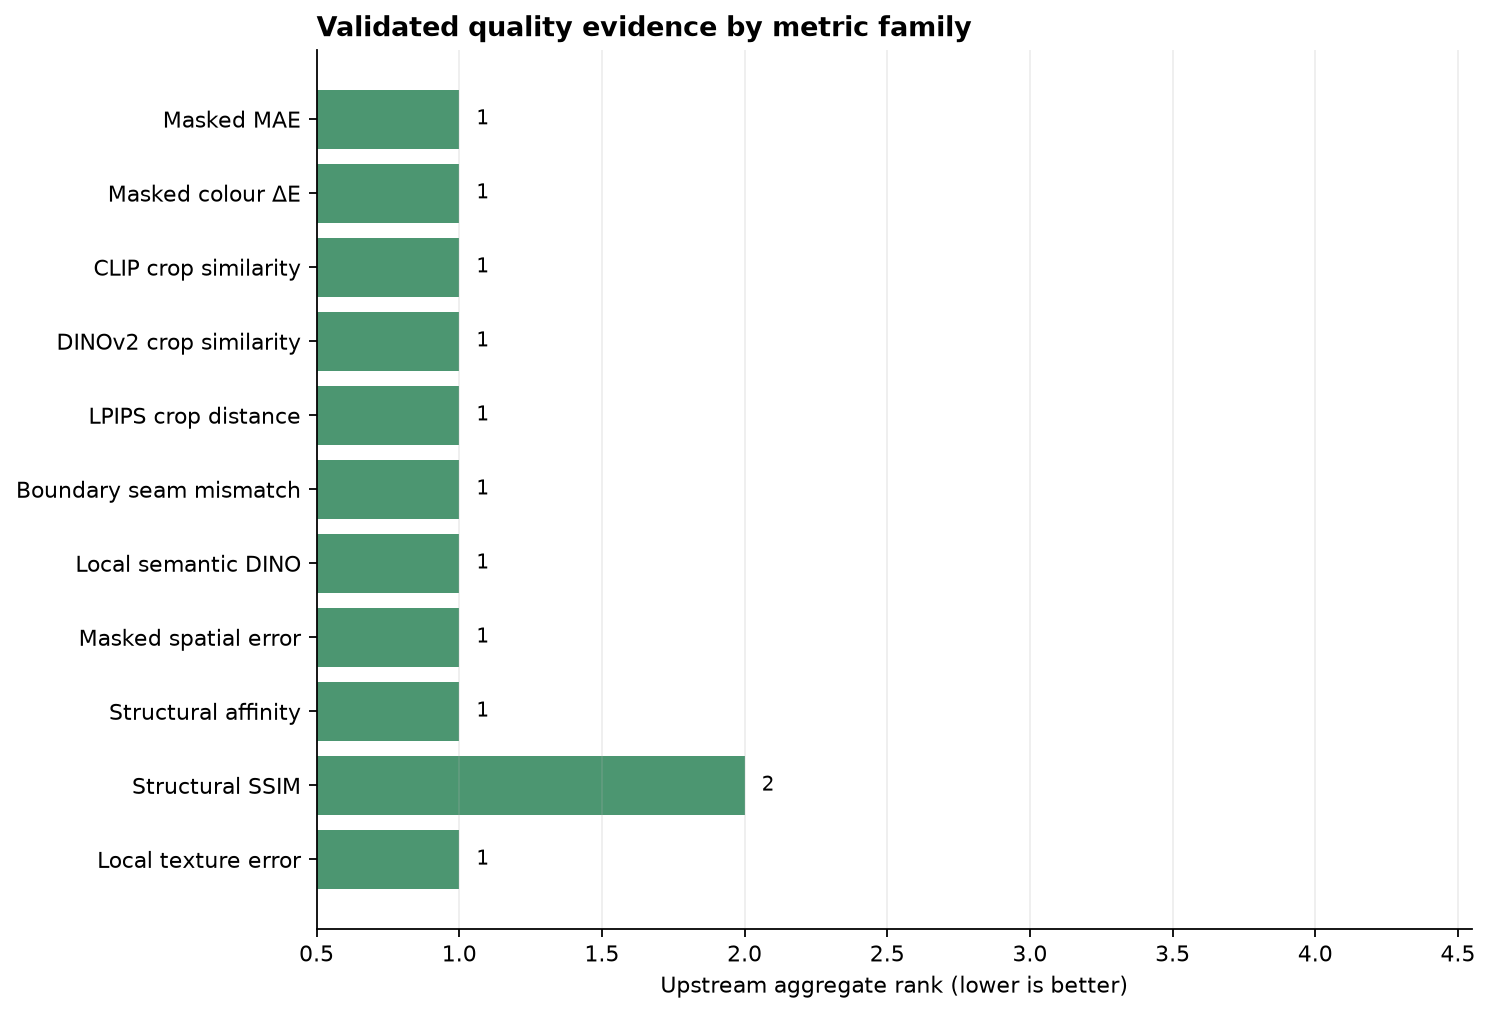

Batch 11 in-memory report assembly complete.
Validation checks: 45
Blocking failures: 0
Warning failures: 0
Reports assembled: 4
Embedded images: 63
Embedded tiles: 298
Canonical files written: 0


In [40]:
VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_11_STAGE
    if "BATCH_11_STAGE" in globals()
    else "batch_11_report_assembly",
)

VALIDATION = reset_validation_stage(
    VALIDATION,
    "rendered_report",
)

BATCH_11_STAGE = (
    "batch_11_report_assembly"
)

REPORT_VALIDATION_PARTS = []
render_summary_records = []

for model_id, report_html in (
    MODEL_REPORT_HTML.items()
):
    helper_checks = (
        validate_model_report_html(
            report_html,
            model_id=model_id,
            config=REPORT_CONFIG,
        )
    )

    REPORT_VALIDATION_PARTS.append(
        helper_checks
    )

    asset_assignments = (
        REPORT_ASSET_ASSIGNMENTS[
            model_id
        ]
    )

    section_ids = re.findall(
        r'<section\s+id="([^"]+)"',
        report_html,
        flags=re.IGNORECASE,
    )

    analytical_count = (
        report_html.count(
            'data-report-role="analytical_view"'
        )
    )

    representative_count = (
        report_html.count(
            'data-report-role="representative_panel"'
        )
    )

    atlas_count = (
        report_html.count(
            'data-report-role="visual_atlas"'
        )
    )

    embedded_image_count = (
        report_html.count(
            "<img "
        )
    )

    tile_counts = [
        int(value)
        for value in re.findall(
            r'data-tile-count="(\d+)"',
            report_html,
        )
    ]

    render_summary_records.append(
        {
            "model_id": model_id,
            "section_count": len(
                section_ids
            ),
            "analytical_view_count": (
                analytical_count
            ),
            "representative_panel_count": (
                representative_count
            ),
            "visual_atlas_count": (
                atlas_count
            ),
            "embedded_image_count": (
                embedded_image_count
            ),
            "embedded_tile_count": int(
                sum(
                    tile_counts
                )
            ),
            "assigned_asset_count": int(
                len(
                    asset_assignments
                )
            ),
            "assigned_tile_count": int(
                asset_assignments[
                    "tile_count"
                ].sum()
            ),
            "size_mib": (
                len(
                    report_html.encode(
                        "utf-8"
                    )
                )
                / (1024 ** 2)
            ),
        }
    )

MODEL_REPORT_VALIDATION = pd.concat(
    REPORT_VALIDATION_PARTS,
    ignore_index=True,
)

extend_helper_checks(
    MODEL_REPORT_VALIDATION,
    description_prefix=(
        "In-memory rendered model report"
    ),
)

REPORT_RENDER_SUMMARY = pd.DataFrame(
    render_summary_records
)

expected_asset_counts = {
    model_id: (
        int(
            MODEL_SPECS[
                model_id
            ][
                "analytical_view_count"
            ]
        )
        + int(
            MODEL_SPECS[
                model_id
            ][
                "representative_panel_count"
            ]
        )
        + int(
            MODEL_SPECS[
                model_id
            ][
                "visual_atlas_count"
            ]
        )
    )
    for model_id in MODEL_SPECS
}

observed_asset_counts = (
    REPORT_RENDER_SUMMARY.set_index(
        "model_id"
    )[
        "assigned_asset_count"
    ]
    .astype(int)
    .to_dict()
)

report_keys_ok = (
    set(
        MODEL_REPORT_HTML
    )
    == set(
        MODEL_SPECS
    )
    and set(
        REPORT_SECTION_HTML
    )
    == set(
        MODEL_SPECS
    )
)

section_maps_ok = all(
    list(
        REPORT_SECTION_HTML[
            model_id
        ]
    )
    == REPORT_SECTION_IDS
    and all(
        str(fragment).strip()
        for fragment in (
            REPORT_SECTION_HTML[
                model_id
            ].values()
        )
    )
    for model_id in MODEL_SPECS
)

asset_assignment_ok = bool(
    observed_asset_counts
    == expected_asset_counts
    and all(
        REPORT_ASSET_ASSIGNMENTS[
            model_id
        ][
            "asset_id"
        ].nunique()
        == len(
            REPORT_ASSET_ASSIGNMENTS[
                model_id
            ]
        )
        for model_id in MODEL_SPECS
    )
)

traceability_ready = bool(
    len(
        MOCK_TRACEABILITY
    )
    == EXPECTED[
        "traceability_rows"
    ]
    == 39
    and MOCK_TRACEABILITY[
        "status"
    ].eq("ok").all()
    and MOCK_TRACEABILITY[
        "implementation_status"
    ].isin(
        {
            "preserved",
            "upgraded_additively",
            "approved_deviation",
        }
    ).all()
)

add_check(
    stage=BATCH_11_STAGE,
    check_id="in_memory_report_identity",
    description=(
        "Exactly one in-memory report and section map "
        "exists for every approved model."
    ),
    expected=sorted(
        MODEL_SPECS
    ),
    observed={
        "reports": sorted(
            MODEL_REPORT_HTML
        ),
        "section_maps": sorted(
            REPORT_SECTION_HTML
        ),
    },
    passed=report_keys_ok,
)

add_check(
    stage=BATCH_11_STAGE,
    check_id="report_section_content_contract",
    description=(
        "Every report retains all fifteen approved "
        "non-empty sections in exact order."
    ),
    expected={
        model_id: (
            REPORT_SECTION_IDS
        )
        for model_id in MODEL_SPECS
    },
    observed={
        model_id: list(
            REPORT_SECTION_HTML[
                model_id
            ]
        )
        for model_id in MODEL_SPECS
    },
    passed=section_maps_ok,
)

add_check(
    stage=BATCH_11_STAGE,
    check_id="report_asset_assignment_contract",
    description=(
        "Every analytical figure, representative panel, "
        "and visual atlas is embedded exactly once."
    ),
    expected=expected_asset_counts,
    observed=observed_asset_counts,
    passed=asset_assignment_ok,
)

add_check(
    stage=BATCH_11_STAGE,
    check_id="mock_traceability_ready",
    description=(
        "All 39 approved mock roles remain ready for "
        "final persisted-report traceability."
    ),
    expected={
        "rows": 39,
        "statuses": [
            "preserved",
            "upgraded_additively",
            "approved_deviation",
        ],
    },
    observed={
        "rows": int(
            len(
                MOCK_TRACEABILITY
            )
        ),
        "implementation_statuses": sorted(
            MOCK_TRACEABILITY[
                "implementation_status"
            ].astype(str).unique()
        ),
    },
    passed=traceability_ready,
)

output_files_after_batch_11 = sorted(
    path
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
)

add_check(
    stage=BATCH_11_STAGE,
    check_id="batch_11_has_no_persistence",
    description=(
        "In-memory report assembly creates no "
        "Notebook 31 output files."
    ),
    expected=0,
    observed=len(
        output_files_after_batch_11
    ),
    passed=(
        len(
            output_files_after_batch_11
        )
        == 0
    ),
)

display(
    REPORT_RENDER_SUMMARY
)

BATCH_11_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_11_ROWS = (
    BATCH_11_VALIDATION.loc[
        BATCH_11_VALIDATION[
            "validation_stage"
        ].isin(
            {
                BATCH_11_STAGE,
                "rendered_report",
            }
        )
    ]
    .reset_index(drop=True)
)

blocking_failures = int(
    (
        BATCH_11_ROWS[
            "severity"
        ].eq("blocking")
        & ~BATCH_11_ROWS[
            "passed"
        ]
    ).sum()
)

warning_failures = int(
    (
        BATCH_11_ROWS[
            "severity"
        ].eq("warning")
        & ~BATCH_11_ROWS[
            "passed"
        ]
    ).sum()
)

display(
    BATCH_11_ROWS.loc[
        ~BATCH_11_ROWS[
            "passed"
        ]
    ]
)

preview_style = """
<style>
.n31-preview{font-family:system-ui,sans-serif;line-height:1.5;color:#172033}
.n31-preview .metric-grid{display:grid;grid-template-columns:repeat(3,minmax(180px,1fr));gap:.7rem}
.n31-preview .metric-card{border:1px solid #d9e0ea;padding:.7rem;background:#f8fafc}
.n31-preview .metric-value{display:block;font-size:1.3rem;font-weight:700}
.n31-preview .conclusion{border-left:5px solid #176b4d;background:#edf9f4;padding:.8rem;margin:.8rem 0}
.n31-preview .limitation{border-left:5px solid #955d13;background:#fff6e8;padding:.8rem;margin:.8rem 0}
.n31-preview .report-visual{border:1px solid #d9e0ea;padding:.7rem}
.n31-preview .report-visual img{max-width:100%;height:auto}
.n31-preview table{border-collapse:collapse;width:100%}
.n31-preview th,.n31-preview td{border:1px solid #d9e0ea;padding:.4rem}
</style>
"""

preview_html = (
    preview_style
    + '<div class="n31-preview">'
    + "<h2>Batch 11 report QA — LaMa</h2>"
    + REPORT_SECTION_HTML[
        "lama"
    ][
        "executive-summary"
    ]
    + "<h2>Overall quality section</h2>"
    + REPORT_SECTION_HTML[
        "lama"
    ][
        "overall-quality"
    ]
    + "</div>"
)

display(
    HTML(
        preview_html
    )
)

print("Batch 11 in-memory report assembly complete.")
print(
    "Validation checks: "
    f"{len(BATCH_11_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{blocking_failures:,}"
)
print(
    "Warning failures: "
    f"{warning_failures:,}"
)
print(
    "Reports assembled: "
    f"{len(MODEL_REPORT_HTML):,}"
)
print(
    "Embedded images: "
    f"{int(REPORT_RENDER_SUMMARY['embedded_image_count'].sum()):,}"
)
print(
    "Embedded tiles: "
    f"{int(REPORT_RENDER_SUMMARY['embedded_tile_count'].sum()):,}"
)
print(
    "Canonical files written: "
    f"{len(output_files_after_batch_11):,}"
)

VALIDATION.raise_for_blocking()

## Batch 12 — Persistence, manifests, and completion gate

This final batch:

- writes the four standalone self-contained HTML reports;
- builds and writes the normalized four-row report index;
- reloads every report and validates its structure, evidence language, visual density, and portability;
- verifies every Notebook 31 roadmap responsibility;
- writes the consolidated validation table;
- registers six canonical scientific/report artifacts;
- writes the completed run manifest;
- reloads all eight canonical files;
- validates artifact and manifest checksums;
- rejects temporary, undeclared, missing, or extra files;
- enforces the final zero-blocking and zero-warning completion gate.

Notebook 31 remains a report-only presentation layer and creates no new scientific evidence.

In [41]:
BATCH_12_PERSISTENCE_STAGE = (
    "batch_12_report_persistence"
)

VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_12_PERSISTENCE_STAGE,
)

VALIDATION = reset_validation_stage(
    VALIDATION,
    "rendered_report",
)

VALIDATION = reset_validation_stage(
    VALIDATION,
    "report_index",
)

GENERATED_AT_UTC = utc_now_iso()

for model_id, report_html in (
    MODEL_REPORT_HTML.items()
):
    atomic_write_text(
        report_html,
        MODEL_REPORT_PATHS[
            model_id
        ],
    )

inventory_path_values = (
    INVENTORY[
        "relative_path"
    ]
    .fillna("")
    .astype(str)
    .str.replace(
        "\\",
        "/",
        regex=False,
    )
)

inventory_checksum_lookup = {
    str(relative_path): str(
        checksum
    )
    for relative_path, checksum
    in zip(
        inventory_path_values,
        INVENTORY[
            "hash_value"
        ].fillna("").astype(str),
    )
    if str(relative_path).strip()
    and str(checksum).strip()
}

upstream_run_ids = {
    notebook_id: str(
        manifest.get(
            "run_id",
            "",
        )
    )
    for notebook_id, manifest
    in sorted(
        MANIFESTS.items()
    )
}

report_index_records = []

for model_id in MODEL_SPECS:
    section_evidence = (
        MODEL_EVIDENCE_PACKETS[
            model_id
        ][
            "section_evidence"
        ]
    )

    source_artifact_paths = sorted(
        {
            source_path
            for payload in (
                section_evidence[
                    "source_paths_json"
                ]
            )
            for source_path in json.loads(
                payload
            )
        }
    )

    source_checksums = {
        relative_path: (
            inventory_checksum_lookup.get(
                relative_path,
                "",
            )
        )
        for relative_path
        in source_artifact_paths
    }

    missing_source_checksums = [
        relative_path
        for relative_path, checksum
        in source_checksums.items()
        if not str(checksum).strip()
    ]

    if missing_source_checksums:
        source_checksums.update(
            {
                relative_path: sha256_file(
                    PROJECT_ROOT
                    / relative_path
                )
                for relative_path
                in missing_source_checksums
            }
        )

    representative_candidate_ids = (
        REPRESENTATIVE_SELECTIONS.loc[
            REPRESENTATIVE_SELECTIONS[
                "model_id"
            ].eq(model_id),
            "candidate_id",
        ]
        .astype(str)
        .tolist()
    )

    report_index_records.append(
        build_report_index_row(
            MODEL_REPORT_PATHS[
                model_id
            ],
            project_root=PROJECT_ROOT,
            model_id=model_id,
            representative_candidate_ids=(
                representative_candidate_ids
            ),
            source_artifact_paths=(
                source_artifact_paths
            ),
            source_checksums=(
                source_checksums
            ),
            upstream_run_ids=(
                upstream_run_ids
            ),
            generated_at_utc=(
                GENERATED_AT_UTC
            ),
            config=REPORT_CONFIG,
        )
    )

REPORT_INDEX = pd.DataFrame(
    report_index_records,
    columns=REPORT_INDEX_COLUMNS,
)

report_index_checks = (
    validate_report_index(
        REPORT_INDEX,
        config=REPORT_CONFIG,
    )
)

extend_helper_checks(
    report_index_checks,
    description_prefix=(
        "Persisted report-index contract"
    ),
)

atomic_write_csv(
    REPORT_INDEX,
    OUTPUT_PATHS[
        "report_index"
    ],
)

PERSISTED_REPORT_INDEX = pd.read_csv(
    OUTPUT_PATHS[
        "report_index"
    ],
    keep_default_na=False,
)

PERSISTED_REPORT_HTML = {
    model_id: (
        MODEL_REPORT_PATHS[
            model_id
        ].read_text(
            encoding="utf-8-sig"
        )
    )
    for model_id in MODEL_SPECS
}

persisted_report_check_parts = []

for model_id, report_html in (
    PERSISTED_REPORT_HTML.items()
):
    persisted_report_check_parts.append(
        validate_model_report_html(
            report_html,
            model_id=model_id,
            config=REPORT_CONFIG,
        )
    )

PERSISTED_REPORT_CHECKS = pd.concat(
    persisted_report_check_parts,
    ignore_index=True,
)

extend_helper_checks(
    PERSISTED_REPORT_CHECKS,
    description_prefix=(
        "Persisted standalone model report"
    ),
)

reloaded_report_index_checks = (
    validate_report_index(
        PERSISTED_REPORT_INDEX,
        config=REPORT_CONFIG,
    )
)

reloaded_report_index_failures = int(
    (
        ~reloaded_report_index_checks[
            "passed"
        ].astype(bool)
        & reloaded_report_index_checks[
            "severity"
        ].eq("blocking")
    ).sum()
)

report_roundtrip_failures = [
    model_id
    for model_id in MODEL_SPECS
    if (
        PERSISTED_REPORT_HTML[
            model_id
        ]
        != MODEL_REPORT_HTML[
            model_id
        ]
    )
]

persisted_primary_files = {
    path.resolve()
    for path in (
        *MODEL_REPORT_PATHS.values(),
        OUTPUT_PATHS[
            "report_index"
        ],
    )
    if path.is_file()
}

expected_primary_files = {
    path.resolve()
    for path in (
        *MODEL_REPORT_PATHS.values(),
        OUTPUT_PATHS[
            "report_index"
        ],
    )
}

temporary_files_after_reports = sorted(
    path.relative_to(
        PROJECT_ROOT
    ).as_posix()
    for path in OUTPUT_ROOT.rglob("*")
    if (
        path.is_file()
        and (
            ".tmp"
            in path.name.casefold()
            or ".building"
            in path.name.casefold()
            or path.suffix.casefold()
            in {
                ".temp",
                ".part",
                ".partial",
            }
            or path.name.startswith(
                "."
            )
        )
    )
)

add_check(
    stage=BATCH_12_PERSISTENCE_STAGE,
    check_id="report_html_roundtrip",
    description=(
        "Every persisted HTML report exactly matches "
        "its validated in-memory document."
    ),
    expected=[],
    observed=(
        report_roundtrip_failures
    ),
    passed=(
        len(
            report_roundtrip_failures
        )
        == 0
    ),
)

add_check(
    stage=BATCH_12_PERSISTENCE_STAGE,
    check_id="reloaded_report_index_contract",
    description=(
        "The reloaded four-row report index retains "
        "its complete canonical schema and density."
    ),
    expected={
        "rows": 4,
        "blocking_failures": 0,
    },
    observed={
        "rows": int(
            len(
                PERSISTED_REPORT_INDEX
            )
        ),
        "blocking_failures": (
            reloaded_report_index_failures
        ),
    },
    passed=bool(
        len(
            PERSISTED_REPORT_INDEX
        )
        == 4
        and reloaded_report_index_failures
        == 0
    ),
)

add_check(
    stage=BATCH_12_PERSISTENCE_STAGE,
    check_id="primary_persisted_file_set",
    description=(
        "The four reports and report index are the "
        "exact five primary persisted files at this stage."
    ),
    expected=sorted(
        path.relative_to(
            PROJECT_ROOT
        ).as_posix()
        for path
        in expected_primary_files
    ),
    observed=sorted(
        path.relative_to(
            PROJECT_ROOT
        ).as_posix()
        for path
        in persisted_primary_files
    ),
    passed=(
        persisted_primary_files
        == expected_primary_files
    ),
)

add_check(
    stage=BATCH_12_PERSISTENCE_STAGE,
    check_id="report_persistence_temporary_files",
    description=(
        "Report persistence leaves no temporary or "
        "partially written files."
    ),
    expected=[],
    observed=(
        temporary_files_after_reports
    ),
    passed=(
        len(
            temporary_files_after_reports
        )
        == 0
    ),
)

display(
    PERSISTED_REPORT_INDEX[
        [
            "model_id",
            "evaluation_status",
            "size_bytes",
            "section_count",
            "embedded_image_count",
            "embedded_tile_count",
            "analytical_view_count",
            "representative_panel_count",
            "visual_atlas_count",
            "self_contained",
            "status",
        ]
    ]
)

BATCH_12_PERSISTENCE_ROWS = (
    VALIDATION.to_dataframe()
)

BATCH_12_PERSISTENCE_ROWS = (
    BATCH_12_PERSISTENCE_ROWS.loc[
        BATCH_12_PERSISTENCE_ROWS[
            "validation_stage"
        ].isin(
            {
                BATCH_12_PERSISTENCE_STAGE,
                "rendered_report",
                "report_index",
            }
        )
    ]
    .reset_index(drop=True)
)

blocking_failures = int(
    (
        BATCH_12_PERSISTENCE_ROWS[
            "severity"
        ].eq("blocking")
        & ~BATCH_12_PERSISTENCE_ROWS[
            "passed"
        ]
    ).sum()
)

warning_failures = int(
    (
        BATCH_12_PERSISTENCE_ROWS[
            "severity"
        ].eq("warning")
        & ~BATCH_12_PERSISTENCE_ROWS[
            "passed"
        ]
    ).sum()
)

display(
    BATCH_12_PERSISTENCE_ROWS.loc[
        ~BATCH_12_PERSISTENCE_ROWS[
            "passed"
        ]
    ]
)

print("Reports and report index persisted and reloaded.")
print(
    "Validation checks: "
    f"{len(BATCH_12_PERSISTENCE_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{blocking_failures:,}"
)
print(
    "Warning failures: "
    f"{warning_failures:,}"
)
print(
    "Reports: "
    f"{len(PERSISTED_REPORT_HTML):,}"
)
print(
    "Report-index rows: "
    f"{len(PERSISTED_REPORT_INDEX):,}"
)

VALIDATION.raise_for_blocking()

,model_id,evaluation_status,size_bytes,section_count,embedded_image_count,embedded_tile_count,analytical_view_count,representative_panel_count,visual_atlas_count,self_contained,status
0,opencv_telea,fully_evaluated,2636615,15,16,76,6,8,2,True,ok
1,lama,fully_evaluated,2550069,15,16,76,6,8,2,True,ok
2,stable_diffusion_inpainting,fully_evaluated,3073545,15,19,90,7,10,2,True,ok
3,sdxl_inpainting,partial_evaluation,2003761,15,12,56,4,6,2,True,ok


,validation_stage,check_id,check_description,severity,expected,observed,passed,details


Reports and report index persisted and reloaded.
Validation checks: 51
Blocking failures: 0
Warning failures: 0
Reports: 4
Report-index rows: 4


In [42]:
BATCH_12_FINAL_STAGE = (
    "batch_12_final_traceability"
)

VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_12_FINAL_STAGE,
)

roadmap_records = []


def add_roadmap_record(
    responsibility_id: str,
    responsibility: str,
    *,
    expected,
    observed,
    passed: bool,
    evidence: str,
) -> None:
    """Register one Notebook 31 roadmap responsibility."""
    roadmap_records.append(
        {
            "responsibility_id": (
                responsibility_id
            ),
            "responsibility": (
                responsibility
            ),
            "expected": expected,
            "observed": observed,
            "passed": bool(
                passed
            ),
            "evidence": evidence,
        }
    )


add_roadmap_record(
    "four_parameterized_reports",
    "One standalone report per approved model",
    expected=4,
    observed=len(
        PERSISTED_REPORT_HTML
    ),
    passed=(
        len(
            PERSISTED_REPORT_HTML
        )
        == 4
    ),
    evidence=(
        "reports/opencv_telea.html, reports/lama.html, "
        "reports/stable_diffusion_inpainting.html, "
        "reports/sdxl_inpainting.html"
    ),
)

add_roadmap_record(
    "method_card_summary",
    "Method identity, role, strengths, weaknesses, and uses",
    expected=4,
    observed=int(
        REPORT_CONCLUSION_REGISTRY.loc[
            REPORT_CONCLUSION_REGISTRY[
                "section_id"
            ].eq(
                "method-identity"
            )
        ][
            "model_id"
        ].nunique()
    ),
    passed=bool(
        REPORT_CONCLUSION_REGISTRY.loc[
            REPORT_CONCLUSION_REGISTRY[
                "section_id"
            ].eq(
                "method-identity"
            )
        ][
            "model_id"
        ].nunique()
        == 4
    ),
    evidence=(
        "Notebook 30 model cards and report section 1"
    ),
)

add_roadmap_record(
    "coverage_and_applicability",
    "Eligible scope and model-specific applicability",
    expected=28,
    observed=len(
        APPLICABILITY_MATRIX
    ),
    passed=(
        len(
            APPLICABILITY_MATRIX
        )
        == 28
        and APPLICABILITY_MATRIX[
            "status"
        ].eq("ok").all()
    ),
    evidence=(
        "seven applicability components for four models"
    ),
)

add_roadmap_record(
    "quality_evidence",
    "Classical, LPIPS, feature, spatial, and comparative quality evidence",
    expected=44,
    observed=int(
        sum(
            len(
                analytical_rows(
                    model_id,
                    "overall_quality",
                )
            )
            for model_id in MODEL_SPECS
        )
    ),
    passed=bool(
        all(
            len(
                analytical_rows(
                    model_id,
                    "overall_quality",
                )
            )
            == 11
            for model_id in MODEL_SPECS
        )
    ),
    evidence=(
        "eleven quality anchors per model report"
    ),
)

add_roadmap_record(
    "damage_and_robustness",
    "Damage size, mask robustness, and synthetic-degradation evidence",
    expected={
        "core_damage_rows": 33,
        "core_mask_rows": 33,
        "core_degradation_rows": 99,
        "sdxl_degradation_rows": 11,
    },
    observed={
        "core_damage_rows": int(
            sum(
                len(
                    analytical_rows(
                        model_id,
                        "damage_size",
                    )
                )
                for model_id in [
                    "opencv_telea",
                    "lama",
                    "stable_diffusion_inpainting",
                ]
            )
        ),
        "core_mask_rows": int(
            sum(
                len(
                    analytical_rows(
                        model_id,
                        "mask_robustness",
                    )
                )
                for model_id in [
                    "opencv_telea",
                    "lama",
                    "stable_diffusion_inpainting",
                ]
            )
        ),
        "core_degradation_rows": int(
            sum(
                len(
                    analytical_rows(
                        model_id,
                        "synthetic_degradation",
                    )
                )
                for model_id in [
                    "opencv_telea",
                    "lama",
                    "stable_diffusion_inpainting",
                ]
            )
        ),
        "sdxl_degradation_rows": int(
            len(
                analytical_rows(
                    "sdxl_inpainting",
                    "synthetic_degradation",
                )
            )
        ),
    },
    passed=bool(
        sum(
            len(
                analytical_rows(
                    model_id,
                    "damage_size",
                )
            )
            for model_id in [
                "opencv_telea",
                "lama",
                "stable_diffusion_inpainting",
            ]
        )
        == 33
        and sum(
            len(
                analytical_rows(
                    model_id,
                    "mask_robustness",
                )
            )
            for model_id in [
                "opencv_telea",
                "lama",
                "stable_diffusion_inpainting",
            ]
        )
        == 33
        and sum(
            len(
                analytical_rows(
                    model_id,
                    "synthetic_degradation",
                )
            )
            for model_id in [
                "opencv_telea",
                "lama",
                "stable_diffusion_inpainting",
            ]
        )
        == 99
        and len(
            analytical_rows(
                "sdxl_inpainting",
                "synthetic_degradation",
            )
        )
        == 11
    ),
    evidence=(
        "Notebook 23–25 validated analytical views"
    ),
)

add_roadmap_record(
    "local_semantic_structural",
    "Texture, colour, seam, semantic, and structural evidence",
    expected={
        "local_rows": 12,
        "semantic_structural_rows": 12,
    },
    observed={
        "local_rows": int(
            sum(
                len(
                    analytical_rows(
                        model_id,
                        "texture_colour_seam",
                    )
                )
                for model_id in MODEL_SPECS
            )
        ),
        "semantic_structural_rows": int(
            sum(
                len(
                    analytical_rows(
                        model_id,
                        "semantic_structural",
                    )
                )
                for model_id in MODEL_SPECS
            )
        ),
    },
    passed=bool(
        sum(
            len(
                analytical_rows(
                    model_id,
                    "texture_colour_seam",
                )
            )
            for model_id in MODEL_SPECS
        )
        == 12
        and sum(
            len(
                analytical_rows(
                    model_id,
                    "semantic_structural",
                )
            )
            for model_id in MODEL_SPECS
        )
        == 12
    ),
    evidence=(
        "Notebook 17 and 20 evidence through Notebook 21"
    ),
)

add_roadmap_record(
    "uncertainty_and_prompt_scope",
    "Diffusion uncertainty and prompt applicability",
    expected={
        "stable_diffusion_groups": 165,
        "deterministic_models": (
            "not_applicable"
        ),
        "sdxl": (
            "insufficient_seed_coverage"
        ),
    },
    observed={
        "stable_diffusion_groups": int(
            REPORT_NUMERICAL_SUMMARY.loc[
                REPORT_NUMERICAL_SUMMARY[
                    "model_id"
                ].eq(
                    "stable_diffusion_inpainting"
                ),
                "uncertainty_group_count",
            ].iloc[0]
        ),
        "telea": (
            applicability_lookup[
                (
                    "opencv_telea",
                    "repeated_seed_uncertainty",
                )
            ]
        ),
        "lama": (
            applicability_lookup[
                (
                    "lama",
                    "repeated_seed_uncertainty",
                )
            ]
        ),
        "sdxl": (
            applicability_lookup[
                (
                    "sdxl_inpainting",
                    "repeated_seed_uncertainty",
                )
            ]
        ),
    },
    passed=bool(
        int(
            REPORT_NUMERICAL_SUMMARY.loc[
                REPORT_NUMERICAL_SUMMARY[
                    "model_id"
                ].eq(
                    "stable_diffusion_inpainting"
                ),
                "uncertainty_group_count",
            ].iloc[0]
        )
        == 165
        and applicability_lookup[
            (
                "opencv_telea",
                "repeated_seed_uncertainty",
            )
        ]
        == "not_applicable_deterministic_method"
        and applicability_lookup[
            (
                "lama",
                "repeated_seed_uncertainty",
            )
        ]
        == "not_applicable_deterministic_method"
        and applicability_lookup[
            (
                "sdxl_inpainting",
                "repeated_seed_uncertainty",
            )
        ]
        == "not_applicable_insufficient_seed_coverage"
    ),
    evidence=(
        "Notebook 18 and 22 uncertainty evidence"
    ),
)

add_roadmap_record(
    "representative_and_explanation_evidence",
    "Representative successes, failures, maps, and atlases",
    expected={
        "representative_panels": 32,
        "visual_atlases": 8,
        "embedded_tiles": 298,
    },
    observed={
        "representative_panels": int(
            len(
                REPRESENTATIVE_PANEL_ASSETS
            )
        ),
        "visual_atlases": int(
            len(
                VISUAL_ATLAS_ASSETS
            )
        ),
        "embedded_tiles": int(
            PERSISTED_REPORT_INDEX[
                "embedded_tile_count"
            ].sum()
        ),
    },
    passed=bool(
        len(
            REPRESENTATIVE_PANEL_ASSETS
        )
        == 32
        and len(
            VISUAL_ATLAS_ASSETS
        )
        == 8
        and int(
            PERSISTED_REPORT_INDEX[
                "embedded_tile_count"
            ].sum()
        )
        == 298
    ),
    evidence=(
        "deterministic report selections and embedded diagnostics"
    ),
)

add_roadmap_record(
    "failure_taxonomy_and_flags",
    "Failure taxonomy and triggered trustworthiness flags",
    expected=4,
    observed=int(
        REPORT_NUMERICAL_SUMMARY.loc[
            REPORT_NUMERICAL_SUMMARY[
                "flag_catalog_candidate_count"
            ].gt(0),
            "model_id",
        ].nunique()
    ),
    passed=bool(
        REPORT_NUMERICAL_SUMMARY[
            "flag_catalog_candidate_count"
        ].gt(0).all()
        and REPORT_NUMERICAL_SUMMARY[
            "triggered_flag_candidate_count"
        ].gt(0).all()
    ),
    evidence=(
        "Notebook 27 failure and trustworthiness evidence"
    ),
)

add_roadmap_record(
    "compute_and_scalability",
    "Observed compute and transparent scaling projections",
    expected={
        "models": 4,
        "observed_rows": 4,
        "projection_rows": 4,
    },
    observed={
        "models": int(
            REPORT_NUMERICAL_SUMMARY[
                "model_id"
            ].nunique()
        ),
        "observed_rows": int(
            COMPUTE_SCALABILITY[
                "scenario_id"
            ].eq(
                "observed_overall_all"
            ).sum()
        ),
        "projection_rows": int(
            COMPUTE_SCALABILITY[
                "scenario_id"
            ].eq(
                "projected_300_canonical_primary"
            ).sum()
        ),
    },
    passed=bool(
        REPORT_NUMERICAL_SUMMARY[
            "model_id"
        ].nunique()
        == 4
        and COMPUTE_SCALABILITY[
            "scenario_id"
        ].eq(
            "observed_overall_all"
        ).sum()
        == 4
        and COMPUTE_SCALABILITY[
            "scenario_id"
        ].eq(
            "projected_300_canonical_primary"
        ).sum()
        == 4
    ),
    evidence=(
        "Notebook 30 compute and scalability records"
    ),
)

add_roadmap_record(
    "limitations_and_decision_support",
    "Known limitations and bounded human-review actions",
    expected=4,
    observed=int(
        REPORT_CONCLUSION_REGISTRY.loc[
            REPORT_CONCLUSION_REGISTRY[
                "section_id"
            ].isin(
                {
                    "decision-support",
                    "limitations",
                }
            )
        ][
            "model_id"
        ].nunique()
    ),
    passed=bool(
        REPORT_CONCLUSION_REGISTRY.loc[
            REPORT_CONCLUSION_REGISTRY[
                "section_id"
            ].isin(
                {
                    "decision-support",
                    "limitations",
                }
            )
        ]
        .groupby(
            "model_id"
        )[
            "section_id"
        ]
        .nunique()
        .eq(2)
        .all()
    ),
    evidence=(
        "model-card limitations and section-level review actions"
    ),
)

add_roadmap_record(
    "mock_fidelity_and_portability",
    "Approved mock fidelity and standalone portability",
    expected={
        "traceability_rows": 39,
        "external_dependencies": 0,
        "reports": 4,
    },
    observed={
        "traceability_rows": int(
            len(
                MOCK_TRACEABILITY
            )
        ),
        "external_dependencies": int(
            sum(
                report_html.count(
                    'src="../'
                )
                + report_html.count(
                    'src="outputs/'
                )
                for report_html
                in PERSISTED_REPORT_HTML.values()
            )
        ),
        "reports": int(
            len(
                PERSISTED_REPORT_HTML
            )
        ),
    },
    passed=bool(
        len(
            MOCK_TRACEABILITY
        )
        == 39
        and len(
            PERSISTED_REPORT_HTML
        )
        == 4
        and all(
            'src="data:image/'
            in report_html
            for report_html
            in PERSISTED_REPORT_HTML.values()
        )
    ),
    evidence=(
        "mock traceability and self-contained HTML validation"
    ),
)

add_roadmap_record(
    "report_only_evidence_policy",
    "No new scientific evidence, ranking, metric, or test",
    expected=False,
    observed=(
        EVIDENCE_POLICY[
            "creates_new_scientific_evidence"
        ]
    ),
    passed=(
        EVIDENCE_POLICY[
            "creates_new_scientific_evidence"
        ]
        is False
    ),
    evidence=(
        "presentation-only filtering, formatting, and assembly"
    ),
)

ROADMAP_TRACEABILITY = pd.DataFrame(
    roadmap_records
)

roadmap_failures = int(
    (
        ~ROADMAP_TRACEABILITY[
            "passed"
        ].astype(bool)
    ).sum()
)

add_check(
    stage=BATCH_12_FINAL_STAGE,
    check_id="roadmap_responsibility_completion",
    description=(
        "Every Notebook 31 roadmap responsibility "
        "has explicit passing evidence."
    ),
    expected=0,
    observed=roadmap_failures,
    passed=(
        roadmap_failures
        == 0
    ),
    details={
        "failures": (
            ROADMAP_TRACEABILITY.loc[
                ~ROADMAP_TRACEABILITY[
                    "passed"
                ]
            ].to_dict("records")
        )
    },
)

add_check(
    stage=BATCH_12_FINAL_STAGE,
    check_id="mock_traceability_final_contract",
    description=(
        "All 39 approved mock roles remain represented "
        "without an unapproved structural deviation."
    ),
    expected={
        "rows": 39,
        "invalid_statuses": 0,
        "unexplained_deviations": 0,
    },
    observed={
        "rows": int(
            len(
                MOCK_TRACEABILITY
            )
        ),
        "invalid_statuses": int(
            ~MOCK_TRACEABILITY[
                "implementation_status"
            ].isin(
                {
                    "preserved",
                    "upgraded_additively",
                    "approved_deviation",
                }
            ).sum()
        )
        if False
        else int(
            (
                ~MOCK_TRACEABILITY[
                    "implementation_status"
                ].isin(
                    {
                        "preserved",
                        "upgraded_additively",
                        "approved_deviation",
                    }
                )
            ).sum()
        ),
        "unexplained_deviations": int(
            (
                MOCK_TRACEABILITY[
                    "implementation_status"
                ].eq(
                    "approved_deviation"
                )
                & MOCK_TRACEABILITY[
                    "deviation_reason"
                ]
                .fillna("")
                .astype(str)
                .str.strip()
                .eq("")
            ).sum()
        ),
    },
    passed=bool(
        len(
            MOCK_TRACEABILITY
        )
        == 39
        and MOCK_TRACEABILITY[
            "implementation_status"
        ].isin(
            {
                "preserved",
                "upgraded_additively",
                "approved_deviation",
            }
        ).all()
        and not (
            MOCK_TRACEABILITY[
                "implementation_status"
            ].eq(
                "approved_deviation"
            )
            & MOCK_TRACEABILITY[
                "deviation_reason"
            ]
            .fillna("")
            .astype(str)
            .str.strip()
            .eq("")
        ).any()
    ),
)

pre_manifest_validation = (
    VALIDATION.to_dataframe()
)

pre_manifest_blocking_failures = int(
    (
        pre_manifest_validation[
            "severity"
        ].eq("blocking")
        & ~pre_manifest_validation[
            "passed"
        ]
    ).sum()
)

pre_manifest_warning_failures = int(
    (
        pre_manifest_validation[
            "severity"
        ].eq("warning")
        & ~pre_manifest_validation[
            "passed"
        ]
    ).sum()
)

add_check(
    stage=BATCH_12_FINAL_STAGE,
    check_id="pre_manifest_validation_gate",
    description=(
        "All scientific, report, portability, and "
        "traceability checks pass before manifest writing."
    ),
    expected={
        "blocking_failures": 0,
        "warning_failures": 0,
    },
    observed={
        "blocking_failures": (
            pre_manifest_blocking_failures
        ),
        "warning_failures": (
            pre_manifest_warning_failures
        ),
    },
    passed=bool(
        pre_manifest_blocking_failures
        == 0
        and pre_manifest_warning_failures
        == 0
    ),
)

VALIDATION.raise_for_blocking()

FINAL_VALIDATION = (
    VALIDATION.to_dataframe()
)

atomic_write_csv(
    FINAL_VALIDATION,
    OUTPUT_PATHS[
        "validation"
    ],
)

artifact_record_payloads = []

for model_id, report_path in (
    MODEL_REPORT_PATHS.items()
):
    artifact_record_payloads.append(
        build_artifact_record(
            artifact_key=(
                f"model_report_{model_id}"
            ),
            producer_notebook=(
                SETTINGS[
                    "notebook_id"
                ]
            ),
            path=report_path,
            artifact_type=(
                "standalone_html_report"
            ),
            artifact_role=(
                "model_specific_evaluation_report"
            ),
            schema_version=(
                "model_report_html.v1"
            ),
            dataset_scope=(
                SETTINGS[
                    "dataset_scope"
                ]
            ),
            project_root=(
                PROJECT_ROOT
            ),
        )
    )

artifact_record_payloads.extend(
    [
        build_artifact_record(
            artifact_key="report_index",
            producer_notebook=(
                SETTINGS[
                    "notebook_id"
                ]
            ),
            path=OUTPUT_PATHS[
                "report_index"
            ],
            artifact_type="csv",
            artifact_role=(
                "model_report_registry"
            ),
            schema_version=(
                REPORT_INDEX_SCHEMA_VERSION
            ),
            dataset_scope=(
                SETTINGS[
                    "dataset_scope"
                ]
            ),
            row_count=len(
                PERSISTED_REPORT_INDEX
            ),
            project_root=(
                PROJECT_ROOT
            ),
        ),
        build_artifact_record(
            artifact_key="validation",
            producer_notebook=(
                SETTINGS[
                    "notebook_id"
                ]
            ),
            path=OUTPUT_PATHS[
                "validation"
            ],
            artifact_type="csv",
            artifact_role=(
                "consolidated_validation_evidence"
            ),
            schema_version=(
                "validation_checks.v1"
            ),
            dataset_scope=(
                SETTINGS[
                    "dataset_scope"
                ]
            ),
            row_count=len(
                FINAL_VALIDATION
            ),
            project_root=(
                PROJECT_ROOT
            ),
        ),
    ]
)

FINAL_ARTIFACT_RECORDS = (
    artifact_records_dataframe(
        artifact_record_payloads
    )
)

atomic_write_csv(
    FINAL_ARTIFACT_RECORDS,
    OUTPUT_PATHS[
        "artifacts"
    ],
)

manifest_input_records = []

for input_key, input_path in (
    sorted(
        INPUT_PATHS.items()
    )
):
    relative_path = (
        input_path.relative_to(
            PROJECT_ROOT
        ).as_posix()
    )

    checksum = (
        inventory_checksum_lookup.get(
            relative_path,
            "",
        )
    )

    if not checksum:
        checksum = sha256_file(
            input_path
        )

    manifest_input_records.append(
        {
            "input_key": input_key,
            "relative_path": (
                relative_path
            ),
            "checksum": checksum,
        }
    )

manifest_output_records = [
    {
        "artifact_key": (
            f"model_report_{model_id}"
        ),
        "relative_path": (
            MODEL_REPORT_PATHS[
                model_id
            ]
            .relative_to(
                PROJECT_ROOT
            )
            .as_posix()
        ),
        "artifact_type": (
            "standalone_html_report"
        ),
    }
    for model_id in MODEL_SPECS
]

manifest_output_records.extend(
    [
        {
            "artifact_key": (
                "report_index"
            ),
            "relative_path": (
                OUTPUT_PATHS[
                    "report_index"
                ]
                .relative_to(
                    PROJECT_ROOT
                )
                .as_posix()
            ),
            "artifact_type": "csv",
        },
        {
            "artifact_key": (
                "run_manifest"
            ),
            "relative_path": (
                OUTPUT_PATHS[
                    "run_manifest"
                ]
                .relative_to(
                    PROJECT_ROOT
                )
                .as_posix()
            ),
            "artifact_type": "json",
        },
        {
            "artifact_key": (
                "artifacts"
            ),
            "relative_path": (
                OUTPUT_PATHS[
                    "artifacts"
                ]
                .relative_to(
                    PROJECT_ROOT
                )
                .as_posix()
            ),
            "artifact_type": "csv",
        },
        {
            "artifact_key": (
                "validation"
            ),
            "relative_path": (
                OUTPUT_PATHS[
                    "validation"
                ]
                .relative_to(
                    PROJECT_ROOT
                )
                .as_posix()
            ),
            "artifact_type": "csv",
        },
    ]
)

configuration_paths = [
    CONFIG_PATH,
]

configuration_checksums_by_path = (
    configuration_checksums(
        configuration_paths,
        PROJECT_ROOT,
    )
)

RUN_COMPLETED_AT_UTC = utc_now_iso()

observed_counts = {
    "model_count": int(
        len(
            MODEL_SPECS
        )
    ),
    "report_count": int(
        len(
            PERSISTED_REPORT_HTML
        )
    ),
    "report_index_rows": int(
        len(
            PERSISTED_REPORT_INDEX
        )
    ),
    "section_rows": int(
        len(
            REPORT_CONCLUSION_REGISTRY
        )
    ),
    "mock_traceability_rows": int(
        len(
            MOCK_TRACEABILITY
        )
    ),
    "analytical_views": int(
        len(
            ANALYTICAL_VIEW_ASSETS
        )
    ),
    "representative_panels": int(
        len(
            REPRESENTATIVE_PANEL_ASSETS
        )
    ),
    "visual_atlases": int(
        len(
            VISUAL_ATLAS_ASSETS
        )
    ),
    "embedded_images": int(
        PERSISTED_REPORT_INDEX[
            "embedded_image_count"
        ].sum()
    ),
    "embedded_tiles": int(
        PERSISTED_REPORT_INDEX[
            "embedded_tile_count"
        ].sum()
    ),
    "artifact_records": int(
        len(
            FINAL_ARTIFACT_RECORDS
        )
    ),
    "validation_rows": int(
        len(
            FINAL_VALIDATION
        )
    ),
    "roadmap_responsibilities": int(
        len(
            ROADMAP_TRACEABILITY
        )
    ),
    "physical_output_files": int(
        EXPECTED[
            "physical_output_files"
        ]
    ),
}

FINAL_RUN_MANIFEST = build_run_manifest(
    notebook_id=SETTINGS[
        "notebook_id"
    ],
    notebook_name=SETTINGS[
        "notebook_stem"
    ],
    origin=(
        "Consolidates Existing Notebooks "
        "13, 19, and 26"
    ),
    run_status="completed",
    started_at_utc=(
        RUN_STARTED_AT_UTC
    ),
    completed_at_utc=(
        RUN_COMPLETED_AT_UTC
    ),
    inventory_run_id=str(
        INVENTORY_RUN[
            "inventory_run_id"
        ]
    ),
    dataset_versions={
        "dataset_id": (
            SETTINGS[
                "dataset_id"
            ]
        ),
        "dataset_version": (
            SETTINGS[
                "dataset_version"
            ]
        ),
        "dataset_scope": (
            SETTINGS[
                "dataset_scope"
            ]
        ),
        "configuration_version": (
            REPORT_CONFIG[
                "config_version"
            ]
        ),
        "configuration_schema_version": (
            CONFIG_SCHEMA_VERSION
        ),
        "report_index_schema_version": (
            REPORT_INDEX_SCHEMA_VERSION
        ),
        "mock_traceability_schema_version": (
            TRACEABILITY_SCHEMA_VERSION
        ),
        "upstream_run_ids": (
            upstream_run_ids
        ),
    },
    configuration_paths=[
        path.relative_to(
            PROJECT_ROOT
        ).as_posix()
        for path in configuration_paths
    ],
    configuration_checksums_by_path=(
        configuration_checksums_by_path
    ),
    helper_versions={
        "model_report_generation": (
            MODULE_VERSION
        ),
        "report_index_schema": (
            REPORT_INDEX_SCHEMA_VERSION
        ),
        "selection_schema": (
            SELECTION_SCHEMA_VERSION
        ),
        "traceability_schema": (
            TRACEABILITY_SCHEMA_VERSION
        ),
    },
    inputs=manifest_input_records,
    outputs=manifest_output_records,
    expected_counts=dict(
        EXPECTED
    ),
    observed_counts=(
        observed_counts
    ),
    validation_summary=(
        VALIDATION.summary()
    ),
    known_limitations=list(
        SETTINGS[
            "known_limitations"
        ]
    ),
    project_root=PROJECT_ROOT,
    package_names=(
        "numpy",
        "pandas",
        "matplotlib",
        "Pillow",
        "PyYAML",
    ),
    hardware={
        "analysis_mode": (
            "presentation_only_model_report_generation"
        ),
        "restoration_inference_performed": (
            False
        ),
        "new_metric_computation_performed": (
            False
        ),
        "new_statistical_test_performed": (
            False
        ),
        "self_contained_html": (
            True
        ),
    },
)

FINAL_RUN_MANIFEST.update(
    {
        "validation_status": (
            "passed"
        ),
        "refactor_status": (
            "refactored"
        ),
        "completion_gate_passed": (
            True
        ),
        "creates_new_scientific_evidence": (
            False
        ),
        "output_checksums": {
            str(
                record[
                    "artifact_key"
                ]
            ): str(
                record[
                    "checksum"
                ]
            )
            for record in (
                FINAL_ARTIFACT_RECORDS
                .to_dict("records")
            )
        },
        "artifact_manifest_checksum": (
            sha256_file(
                OUTPUT_PATHS[
                    "artifacts"
                ]
            )
        ),
        "roadmap_requirement_count": int(
            len(
                ROADMAP_TRACEABILITY
            )
        ),
        "roadmap_traceability_failures": (
            roadmap_failures
        ),
        "report_contract": {
            "format": (
                "self_contained_html"
            ),
            "report_count": int(
                len(
                    PERSISTED_REPORT_HTML
                )
            ),
            "sections_per_report": int(
                len(
                    REPORT_SECTION_IDS
                )
            ),
            "mock_traceability_rows": int(
                len(
                    MOCK_TRACEABILITY
                )
            ),
            "embedded_image_count": int(
                PERSISTED_REPORT_INDEX[
                    "embedded_image_count"
                ].sum()
            ),
            "embedded_tile_count": int(
                PERSISTED_REPORT_INDEX[
                    "embedded_tile_count"
                ].sum()
            ),
            "external_image_dependencies": (
                0
            ),
        },
    }
)

atomic_write_text(
    json.dumps(
        FINAL_RUN_MANIFEST,
        indent=2,
        ensure_ascii=False,
    )
    + "\n",
    OUTPUT_PATHS[
        "run_manifest"
    ],
)

display(
    ROADMAP_TRACEABILITY
)

display(
    FINAL_ARTIFACT_RECORDS
)

print("Final validation, artifacts, and run manifest written.")
print(
    "Validation rows: "
    f"{len(FINAL_VALIDATION):,}"
)
print(
    "Artifact records: "
    f"{len(FINAL_ARTIFACT_RECORDS):,}"
)
print(
    "Roadmap responsibilities: "
    f"{len(ROADMAP_TRACEABILITY):,}"
)
print(
    "Roadmap failures: "
    f"{roadmap_failures:,}"
)

,responsibility_id,responsibility,expected,observed,passed,evidence
0,four_parameterized_reports,One standalone report per approved model,4,4,True,"reports/opencv_telea.html, reports/lama.html, reports/stable_diffusion_inpainting.html, reports/sdxl_inpainting.html"
1,method_card_summary,"Method identity, role, strengths, weaknesses, and uses",4,4,True,Notebook 30 model cards and report section 1
2,coverage_and_applicability,Eligible scope and model-specific applicability,28,28,True,seven applicability components for four models
3,quality_evidence,"Classical, LPIPS, feature, spatial, and comparative quality evidence",44,44,True,eleven quality anchors per model report
4,damage_and_robustness,"Damage size, mask robustness, and synthetic-degradation evidence","{'core_damage_rows': 33, 'core_mask_rows': 33, 'core_degradation_rows': 99, 'sdxl_degradation_rows': 11}","{'core_damage_rows': 33, 'core_mask_rows': 33, 'core_degradation_rows': 99, 'sdxl_degradation_rows': 11}",True,Notebook 23–25 validated analytical views
5,local_semantic_structural,"Texture, colour, seam, semantic, and structural evidence","{'local_rows': 12, 'semantic_structural_rows': 12}","{'local_rows': 12, 'semantic_structural_rows': 12}",True,Notebook 17 and 20 evidence through Notebook 21
6,uncertainty_and_prompt_scope,Diffusion uncertainty and prompt applicability,"{'stable_diffusion_groups': 165, 'deterministic_models': 'not_applicable', 'sdxl': 'insufficient_seed_coverage'}","{'stable_diffusion_groups': 165, 'telea': 'not_applicable_deterministic_method', 'lama': 'not_applicable_deterministic_method', 'sdxl': 'not_applicable_insufficient_seed_covera...",True,Notebook 18 and 22 uncertainty evidence
7,representative_and_explanation_evidence,"Representative successes, failures, maps, and atlases","{'representative_panels': 32, 'visual_atlases': 8, 'embedded_tiles': 298}","{'representative_panels': 32, 'visual_atlases': 8, 'embedded_tiles': 298}",True,deterministic report selections and embedded diagnostics
8,failure_taxonomy_and_flags,Failure taxonomy and triggered trustworthiness flags,4,4,True,Notebook 27 failure and trustworthiness evidence
9,compute_and_scalability,Observed compute and transparent scaling projections,"{'models': 4, 'observed_rows': 4, 'projection_rows': 4}","{'models': 4, 'observed_rows': 4, 'projection_rows': 4}",True,Notebook 30 compute and scalability records


,artifact_id,artifact_key,producer_notebook,artifact_type,artifact_role,relative_path,format,dataset_scope,experiment_id,schema_version,row_count,file_count,size_bytes,checksum,validation_status
0,artifact_30c461e885621fcd35be,model_report_opencv_telea,31,standalone_html_report,model_specific_evaluation_report,outputs/31_model_report_generation/reports/opencv_telea.html,html,controlled_50,,model_report_html.v1,,1,2636615,7fed7532c2edddacbe792b19c7059a6fbdc8600d43ddf895202f911eac0d066b,passed
1,artifact_acfb352d8433186caa9f,model_report_lama,31,standalone_html_report,model_specific_evaluation_report,outputs/31_model_report_generation/reports/lama.html,html,controlled_50,,model_report_html.v1,,1,2550069,82f6d415449ea3cbc11cd16a9701b900a9dc3ffcc3bde9ff60de182fac7d65ce,passed
2,artifact_f310f72b6a799842b6a3,model_report_stable_diffusion_inpainting,31,standalone_html_report,model_specific_evaluation_report,outputs/31_model_report_generation/reports/stable_diffusion_inpainting.html,html,controlled_50,,model_report_html.v1,,1,3073545,0c70f6552fd5349dd76c6a7c82edf3fffddc63dacc437eee119152b4a7e26c9c,passed
3,artifact_1d371cc80e456429f8ad,model_report_sdxl_inpainting,31,standalone_html_report,model_specific_evaluation_report,outputs/31_model_report_generation/reports/sdxl_inpainting.html,html,controlled_50,,model_report_html.v1,,1,2003761,8a5bf4e43157e823738d2b8bed3f8d6e4c978ea6c3e890fdc5bf37f5a94817be,passed
4,artifact_844a0fb34bb09ca591c2,report_index,31,csv,model_report_registry,outputs/31_model_report_generation/data/report_index.csv,csv,controlled_50,,model_report_index.v1,4,1,61009,80fc6b83dde8c3266f544d6a111fac360d9dee45eb0ed864a0c89f2da4819192,passed
5,artifact_94b49e8cbe5bbcf00e38,validation,31,csv,consolidated_validation_evidence,outputs/31_model_report_generation/validation/checks.csv,csv,controlled_50,,validation_checks.v1,324,1,100462,076c2756a3675933b38b18513d31e950c4e59ce00c40c3d88c4176458dcc88f9,passed


Final validation, artifacts, and run manifest written.
Validation rows: 324
Artifact records: 6
Roadmap responsibilities: 13
Roadmap failures: 0


In [43]:
FINAL_REPORT_INDEX = pd.read_csv(
    OUTPUT_PATHS[
        "report_index"
    ],
    keep_default_na=False,
)

FINAL_VALIDATION_RELOADED = (
    pd.read_csv(
        OUTPUT_PATHS[
            "validation"
        ],
        keep_default_na=False,
    )
)

FINAL_ARTIFACT_MANIFEST = (
    pd.read_csv(
        OUTPUT_PATHS[
            "artifacts"
        ],
        keep_default_na=False,
    )
)

with OUTPUT_PATHS[
    "run_manifest"
].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    FINAL_RELOADED_RUN_MANIFEST = (
        json.load(handle)
    )

FINAL_REPORT_TEXTS = {
    model_id: (
        MODEL_REPORT_PATHS[
            model_id
        ].read_text(
            encoding="utf-8-sig"
        )
    )
    for model_id in MODEL_SPECS
}

final_report_check_parts = []

for model_id, report_text in (
    FINAL_REPORT_TEXTS.items()
):
    checks = (
        validate_model_report_html(
            report_text,
            model_id=model_id,
            config=REPORT_CONFIG,
        )
    )

    checks.insert(
        0,
        "model_id",
        model_id,
    )

    final_report_check_parts.append(
        checks
    )

FINAL_REPORT_CONTRACT = pd.concat(
    final_report_check_parts,
    ignore_index=True,
)

FINAL_REPORT_INDEX_CONTRACT = (
    validate_report_index(
        FINAL_REPORT_INDEX,
        config=REPORT_CONFIG,
    )
)

final_passed_values = (
    FINAL_VALIDATION_RELOADED[
        "passed"
    ]
    .astype(str)
    .str.strip()
    .str.casefold()
    .eq("true")
)

final_blocking_failures = int(
    (
        ~final_passed_values
        & FINAL_VALIDATION_RELOADED[
            "severity"
        ]
        .astype(str)
        .str.strip()
        .str.casefold()
        .eq("blocking")
    ).sum()
)

final_warning_failures = int(
    (
        ~final_passed_values
        & FINAL_VALIDATION_RELOADED[
            "severity"
        ]
        .astype(str)
        .str.strip()
        .str.casefold()
        .eq("warning")
    ).sum()
)

expected_final_files = {
    path.resolve()
    for path
    in CANONICAL_FILE_PATHS
}

observed_final_files = {
    path.resolve()
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
}

final_temporary_files = sorted(
    path.relative_to(
        PROJECT_ROOT
    ).as_posix()
    for path in observed_final_files
    if (
        ".tmp"
        in path.name.casefold()
        or ".building"
        in path.name.casefold()
        or path.suffix.casefold()
        in {
            ".temp",
            ".part",
            ".partial",
        }
        or path.name.startswith(
            "."
        )
    )
)

artifact_checksum_failures = []
manifest_checksum_failures = []

for record in (
    FINAL_ARTIFACT_MANIFEST.to_dict(
        "records"
    )
):
    artifact_key = str(
        record[
            "artifact_key"
        ]
    )

    artifact_path = (
        PROJECT_ROOT
        / str(
            record[
                "relative_path"
            ]
        )
    )

    observed_checksum = (
        sha256_file(
            artifact_path
        )
    )

    expected_checksum = str(
        record[
            "checksum"
        ]
    )

    if (
        observed_checksum
        != expected_checksum
    ):
        artifact_checksum_failures.append(
            artifact_key
        )

    manifest_checksum = (
        FINAL_RELOADED_RUN_MANIFEST[
            "output_checksums"
        ].get(
            artifact_key
        )
    )

    if (
        manifest_checksum
        != expected_checksum
    ):
        manifest_checksum_failures.append(
            artifact_key
        )

final_report_contract_failures = int(
    (
        ~FINAL_REPORT_CONTRACT[
            "passed"
        ].astype(bool)
        & FINAL_REPORT_CONTRACT[
            "severity"
        ].eq("blocking")
    ).sum()
)

final_report_warning_failures = int(
    (
        ~FINAL_REPORT_CONTRACT[
            "passed"
        ].astype(bool)
        & FINAL_REPORT_CONTRACT[
            "severity"
        ].eq("warning")
    ).sum()
)

final_index_contract_failures = int(
    (
        ~FINAL_REPORT_INDEX_CONTRACT[
            "passed"
        ].astype(bool)
        & FINAL_REPORT_INDEX_CONTRACT[
            "severity"
        ].eq("blocking")
    ).sum()
)

manifest_completion_valid = bool(
    FINAL_RELOADED_RUN_MANIFEST[
        "run_status"
    ]
    == "completed"
    and FINAL_RELOADED_RUN_MANIFEST[
        "validation_status"
    ]
    == "passed"
    and FINAL_RELOADED_RUN_MANIFEST[
        "refactor_status"
    ]
    == "refactored"
    and FINAL_RELOADED_RUN_MANIFEST[
        "completion_gate_passed"
    ]
    is True
    and FINAL_RELOADED_RUN_MANIFEST[
        "creates_new_scientific_evidence"
    ]
    is False
)

final_failures = []

if (
    observed_final_files
    != expected_final_files
):
    final_failures.append(
        "physical output file set"
    )

if len(
    observed_final_files
) != int(
    EXPECTED[
        "physical_output_files"
    ]
):
    final_failures.append(
        "physical output file count"
    )

if len(
    FINAL_REPORT_INDEX
) != int(
    EXPECTED[
        "report_index_rows"
    ]
):
    final_failures.append(
        "report-index row count"
    )

if len(
    FINAL_ARTIFACT_MANIFEST
) != int(
    EXPECTED[
        "artifact_records"
    ]
):
    final_failures.append(
        "artifact-record count"
    )

if final_temporary_files:
    final_failures.append(
        "temporary files"
    )

if final_blocking_failures:
    final_failures.append(
        "blocking validation failures"
    )

if final_warning_failures:
    final_failures.append(
        "warning validation failures"
    )

if final_report_contract_failures:
    final_failures.append(
        "standalone report contract"
    )

if final_report_warning_failures:
    final_failures.append(
        "standalone report size warning"
    )

if final_index_contract_failures:
    final_failures.append(
        "report-index contract"
    )

if artifact_checksum_failures:
    final_failures.append(
        "artifact checksums"
    )

if manifest_checksum_failures:
    final_failures.append(
        "run-manifest output checksums"
    )

if (
    FINAL_RELOADED_RUN_MANIFEST[
        "artifact_manifest_checksum"
    ]
    != sha256_file(
        OUTPUT_PATHS[
            "artifacts"
        ]
    )
):
    final_failures.append(
        "artifact-manifest checksum"
    )

if (
    int(
        FINAL_RELOADED_RUN_MANIFEST[
            "validation_summary"
        ][
            "check_count"
        ]
    )
    != len(
        FINAL_VALIDATION_RELOADED
    )
):
    final_failures.append(
        "run-manifest validation count"
    )

if len(
    FINAL_RELOADED_RUN_MANIFEST[
        "outputs"
    ]
) != int(
    EXPECTED[
        "physical_output_files"
    ]
):
    final_failures.append(
        "run-manifest output count"
    )

if not manifest_completion_valid:
    final_failures.append(
        "run-manifest completion status"
    )

if not ROADMAP_TRACEABILITY[
    "passed"
].astype(bool).all():
    final_failures.append(
        "roadmap traceability"
    )

if len(
    MOCK_TRACEABILITY
) != int(
    EXPECTED[
        "traceability_rows"
    ]
):
    final_failures.append(
        "mock traceability"
    )

completion_diagnostics = pd.DataFrame(
    [
        {
            "contract": (
                "persisted_validation_blocking"
            ),
            "failures": (
                final_blocking_failures
            ),
        },
        {
            "contract": (
                "persisted_validation_warning"
            ),
            "failures": (
                final_warning_failures
            ),
        },
        {
            "contract": (
                "standalone_reports"
            ),
            "failures": (
                final_report_contract_failures
            ),
        },
        {
            "contract": (
                "report_size_warnings"
            ),
            "failures": (
                final_report_warning_failures
            ),
        },
        {
            "contract": (
                "report_index"
            ),
            "failures": (
                final_index_contract_failures
            ),
        },
        {
            "contract": (
                "artifact_checksums"
            ),
            "failures": len(
                artifact_checksum_failures
            ),
        },
        {
            "contract": (
                "manifest_checksums"
            ),
            "failures": len(
                manifest_checksum_failures
            ),
        },
        {
            "contract": (
                "roadmap_traceability"
            ),
            "failures": int(
                (
                    ~ROADMAP_TRACEABILITY[
                        "passed"
                    ].astype(bool)
                ).sum()
            ),
        },
    ]
)

if final_failures:
    display(
        completion_diagnostics
    )

    raise RuntimeError(
        "Notebook 31 completion gate failed: "
        + ", ".join(
            final_failures
        )
    )

final_stage_summary = (
    FINAL_VALIDATION_RELOADED.groupby(
        "validation_stage",
        as_index=False,
    )
    .agg(
        checks=(
            "check_id",
            "size",
        ),
        passed=(
            "passed",
            lambda values: int(
                values.astype(str)
                .str.strip()
                .str.casefold()
                .eq("true")
                .sum()
            ),
        ),
    )
)

final_output_records = []

for output_path in sorted(
    expected_final_files,
    key=lambda path: (
        path.as_posix()
    ),
):
    final_output_records.append(
        {
            "relative_path": (
                output_path
                .relative_to(
                    PROJECT_ROOT
                )
                .as_posix()
            ),
            "size_bytes": int(
                output_path.stat().st_size
            ),
            "sha256": sha256_file(
                output_path
            ),
        }
    )

FINAL_OUTPUT_SUMMARY = pd.DataFrame(
    final_output_records
)

display(
    final_stage_summary
)

display(
    completion_diagnostics
)

display(
    FINAL_REPORT_INDEX
)

display(
    FINAL_ARTIFACT_MANIFEST
)

display(
    ROADMAP_TRACEABILITY
)

display(
    FINAL_OUTPUT_SUMMARY
)

report_links = "".join(
    (
        '<li><a target="_blank" href="'
        + escape_html(
            (
                Path("..")
                / MODEL_REPORT_PATHS[
                    model_id
                ].relative_to(
                    PROJECT_ROOT
                    / "notebooks"
                )
                if False
                else MODEL_REPORT_PATHS[
                    model_id
                ].relative_to(
                    PROJECT_ROOT
                )
            ).as_posix()
        )
        + '">'
        + escape_html(
            MODEL_SPECS[
                model_id
            ][
                "display_name"
            ]
        )
        + "</a></li>"
    )
    for model_id in MODEL_SPECS
)

display(
    HTML(
        "<h3>Persisted standalone reports</h3>"
        "<ul>"
        + report_links
        + "</ul>"
    )
)

print("Notebook 31 completion gate passed.")
print(
    "Reports: "
    f"{len(FINAL_REPORT_INDEX):,}"
)
print(
    "Validation rows: "
    f"{len(FINAL_VALIDATION_RELOADED):,}"
)
print(
    "Blocking failures: "
    f"{final_blocking_failures:,}"
)
print(
    "Warning failures: "
    f"{final_warning_failures:,}"
)
print(
    "Physical files: "
    f"{len(observed_final_files):,}/"
    f"{EXPECTED['physical_output_files']}"
)
print(
    "Artifact records: "
    f"{len(FINAL_ARTIFACT_MANIFEST):,}/"
    f"{EXPECTED['artifact_records']}"
)
print(
    "Roadmap responsibilities passed: "
    f"{int(ROADMAP_TRACEABILITY['passed'].astype(bool).sum()):,}/"
    f"{len(ROADMAP_TRACEABILITY):,}"
)
print(
    "Mock traceability rows: "
    f"{len(MOCK_TRACEABILITY):,}"
)
print(
    "Run status: "
    f"{FINAL_RELOADED_RUN_MANIFEST['run_status']}"
)
print(
    "Completion gate: "
    f"{FINAL_RELOADED_RUN_MANIFEST['completion_gate_passed']}"
)
print("Notebook 31 is complete.")

,validation_stage,checks,passed
0,applicability,2,2
1,batch_10_numerical_summaries,9,9
2,batch_11_report_assembly,5,5
3,batch_12_final_traceability,3,3
4,batch_12_report_persistence,4,4
5,batch_1_preflight,17,17
6,batch_2_input_loading,13,13
7,batch_3_model_normalization,14,14
8,batch_4_representative_selection,13,13
9,batch_5_report_evidence_packets,7,7


,contract,failures
0,persisted_validation_blocking,0
1,persisted_validation_warning,0
2,standalone_reports,0
3,report_size_warnings,0
4,report_index,0
5,artifact_checksums,0
6,manifest_checksums,0
7,roadmap_traceability,0


,report_id,model_id,display_name,evaluation_status,report_path,report_sha256,size_bytes,section_count,embedded_image_count,embedded_tile_count,analytical_view_count,representative_panel_count,visual_atlas_count,representative_candidate_ids_json,source_artifact_paths_json,source_checksums_json,upstream_run_ids_json,mock_traceability_status,self_contained,generated_at_utc,schema_version,status,issue
0,report_39c768100b4260c669d9,opencv_telea,OpenCV Telea,fully_evaluated,outputs/31_model_report_generation/reports/opencv_telea.html,7fed7532c2edddacbe792b19c7059a6fbdc8600d43ddf895202f911eac0d066b,2636615,15,16,76,6,8,2,"[""candidate__opencv_telea__synthetic_degradation__p018__dirt_dust__mild__c00"",""candidate__opencv_telea__synthetic_degradation__p039__dirt_dust__moderate__c00"",""candidate__openc...","[""config/evaluation/evidence_coverage.yaml"",""docs/evidence_dependency_audit.md"",""outputs/08_experiment_contracts_and_region_policy/data/model_eligibility.csv"",""outputs/09_openc...","{""config/evaluation/evidence_coverage.yaml"":""73de75080af497eaa1f9421fa9819e608e2b6e88fe1a69c604218f3906e8e3a1"",""docs/evidence_dependency_audit.md"":""5eff5f262d6a4d81c8b174ce48f1...","{""09"":""run_eafa3b4f805e472688f1df65b894b96e"",""10"":""run_25e38d80461643fb91ba60cb551a9a2f"",""11"":""run_82ee1e1c09524a5da3e6fe93016d0627"",""12"":""run_1daaf4a3dcb34b5599b0ff89bb7034d3""...",passed,True,2026-09-02T17:44:27.011314Z,model_report_index.v1,ok,
1,report_e00443c76cfe2be97aa8,lama,LaMa,fully_evaluated,outputs/31_model_report_generation/reports/lama.html,82f6d415449ea3cbc11cd16a9701b900a9dc3ffcc3bde9ff60de182fac7d65ce,2550069,15,16,76,6,8,2,"[""candidate__lama__synthetic_degradation__p001__dirt_dust__mild__c00"",""candidate__lama__synthetic_degradation__p026__dirt_dust__mild__c00"",""candidate__lama__damage_size__p001__...","[""config/evaluation/evidence_coverage.yaml"",""docs/evidence_dependency_audit.md"",""outputs/08_experiment_contracts_and_region_policy/data/model_eligibility.csv"",""outputs/09_openc...","{""config/evaluation/evidence_coverage.yaml"":""73de75080af497eaa1f9421fa9819e608e2b6e88fe1a69c604218f3906e8e3a1"",""docs/evidence_dependency_audit.md"":""5eff5f262d6a4d81c8b174ce48f1...","{""09"":""run_eafa3b4f805e472688f1df65b894b96e"",""10"":""run_25e38d80461643fb91ba60cb551a9a2f"",""11"":""run_82ee1e1c09524a5da3e6fe93016d0627"",""12"":""run_1daaf4a3dcb34b5599b0ff89bb7034d3""...",passed,True,2026-09-02T17:44:27.011314Z,model_report_index.v1,ok,
2,report_84195ff5afdd8b50f43b,stable_diffusion_inpainting,Stable Diffusion Inpainting,fully_evaluated,outputs/31_model_report_generation/reports/stable_diffusion_inpainting.html,0c70f6552fd5349dd76c6a7c82edf3fffddc63dacc437eee119152b4a7e26c9c,3073545,15,19,90,7,10,2,"[""sd15__p00__s2026__16d5e32ec09e"",""sd15__p00__s2026__29ff258ff921"",""sd15__p00__s2027__7043a8787a1d"",""sd15__p00__s2027__0fbbd50f5ca6"",""sd15__p00__s2026__e1296af9e77b"",""sd15__p00...","[""config/evaluation/evidence_coverage.yaml"",""docs/evidence_dependency_audit.md"",""outputs/08_experiment_contracts_and_region_policy/data/model_eligibility.csv"",""outputs/09_openc...","{""config/evaluation/evidence_coverage.yaml"":""73de75080af497eaa1f9421fa9819e608e2b6e88fe1a69c604218f3906e8e3a1"",""docs/evidence_dependency_audit.md"":""5eff5f262d6a4d81c8b174ce48f1...","{""09"":""run_eafa3b4f805e472688f1df65b894b96e"",""10"":""run_25e38d80461643fb91ba60cb551a9a2f"",""11"":""run_82ee1e1c09524a5da3e6fe93016d0627"",""12"":""run_1daaf4a3dcb34b5599b0ff89bb7034d3""...",passed,True,2026-09-02T17:44:27.011314Z,model_report_index.v1,ok,
3,report_9a54b7f9920eb7d46657,sdxl_inpainting,SDXL Inpainting,partial_evaluation,outputs/31_model_report_generation/reports/sdxl_inpainting.html,8a5bf4e43157e823738d2b8bed3f8d6e4c978ea6c3e890fdc5bf37f5a94817be,2003761,15,12,56,4,6,2,"[""sdxl__5d3f1bc4bed2__p00_generic__seed2026"",""sdxl__a502c0783c0a__p00_generic__seed2026"",""sdxl__c2cd75943649__p00_generic__seed2026"",""sdxl__0f568d39f3af__p00_generic__seed2026""...

,artifact_id,artifact_key,producer_notebook,artifact_type,artifact_role,relative_path,format,dataset_scope,experiment_id,schema_version,row_count,file_count,size_bytes,checksum,validation_status
0,artifact_30c461e885621fcd35be,model_report_opencv_telea,31,standalone_html_report,model_specific_evaluation_report,outputs/31_model_report_generation/reports/opencv_telea.html,html,controlled_50,,model_report_html.v1,,1,2636615,7fed7532c2edddacbe792b19c7059a6fbdc8600d43ddf895202f911eac0d066b,passed
1,artifact_acfb352d8433186caa9f,model_report_lama,31,standalone_html_report,model_specific_evaluation_report,outputs/31_model_report_generation/reports/lama.html,html,controlled_50,,model_report_html.v1,,1,2550069,82f6d415449ea3cbc11cd16a9701b900a9dc3ffcc3bde9ff60de182fac7d65ce,passed
2,artifact_f310f72b6a799842b6a3,model_report_stable_diffusion_inpainting,31,standalone_html_report,model_specific_evaluation_report,outputs/31_model_report_generation/reports/stable_diffusion_inpainting.html,html,controlled_50,,model_report_html.v1,,1,3073545,0c70f6552fd5349dd76c6a7c82edf3fffddc63dacc437eee119152b4a7e26c9c,passed
3,artifact_1d371cc80e456429f8ad,model_report_sdxl_inpainting,31,standalone_html_report,model_specific_evaluation_report,outputs/31_model_report_generation/reports/sdxl_inpainting.html,html,controlled_50,,model_report_html.v1,,1,2003761,8a5bf4e43157e823738d2b8bed3f8d6e4c978ea6c3e890fdc5bf37f5a94817be,passed
4,artifact_844a0fb34bb09ca591c2,report_index,31,csv,model_report_registry,outputs/31_model_report_generation/data/report_index.csv,csv,controlled_50,,model_report_index.v1,4,1,61009,80fc6b83dde8c3266f544d6a111fac360d9dee45eb0ed864a0c89f2da4819192,passed
5,artifact_94b49e8cbe5bbcf00e38,validation,31,csv,consolidated_validation_evidence,outputs/31_model_report_generation/validation/checks.csv,csv,controlled_50,,validation_checks.v1,324,1,100462,076c2756a3675933b38b18513d31e950c4e59ce00c40c3d88c4176458dcc88f9,passed


,responsibility_id,responsibility,expected,observed,passed,evidence
0,four_parameterized_reports,One standalone report per approved model,4,4,True,"reports/opencv_telea.html, reports/lama.html, reports/stable_diffusion_inpainting.html, reports/sdxl_inpainting.html"
1,method_card_summary,"Method identity, role, strengths, weaknesses, and uses",4,4,True,Notebook 30 model cards and report section 1
2,coverage_and_applicability,Eligible scope and model-specific applicability,28,28,True,seven applicability components for four models
3,quality_evidence,"Classical, LPIPS, feature, spatial, and comparative quality evidence",44,44,True,eleven quality anchors per model report
4,damage_and_robustness,"Damage size, mask robustness, and synthetic-degradation evidence","{'core_damage_rows': 33, 'core_mask_rows': 33, 'core_degradation_rows': 99, 'sdxl_degradation_rows': 11}","{'core_damage_rows': 33, 'core_mask_rows': 33, 'core_degradation_rows': 99, 'sdxl_degradation_rows': 11}",True,Notebook 23–25 validated analytical views
5,local_semantic_structural,"Texture, colour, seam, semantic, and structural evidence","{'local_rows': 12, 'semantic_structural_rows': 12}","{'local_rows': 12, 'semantic_structural_rows': 12}",True,Notebook 17 and 20 evidence through Notebook 21
6,uncertainty_and_prompt_scope,Diffusion uncertainty and prompt applicability,"{'stable_diffusion_groups': 165, 'deterministic_models': 'not_applicable', 'sdxl': 'insufficient_seed_coverage'}","{'stable_diffusion_groups': 165, 'telea': 'not_applicable_deterministic_method', 'lama': 'not_applicable_deterministic_method', 'sdxl': 'not_applicable_insufficient_seed_covera...",True,Notebook 18 and 22 uncertainty evidence
7,representative_and_explanation_evidence,"Representative successes, failures, maps, and atlases","{'representative_panels': 32, 'visual_atlases': 8, 'embedded_tiles': 298}","{'representative_panels': 32, 'visual_atlases': 8, 'embedded_tiles': 298}",True,deterministic report selections and embedded diagnostics
8,failure_taxonomy_and_flags,Failure taxonomy and triggered trustworthiness flags,4,4,True,Notebook 27 failure and trustworthiness evidence
9,compute_and_scalability,Observed compute and transparent scaling projections,"{'models': 4, 'observed_rows': 4, 'projection_rows': 4}","{'models': 4, 'observed_rows': 4, 'projection_rows': 4}",True,Notebook 30 compute and scalability records


,relative_path,size_bytes,sha256
0,outputs/31_model_report_generation/data/report_index.csv,61009,80fc6b83dde8c3266f544d6a111fac360d9dee45eb0ed864a0c89f2da4819192
1,outputs/31_model_report_generation/manifests/artifacts.csv,1936,8fa3450c3599d766b5d57ca443d89f9fdeba8a2863ae33536a78b41dd02c66ed
2,outputs/31_model_report_generation/manifests/run_manifest.json,23659,568dcb669f227e270057b22043e504b2727c99904d6813952d17745aaf452340
3,outputs/31_model_report_generation/reports/lama.html,2550069,82f6d415449ea3cbc11cd16a9701b900a9dc3ffcc3bde9ff60de182fac7d65ce
4,outputs/31_model_report_generation/reports/opencv_telea.html,2636615,7fed7532c2edddacbe792b19c7059a6fbdc8600d43ddf895202f911eac0d066b
5,outputs/31_model_report_generation/reports/sdxl_inpainting.html,2003761,8a5bf4e43157e823738d2b8bed3f8d6e4c978ea6c3e890fdc5bf37f5a94817be
6,outputs/31_model_report_generation/reports/stable_diffusion_inpainting.html,3073545,0c70f6552fd5349dd76c6a7c82edf3fffddc63dacc437eee119152b4a7e26c9c
7,outputs/31_model_report_generation/validation/checks.csv,100462,076c2756a3675933b38b18513d31e950c4e59ce00c40c3d88c4176458dcc88f9


Notebook 31 completion gate passed.
Reports: 4
Validation rows: 324
Blocking failures: 0
Warning failures: 0
Physical files: 8/8
Artifact records: 6/6
Roadmap responsibilities passed: 13/13
Mock traceability rows: 39
Run status: completed
Completion gate: True
Notebook 31 is complete.
